# State-based History-aware Artificial Reinforcement Interpretable Kernel" (Sharik)
## Open AI Gym - Atari - Breakout - Experiential Learning - Exploring Exponential Similarity Metric

In [1]:
import os, sys
import pickle
import pandas as pd
import queue
import matplotlib.pyplot as plt
import random
import math
import numpy as np

## exp(-d) 1.080M frames - Exploring Hyperparameters
- SS=1.0 takes 5 minutes, SS<0.0 takes 0.5-2.5 hours
- s2: lm2 - best, cs2/cs3 - best, cs1 - worst, sc1/sc2 - same, ss03 - best
- s3: lm2 - best, cs3 - best, cs1 - worst, sc1/sc2 - same, ss10 - best
- s41: lm2 - best, cs2/c3 - best, cs1 - worst, sc1/sc2 - same, ss10 - best
- **Summary: LM=2 - best, CS=3 - best, SC=1/SC=2 - same, SS=1.0 - best**


## exp(-d) SS=0.9, 5.4M frames

In [2]:
steps = 5400000
win = 100
size=(16, 5)


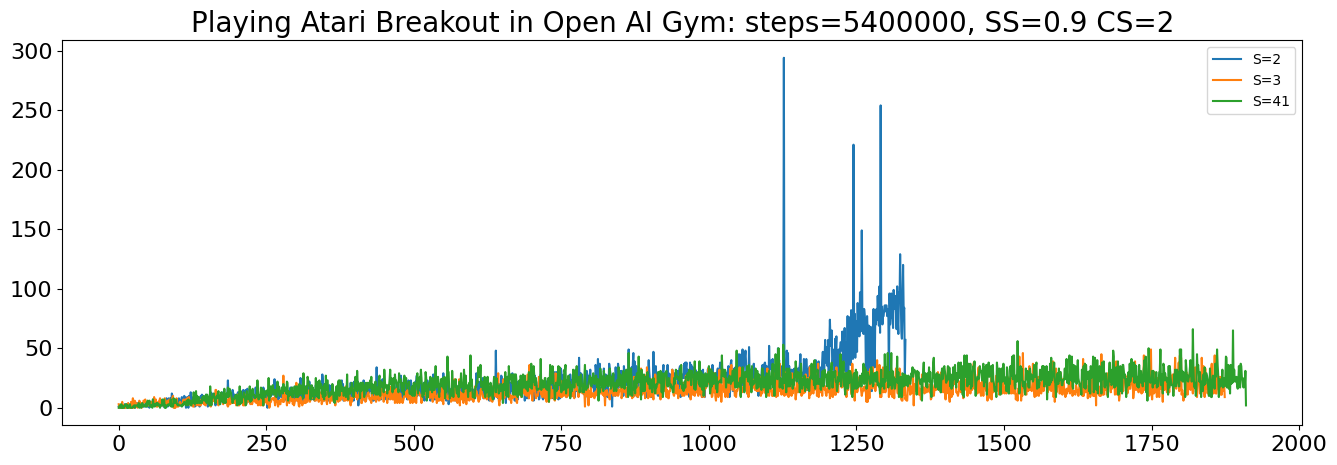

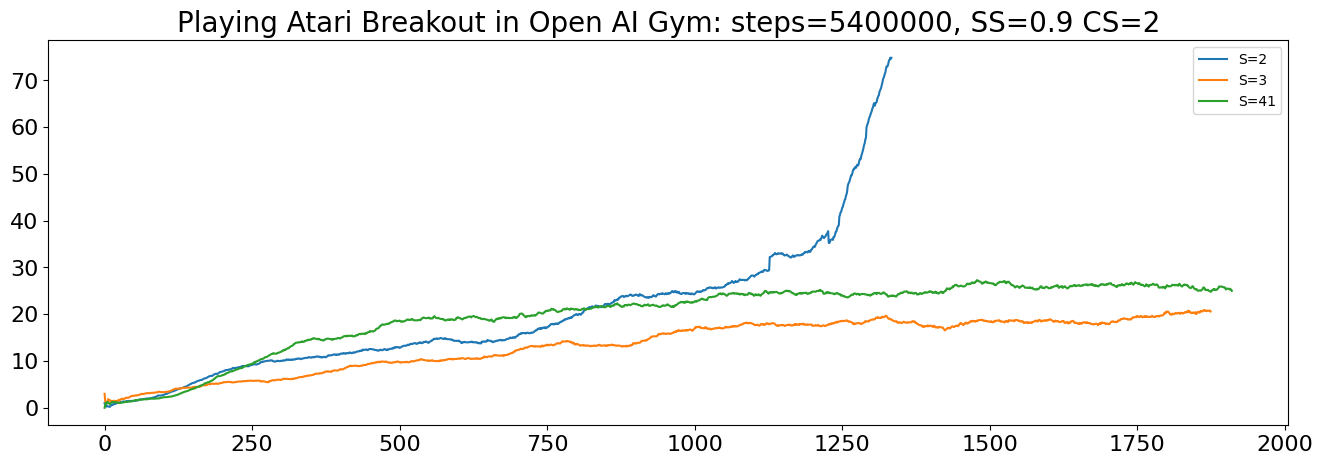

In [31]:
#python ./aigents-gym/breakout_eval2.py -cs=2 -ss=0.9 -tu=0 -s=2 -mg=50000 -mt=5400000 -sm="exp(-d)" > sim_exp/exp5400000_s2ss09.txt
#python ./aigents-gym/breakout_eval2.py -cs=3 -ss=0.9 -tu=0 -s=2 -mg=50000 -mt=5400000 -sm="exp(-d)" > sim_exp/exp5400000_s3ss09.txt
#python ./aigents-gym/breakout_eval2.py -cs=41 -ss=0.9 -tu=0 -s=2 -mg=50000 -mt=5400000 -sm="exp(-d)" > sim_exp/exp5400000_s41ss09.txt

#sim_exp/exp_s2ss09_5400000.txt:score_avg=22.2; steps_tot=5400000; steps_avg=4048.0; lives_avg=0.2; lapse_avg="0:00:03.538390"; time="10:43:25.078631"
#sim_exp/exp_s3ss09_5400000.txt:score_avg=14.0; steps_tot=5400000; steps_avg=2880.0; lives_avg=0.1; lapse_avg="0:00:30.863730"; time="15:06:07.288362"
#sim_exp/exp_s41ss09_5400000.txt:score_avg=20.4; steps_tot=5400000; steps_avg=2825.7; lives_avg=0.0; lapse_avg="0:00:00.234205"; time="12:04:59.678614"

tit = f"Playing Atari Breakout in Open AI Gym: steps={steps}, SS=0.9 CS=2"

s2ss09 = [1.0, 0, 0, 0, 1.0, 0, 0, 0, 0, 0, 3.0, 2.0, 0, 2.0, 2.0, 0, 3.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 0, 2.0, 1.0, 2.0, 2.0, 0, 3.0, 3.0, 4.0, 1.0, 1.0, 1.0, 3.0, 1.0, 3.0, 3.0, 1.0, 3.0, 1.0, 1.0, 1.0, 3.0, 2.0, 1.0, 2.0, 1.0, 2.0, 2.0, 2.0, 0, 2.0, 5.0, 3.0, 2.0, 4.0, 7.0, 3.0, 5.0, 3.0, 2.0, 3.0, 2.0, 2.0, 4.0, 2.0, 5.0, 2.0, 5.0, 3.0, 2.0, 2.0, 3.0, 4.0, 1.0, 1.0, 7.0, 3.0, 3.0, 8.0, 7.0, 1.0, 5.0, 8.0, 5.0, 7.0, 8.0, 4.0, 12.0, 10.0, 2.0, 3.0, 2.0, 0, 6.0, 4.0, 6.0, 4.0, 5.0, 6.0, 8.0, 5.0, 2.0, 2.0, 7.0, 9.0, 7.0, 5.0, 4.0, 10.0, 9.0, 5.0, 0, 6.0, 9.0, 7.0, 0, 10.0, 8.0, 6.0, 13.0, 2.0, 9.0, 5.0, 3.0, 8.0, 9.0, 1.0, 8.0, 9.0, 2.0, 7.0, 8.0, 8.0, 8.0, 1.0, 6.0, 10.0, 8.0, 11.0, 8.0, 8.0, 10.0, 9.0, 9.0, 5.0, 11.0, 8.0, 4.0, 1.0, 9.0, 5.0, 8.0, 11.0, 13.0, 9.0, 12.0, 6.0, 6.0, 11.0, 6.0, 6.0, 2.0, 7.0, 9.0, 11.0, 12.0, 8.0, 8.0, 6.0, 4.0, 11.0, 8.0, 13.0, 9.0, 8.0, 10.0, 6.0, 8.0, 6.0, 6.0, 11.0, 10.0, 23.0, 11.0, 10.0, 13.0, 11.0, 7.0, 8.0, 7.0, 15.0, 12.0, 9.0, 11.0, 6.0, 9.0, 8.0, 11.0, 8.0, 13.0, 6.0, 13.0, 8.0, 8.0, 11.0, 5.0, 8.0, 11.0, 15.0, 4.0, 9.0, 7.0, 15.0, 12.0, 6.0, 16.0, 5.0, 8.0, 8.0, 11.0, 11.0, 8.0, 7.0, 6.0, 14.0, 7.0, 7.0, 9.0, 8.0, 17.0, 10.0, 11.0, 7.0, 4.0, 7.0, 6.0, 7.0, 7.0, 11.0, 5.0, 12.0, 6.0, 17.0, 15.0, 14.0, 12.0, 13.0, 10.0, 12.0, 0, 11.0, 11.0, 6.0, 11.0, 9.0, 12.0, 13.0, 12.0, 11.0, 12.0, 14.0, 24.0, 7.0, 11.0, 20.0, 6.0, 18.0, 6.0, 10.0, 8.0, 12.0, 13.0, 14.0, 9.0, 10.0, 10.0, 11.0, 7.0, 6.0, 14.0, 8.0, 8.0, 7.0, 11.0, 7.0, 8.0, 8.0, 14.0, 17.0, 11.0, 9.0, 17.0, 5.0, 9.0, 6.0, 12.0, 14.0, 6.0, 11.0, 14.0, 18.0, 7.0, 8.0, 6.0, 15.0, 25.0, 7.0, 8.0, 6.0, 15.0, 4.0, 10.0, 7.0, 18.0, 10.0, 7.0, 15.0, 8.0, 7.0, 8.0, 22.0, 11.0, 8.0, 12.0, 7.0, 17.0, 8.0, 8.0, 8.0, 6.0, 8.0, 19.0, 11.0, 7.0, 8.0, 12.0, 7.0, 12.0, 11.0, 7.0, 10.0, 6.0, 28.0, 22.0, 12.0, 6.0, 7.0, 14.0, 10.0, 10.0, 12.0, 7.0, 12.0, 6.0, 19.0, 18.0, 7.0, 15.0, 15.0, 10.0, 15.0, 10.0, 12.0, 11.0, 8.0, 13.0, 12.0, 11.0, 14.0, 14.0, 6.0, 7.0, 16.0, 15.0, 22.0, 23.0, 9.0, 20.0, 6.0, 8.0, 10.0, 10.0, 14.0, 12.0, 11.0, 8.0, 16.0, 15.0, 8.0, 6.0, 21.0, 6.0, 12.0, 8.0, 15.0, 6.0, 22.0, 17.0, 13.0, 13.0, 12.0, 12.0, 22.0, 2.0, 10.0, 14.0, 15.0, 16.0, 10.0, 7.0, 6.0, 13.0, 23.0, 8.0, 9.0, 8.0, 6.0, 17.0, 12.0, 15.0, 12.0, 14.0, 16.0, 14.0, 18.0, 19.0, 9.0, 6.0, 19.0, 6.0, 17.0, 15.0, 10.0, 7.0, 34.0, 7.0, 11.0, 9.0, 8.0, 15.0, 13.0, 7.0, 16.0, 17.0, 24.0, 14.0, 15.0, 12.0, 9.0, 10.0, 7.0, 7.0, 8.0, 7.0, 13.0, 11.0, 8.0, 15.0, 8.0, 8.0, 8.0, 19.0, 8.0, 16.0, 21.0, 9.0, 8.0, 6.0, 16.0, 21.0, 16.0, 15.0, 9.0, 10.0, 10.0, 27.0, 22.0, 6.0, 14.0, 18.0, 16.0, 13.0, 12.0, 10.0, 20.0, 17.0, 7.0, 20.0, 23.0, 16.0, 12.0, 6.0, 23.0, 6.0, 11.0, 10.0, 14.0, 7.0, 21.0, 18.0, 22.0, 19.0, 27.0, 10.0, 13.0, 12.0, 21.0, 12.0, 12.0, 10.0, 20.0, 17.0, 13.0, 16.0, 21.0, 6.0, 18.0, 12.0, 13.0, 15.0, 23.0, 16.0, 17.0, 18.0, 15.0, 6.0, 9.0, 15.0, 19.0, 15.0, 28.0, 7.0, 17.0, 7.0, 18.0, 18.0, 7.0, 20.0, 20.0, 11.0, 15.0, 19.0, 12.0, 12.0, 13.0, 7.0, 12.0, 29.0, 16.0, 13.0, 20.0, 18.0, 6.0, 20.0, 24.0, 25.0, 3.0, 12.0, 16.0, 15.0, 7.0, 6.0, 16.0, 18.0, 21.0, 17.0, 12.0, 6.0, 9.0, 19.0, 13.0, 7.0, 16.0, 11.0, 23.0, 9.0, 19.0, 8.0, 8.0, 16.0, 17.0, 13.0, 14.0, 9.0, 6.0, 18.0, 11.0, 13.0, 7.0, 15.0, 8.0, 10.0, 20.0, 9.0, 7.0, 8.0, 16.0, 15.0, 8.0, 12.0, 8.0, 8.0, 15.0, 29.0, 11.0, 17.0, 16.0, 22.0, 8.0, 8.0, 15.0, 18.0, 16.0, 12.0, 25.0, 8.0, 16.0, 19.0, 17.0, 16.0, 8.0, 25.0, 17.0, 8.0, 15.0, 6.0, 15.0, 12.0, 8.0, 18.0, 15.0, 15.0, 7.0, 16.0, 13.0, 11.0, 48.0, 15.0, 25.0, 14.0, 8.0, 20.0, 19.0, 6.0, 15.0, 27.0, 26.0, 17.0, 14.0, 11.0, 19.0, 9.0, 14.0, 4.0, 21.0, 14.0, 15.0, 10.0, 27.0, 14.0, 8.0, 15.0, 21.0, 14.0, 29.0, 15.0, 21.0, 11.0, 6.0, 13.0, 6.0, 18.0, 16.0, 7.0, 22.0, 14.0, 21.0, 18.0, 17.0, 16.0, 21.0, 18.0, 14.0, 17.0, 23.0, 6.0, 15.0, 8.0, 20.0, 8.0, 17.0, 14.0, 8.0, 14.0, 25.0, 16.0, 21.0, 21.0, 34.0, 19.0, 6.0, 17.0, 27.0, 22.0, 23.0, 21.0, 12.0, 18.0, 16.0, 7.0, 8.0, 15.0, 28.0, 18.0, 21.0, 8.0, 7.0, 18.0, 21.0, 18.0, 17.0, 20.0, 22.0, 8.0, 23.0, 22.0, 21.0, 23.0, 20.0, 14.0, 30.0, 33.0, 11.0, 8.0, 17.0, 28.0, 30.0, 25.0, 19.0, 30.0, 15.0, 18.0, 7.0, 24.0, 16.0, 8.0, 33.0, 31.0, 18.0, 24.0, 20.0, 28.0, 25.0, 21.0, 22.0, 18.0, 9.0, 19.0, 13.0, 15.0, 24.0, 10.0, 28.0, 17.0, 15.0, 23.0, 19.0, 28.0, 19.0, 18.0, 9.0, 32.0, 14.0, 16.0, 31.0, 23.0, 19.0, 42.0, 15.0, 15.0, 29.0, 19.0, 28.0, 17.0, 18.0, 20.0, 11.0, 23.0, 9.0, 21.0, 31.0, 27.0, 19.0, 20.0, 27.0, 26.0, 32.0, 18.0, 17.0, 17.0, 21.0, 27.0, 24.0, 13.0, 18.0, 36.0, 31.0, 30.0, 19.0, 41.0, 17.0, 22.0, 37.0, 28.0, 25.0, 23.0, 15.0, 25.0, 18.0, 33.0, 14.0, 22.0, 28.0, 18.0, 21.0, 9.0, 19.0, 20.0, 37.0, 33.0, 29.0, 27.0, 13.0, 1.0, 20.0, 18.0, 22.0, 27.0, 10.0, 34.0, 20.0, 27.0, 14.0, 37.0, 33.0, 23.0, 31.0, 17.0, 28.0, 31.0, 18.0, 28.0, 10.0, 35.0, 29.0, 22.0, 24.0, 20.0, 19.0, 29.0, 22.0, 49.0, 19.0, 16.0, 27.0, 24.0, 34.0, 19.0, 36.0, 46.0, 10.0, 39.0, 30.0, 18.0, 35.0, 28.0, 9.0, 28.0, 25.0, 23.0, 29.0, 30.0, 13.0, 22.0, 24.0, 25.0, 20.0, 26.0, 23.0, 11.0, 27.0, 9.0, 20.0, 23.0, 30.0, 40.0, 30.0, 24.0, 22.0, 9.0, 11.0, 17.0, 19.0, 47.0, 26.0, 21.0, 17.0, 35.0, 20.0, 29.0, 11.0, 10.0, 30.0, 21.0, 20.0, 24.0, 25.0, 9.0, 18.0, 30.0, 36.0, 19.0, 21.0, 22.0, 21.0, 28.0, 27.0, 36.0, 21.0, 29.0, 26.0, 17.0, 28.0, 24.0, 26.0, 32.0, 21.0, 18.0, 22.0, 29.0, 27.0, 24.0, 29.0, 26.0, 31.0, 18.0, 25.0, 33.0, 35.0, 9.0, 29.0, 27.0, 25.0, 25.0, 25.0, 37.0, 25.0, 38.0, 33.0, 38.0, 12.0, 32.0, 29.0, 31.0, 9.0, 38.0, 9.0, 36.0, 33.0, 23.0, 34.0, 11.0, 21.0, 11.0, 32.0, 30.0, 27.0, 27.0, 26.0, 25.0, 23.0, 18.0, 31.0, 11.0, 31.0, 22.0, 9.0, 32.0, 15.0, 19.0, 9.0, 25.0, 21.0, 25.0, 18.0, 32.0, 33.0, 34.0, 31.0, 29.0, 22.0, 29.0, 21.0, 36.0, 29.0, 13.0, 28.0, 29.0, 29.0, 26.0, 21.0, 29.0, 33.0, 15.0, 20.0, 31.0, 38.0, 22.0, 31.0, 34.0, 31.0, 30.0, 30.0, 18.0, 14.0, 30.0, 29.0, 22.0, 25.0, 27.0, 35.0, 29.0, 9.0, 14.0, 37.0, 40.0, 22.0, 25.0, 14.0, 26.0, 33.0, 21.0, 34.0, 23.0, 35.0, 24.0, 28.0, 37.0, 45.0, 38.0, 26.0, 34.0, 45.0, 19.0, 49.0, 26.0, 32.0, 40.0, 43.0, 48.0, 37.0, 14.0, 24.0, 11.0, 19.0, 51.0, 29.0, 18.0, 28.0, 28.0, 34.0, 34.0, 25.0, 37.0, 29.0, 24.0, 22.0, 26.0, 29.0, 26.0, 24.0, 10.0, 26.0, 23.0, 27.0, 16.0, 25.0, 35.0, 36.0, 26.0, 25.0, 37.0, 38.0, 34.0, 19.0, 35.0, 30.0, 26.0, 15.0, 52.0, 32.0, 33.0, 35.0, 40.0, 25.0, 41.0, 29.0, 36.0, 35.0, 29.0, 36.0, 28.0, 23.0, 23.0, 50.0, 35.0, 40.0, 23.0, 17.0, 29.0, 28.0, 35.0, 30.0, 30.0, 294.0, 34.0, 32.0, 30.0, 30.0, 48.0, 36.0, 46.0, 15.0, 35.0, 18.0, 31.0, 25.0, 32.0, 28.0, 17.0, 32.0, 26.0, 33.0, 28.0, 23.0, 29.0, 30.0, 17.0, 33.0, 26.0, 32.0, 36.0, 45.0, 31.0, 29.0, 23.0, 24.0, 26.0, 41.0, 34.0, 35.0, 22.0, 41.0, 31.0, 15.0, 24.0, 32.0, 34.0, 35.0, 34.0, 33.0, 34.0, 36.0, 26.0, 30.0, 25.0, 23.0, 34.0, 40.0, 19.0, 26.0, 31.0, 38.0, 39.0, 22.0, 31.0, 23.0, 34.0, 26.0, 40.0, 47.0, 31.0, 19.0, 42.0, 57.0, 38.0, 51.0, 48.0, 35.0, 57.0, 20.0, 52.0, 74.0, 57.0, 52.0, 65.0, 36.0, 40.0, 41.0, 49.0, 23.0, 58.0, 50.0, 60.0, 20.0, 22.0, 30.0, 49.0, 23.0, 48.0, 55.0, 55.0, 48.0, 64.0, 42.0, 31.0, 59.0, 67.0, 40.0, 55.0, 28.0, 40.0, 77.0, 28.0, 51.0, 76.0, 69.0, 36.0, 82.0, 56.0, 55.0, 41.0, 221.0, 61.0, 79.0, 42.0, 73.0, 68.0, 47.0, 88.0, 64.0, 87.0, 60.0, 97.0, 64.0, 70.0, 149.0, 78.0, 67.0, 62.0, 83.0, 78.0, 73.0, 30.0, 57.0, 77.0, 65.0, 31.0, 69.0, 51.0, 14.0, 68.0, 66.0, 14.0, 35.0, 69.0, 83.0, 63.0, 34.0, 82.0, 70.0, 83.0, 74.0, 94.0, 82.0, 69.0, 102.0, 63.0, 254.0, 83.0, 85.0, 70.0, 77.0, 77.0, 83.0, 86.0, 81.0, 86.0, 86.0, 77.0, 83.0, 81.0, 19.0, 96.0, 70.0, 83.0, 96.0, 76.0, 76.0, 67.0, 99.0, 83.0, 83.0, 94.0, 80.0, 66.0, 102.0, 74.0, 62.0, 97.0, 90.0, 129.0, 95.0, 64.0, 58.0, 81.0, 120.0, 81.0, 84.0, 27.0, 57.0]
s3ss09 = [3.0, 0, 0, 2.0, 0, 3.0, 5.0, 0, 2.0, 0, 2.0, 0, 0, 3.0, 1.0, 1.0, 4.0, 0, 0, 2.0, 0, 5.0, 0, 2.0, 8.0, 0, 0, 6.0, 5.0, 4.0, 1.0, 2.0, 0, 4.0, 3.0, 6.0, 4.0, 3.0, 4.0, 0, 3.0, 3.0, 6.0, 6.0, 5.0, 7.0, 3.0, 2.0, 5.0, 3.0, 4.0, 2.0, 5.0, 5.0, 2.0, 2.0, 5.0, 5.0, 4.0, 3.0, 9.0, 4.0, 6.0, 7.0, 1.0, 4.0, 1.0, 5.0, 5.0, 6.0, 8.0, 2.0, 4.0, 6.0, 2.0, 2.0, 3.0, 2.0, 8.0, 6.0, 3.0, 2.0, 4.0, 6.0, 3.0, 4.0, 7.0, 5.0, 5.0, 2.0, 5.0, 9.0, 10.0, 0, 2.0, 0, 0, 2.0, 8.0, 1.0, 2.0, 1.0, 2.0, 4.0, 5.0, 3.0, 3.0, 2.0, 2.0, 6.0, 7.0, 4.0, 6.0, 7.0, 7.0, 6.0, 8.0, 8.0, 6.0, 9.0, 4.0, 3.0, 2.0, 5.0, 5.0, 3.0, 1.0, 1.0, 7.0, 7.0, 6.0, 7.0, 2.0, 6.0, 5.0, 5.0, 2.0, 7.0, 2.0, 2.0, 6.0, 5.0, 4.0, 6.0, 3.0, 3.0, 7.0, 2.0, 6.0, 10.0, 7.0, 9.0, 4.0, 4.0, 4.0, 2.0, 1.0, 8.0, 3.0, 9.0, 6.0, 6.0, 7.0, 9.0, 15.0, 15.0, 6.0, 5.0, 4.0, 2.0, 7.0, 6.0, 8.0, 6.0, 9.0, 10.0, 7.0, 3.0, 6.0, 4.0, 10.0, 6.0, 6.0, 7.0, 2.0, 1.0, 2.0, 12.0, 9.0, 3.0, 5.0, 4.0, 4.0, 7.0, 6.0, 4.0, 5.0, 4.0, 10.0, 2.0, 3.0, 11.0, 7.0, 2.0, 2.0, 4.0, 6.0, 4.0, 6.0, 6.0, 8.0, 2.0, 6.0, 2.0, 4.0, 11.0, 3.0, 5.0, 6.0, 9.0, 7.0, 5.0, 8.0, 3.0, 5.0, 9.0, 3.0, 5.0, 7.0, 6.0, 7.0, 5.0, 6.0, 4.0, 11.0, 6.0, 2.0, 4.0, 6.0, 4.0, 2.0, 9.0, 9.0, 2.0, 7.0, 2.0, 7.0, 4.0, 10.0, 6.0, 5.0, 7.0, 3.0, 4.0, 10.0, 0, 1.0, 7.0, 5.0, 7.0, 8.0, 8.0, 7.0, 8.0, 6.0, 2.0, 13.0, 5.0, 6.0, 4.0, 1.0, 4.0, 6.0, 3.0, 3.0, 7.0, 6.0, 7.0, 5.0, 27.0, 5.0, 13.0, 9.0, 9.0, 10.0, 2.0, 8.0, 6.0, 6.0, 4.0, 11.0, 9.0, 6.0, 6.0, 8.0, 3.0, 7.0, 2.0, 4.0, 7.0, 7.0, 21.0, 6.0, 8.0, 7.0, 2.0, 1.0, 6.0, 9.0, 4.0, 6.0, 2.0, 4.0, 4.0, 4.0, 7.0, 4.0, 4.0, 17.0, 5.0, 5.0, 9.0, 9.0, 15.0, 5.0, 7.0, 9.0, 11.0, 8.0, 10.0, 13.0, 7.0, 6.0, 6.0, 6.0, 8.0, 8.0, 10.0, 7.0, 5.0, 11.0, 7.0, 13.0, 8.0, 3.0, 5.0, 7.0, 13.0, 6.0, 9.0, 9.0, 9.0, 5.0, 3.0, 14.0, 11.0, 9.0, 9.0, 4.0, 10.0, 13.0, 6.0, 6.0, 6.0, 12.0, 11.0, 9.0, 2.0, 8.0, 10.0, 9.0, 8.0, 5.0, 10.0, 16.0, 6.0, 10.0, 7.0, 8.0, 16.0, 10.0, 12.0, 6.0, 8.0, 6.0, 18.0, 14.0, 11.0, 6.0, 10.0, 10.0, 11.0, 5.0, 2.0, 8.0, 5.0, 9.0, 8.0, 16.0, 13.0, 9.0, 14.0, 9.0, 11.0, 7.0, 10.0, 9.0, 12.0, 13.0, 9.0, 19.0, 4.0, 4.0, 9.0, 19.0, 10.0, 7.0, 10.0, 5.0, 6.0, 9.0, 10.0, 12.0, 13.0, 10.0, 7.0, 8.0, 6.0, 4.0, 13.0, 8.0, 8.0, 9.0, 7.0, 8.0, 16.0, 5.0, 9.0, 12.0, 16.0, 8.0, 6.0, 17.0, 7.0, 8.0, 13.0, 16.0, 12.0, 11.0, 5.0, 14.0, 11.0, 13.0, 10.0, 11.0, 4.0, 18.0, 12.0, 9.0, 15.0, 7.0, 10.0, 18.0, 8.0, 7.0, 7.0, 9.0, 15.0, 4.0, 8.0, 16.0, 8.0, 4.0, 8.0, 13.0, 10.0, 4.0, 12.0, 8.0, 8.0, 5.0, 4.0, 6.0, 8.0, 12.0, 10.0, 13.0, 9.0, 13.0, 15.0, 11.0, 7.0, 10.0, 9.0, 4.0, 13.0, 14.0, 10.0, 4.0, 10.0, 6.0, 5.0, 17.0, 11.0, 4.0, 11.0, 14.0, 13.0, 12.0, 13.0, 11.0, 10.0, 10.0, 4.0, 11.0, 11.0, 11.0, 11.0, 11.0, 13.0, 18.0, 9.0, 8.0, 11.0, 10.0, 14.0, 12.0, 8.0, 9.0, 11.0, 17.0, 10.0, 5.0, 10.0, 21.0, 15.0, 14.0, 8.0, 10.0, 4.0, 8.0, 6.0, 12.0, 6.0, 7.0, 9.0, 12.0, 6.0, 20.0, 6.0, 3.0, 13.0, 18.0, 8.0, 14.0, 13.0, 8.0, 8.0, 7.0, 10.0, 10.0, 12.0, 14.0, 5.0, 6.0, 12.0, 14.0, 6.0, 9.0, 24.0, 6.0, 9.0, 9.0, 17.0, 4.0, 11.0, 6.0, 24.0, 2.0, 13.0, 7.0, 12.0, 11.0, 13.0, 4.0, 15.0, 8.0, 19.0, 10.0, 3.0, 11.0, 16.0, 7.0, 13.0, 6.0, 10.0, 14.0, 12.0, 7.0, 10.0, 12.0, 5.0, 11.0, 11.0, 18.0, 10.0, 14.0, 11.0, 11.0, 7.0, 5.0, 9.0, 7.0, 15.0, 16.0, 14.0, 12.0, 9.0, 9.0, 8.0, 8.0, 15.0, 8.0, 13.0, 7.0, 10.0, 18.0, 9.0, 11.0, 17.0, 6.0, 8.0, 17.0, 5.0, 18.0, 11.0, 10.0, 19.0, 11.0, 11.0, 9.0, 19.0, 9.0, 29.0, 6.0, 2.0, 11.0, 7.0, 12.0, 16.0, 9.0, 12.0, 24.0, 8.0, 9.0, 10.0, 14.0, 11.0, 15.0, 18.0, 20.0, 11.0, 7.0, 11.0, 8.0, 4.0, 10.0, 9.0, 8.0, 19.0, 11.0, 9.0, 11.0, 15.0, 5.0, 4.0, 18.0, 16.0, 13.0, 11.0, 12.0, 13.0, 9.0, 20.0, 12.0, 14.0, 20.0, 24.0, 11.0, 12.0, 18.0, 10.0, 18.0, 28.0, 12.0, 8.0, 36.0, 12.0, 15.0, 14.0, 11.0, 6.0, 21.0, 14.0, 22.0, 22.0, 11.0, 8.0, 11.0, 10.0, 10.0, 13.0, 26.0, 14.0, 15.0, 15.0, 11.0, 23.0, 9.0, 14.0, 13.0, 22.0, 8.0, 16.0, 9.0, 5.0, 13.0, 14.0, 11.0, 5.0, 12.0, 8.0, 18.0, 8.0, 10.0, 14.0, 15.0, 13.0, 7.0, 6.0, 29.0, 28.0, 8.0, 14.0, 10.0, 14.0, 11.0, 10.0, 23.0, 9.0, 22.0, 9.0, 12.0, 11.0, 10.0, 19.0, 17.0, 11.0, 9.0, 9.0, 23.0, 10.0, 16.0, 12.0, 20.0, 9.0, 16.0, 19.0, 10.0, 11.0, 13.0, 9.0, 8.0, 31.0, 15.0, 23.0, 17.0, 15.0, 14.0, 9.0, 14.0, 15.0, 15.0, 13.0, 19.0, 15.0, 12.0, 19.0, 13.0, 13.0, 1.0, 14.0, 11.0, 10.0, 17.0, 17.0, 2.0, 14.0, 11.0, 9.0, 23.0, 9.0, 12.0, 10.0, 12.0, 11.0, 8.0, 13.0, 10.0, 14.0, 11.0, 17.0, 11.0, 20.0, 11.0, 12.0, 16.0, 16.0, 16.0, 13.0, 11.0, 16.0, 10.0, 13.0, 2.0, 14.0, 11.0, 15.0, 13.0, 11.0, 10.0, 9.0, 7.0, 16.0, 14.0, 15.0, 12.0, 24.0, 10.0, 11.0, 15.0, 19.0, 10.0, 16.0, 12.0, 16.0, 10.0, 11.0, 15.0, 14.0, 14.0, 24.0, 8.0, 11.0, 20.0, 14.0, 17.0, 13.0, 14.0, 17.0, 9.0, 17.0, 11.0, 12.0, 11.0, 12.0, 14.0, 10.0, 13.0, 16.0, 8.0, 13.0, 9.0, 26.0, 12.0, 17.0, 12.0, 10.0, 25.0, 11.0, 9.0, 17.0, 14.0, 11.0, 12.0, 33.0, 12.0, 11.0, 17.0, 13.0, 13.0, 13.0, 8.0, 27.0, 14.0, 34.0, 24.0, 8.0, 11.0, 16.0, 13.0, 9.0, 24.0, 12.0, 13.0, 11.0, 7.0, 16.0, 21.0, 28.0, 24.0, 18.0, 12.0, 23.0, 12.0, 13.0, 19.0, 22.0, 7.0, 29.0, 16.0, 28.0, 15.0, 16.0, 14.0, 23.0, 28.0, 25.0, 9.0, 15.0, 14.0, 8.0, 8.0, 14.0, 14.0, 18.0, 21.0, 27.0, 32.0, 29.0, 11.0, 10.0, 14.0, 23.0, 20.0, 12.0, 12.0, 19.0, 8.0, 13.0, 15.0, 12.0, 15.0, 16.0, 21.0, 10.0, 14.0, 21.0, 10.0, 11.0, 17.0, 27.0, 15.0, 11.0, 18.0, 28.0, 13.0, 13.0, 25.0, 7.0, 18.0, 21.0, 25.0, 11.0, 14.0, 13.0, 10.0, 17.0, 19.0, 13.0, 22.0, 12.0, 10.0, 16.0, 12.0, 24.0, 26.0, 13.0, 9.0, 19.0, 19.0, 19.0, 9.0, 21.0, 16.0, 17.0, 18.0, 25.0, 20.0, 33.0, 25.0, 33.0, 13.0, 25.0, 13.0, 9.0, 10.0, 24.0, 14.0, 13.0, 29.0, 9.0, 6.0, 21.0, 15.0, 15.0, 9.0, 26.0, 32.0, 11.0, 20.0, 5.0, 14.0, 18.0, 16.0, 29.0, 13.0, 20.0, 9.0, 21.0, 15.0, 13.0, 9.0, 22.0, 13.0, 15.0, 33.0, 25.0, 36.0, 20.0, 15.0, 16.0, 22.0, 16.0, 10.0, 13.0, 9.0, 15.0, 14.0, 16.0, 18.0, 19.0, 34.0, 11.0, 10.0, 18.0, 13.0, 14.0, 15.0, 15.0, 27.0, 16.0, 15.0, 26.0, 29.0, 12.0, 26.0, 9.0, 16.0, 16.0, 18.0, 14.0, 29.0, 16.0, 19.0, 23.0, 17.0, 24.0, 15.0, 24.0, 22.0, 14.0, 26.0, 24.0, 14.0, 22.0, 25.0, 26.0, 10.0, 14.0, 12.0, 13.0, 21.0, 19.0, 15.0, 18.0, 12.0, 20.0, 10.0, 33.0, 20.0, 17.0, 10.0, 24.0, 14.0, 16.0, 14.0, 10.0, 11.0, 10.0, 29.0, 25.0, 21.0, 20.0, 9.0, 11.0, 26.0, 10.0, 22.0, 14.0, 37.0, 21.0, 15.0, 11.0, 17.0, 14.0, 25.0, 11.0, 10.0, 30.0, 24.0, 11.0, 13.0, 19.0, 13.0, 9.0, 20.0, 12.0, 24.0, 14.0, 10.0, 29.0, 12.0, 18.0, 18.0, 16.0, 14.0, 7.0, 12.0, 25.0, 16.0, 13.0, 19.0, 16.0, 16.0, 24.0, 18.0, 10.0, 19.0, 25.0, 12.0, 26.0, 13.0, 13.0, 28.0, 15.0, 23.0, 18.0, 25.0, 22.0, 8.0, 34.0, 11.0, 16.0, 27.0, 16.0, 23.0, 12.0, 38.0, 15.0, 26.0, 20.0, 29.0, 10.0, 13.0, 37.0, 9.0, 16.0, 15.0, 13.0, 15.0, 20.0, 10.0, 21.0, 17.0, 17.0, 15.0, 18.0, 12.0, 10.0, 14.0, 16.0, 13.0, 30.0, 22.0, 8.0, 10.0, 12.0, 24.0, 11.0, 9.0, 25.0, 21.0, 11.0, 14.0, 11.0, 34.0, 14.0, 24.0, 13.0, 24.0, 22.0, 20.0, 20.0, 22.0, 17.0, 26.0, 26.0, 18.0, 20.0, 23.0, 29.0, 18.0, 9.0, 20.0, 16.0, 15.0, 25.0, 23.0, 24.0, 22.0, 14.0, 11.0, 37.0, 17.0, 20.0, 17.0, 6.0, 23.0, 15.0, 25.0, 13.0, 14.0, 18.0, 18.0, 26.0, 22.0, 18.0, 14.0, 10.0, 13.0, 14.0, 17.0, 15.0, 18.0, 14.0, 13.0, 5.0, 16.0, 5.0, 30.0, 20.0, 8.0, 27.0, 33.0, 17.0, 21.0, 16.0, 34.0, 19.0, 19.0, 19.0, 14.0, 18.0, 23.0, 40.0, 20.0, 24.0, 18.0, 36.0, 9.0, 21.0, 9.0, 20.0, 15.0, 34.0, 13.0, 26.0, 22.0, 13.0, 17.0, 18.0, 21.0, 24.0, 25.0, 9.0, 28.0, 29.0, 19.0, 11.0, 27.0, 9.0, 20.0, 15.0, 8.0, 18.0, 26.0, 33.0, 28.0, 17.0, 12.0, 28.0, 27.0, 33.0, 30.0, 9.0, 7.0, 6.0, 6.0, 13.0, 27.0, 11.0, 22.0, 7.0, 10.0, 6.0, 6.0, 16.0, 22.0, 24.0, 17.0, 11.0, 18.0, 12.0, 13.0, 14.0, 30.0, 2.0, 20.0, 15.0, 15.0, 14.0, 24.0, 24.0, 29.0, 22.0, 11.0, 16.0, 15.0, 7.0, 7.0, 28.0, 15.0, 16.0, 17.0, 12.0, 13.0, 13.0, 28.0, 13.0, 20.0, 17.0, 17.0, 14.0, 13.0, 20.0, 7.0, 8.0, 20.0, 19.0, 11.0, 10.0, 14.0, 18.0, 21.0, 15.0, 16.0, 24.0, 30.0, 20.0, 18.0, 27.0, 14.0, 13.0, 30.0, 16.0, 28.0, 13.0, 33.0, 17.0, 14.0, 7.0, 22.0, 12.0, 22.0, 34.0, 24.0, 10.0, 5.0, 24.0, 13.0, 9.0, 20.0, 11.0, 24.0, 20.0, 20.0, 27.0, 29.0, 13.0, 13.0, 12.0, 10.0, 13.0, 22.0, 22.0, 17.0, 13.0, 21.0, 23.0, 23.0, 8.0, 12.0, 20.0, 24.0, 18.0, 15.0, 18.0, 10.0, 16.0, 25.0, 24.0, 23.0, 12.0, 20.0, 15.0, 15.0, 19.0, 35.0, 38.0, 16.0, 28.0, 15.0, 12.0, 15.0, 12.0, 28.0, 34.0, 13.0, 21.0, 14.0, 10.0, 11.0, 26.0, 28.0, 10.0, 32.0, 26.0, 24.0, 16.0, 14.0, 35.0, 6.0, 15.0, 9.0, 13.0, 21.0, 8.0, 27.0, 7.0, 26.0, 23.0, 13.0, 18.0, 19.0, 16.0, 21.0, 27.0, 14.0, 15.0, 24.0, 18.0, 11.0, 17.0, 16.0, 27.0, 21.0, 12.0, 22.0, 17.0, 16.0, 12.0, 14.0, 22.0, 12.0, 22.0, 26.0, 25.0, 24.0, 14.0, 12.0, 16.0, 28.0, 12.0, 21.0, 22.0, 27.0, 12.0, 14.0, 20.0, 7.0, 11.0, 10.0, 6.0, 16.0, 16.0, 43.0, 16.0, 28.0, 6.0, 15.0, 10.0, 46.0, 22.0, 17.0, 16.0, 20.0, 12.0, 11.0, 20.0, 19.0, 14.0, 28.0, 35.0, 15.0, 16.0, 16.0, 14.0, 20.0, 37.0, 25.0, 12.0, 9.0, 15.0, 25.0, 10.0, 12.0, 13.0, 26.0, 10.0, 14.0, 15.0, 21.0, 12.0, 17.0, 29.0, 31.0, 14.0, 27.0, 19.0, 18.0, 23.0, 24.0, 22.0, 13.0, 18.0, 22.0, 25.0, 15.0, 16.0, 14.0, 18.0, 28.0, 39.0, 9.0, 19.0, 5.0, 12.0, 33.0, 13.0, 18.0, 25.0, 20.0, 22.0, 12.0, 12.0, 29.0, 24.0, 23.0, 11.0, 24.0, 24.0, 15.0, 14.0, 9.0, 11.0, 16.0, 12.0, 16.0, 14.0, 28.0, 25.0, 12.0, 20.0, 18.0, 25.0, 10.0, 12.0, 14.0, 14.0, 12.0, 11.0, 19.0, 17.0, 13.0, 15.0, 10.0, 14.0, 20.0, 18.0, 20.0, 19.0, 22.0, 10.0, 41.0, 10.0, 19.0, 37.0, 13.0, 30.0, 19.0, 18.0, 8.0, 15.0, 13.0, 22.0, 9.0, 11.0, 21.0, 24.0, 15.0, 10.0, 35.0, 10.0, 13.0, 23.0, 2.0, 33.0, 25.0, 19.0, 14.0, 12.0, 10.0, 18.0, 10.0, 45.0, 16.0, 11.0, 27.0, 11.0, 22.0, 16.0, 15.0, 21.0, 11.0, 11.0, 29.0, 21.0, 21.0, 19.0, 18.0, 13.0, 25.0, 16.0, 18.0, 35.0, 20.0, 19.0, 11.0, 26.0, 39.0, 19.0, 11.0, 22.0, 18.0, 6.0, 10.0, 28.0, 21.0, 21.0, 18.0, 17.0, 14.0, 22.0, 27.0, 26.0, 27.0, 12.0, 24.0, 12.0, 14.0, 23.0, 20.0, 16.0, 16.0, 21.0, 23.0, 31.0, 23.0, 8.0, 13.0, 24.0, 39.0, 15.0, 15.0, 16.0, 17.0, 21.0, 13.0, 17.0, 16.0, 21.0, 16.0, 12.0, 26.0, 13.0, 17.0, 44.0, 15.0, 22.0, 35.0, 33.0, 24.0, 13.0, 11.0, 28.0, 10.0, 20.0, 12.0, 49.0, 12.0, 7.0, 18.0, 18.0, 12.0, 30.0, 15.0, 13.0, 25.0, 9.0, 25.0, 10.0, 22.0, 9.0, 22.0, 27.0, 16.0, 25.0, 16.0, 5.0, 26.0, 15.0, 15.0, 24.0, 26.0, 18.0, 13.0, 16.0, 14.0, 24.0, 13.0, 32.0, 25.0, 19.0, 20.0, 26.0, 28.0, 13.0, 26.0, 26.0, 42.0, 17.0, 16.0, 22.0, 27.0, 25.0, 38.0, 14.0, 44.0, 15.0, 42.0, 11.0, 15.0, 12.0, 6.0, 9.0, 12.0, 10.0, 24.0, 30.0, 21.0, 11.0, 17.0, 25.0, 28.0, 28.0, 15.0, 25.0, 31.0, 17.0, 12.0, 22.0, 21.0, 18.0, 34.0, 13.0, 16.0, 9.0, 20.0, 22.0, 28.0, 26.0, 12.0, 22.0, 12.0, 42.0, 27.0, 14.0, 35.0, 13.0, 9.0, 33.0, 16.0, 19.0, 21.0, 12.0, 22.0, 20.0, 21.0, 11.0, 12.0, 32.0, 37.0, 12.0, 20.0, 12.0, 23.0, 44.0, 19.0, 12.0, 12.0, 23.0, 31.0, 20.0, 15.0, 14.0, 26.0, 11.0, 24.0, 11.0, 21.0, 14.0, 21.0, 20.0, 9.0]
s41ss09 = [0, 1.0, 2.0, 0, 3.0, 0, 2.0, 0, 0, 0, 2.0, 2.0, 3.0, 3.0, 0, 2.0, 0, 0, 2.0, 3.0, 0, 0, 0, 0, 1.0, 1.0, 2.0, 0, 2.0, 2.0, 2.0, 2.0, 1.0, 2.0, 4.0, 0, 3.0, 1.0, 0, 2.0, 4.0, 1.0, 2.0, 2.0, 2.0, 1.0, 2.0, 4.0, 1.0, 6.0, 3.0, 3.0, 6.0, 1.0, 1.0, 2.0, 2.0, 0, 7.0, 3.0, 3.0, 1.0, 2.0, 2.0, 4.0, 2.0, 4.0, 2.0, 3.0, 2.0, 0, 2.0, 2.0, 3.0, 7.0, 2.0, 4.0, 7.0, 0, 2.0, 0, 2.0, 2.0, 2.0, 3.0, 2.0, 2.0, 2.0, 7.0, 1.0, 3.0, 1.0, 1.0, 8.0, 5.0, 4.0, 6.0, 7.0, 4.0, 3.0, 2.0, 3.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, 3.0, 2.0, 3.0, 5.0, 4.0, 3.0, 2.0, 6.0, 6.0, 2.0, 7.0, 3.0, 4.0, 6.0, 5.0, 2.0, 6.0, 6.0, 4.0, 13.0, 5.0, 3.0, 6.0, 14.0, 4.0, 10.0, 4.0, 7.0, 9.0, 4.0, 4.0, 5.0, 6.0, 4.0, 9.0, 7.0, 10.0, 6.0, 8.0, 6.0, 11.0, 4.0, 11.0, 6.0, 4.0, 9.0, 2.0, 18.0, 7.0, 2.0, 8.0, 9.0, 9.0, 12.0, 8.0, 7.0, 4.0, 7.0, 10.0, 8.0, 12.0, 14.0, 10.0, 3.0, 3.0, 9.0, 13.0, 9.0, 5.0, 8.0, 4.0, 16.0, 6.0, 4.0, 9.0, 12.0, 9.0, 17.0, 9.0, 14.0, 16.0, 13.0, 13.0, 10.0, 7.0, 4.0, 7.0, 7.0, 8.0, 10.0, 8.0, 11.0, 6.0, 2.0, 8.0, 11.0, 3.0, 18.0, 3.0, 14.0, 4.0, 7.0, 9.0, 9.0, 13.0, 10.0, 8.0, 2.0, 3.0, 14.0, 10.0, 9.0, 7.0, 8.0, 18.0, 5.0, 9.0, 6.0, 14.0, 16.0, 11.0, 11.0, 10.0, 8.0, 10.0, 9.0, 11.0, 23.0, 14.0, 7.0, 10.0, 10.0, 10.0, 17.0, 8.0, 16.0, 15.0, 2.0, 14.0, 12.0, 9.0, 14.0, 12.0, 13.0, 15.0, 10.0, 25.0, 6.0, 14.0, 18.0, 10.0, 13.0, 17.0, 19.0, 13.0, 11.0, 15.0, 15.0, 13.0, 9.0, 13.0, 22.0, 14.0, 18.0, 11.0, 10.0, 12.0, 14.0, 17.0, 17.0, 12.0, 20.0, 15.0, 14.0, 17.0, 15.0, 12.0, 22.0, 21.0, 6.0, 14.0, 10.0, 11.0, 11.0, 12.0, 17.0, 9.0, 9.0, 14.0, 13.0, 18.0, 14.0, 9.0, 18.0, 15.0, 9.0, 18.0, 11.0, 20.0, 11.0, 12.0, 18.0, 13.0, 19.0, 8.0, 29.0, 15.0, 12.0, 12.0, 17.0, 18.0, 12.0, 26.0, 23.0, 19.0, 19.0, 17.0, 7.0, 18.0, 19.0, 10.0, 17.0, 9.0, 7.0, 15.0, 11.0, 25.0, 13.0, 10.0, 9.0, 22.0, 8.0, 23.0, 17.0, 17.0, 20.0, 12.0, 15.0, 9.0, 18.0, 7.0, 20.0, 10.0, 27.0, 15.0, 23.0, 23.0, 12.0, 9.0, 10.0, 10.0, 13.0, 11.0, 12.0, 20.0, 17.0, 7.0, 5.0, 4.0, 13.0, 10.0, 18.0, 7.0, 17.0, 22.0, 23.0, 10.0, 23.0, 22.0, 20.0, 14.0, 17.0, 17.0, 10.0, 11.0, 17.0, 13.0, 9.0, 14.0, 28.0, 11.0, 7.0, 15.0, 16.0, 12.0, 17.0, 15.0, 21.0, 14.0, 11.0, 9.0, 13.0, 19.0, 26.0, 17.0, 14.0, 31.0, 19.0, 21.0, 15.0, 17.0, 8.0, 21.0, 14.0, 21.0, 17.0, 21.0, 16.0, 9.0, 14.0, 19.0, 21.0, 16.0, 14.0, 21.0, 17.0, 21.0, 17.0, 23.0, 17.0, 26.0, 12.0, 20.0, 17.0, 19.0, 12.0, 17.0, 22.0, 11.0, 13.0, 17.0, 11.0, 15.0, 25.0, 27.0, 10.0, 22.0, 22.0, 21.0, 18.0, 19.0, 13.0, 32.0, 22.0, 17.0, 19.0, 17.0, 12.0, 19.0, 15.0, 18.0, 24.0, 32.0, 20.0, 25.0, 17.0, 13.0, 21.0, 25.0, 16.0, 28.0, 22.0, 23.0, 21.0, 18.0, 17.0, 13.0, 29.0, 22.0, 22.0, 24.0, 17.0, 14.0, 17.0, 21.0, 11.0, 27.0, 21.0, 21.0, 25.0, 16.0, 19.0, 20.0, 20.0, 22.0, 12.0, 13.0, 12.0, 11.0, 18.0, 10.0, 17.0, 21.0, 10.0, 12.0, 20.0, 20.0, 24.0, 29.0, 12.0, 18.0, 17.0, 26.0, 21.0, 32.0, 25.0, 16.0, 9.0, 17.0, 11.0, 21.0, 14.0, 30.0, 25.0, 6.0, 11.0, 9.0, 19.0, 21.0, 18.0, 26.0, 15.0, 19.0, 13.0, 25.0, 19.0, 15.0, 15.0, 25.0, 35.0, 17.0, 25.0, 22.0, 26.0, 18.0, 9.0, 20.0, 18.0, 24.0, 18.0, 21.0, 25.0, 17.0, 16.0, 26.0, 8.0, 19.0, 13.0, 20.0, 43.0, 30.0, 30.0, 15.0, 8.0, 15.0, 15.0, 10.0, 31.0, 19.0, 9.0, 22.0, 20.0, 18.0, 24.0, 15.0, 12.0, 18.0, 15.0, 9.0, 22.0, 21.0, 17.0, 29.0, 20.0, 18.0, 17.0, 13.0, 32.0, 25.0, 16.0, 27.0, 17.0, 19.0, 16.0, 9.0, 17.0, 21.0, 14.0, 44.0, 19.0, 24.0, 17.0, 9.0, 11.0, 9.0, 8.0, 16.0, 18.0, 18.0, 23.0, 21.0, 34.0, 27.0, 26.0, 26.0, 36.0, 18.0, 18.0, 22.0, 15.0, 20.0, 16.0, 26.0, 9.0, 25.0, 13.0, 13.0, 26.0, 19.0, 9.0, 17.0, 10.0, 21.0, 18.0, 14.0, 9.0, 7.0, 19.0, 26.0, 21.0, 19.0, 13.0, 25.0, 21.0, 20.0, 16.0, 12.0, 16.0, 19.0, 14.0, 20.0, 18.0, 19.0, 4.0, 20.0, 15.0, 20.0, 30.0, 19.0, 10.0, 25.0, 26.0, 9.0, 35.0, 24.0, 27.0, 28.0, 24.0, 21.0, 28.0, 18.0, 11.0, 28.0, 28.0, 11.0, 28.0, 22.0, 17.0, 9.0, 18.0, 17.0, 23.0, 11.0, 27.0, 21.0, 9.0, 22.0, 28.0, 17.0, 22.0, 27.0, 17.0, 16.0, 21.0, 22.0, 14.0, 18.0, 30.0, 24.0, 18.0, 17.0, 37.0, 16.0, 24.0, 22.0, 35.0, 28.0, 19.0, 20.0, 25.0, 16.0, 15.0, 15.0, 16.0, 16.0, 16.0, 16.0, 41.0, 15.0, 22.0, 23.0, 18.0, 17.0, 18.0, 25.0, 25.0, 16.0, 16.0, 15.0, 16.0, 25.0, 5.0, 15.0, 36.0, 20.0, 22.0, 21.0, 35.0, 26.0, 18.0, 18.0, 7.0, 16.0, 21.0, 14.0, 20.0, 24.0, 35.0, 19.0, 34.0, 27.0, 18.0, 13.0, 16.0, 17.0, 23.0, 15.0, 32.0, 30.0, 36.0, 12.0, 23.0, 17.0, 21.0, 27.0, 17.0, 22.0, 8.0, 12.0, 19.0, 14.0, 19.0, 32.0, 28.0, 17.0, 31.0, 22.0, 27.0, 35.0, 21.0, 19.0, 19.0, 26.0, 13.0, 20.0, 28.0, 24.0, 19.0, 13.0, 18.0, 13.0, 26.0, 36.0, 17.0, 15.0, 17.0, 18.0, 17.0, 21.0, 23.0, 27.0, 26.0, 20.0, 18.0, 25.0, 21.0, 29.0, 21.0, 20.0, 25.0, 25.0, 27.0, 18.0, 17.0, 24.0, 6.0, 17.0, 13.0, 33.0, 26.0, 27.0, 17.0, 17.0, 14.0, 31.0, 26.0, 17.0, 25.0, 19.0, 26.0, 27.0, 18.0, 18.0, 27.0, 33.0, 26.0, 16.0, 18.0, 26.0, 21.0, 29.0, 14.0, 20.0, 20.0, 21.0, 14.0, 23.0, 18.0, 18.0, 34.0, 27.0, 19.0, 28.0, 26.0, 17.0, 20.0, 18.0, 31.0, 26.0, 16.0, 28.0, 27.0, 32.0, 22.0, 28.0, 9.0, 46.0, 22.0, 12.0, 11.0, 33.0, 21.0, 10.0, 16.0, 15.0, 18.0, 23.0, 12.0, 26.0, 17.0, 29.0, 21.0, 23.0, 43.0, 22.0, 31.0, 19.0, 7.0, 32.0, 19.0, 14.0, 26.0, 28.0, 14.0, 26.0, 24.0, 22.0, 23.0, 30.0, 20.0, 25.0, 19.0, 16.0, 24.0, 19.0, 20.0, 13.0, 18.0, 25.0, 19.0, 20.0, 12.0, 18.0, 17.0, 20.0, 20.0, 30.0, 22.0, 22.0, 21.0, 31.0, 26.0, 13.0, 29.0, 9.0, 14.0, 18.0, 29.0, 29.0, 29.0, 31.0, 19.0, 18.0, 18.0, 25.0, 23.0, 19.0, 20.0, 17.0, 18.0, 16.0, 13.0, 13.0, 25.0, 20.0, 22.0, 32.0, 28.0, 26.0, 26.0, 24.0, 24.0, 23.0, 33.0, 20.0, 36.0, 22.0, 16.0, 19.0, 14.0, 16.0, 22.0, 17.0, 26.0, 26.0, 27.0, 29.0, 23.0, 29.0, 32.0, 28.0, 26.0, 19.0, 31.0, 26.0, 27.0, 27.0, 16.0, 39.0, 15.0, 22.0, 25.0, 29.0, 30.0, 24.0, 20.0, 39.0, 18.0, 18.0, 30.0, 17.0, 15.0, 28.0, 10.0, 15.0, 24.0, 29.0, 28.0, 18.0, 27.0, 28.0, 22.0, 35.0, 25.0, 12.0, 16.0, 32.0, 18.0, 30.0, 24.0, 20.0, 25.0, 26.0, 29.0, 16.0, 26.0, 13.0, 21.0, 21.0, 22.0, 22.0, 23.0, 22.0, 21.0, 44.0, 27.0, 32.0, 31.0, 26.0, 32.0, 31.0, 17.0, 25.0, 22.0, 22.0, 21.0, 25.0, 27.0, 23.0, 20.0, 26.0, 22.0, 31.0, 31.0, 23.0, 32.0, 20.0, 17.0, 26.0, 48.0, 17.0, 20.0, 21.0, 18.0, 18.0, 25.0, 9.0, 24.0, 28.0, 34.0, 21.0, 28.0, 13.0, 30.0, 30.0, 26.0, 27.0, 35.0, 24.0, 22.0, 36.0, 23.0, 20.0, 32.0, 13.0, 35.0, 19.0, 22.0, 20.0, 21.0, 24.0, 33.0, 30.0, 16.0, 31.0, 18.0, 17.0, 28.0, 24.0, 24.0, 18.0, 15.0, 33.0, 33.0, 27.0, 17.0, 20.0, 21.0, 26.0, 9.0, 29.0, 16.0, 13.0, 24.0, 31.0, 29.0, 16.0, 21.0, 20.0, 28.0, 37.0, 17.0, 21.0, 10.0, 23.0, 45.0, 25.0, 31.0, 24.0, 35.0, 50.0, 33.0, 17.0, 25.0, 24.0, 20.0, 18.0, 16.0, 53.0, 36.0, 21.0, 28.0, 23.0, 13.0, 33.0, 18.0, 32.0, 18.0, 33.0, 18.0, 29.0, 20.0, 23.0, 21.0, 16.0, 24.0, 19.0, 29.0, 26.0, 39.0, 33.0, 22.0, 26.0, 30.0, 28.0, 29.0, 13.0, 25.0, 37.0, 25.0, 16.0, 24.0, 24.0, 19.0, 27.0, 14.0, 21.0, 20.0, 24.0, 17.0, 24.0, 15.0, 14.0, 23.0, 26.0, 25.0, 37.0, 25.0, 24.0, 32.0, 19.0, 40.0, 16.0, 27.0, 21.0, 20.0, 32.0, 27.0, 20.0, 24.0, 24.0, 16.0, 15.0, 24.0, 30.0, 31.0, 18.0, 20.0, 32.0, 27.0, 26.0, 28.0, 18.0, 24.0, 30.0, 25.0, 16.0, 22.0, 32.0, 32.0, 38.0, 17.0, 17.0, 30.0, 28.0, 26.0, 31.0, 22.0, 22.0, 14.0, 18.0, 26.0, 22.0, 30.0, 23.0, 45.0, 18.0, 24.0, 32.0, 28.0, 39.0, 19.0, 17.0, 11.0, 29.0, 20.0, 29.0, 16.0, 17.0, 31.0, 21.0, 31.0, 30.0, 26.0, 12.0, 9.0, 13.0, 28.0, 29.0, 16.0, 23.0, 32.0, 16.0, 30.0, 17.0, 18.0, 18.0, 20.0, 27.0, 21.0, 18.0, 18.0, 29.0, 26.0, 37.0, 20.0, 34.0, 32.0, 32.0, 16.0, 18.0, 30.0, 28.0, 26.0, 25.0, 20.0, 21.0, 34.0, 31.0, 25.0, 18.0, 20.0, 29.0, 27.0, 29.0, 22.0, 30.0, 30.0, 19.0, 21.0, 18.0, 18.0, 12.0, 18.0, 32.0, 18.0, 24.0, 24.0, 22.0, 16.0, 45.0, 22.0, 32.0, 34.0, 25.0, 46.0, 17.0, 29.0, 30.0, 19.0, 25.0, 46.0, 16.0, 31.0, 24.0, 26.0, 18.0, 16.0, 20.0, 24.0, 23.0, 43.0, 21.0, 30.0, 9.0, 25.0, 13.0, 26.0, 9.0, 9.0, 29.0, 28.0, 18.0, 20.0, 28.0, 26.0, 19.0, 27.0, 19.0, 18.0, 27.0, 25.0, 24.0, 20.0, 23.0, 29.0, 28.0, 34.0, 26.0, 31.0, 32.0, 31.0, 30.0, 27.0, 11.0, 31.0, 26.0, 30.0, 25.0, 23.0, 20.0, 23.0, 24.0, 6.0, 22.0, 31.0, 38.0, 22.0, 24.0, 29.0, 18.0, 20.0, 17.0, 29.0, 23.0, 34.0, 22.0, 30.0, 16.0, 9.0, 20.0, 22.0, 38.0, 42.0, 25.0, 27.0, 17.0, 27.0, 29.0, 28.0, 26.0, 15.0, 28.0, 18.0, 23.0, 13.0, 27.0, 33.0, 24.0, 31.0, 34.0, 35.0, 30.0, 26.0, 21.0, 25.0, 23.0, 35.0, 24.0, 34.0, 33.0, 18.0, 28.0, 16.0, 19.0, 18.0, 34.0, 24.0, 27.0, 36.0, 23.0, 17.0, 29.0, 22.0, 24.0, 38.0, 26.0, 25.0, 36.0, 38.0, 15.0, 35.0, 11.0, 31.0, 9.0, 44.0, 28.0, 26.0, 33.0, 44.0, 18.0, 36.0, 37.0, 35.0, 20.0, 37.0, 16.0, 20.0, 18.0, 30.0, 35.0, 33.0, 39.0, 27.0, 10.0, 22.0, 23.0, 26.0, 26.0, 24.0, 31.0, 35.0, 31.0, 31.0, 27.0, 23.0, 31.0, 37.0, 18.0, 26.0, 34.0, 22.0, 36.0, 11.0, 28.0, 29.0, 38.0, 26.0, 32.0, 28.0, 35.0, 22.0, 23.0, 36.0, 23.0, 20.0, 14.0, 14.0, 17.0, 9.0, 38.0, 32.0, 22.0, 25.0, 33.0, 25.0, 11.0, 18.0, 33.0, 30.0, 22.0, 37.0, 25.0, 26.0, 20.0, 24.0, 14.0, 34.0, 31.0, 18.0, 12.0, 24.0, 20.0, 35.0, 27.0, 32.0, 43.0, 24.0, 44.0, 44.0, 19.0, 16.0, 27.0, 23.0, 22.0, 56.0, 28.0, 26.0, 12.0, 18.0, 35.0, 24.0, 33.0, 23.0, 18.0, 22.0, 20.0, 13.0, 11.0, 33.0, 24.0, 27.0, 31.0, 18.0, 17.0, 17.0, 33.0, 24.0, 28.0, 24.0, 27.0, 22.0, 24.0, 36.0, 26.0, 26.0, 35.0, 38.0, 16.0, 20.0, 23.0, 17.0, 20.0, 32.0, 31.0, 23.0, 25.0, 35.0, 24.0, 35.0, 18.0, 31.0, 20.0, 20.0, 35.0, 7.0, 26.0, 28.0, 30.0, 19.0, 37.0, 21.0, 42.0, 23.0, 25.0, 30.0, 28.0, 38.0, 23.0, 20.0, 9.0, 20.0, 28.0, 29.0, 20.0, 33.0, 23.0, 30.0, 30.0, 24.0, 19.0, 19.0, 23.0, 23.0, 25.0, 33.0, 24.0, 25.0, 41.0, 21.0, 26.0, 25.0, 20.0, 44.0, 30.0, 42.0, 23.0, 43.0, 18.0, 16.0, 36.0, 22.0, 28.0, 35.0, 25.0, 20.0, 28.0, 40.0, 25.0, 22.0, 20.0, 18.0, 18.0, 11.0, 32.0, 24.0, 27.0, 35.0, 17.0, 37.0, 16.0, 36.0, 24.0, 30.0, 25.0, 26.0, 14.0, 31.0, 12.0, 35.0, 25.0, 27.0, 28.0, 43.0, 13.0, 16.0, 42.0, 38.0, 23.0, 15.0, 40.0, 12.0, 29.0, 31.0, 35.0, 22.0, 32.0, 12.0, 38.0, 24.0, 28.0, 39.0, 18.0, 17.0, 25.0, 29.0, 19.0, 21.0, 9.0, 21.0, 30.0, 38.0, 22.0, 32.0, 19.0, 20.0, 29.0, 48.0, 43.0, 17.0, 26.0, 18.0, 34.0, 20.0, 19.0, 39.0, 11.0, 25.0, 34.0, 35.0, 14.0, 34.0, 12.0, 36.0, 36.0, 31.0, 25.0, 28.0, 20.0, 9.0, 24.0, 18.0, 26.0, 30.0, 19.0, 37.0, 22.0, 26.0, 41.0, 32.0, 31.0, 26.0, 38.0, 21.0, 36.0, 33.0, 35.0, 20.0, 18.0, 26.0, 17.0, 36.0, 21.0, 30.0, 31.0, 21.0, 25.0, 18.0, 30.0, 34.0, 40.0, 22.0, 43.0, 13.0, 18.0, 6.0, 29.0, 50.0, 35.0, 22.0, 21.0, 23.0, 22.0, 31.0, 17.0, 31.0, 20.0, 23.0, 21.0, 21.0, 30.0, 17.0, 22.0, 18.0, 22.0, 30.0, 31.0, 49.0, 19.0, 20.0, 28.0, 12.0, 37.0, 35.0, 23.0, 29.0, 25.0, 25.0, 22.0, 25.0, 11.0, 35.0, 17.0, 35.0, 26.0, 22.0, 19.0, 19.0, 19.0, 10.0, 28.0, 25.0, 32.0, 18.0, 21.0, 32.0, 30.0, 24.0, 18.0, 18.0, 49.0, 31.0, 49.0, 23.0, 31.0, 22.0, 30.0, 26.0, 22.0, 9.0, 40.0, 33.0, 23.0, 27.0, 22.0, 25.0, 27.0, 33.0, 40.0, 27.0, 22.0, 25.0, 66.0, 34.0, 19.0, 17.0, 21.0, 10.0, 17.0, 45.0, 32.0, 36.0, 29.0, 22.0, 30.0, 22.0, 9.0, 22.0, 16.0, 14.0, 28.0, 19.0, 34.0, 20.0, 29.0, 29.0, 27.0, 24.0, 17.0, 10.0, 10.0, 33.0, 20.0, 9.0, 9.0, 22.0, 27.0, 26.0, 19.0, 16.0, 37.0, 26.0, 32.0, 49.0, 36.0, 27.0, 9.0, 18.0, 24.0, 18.0, 20.0, 22.0, 32.0, 17.0, 18.0, 25.0, 18.0, 24.0, 43.0, 42.0, 17.0, 32.0, 36.0, 16.0, 26.0, 12.0, 36.0, 20.0, 32.0, 21.0, 65.0, 22.0, 32.0, 23.0, 22.0, 25.0, 26.0, 18.0, 16.0, 21.0, 35.0, 26.0, 17.0, 37.0, 35.0, 26.0, 23.0, 18.0, 17.0, 25.0, 18.0, 31.0, 2.0]

df = pd.DataFrame({f'S=2': pd.Series(s2ss09),
                    f'S=3': pd.Series(s3ss09),
                    f'S=41': pd.Series(s41ss09)})
p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);plt.show()

df = pd.DataFrame({f'S=2': pd.Series(s2ss09).rolling(window=win, min_periods=1).mean(),
                    f'S=3': pd.Series(s3ss09).rolling(window=win, min_periods=1).mean(),
                    f'S=41': pd.Series(s41ss09).rolling(window=win, min_periods=1).mean()})
p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);plt.show()


## SS=1.0, 5.4M frames

22.16 38.6
13.97 19.0
20.4 25.95

18.84 27.85


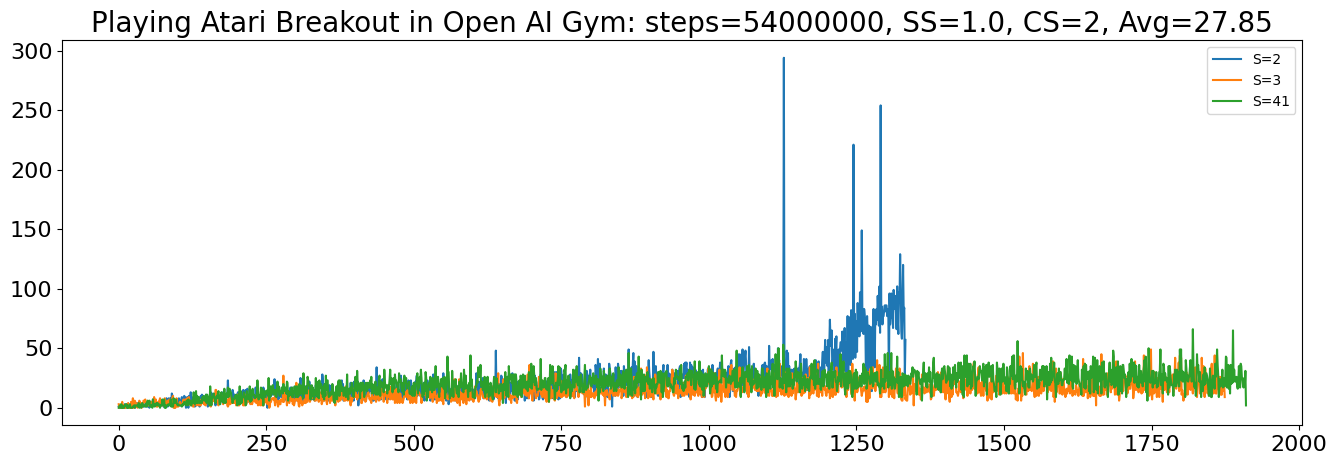

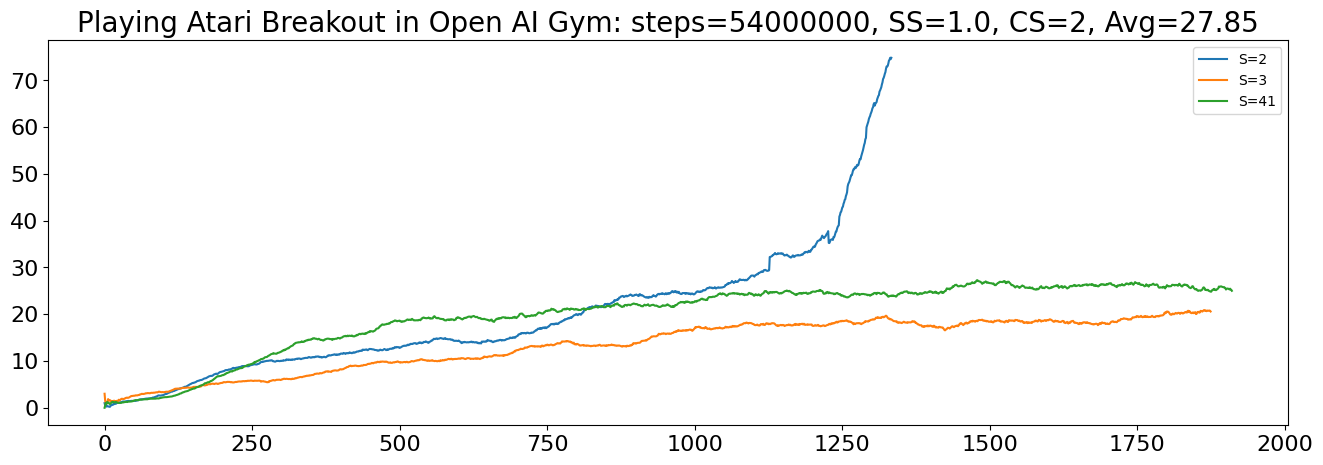

In [95]:
#sim_test3/exp5400000_s2ss10lm2sc2cs2tu0.txt:score_avg=22.2; steps_tot=5400000; steps_avg=4048.0; lives_avg=0.2; lapse_avg="0:00:00.875077"; time="0:26:48.368424"
#sim_test3/exp5400000_s3ss10lm2sc2cs2tu0.txt:score_avg=14.0; steps_tot=5400000; steps_avg=2880.0; lives_avg=0.1; lapse_avg="0:00:02.817442"; time="0:26:48.185930"
#sim_test3/exp5400000_s41ss10lm2sc2cs2tu0.txt:score_avg=20.4; steps_tot=5400000; steps_avg=2825.7; lives_avg=0.0; lapse_avg="0:00:00.144517"; time="0:24:39.861016"

s2ss10lm2sc2cs2tu0 = [1.0, 0, 0, 0, 1.0, 0, 0, 0, 0, 0, 3.0, 2.0, 0, 2.0, 2.0, 0, 3.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 0, 2.0, 1.0, 2.0, 2.0, 0, 3.0, 3.0, 4.0, 1.0, 1.0, 1.0, 3.0, 1.0, 3.0, 3.0, 1.0, 3.0, 1.0, 1.0, 1.0, 3.0, 2.0, 1.0, 2.0, 1.0, 2.0, 2.0, 2.0, 0, 2.0, 5.0, 3.0, 2.0, 4.0, 7.0, 3.0, 5.0, 3.0, 2.0, 3.0, 2.0, 2.0, 4.0, 2.0, 5.0, 2.0, 5.0, 3.0, 2.0, 2.0, 3.0, 4.0, 1.0, 1.0, 7.0, 3.0, 3.0, 8.0, 7.0, 1.0, 5.0, 8.0, 5.0, 7.0, 8.0, 4.0, 12.0, 10.0, 2.0, 3.0, 2.0, 0, 6.0, 4.0, 6.0, 4.0, 5.0, 6.0, 8.0, 5.0, 2.0, 2.0, 7.0, 9.0, 7.0, 5.0, 4.0, 10.0, 9.0, 5.0, 0, 6.0, 9.0, 7.0, 0, 10.0, 8.0, 6.0, 13.0, 2.0, 9.0, 5.0, 3.0, 8.0, 9.0, 1.0, 8.0, 9.0, 2.0, 7.0, 8.0, 8.0, 8.0, 1.0, 6.0, 10.0, 8.0, 11.0, 8.0, 8.0, 10.0, 9.0, 9.0, 5.0, 11.0, 8.0, 4.0, 1.0, 9.0, 5.0, 8.0, 11.0, 13.0, 9.0, 12.0, 6.0, 6.0, 11.0, 6.0, 6.0, 2.0, 7.0, 9.0, 11.0, 12.0, 8.0, 8.0, 6.0, 4.0, 11.0, 8.0, 13.0, 9.0, 8.0, 10.0, 6.0, 8.0, 6.0, 6.0, 11.0, 10.0, 23.0, 11.0, 10.0, 13.0, 11.0, 7.0, 8.0, 7.0, 15.0, 12.0, 9.0, 11.0, 6.0, 9.0, 8.0, 11.0, 8.0, 13.0, 6.0, 13.0, 8.0, 8.0, 11.0, 5.0, 8.0, 11.0, 15.0, 4.0, 9.0, 7.0, 15.0, 12.0, 6.0, 16.0, 5.0, 8.0, 8.0, 11.0, 11.0, 8.0, 7.0, 6.0, 14.0, 7.0, 7.0, 9.0, 8.0, 17.0, 10.0, 11.0, 7.0, 4.0, 7.0, 6.0, 7.0, 7.0, 11.0, 5.0, 12.0, 6.0, 17.0, 15.0, 14.0, 12.0, 13.0, 10.0, 12.0, 0, 11.0, 11.0, 6.0, 11.0, 9.0, 12.0, 13.0, 12.0, 11.0, 12.0, 14.0, 24.0, 7.0, 11.0, 20.0, 6.0, 18.0, 6.0, 10.0, 8.0, 12.0, 13.0, 14.0, 9.0, 10.0, 10.0, 11.0, 7.0, 6.0, 14.0, 8.0, 8.0, 7.0, 11.0, 7.0, 8.0, 8.0, 14.0, 17.0, 11.0, 9.0, 17.0, 5.0, 9.0, 6.0, 12.0, 14.0, 6.0, 11.0, 14.0, 18.0, 7.0, 8.0, 6.0, 15.0, 25.0, 7.0, 8.0, 6.0, 15.0, 4.0, 10.0, 7.0, 18.0, 10.0, 7.0, 15.0, 8.0, 7.0, 8.0, 22.0, 11.0, 8.0, 12.0, 7.0, 17.0, 8.0, 8.0, 8.0, 6.0, 8.0, 19.0, 11.0, 7.0, 8.0, 12.0, 7.0, 12.0, 11.0, 7.0, 10.0, 6.0, 28.0, 22.0, 12.0, 6.0, 7.0, 14.0, 10.0, 10.0, 12.0, 7.0, 12.0, 6.0, 19.0, 18.0, 7.0, 15.0, 15.0, 10.0, 15.0, 10.0, 12.0, 11.0, 8.0, 13.0, 12.0, 11.0, 14.0, 14.0, 6.0, 7.0, 16.0, 15.0, 22.0, 23.0, 9.0, 20.0, 6.0, 8.0, 10.0, 10.0, 14.0, 12.0, 11.0, 8.0, 16.0, 15.0, 8.0, 6.0, 21.0, 6.0, 12.0, 8.0, 15.0, 6.0, 22.0, 17.0, 13.0, 13.0, 12.0, 12.0, 22.0, 2.0, 10.0, 14.0, 15.0, 16.0, 10.0, 7.0, 6.0, 13.0, 23.0, 8.0, 9.0, 8.0, 6.0, 17.0, 12.0, 15.0, 12.0, 14.0, 16.0, 14.0, 18.0, 19.0, 9.0, 6.0, 19.0, 6.0, 17.0, 15.0, 10.0, 7.0, 34.0, 7.0, 11.0, 9.0, 8.0, 15.0, 13.0, 7.0, 16.0, 17.0, 24.0, 14.0, 15.0, 12.0, 9.0, 10.0, 7.0, 7.0, 8.0, 7.0, 13.0, 11.0, 8.0, 15.0, 8.0, 8.0, 8.0, 19.0, 8.0, 16.0, 21.0, 9.0, 8.0, 6.0, 16.0, 21.0, 16.0, 15.0, 9.0, 10.0, 10.0, 27.0, 22.0, 6.0, 14.0, 18.0, 16.0, 13.0, 12.0, 10.0, 20.0, 17.0, 7.0, 20.0, 23.0, 16.0, 12.0, 6.0, 23.0, 6.0, 11.0, 10.0, 14.0, 7.0, 21.0, 18.0, 22.0, 19.0, 27.0, 10.0, 13.0, 12.0, 21.0, 12.0, 12.0, 10.0, 20.0, 17.0, 13.0, 16.0, 21.0, 6.0, 18.0, 12.0, 13.0, 15.0, 23.0, 16.0, 17.0, 18.0, 15.0, 6.0, 9.0, 15.0, 19.0, 15.0, 28.0, 7.0, 17.0, 7.0, 18.0, 18.0, 7.0, 20.0, 20.0, 11.0, 15.0, 19.0, 12.0, 12.0, 13.0, 7.0, 12.0, 29.0, 16.0, 13.0, 20.0, 18.0, 6.0, 20.0, 24.0, 25.0, 3.0, 12.0, 16.0, 15.0, 7.0, 6.0, 16.0, 18.0, 21.0, 17.0, 12.0, 6.0, 9.0, 19.0, 13.0, 7.0, 16.0, 11.0, 23.0, 9.0, 19.0, 8.0, 8.0, 16.0, 17.0, 13.0, 14.0, 9.0, 6.0, 18.0, 11.0, 13.0, 7.0, 15.0, 8.0, 10.0, 20.0, 9.0, 7.0, 8.0, 16.0, 15.0, 8.0, 12.0, 8.0, 8.0, 15.0, 29.0, 11.0, 17.0, 16.0, 22.0, 8.0, 8.0, 15.0, 18.0, 16.0, 12.0, 25.0, 8.0, 16.0, 19.0, 17.0, 16.0, 8.0, 25.0, 17.0, 8.0, 15.0, 6.0, 15.0, 12.0, 8.0, 18.0, 15.0, 15.0, 7.0, 16.0, 13.0, 11.0, 48.0, 15.0, 25.0, 14.0, 8.0, 20.0, 19.0, 6.0, 15.0, 27.0, 26.0, 17.0, 14.0, 11.0, 19.0, 9.0, 14.0, 4.0, 21.0, 14.0, 15.0, 10.0, 27.0, 14.0, 8.0, 15.0, 21.0, 14.0, 29.0, 15.0, 21.0, 11.0, 6.0, 13.0, 6.0, 18.0, 16.0, 7.0, 22.0, 14.0, 21.0, 18.0, 17.0, 16.0, 21.0, 18.0, 14.0, 17.0, 23.0, 6.0, 15.0, 8.0, 20.0, 8.0, 17.0, 14.0, 8.0, 14.0, 25.0, 16.0, 21.0, 21.0, 34.0, 19.0, 6.0, 17.0, 27.0, 22.0, 23.0, 21.0, 12.0, 18.0, 16.0, 7.0, 8.0, 15.0, 28.0, 18.0, 21.0, 8.0, 7.0, 18.0, 21.0, 18.0, 17.0, 20.0, 22.0, 8.0, 23.0, 22.0, 21.0, 23.0, 20.0, 14.0, 30.0, 33.0, 11.0, 8.0, 17.0, 28.0, 30.0, 25.0, 19.0, 30.0, 15.0, 18.0, 7.0, 24.0, 16.0, 8.0, 33.0, 31.0, 18.0, 24.0, 20.0, 28.0, 25.0, 21.0, 22.0, 18.0, 9.0, 19.0, 13.0, 15.0, 24.0, 10.0, 28.0, 17.0, 15.0, 23.0, 19.0, 28.0, 19.0, 18.0, 9.0, 32.0, 14.0, 16.0, 31.0, 23.0, 19.0, 42.0, 15.0, 15.0, 29.0, 19.0, 28.0, 17.0, 18.0, 20.0, 11.0, 23.0, 9.0, 21.0, 31.0, 27.0, 19.0, 20.0, 27.0, 26.0, 32.0, 18.0, 17.0, 17.0, 21.0, 27.0, 24.0, 13.0, 18.0, 36.0, 31.0, 30.0, 19.0, 41.0, 17.0, 22.0, 37.0, 28.0, 25.0, 23.0, 15.0, 25.0, 18.0, 33.0, 14.0, 22.0, 28.0, 18.0, 21.0, 9.0, 19.0, 20.0, 37.0, 33.0, 29.0, 27.0, 13.0, 1.0, 20.0, 18.0, 22.0, 27.0, 10.0, 34.0, 20.0, 27.0, 14.0, 37.0, 33.0, 23.0, 31.0, 17.0, 28.0, 31.0, 18.0, 28.0, 10.0, 35.0, 29.0, 22.0, 24.0, 20.0, 19.0, 29.0, 22.0, 49.0, 19.0, 16.0, 27.0, 24.0, 34.0, 19.0, 36.0, 46.0, 10.0, 39.0, 30.0, 18.0, 35.0, 28.0, 9.0, 28.0, 25.0, 23.0, 29.0, 30.0, 13.0, 22.0, 24.0, 25.0, 20.0, 26.0, 23.0, 11.0, 27.0, 9.0, 20.0, 23.0, 30.0, 40.0, 30.0, 24.0, 22.0, 9.0, 11.0, 17.0, 19.0, 47.0, 26.0, 21.0, 17.0, 35.0, 20.0, 29.0, 11.0, 10.0, 30.0, 21.0, 20.0, 24.0, 25.0, 9.0, 18.0, 30.0, 36.0, 19.0, 21.0, 22.0, 21.0, 28.0, 27.0, 36.0, 21.0, 29.0, 26.0, 17.0, 28.0, 24.0, 26.0, 32.0, 21.0, 18.0, 22.0, 29.0, 27.0, 24.0, 29.0, 26.0, 31.0, 18.0, 25.0, 33.0, 35.0, 9.0, 29.0, 27.0, 25.0, 25.0, 25.0, 37.0, 25.0, 38.0, 33.0, 38.0, 12.0, 32.0, 29.0, 31.0, 9.0, 38.0, 9.0, 36.0, 33.0, 23.0, 34.0, 11.0, 21.0, 11.0, 32.0, 30.0, 27.0, 27.0, 26.0, 25.0, 23.0, 18.0, 31.0, 11.0, 31.0, 22.0, 9.0, 32.0, 15.0, 19.0, 9.0, 25.0, 21.0, 25.0, 18.0, 32.0, 33.0, 34.0, 31.0, 29.0, 22.0, 29.0, 21.0, 36.0, 29.0, 13.0, 28.0, 29.0, 29.0, 26.0, 21.0, 29.0, 33.0, 15.0, 20.0, 31.0, 38.0, 22.0, 31.0, 34.0, 31.0, 30.0, 30.0, 18.0, 14.0, 30.0, 29.0, 22.0, 25.0, 27.0, 35.0, 29.0, 9.0, 14.0, 37.0, 40.0, 22.0, 25.0, 14.0, 26.0, 33.0, 21.0, 34.0, 23.0, 35.0, 24.0, 28.0, 37.0, 45.0, 38.0, 26.0, 34.0, 45.0, 19.0, 49.0, 26.0, 32.0, 40.0, 43.0, 48.0, 37.0, 14.0, 24.0, 11.0, 19.0, 51.0, 29.0, 18.0, 28.0, 28.0, 34.0, 34.0, 25.0, 37.0, 29.0, 24.0, 22.0, 26.0, 29.0, 26.0, 24.0, 10.0, 26.0, 23.0, 27.0, 16.0, 25.0, 35.0, 36.0, 26.0, 25.0, 37.0, 38.0, 34.0, 19.0, 35.0, 30.0, 26.0, 15.0, 52.0, 32.0, 33.0, 35.0, 40.0, 25.0, 41.0, 29.0, 36.0, 35.0, 29.0, 36.0, 28.0, 23.0, 23.0, 50.0, 35.0, 40.0, 23.0, 17.0, 29.0, 28.0, 35.0, 30.0, 30.0, 294.0, 34.0, 32.0, 30.0, 30.0, 48.0, 36.0, 46.0, 15.0, 35.0, 18.0, 31.0, 25.0, 32.0, 28.0, 17.0, 32.0, 26.0, 33.0, 28.0, 23.0, 29.0, 30.0, 17.0, 33.0, 26.0, 32.0, 36.0, 45.0, 31.0, 29.0, 23.0, 24.0, 26.0, 41.0, 34.0, 35.0, 22.0, 41.0, 31.0, 15.0, 24.0, 32.0, 34.0, 35.0, 34.0, 33.0, 34.0, 36.0, 26.0, 30.0, 25.0, 23.0, 34.0, 40.0, 19.0, 26.0, 31.0, 38.0, 39.0, 22.0, 31.0, 23.0, 34.0, 26.0, 40.0, 47.0, 31.0, 19.0, 42.0, 57.0, 38.0, 51.0, 48.0, 35.0, 57.0, 20.0, 52.0, 74.0, 57.0, 52.0, 65.0, 36.0, 40.0, 41.0, 49.0, 23.0, 58.0, 50.0, 60.0, 20.0, 22.0, 30.0, 49.0, 23.0, 48.0, 55.0, 55.0, 48.0, 64.0, 42.0, 31.0, 59.0, 67.0, 40.0, 55.0, 28.0, 40.0, 77.0, 28.0, 51.0, 76.0, 69.0, 36.0, 82.0, 56.0, 55.0, 41.0, 221.0, 61.0, 79.0, 42.0, 73.0, 68.0, 47.0, 88.0, 64.0, 87.0, 60.0, 97.0, 64.0, 70.0, 149.0, 78.0, 67.0, 62.0, 83.0, 78.0, 73.0, 30.0, 57.0, 77.0, 65.0, 31.0, 69.0, 51.0, 14.0, 68.0, 66.0, 14.0, 35.0, 69.0, 83.0, 63.0, 34.0, 82.0, 70.0, 83.0, 74.0, 94.0, 82.0, 69.0, 102.0, 63.0, 254.0, 83.0, 85.0, 70.0, 77.0, 77.0, 83.0, 86.0, 81.0, 86.0, 86.0, 77.0, 83.0, 81.0, 19.0, 96.0, 70.0, 83.0, 96.0, 76.0, 76.0, 67.0, 99.0, 83.0, 83.0, 94.0, 80.0, 66.0, 102.0, 74.0, 62.0, 97.0, 90.0, 129.0, 95.0, 64.0, 58.0, 81.0, 120.0, 81.0, 84.0, 27.0, 57.0]
s3ss10lm2sc2cs2tu0 = [3.0, 0, 0, 2.0, 0, 3.0, 5.0, 0, 2.0, 0, 2.0, 0, 0, 3.0, 1.0, 1.0, 4.0, 0, 0, 2.0, 0, 5.0, 0, 2.0, 8.0, 0, 0, 6.0, 5.0, 4.0, 1.0, 2.0, 0, 4.0, 3.0, 6.0, 4.0, 3.0, 4.0, 0, 3.0, 3.0, 6.0, 6.0, 5.0, 7.0, 3.0, 2.0, 5.0, 3.0, 4.0, 2.0, 5.0, 5.0, 2.0, 2.0, 5.0, 5.0, 4.0, 3.0, 9.0, 4.0, 6.0, 7.0, 1.0, 4.0, 1.0, 5.0, 5.0, 6.0, 8.0, 2.0, 4.0, 6.0, 2.0, 2.0, 3.0, 2.0, 8.0, 6.0, 3.0, 2.0, 4.0, 6.0, 3.0, 4.0, 7.0, 5.0, 5.0, 2.0, 5.0, 9.0, 10.0, 0, 2.0, 0, 0, 2.0, 8.0, 1.0, 2.0, 1.0, 2.0, 4.0, 5.0, 3.0, 3.0, 2.0, 2.0, 6.0, 7.0, 4.0, 6.0, 7.0, 7.0, 6.0, 8.0, 8.0, 6.0, 9.0, 4.0, 3.0, 2.0, 5.0, 5.0, 3.0, 1.0, 1.0, 7.0, 7.0, 6.0, 7.0, 2.0, 6.0, 5.0, 5.0, 2.0, 7.0, 2.0, 2.0, 6.0, 5.0, 4.0, 6.0, 3.0, 3.0, 7.0, 2.0, 6.0, 10.0, 7.0, 9.0, 4.0, 4.0, 4.0, 2.0, 1.0, 8.0, 3.0, 9.0, 6.0, 6.0, 7.0, 9.0, 15.0, 15.0, 6.0, 5.0, 4.0, 2.0, 7.0, 6.0, 8.0, 6.0, 9.0, 10.0, 7.0, 3.0, 6.0, 4.0, 10.0, 6.0, 6.0, 7.0, 2.0, 1.0, 2.0, 12.0, 9.0, 3.0, 5.0, 4.0, 4.0, 7.0, 6.0, 4.0, 5.0, 4.0, 10.0, 2.0, 3.0, 11.0, 7.0, 2.0, 2.0, 4.0, 6.0, 4.0, 6.0, 6.0, 8.0, 2.0, 6.0, 2.0, 4.0, 11.0, 3.0, 5.0, 6.0, 9.0, 7.0, 5.0, 8.0, 3.0, 5.0, 9.0, 3.0, 5.0, 7.0, 6.0, 7.0, 5.0, 6.0, 4.0, 11.0, 6.0, 2.0, 4.0, 6.0, 4.0, 2.0, 9.0, 9.0, 2.0, 7.0, 2.0, 7.0, 4.0, 10.0, 6.0, 5.0, 7.0, 3.0, 4.0, 10.0, 0, 1.0, 7.0, 5.0, 7.0, 8.0, 8.0, 7.0, 8.0, 6.0, 2.0, 13.0, 5.0, 6.0, 4.0, 1.0, 4.0, 6.0, 3.0, 3.0, 7.0, 6.0, 7.0, 5.0, 27.0, 5.0, 13.0, 9.0, 9.0, 10.0, 2.0, 8.0, 6.0, 6.0, 4.0, 11.0, 9.0, 6.0, 6.0, 8.0, 3.0, 7.0, 2.0, 4.0, 7.0, 7.0, 21.0, 6.0, 8.0, 7.0, 2.0, 1.0, 6.0, 9.0, 4.0, 6.0, 2.0, 4.0, 4.0, 4.0, 7.0, 4.0, 4.0, 17.0, 5.0, 5.0, 9.0, 9.0, 15.0, 5.0, 7.0, 9.0, 11.0, 8.0, 10.0, 13.0, 7.0, 6.0, 6.0, 6.0, 8.0, 8.0, 10.0, 7.0, 5.0, 11.0, 7.0, 13.0, 8.0, 3.0, 5.0, 7.0, 13.0, 6.0, 9.0, 9.0, 9.0, 5.0, 3.0, 14.0, 11.0, 9.0, 9.0, 4.0, 10.0, 13.0, 6.0, 6.0, 6.0, 12.0, 11.0, 9.0, 2.0, 8.0, 10.0, 9.0, 8.0, 5.0, 10.0, 16.0, 6.0, 10.0, 7.0, 8.0, 16.0, 10.0, 12.0, 6.0, 8.0, 6.0, 18.0, 14.0, 11.0, 6.0, 10.0, 10.0, 11.0, 5.0, 2.0, 8.0, 5.0, 9.0, 8.0, 16.0, 13.0, 9.0, 14.0, 9.0, 11.0, 7.0, 10.0, 9.0, 12.0, 13.0, 9.0, 19.0, 4.0, 4.0, 9.0, 19.0, 10.0, 7.0, 10.0, 5.0, 6.0, 9.0, 10.0, 12.0, 13.0, 10.0, 7.0, 8.0, 6.0, 4.0, 13.0, 8.0, 8.0, 9.0, 7.0, 8.0, 16.0, 5.0, 9.0, 12.0, 16.0, 8.0, 6.0, 17.0, 7.0, 8.0, 13.0, 16.0, 12.0, 11.0, 5.0, 14.0, 11.0, 13.0, 10.0, 11.0, 4.0, 18.0, 12.0, 9.0, 15.0, 7.0, 10.0, 18.0, 8.0, 7.0, 7.0, 9.0, 15.0, 4.0, 8.0, 16.0, 8.0, 4.0, 8.0, 13.0, 10.0, 4.0, 12.0, 8.0, 8.0, 5.0, 4.0, 6.0, 8.0, 12.0, 10.0, 13.0, 9.0, 13.0, 15.0, 11.0, 7.0, 10.0, 9.0, 4.0, 13.0, 14.0, 10.0, 4.0, 10.0, 6.0, 5.0, 17.0, 11.0, 4.0, 11.0, 14.0, 13.0, 12.0, 13.0, 11.0, 10.0, 10.0, 4.0, 11.0, 11.0, 11.0, 11.0, 11.0, 13.0, 18.0, 9.0, 8.0, 11.0, 10.0, 14.0, 12.0, 8.0, 9.0, 11.0, 17.0, 10.0, 5.0, 10.0, 21.0, 15.0, 14.0, 8.0, 10.0, 4.0, 8.0, 6.0, 12.0, 6.0, 7.0, 9.0, 12.0, 6.0, 20.0, 6.0, 3.0, 13.0, 18.0, 8.0, 14.0, 13.0, 8.0, 8.0, 7.0, 10.0, 10.0, 12.0, 14.0, 5.0, 6.0, 12.0, 14.0, 6.0, 9.0, 24.0, 6.0, 9.0, 9.0, 17.0, 4.0, 11.0, 6.0, 24.0, 2.0, 13.0, 7.0, 12.0, 11.0, 13.0, 4.0, 15.0, 8.0, 19.0, 10.0, 3.0, 11.0, 16.0, 7.0, 13.0, 6.0, 10.0, 14.0, 12.0, 7.0, 10.0, 12.0, 5.0, 11.0, 11.0, 18.0, 10.0, 14.0, 11.0, 11.0, 7.0, 5.0, 9.0, 7.0, 15.0, 16.0, 14.0, 12.0, 9.0, 9.0, 8.0, 8.0, 15.0, 8.0, 13.0, 7.0, 10.0, 18.0, 9.0, 11.0, 17.0, 6.0, 8.0, 17.0, 5.0, 18.0, 11.0, 10.0, 19.0, 11.0, 11.0, 9.0, 19.0, 9.0, 29.0, 6.0, 2.0, 11.0, 7.0, 12.0, 16.0, 9.0, 12.0, 24.0, 8.0, 9.0, 10.0, 14.0, 11.0, 15.0, 18.0, 20.0, 11.0, 7.0, 11.0, 8.0, 4.0, 10.0, 9.0, 8.0, 19.0, 11.0, 9.0, 11.0, 15.0, 5.0, 4.0, 18.0, 16.0, 13.0, 11.0, 12.0, 13.0, 9.0, 20.0, 12.0, 14.0, 20.0, 24.0, 11.0, 12.0, 18.0, 10.0, 18.0, 28.0, 12.0, 8.0, 36.0, 12.0, 15.0, 14.0, 11.0, 6.0, 21.0, 14.0, 22.0, 22.0, 11.0, 8.0, 11.0, 10.0, 10.0, 13.0, 26.0, 14.0, 15.0, 15.0, 11.0, 23.0, 9.0, 14.0, 13.0, 22.0, 8.0, 16.0, 9.0, 5.0, 13.0, 14.0, 11.0, 5.0, 12.0, 8.0, 18.0, 8.0, 10.0, 14.0, 15.0, 13.0, 7.0, 6.0, 29.0, 28.0, 8.0, 14.0, 10.0, 14.0, 11.0, 10.0, 23.0, 9.0, 22.0, 9.0, 12.0, 11.0, 10.0, 19.0, 17.0, 11.0, 9.0, 9.0, 23.0, 10.0, 16.0, 12.0, 20.0, 9.0, 16.0, 19.0, 10.0, 11.0, 13.0, 9.0, 8.0, 31.0, 15.0, 23.0, 17.0, 15.0, 14.0, 9.0, 14.0, 15.0, 15.0, 13.0, 19.0, 15.0, 12.0, 19.0, 13.0, 13.0, 1.0, 14.0, 11.0, 10.0, 17.0, 17.0, 2.0, 14.0, 11.0, 9.0, 23.0, 9.0, 12.0, 10.0, 12.0, 11.0, 8.0, 13.0, 10.0, 14.0, 11.0, 17.0, 11.0, 20.0, 11.0, 12.0, 16.0, 16.0, 16.0, 13.0, 11.0, 16.0, 10.0, 13.0, 2.0, 14.0, 11.0, 15.0, 13.0, 11.0, 10.0, 9.0, 7.0, 16.0, 14.0, 15.0, 12.0, 24.0, 10.0, 11.0, 15.0, 19.0, 10.0, 16.0, 12.0, 16.0, 10.0, 11.0, 15.0, 14.0, 14.0, 24.0, 8.0, 11.0, 20.0, 14.0, 17.0, 13.0, 14.0, 17.0, 9.0, 17.0, 11.0, 12.0, 11.0, 12.0, 14.0, 10.0, 13.0, 16.0, 8.0, 13.0, 9.0, 26.0, 12.0, 17.0, 12.0, 10.0, 25.0, 11.0, 9.0, 17.0, 14.0, 11.0, 12.0, 33.0, 12.0, 11.0, 17.0, 13.0, 13.0, 13.0, 8.0, 27.0, 14.0, 34.0, 24.0, 8.0, 11.0, 16.0, 13.0, 9.0, 24.0, 12.0, 13.0, 11.0, 7.0, 16.0, 21.0, 28.0, 24.0, 18.0, 12.0, 23.0, 12.0, 13.0, 19.0, 22.0, 7.0, 29.0, 16.0, 28.0, 15.0, 16.0, 14.0, 23.0, 28.0, 25.0, 9.0, 15.0, 14.0, 8.0, 8.0, 14.0, 14.0, 18.0, 21.0, 27.0, 32.0, 29.0, 11.0, 10.0, 14.0, 23.0, 20.0, 12.0, 12.0, 19.0, 8.0, 13.0, 15.0, 12.0, 15.0, 16.0, 21.0, 10.0, 14.0, 21.0, 10.0, 11.0, 17.0, 27.0, 15.0, 11.0, 18.0, 28.0, 13.0, 13.0, 25.0, 7.0, 18.0, 21.0, 25.0, 11.0, 14.0, 13.0, 10.0, 17.0, 19.0, 13.0, 22.0, 12.0, 10.0, 16.0, 12.0, 24.0, 26.0, 13.0, 9.0, 19.0, 19.0, 19.0, 9.0, 21.0, 16.0, 17.0, 18.0, 25.0, 20.0, 33.0, 25.0, 33.0, 13.0, 25.0, 13.0, 9.0, 10.0, 24.0, 14.0, 13.0, 29.0, 9.0, 6.0, 21.0, 15.0, 15.0, 9.0, 26.0, 32.0, 11.0, 20.0, 5.0, 14.0, 18.0, 16.0, 29.0, 13.0, 20.0, 9.0, 21.0, 15.0, 13.0, 9.0, 22.0, 13.0, 15.0, 33.0, 25.0, 36.0, 20.0, 15.0, 16.0, 22.0, 16.0, 10.0, 13.0, 9.0, 15.0, 14.0, 16.0, 18.0, 19.0, 34.0, 11.0, 10.0, 18.0, 13.0, 14.0, 15.0, 15.0, 27.0, 16.0, 15.0, 26.0, 29.0, 12.0, 26.0, 9.0, 16.0, 16.0, 18.0, 14.0, 29.0, 16.0, 19.0, 23.0, 17.0, 24.0, 15.0, 24.0, 22.0, 14.0, 26.0, 24.0, 14.0, 22.0, 25.0, 26.0, 10.0, 14.0, 12.0, 13.0, 21.0, 19.0, 15.0, 18.0, 12.0, 20.0, 10.0, 33.0, 20.0, 17.0, 10.0, 24.0, 14.0, 16.0, 14.0, 10.0, 11.0, 10.0, 29.0, 25.0, 21.0, 20.0, 9.0, 11.0, 26.0, 10.0, 22.0, 14.0, 37.0, 21.0, 15.0, 11.0, 17.0, 14.0, 25.0, 11.0, 10.0, 30.0, 24.0, 11.0, 13.0, 19.0, 13.0, 9.0, 20.0, 12.0, 24.0, 14.0, 10.0, 29.0, 12.0, 18.0, 18.0, 16.0, 14.0, 7.0, 12.0, 25.0, 16.0, 13.0, 19.0, 16.0, 16.0, 24.0, 18.0, 10.0, 19.0, 25.0, 12.0, 26.0, 13.0, 13.0, 28.0, 15.0, 23.0, 18.0, 25.0, 22.0, 8.0, 34.0, 11.0, 16.0, 27.0, 16.0, 23.0, 12.0, 38.0, 15.0, 26.0, 20.0, 29.0, 10.0, 13.0, 37.0, 9.0, 16.0, 15.0, 13.0, 15.0, 20.0, 10.0, 21.0, 17.0, 17.0, 15.0, 18.0, 12.0, 10.0, 14.0, 16.0, 13.0, 30.0, 22.0, 8.0, 10.0, 12.0, 24.0, 11.0, 9.0, 25.0, 21.0, 11.0, 14.0, 11.0, 34.0, 14.0, 24.0, 13.0, 24.0, 22.0, 20.0, 20.0, 22.0, 17.0, 26.0, 26.0, 18.0, 20.0, 23.0, 29.0, 18.0, 9.0, 20.0, 16.0, 15.0, 25.0, 23.0, 24.0, 22.0, 14.0, 11.0, 37.0, 17.0, 20.0, 17.0, 6.0, 23.0, 15.0, 25.0, 13.0, 14.0, 18.0, 18.0, 26.0, 22.0, 18.0, 14.0, 10.0, 13.0, 14.0, 17.0, 15.0, 18.0, 14.0, 13.0, 5.0, 16.0, 5.0, 30.0, 20.0, 8.0, 27.0, 33.0, 17.0, 21.0, 16.0, 34.0, 19.0, 19.0, 19.0, 14.0, 18.0, 23.0, 40.0, 20.0, 24.0, 18.0, 36.0, 9.0, 21.0, 9.0, 20.0, 15.0, 34.0, 13.0, 26.0, 22.0, 13.0, 17.0, 18.0, 21.0, 24.0, 25.0, 9.0, 28.0, 29.0, 19.0, 11.0, 27.0, 9.0, 20.0, 15.0, 8.0, 18.0, 26.0, 33.0, 28.0, 17.0, 12.0, 28.0, 27.0, 33.0, 30.0, 9.0, 7.0, 6.0, 6.0, 13.0, 27.0, 11.0, 22.0, 7.0, 10.0, 6.0, 6.0, 16.0, 22.0, 24.0, 17.0, 11.0, 18.0, 12.0, 13.0, 14.0, 30.0, 2.0, 20.0, 15.0, 15.0, 14.0, 24.0, 24.0, 29.0, 22.0, 11.0, 16.0, 15.0, 7.0, 7.0, 28.0, 15.0, 16.0, 17.0, 12.0, 13.0, 13.0, 28.0, 13.0, 20.0, 17.0, 17.0, 14.0, 13.0, 20.0, 7.0, 8.0, 20.0, 19.0, 11.0, 10.0, 14.0, 18.0, 21.0, 15.0, 16.0, 24.0, 30.0, 20.0, 18.0, 27.0, 14.0, 13.0, 30.0, 16.0, 28.0, 13.0, 33.0, 17.0, 14.0, 7.0, 22.0, 12.0, 22.0, 34.0, 24.0, 10.0, 5.0, 24.0, 13.0, 9.0, 20.0, 11.0, 24.0, 20.0, 20.0, 27.0, 29.0, 13.0, 13.0, 12.0, 10.0, 13.0, 22.0, 22.0, 17.0, 13.0, 21.0, 23.0, 23.0, 8.0, 12.0, 20.0, 24.0, 18.0, 15.0, 18.0, 10.0, 16.0, 25.0, 24.0, 23.0, 12.0, 20.0, 15.0, 15.0, 19.0, 35.0, 38.0, 16.0, 28.0, 15.0, 12.0, 15.0, 12.0, 28.0, 34.0, 13.0, 21.0, 14.0, 10.0, 11.0, 26.0, 28.0, 10.0, 32.0, 26.0, 24.0, 16.0, 14.0, 35.0, 6.0, 15.0, 9.0, 13.0, 21.0, 8.0, 27.0, 7.0, 26.0, 23.0, 13.0, 18.0, 19.0, 16.0, 21.0, 27.0, 14.0, 15.0, 24.0, 18.0, 11.0, 17.0, 16.0, 27.0, 21.0, 12.0, 22.0, 17.0, 16.0, 12.0, 14.0, 22.0, 12.0, 22.0, 26.0, 25.0, 24.0, 14.0, 12.0, 16.0, 28.0, 12.0, 21.0, 22.0, 27.0, 12.0, 14.0, 20.0, 7.0, 11.0, 10.0, 6.0, 16.0, 16.0, 43.0, 16.0, 28.0, 6.0, 15.0, 10.0, 46.0, 22.0, 17.0, 16.0, 20.0, 12.0, 11.0, 20.0, 19.0, 14.0, 28.0, 35.0, 15.0, 16.0, 16.0, 14.0, 20.0, 37.0, 25.0, 12.0, 9.0, 15.0, 25.0, 10.0, 12.0, 13.0, 26.0, 10.0, 14.0, 15.0, 21.0, 12.0, 17.0, 29.0, 31.0, 14.0, 27.0, 19.0, 18.0, 23.0, 24.0, 22.0, 13.0, 18.0, 22.0, 25.0, 15.0, 16.0, 14.0, 18.0, 28.0, 39.0, 9.0, 19.0, 5.0, 12.0, 33.0, 13.0, 18.0, 25.0, 20.0, 22.0, 12.0, 12.0, 29.0, 24.0, 23.0, 11.0, 24.0, 24.0, 15.0, 14.0, 9.0, 11.0, 16.0, 12.0, 16.0, 14.0, 28.0, 25.0, 12.0, 20.0, 18.0, 25.0, 10.0, 12.0, 14.0, 14.0, 12.0, 11.0, 19.0, 17.0, 13.0, 15.0, 10.0, 14.0, 20.0, 18.0, 20.0, 19.0, 22.0, 10.0, 41.0, 10.0, 19.0, 37.0, 13.0, 30.0, 19.0, 18.0, 8.0, 15.0, 13.0, 22.0, 9.0, 11.0, 21.0, 24.0, 15.0, 10.0, 35.0, 10.0, 13.0, 23.0, 2.0, 33.0, 25.0, 19.0, 14.0, 12.0, 10.0, 18.0, 10.0, 45.0, 16.0, 11.0, 27.0, 11.0, 22.0, 16.0, 15.0, 21.0, 11.0, 11.0, 29.0, 21.0, 21.0, 19.0, 18.0, 13.0, 25.0, 16.0, 18.0, 35.0, 20.0, 19.0, 11.0, 26.0, 39.0, 19.0, 11.0, 22.0, 18.0, 6.0, 10.0, 28.0, 21.0, 21.0, 18.0, 17.0, 14.0, 22.0, 27.0, 26.0, 27.0, 12.0, 24.0, 12.0, 14.0, 23.0, 20.0, 16.0, 16.0, 21.0, 23.0, 31.0, 23.0, 8.0, 13.0, 24.0, 39.0, 15.0, 15.0, 16.0, 17.0, 21.0, 13.0, 17.0, 16.0, 21.0, 16.0, 12.0, 26.0, 13.0, 17.0, 44.0, 15.0, 22.0, 35.0, 33.0, 24.0, 13.0, 11.0, 28.0, 10.0, 20.0, 12.0, 49.0, 12.0, 7.0, 18.0, 18.0, 12.0, 30.0, 15.0, 13.0, 25.0, 9.0, 25.0, 10.0, 22.0, 9.0, 22.0, 27.0, 16.0, 25.0, 16.0, 5.0, 26.0, 15.0, 15.0, 24.0, 26.0, 18.0, 13.0, 16.0, 14.0, 24.0, 13.0, 32.0, 25.0, 19.0, 20.0, 26.0, 28.0, 13.0, 26.0, 26.0, 42.0, 17.0, 16.0, 22.0, 27.0, 25.0, 38.0, 14.0, 44.0, 15.0, 42.0, 11.0, 15.0, 12.0, 6.0, 9.0, 12.0, 10.0, 24.0, 30.0, 21.0, 11.0, 17.0, 25.0, 28.0, 28.0, 15.0, 25.0, 31.0, 17.0, 12.0, 22.0, 21.0, 18.0, 34.0, 13.0, 16.0, 9.0, 20.0, 22.0, 28.0, 26.0, 12.0, 22.0, 12.0, 42.0, 27.0, 14.0, 35.0, 13.0, 9.0, 33.0, 16.0, 19.0, 21.0, 12.0, 22.0, 20.0, 21.0, 11.0, 12.0, 32.0, 37.0, 12.0, 20.0, 12.0, 23.0, 44.0, 19.0, 12.0, 12.0, 23.0, 31.0, 20.0, 15.0, 14.0, 26.0, 11.0, 24.0, 11.0, 21.0, 14.0, 21.0, 20.0, 9.0]
s41ss10lm2sc2cs2tu0 = [0, 1.0, 2.0, 0, 3.0, 0, 2.0, 0, 0, 0, 2.0, 2.0, 3.0, 3.0, 0, 2.0, 0, 0, 2.0, 3.0, 0, 0, 0, 0, 1.0, 1.0, 2.0, 0, 2.0, 2.0, 2.0, 2.0, 1.0, 2.0, 4.0, 0, 3.0, 1.0, 0, 2.0, 4.0, 1.0, 2.0, 2.0, 2.0, 1.0, 2.0, 4.0, 1.0, 6.0, 3.0, 3.0, 6.0, 1.0, 1.0, 2.0, 2.0, 0, 7.0, 3.0, 3.0, 1.0, 2.0, 2.0, 4.0, 2.0, 4.0, 2.0, 3.0, 2.0, 0, 2.0, 2.0, 3.0, 7.0, 2.0, 4.0, 7.0, 0, 2.0, 0, 2.0, 2.0, 2.0, 3.0, 2.0, 2.0, 2.0, 7.0, 1.0, 3.0, 1.0, 1.0, 8.0, 5.0, 4.0, 6.0, 7.0, 4.0, 3.0, 2.0, 3.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0, 3.0, 2.0, 3.0, 5.0, 4.0, 3.0, 2.0, 6.0, 6.0, 2.0, 7.0, 3.0, 4.0, 6.0, 5.0, 2.0, 6.0, 6.0, 4.0, 13.0, 5.0, 3.0, 6.0, 14.0, 4.0, 10.0, 4.0, 7.0, 9.0, 4.0, 4.0, 5.0, 6.0, 4.0, 9.0, 7.0, 10.0, 6.0, 8.0, 6.0, 11.0, 4.0, 11.0, 6.0, 4.0, 9.0, 2.0, 18.0, 7.0, 2.0, 8.0, 9.0, 9.0, 12.0, 8.0, 7.0, 4.0, 7.0, 10.0, 8.0, 12.0, 14.0, 10.0, 3.0, 3.0, 9.0, 13.0, 9.0, 5.0, 8.0, 4.0, 16.0, 6.0, 4.0, 9.0, 12.0, 9.0, 17.0, 9.0, 14.0, 16.0, 13.0, 13.0, 10.0, 7.0, 4.0, 7.0, 7.0, 8.0, 10.0, 8.0, 11.0, 6.0, 2.0, 8.0, 11.0, 3.0, 18.0, 3.0, 14.0, 4.0, 7.0, 9.0, 9.0, 13.0, 10.0, 8.0, 2.0, 3.0, 14.0, 10.0, 9.0, 7.0, 8.0, 18.0, 5.0, 9.0, 6.0, 14.0, 16.0, 11.0, 11.0, 10.0, 8.0, 10.0, 9.0, 11.0, 23.0, 14.0, 7.0, 10.0, 10.0, 10.0, 17.0, 8.0, 16.0, 15.0, 2.0, 14.0, 12.0, 9.0, 14.0, 12.0, 13.0, 15.0, 10.0, 25.0, 6.0, 14.0, 18.0, 10.0, 13.0, 17.0, 19.0, 13.0, 11.0, 15.0, 15.0, 13.0, 9.0, 13.0, 22.0, 14.0, 18.0, 11.0, 10.0, 12.0, 14.0, 17.0, 17.0, 12.0, 20.0, 15.0, 14.0, 17.0, 15.0, 12.0, 22.0, 21.0, 6.0, 14.0, 10.0, 11.0, 11.0, 12.0, 17.0, 9.0, 9.0, 14.0, 13.0, 18.0, 14.0, 9.0, 18.0, 15.0, 9.0, 18.0, 11.0, 20.0, 11.0, 12.0, 18.0, 13.0, 19.0, 8.0, 29.0, 15.0, 12.0, 12.0, 17.0, 18.0, 12.0, 26.0, 23.0, 19.0, 19.0, 17.0, 7.0, 18.0, 19.0, 10.0, 17.0, 9.0, 7.0, 15.0, 11.0, 25.0, 13.0, 10.0, 9.0, 22.0, 8.0, 23.0, 17.0, 17.0, 20.0, 12.0, 15.0, 9.0, 18.0, 7.0, 20.0, 10.0, 27.0, 15.0, 23.0, 23.0, 12.0, 9.0, 10.0, 10.0, 13.0, 11.0, 12.0, 20.0, 17.0, 7.0, 5.0, 4.0, 13.0, 10.0, 18.0, 7.0, 17.0, 22.0, 23.0, 10.0, 23.0, 22.0, 20.0, 14.0, 17.0, 17.0, 10.0, 11.0, 17.0, 13.0, 9.0, 14.0, 28.0, 11.0, 7.0, 15.0, 16.0, 12.0, 17.0, 15.0, 21.0, 14.0, 11.0, 9.0, 13.0, 19.0, 26.0, 17.0, 14.0, 31.0, 19.0, 21.0, 15.0, 17.0, 8.0, 21.0, 14.0, 21.0, 17.0, 21.0, 16.0, 9.0, 14.0, 19.0, 21.0, 16.0, 14.0, 21.0, 17.0, 21.0, 17.0, 23.0, 17.0, 26.0, 12.0, 20.0, 17.0, 19.0, 12.0, 17.0, 22.0, 11.0, 13.0, 17.0, 11.0, 15.0, 25.0, 27.0, 10.0, 22.0, 22.0, 21.0, 18.0, 19.0, 13.0, 32.0, 22.0, 17.0, 19.0, 17.0, 12.0, 19.0, 15.0, 18.0, 24.0, 32.0, 20.0, 25.0, 17.0, 13.0, 21.0, 25.0, 16.0, 28.0, 22.0, 23.0, 21.0, 18.0, 17.0, 13.0, 29.0, 22.0, 22.0, 24.0, 17.0, 14.0, 17.0, 21.0, 11.0, 27.0, 21.0, 21.0, 25.0, 16.0, 19.0, 20.0, 20.0, 22.0, 12.0, 13.0, 12.0, 11.0, 18.0, 10.0, 17.0, 21.0, 10.0, 12.0, 20.0, 20.0, 24.0, 29.0, 12.0, 18.0, 17.0, 26.0, 21.0, 32.0, 25.0, 16.0, 9.0, 17.0, 11.0, 21.0, 14.0, 30.0, 25.0, 6.0, 11.0, 9.0, 19.0, 21.0, 18.0, 26.0, 15.0, 19.0, 13.0, 25.0, 19.0, 15.0, 15.0, 25.0, 35.0, 17.0, 25.0, 22.0, 26.0, 18.0, 9.0, 20.0, 18.0, 24.0, 18.0, 21.0, 25.0, 17.0, 16.0, 26.0, 8.0, 19.0, 13.0, 20.0, 43.0, 30.0, 30.0, 15.0, 8.0, 15.0, 15.0, 10.0, 31.0, 19.0, 9.0, 22.0, 20.0, 18.0, 24.0, 15.0, 12.0, 18.0, 15.0, 9.0, 22.0, 21.0, 17.0, 29.0, 20.0, 18.0, 17.0, 13.0, 32.0, 25.0, 16.0, 27.0, 17.0, 19.0, 16.0, 9.0, 17.0, 21.0, 14.0, 44.0, 19.0, 24.0, 17.0, 9.0, 11.0, 9.0, 8.0, 16.0, 18.0, 18.0, 23.0, 21.0, 34.0, 27.0, 26.0, 26.0, 36.0, 18.0, 18.0, 22.0, 15.0, 20.0, 16.0, 26.0, 9.0, 25.0, 13.0, 13.0, 26.0, 19.0, 9.0, 17.0, 10.0, 21.0, 18.0, 14.0, 9.0, 7.0, 19.0, 26.0, 21.0, 19.0, 13.0, 25.0, 21.0, 20.0, 16.0, 12.0, 16.0, 19.0, 14.0, 20.0, 18.0, 19.0, 4.0, 20.0, 15.0, 20.0, 30.0, 19.0, 10.0, 25.0, 26.0, 9.0, 35.0, 24.0, 27.0, 28.0, 24.0, 21.0, 28.0, 18.0, 11.0, 28.0, 28.0, 11.0, 28.0, 22.0, 17.0, 9.0, 18.0, 17.0, 23.0, 11.0, 27.0, 21.0, 9.0, 22.0, 28.0, 17.0, 22.0, 27.0, 17.0, 16.0, 21.0, 22.0, 14.0, 18.0, 30.0, 24.0, 18.0, 17.0, 37.0, 16.0, 24.0, 22.0, 35.0, 28.0, 19.0, 20.0, 25.0, 16.0, 15.0, 15.0, 16.0, 16.0, 16.0, 16.0, 41.0, 15.0, 22.0, 23.0, 18.0, 17.0, 18.0, 25.0, 25.0, 16.0, 16.0, 15.0, 16.0, 25.0, 5.0, 15.0, 36.0, 20.0, 22.0, 21.0, 35.0, 26.0, 18.0, 18.0, 7.0, 16.0, 21.0, 14.0, 20.0, 24.0, 35.0, 19.0, 34.0, 27.0, 18.0, 13.0, 16.0, 17.0, 23.0, 15.0, 32.0, 30.0, 36.0, 12.0, 23.0, 17.0, 21.0, 27.0, 17.0, 22.0, 8.0, 12.0, 19.0, 14.0, 19.0, 32.0, 28.0, 17.0, 31.0, 22.0, 27.0, 35.0, 21.0, 19.0, 19.0, 26.0, 13.0, 20.0, 28.0, 24.0, 19.0, 13.0, 18.0, 13.0, 26.0, 36.0, 17.0, 15.0, 17.0, 18.0, 17.0, 21.0, 23.0, 27.0, 26.0, 20.0, 18.0, 25.0, 21.0, 29.0, 21.0, 20.0, 25.0, 25.0, 27.0, 18.0, 17.0, 24.0, 6.0, 17.0, 13.0, 33.0, 26.0, 27.0, 17.0, 17.0, 14.0, 31.0, 26.0, 17.0, 25.0, 19.0, 26.0, 27.0, 18.0, 18.0, 27.0, 33.0, 26.0, 16.0, 18.0, 26.0, 21.0, 29.0, 14.0, 20.0, 20.0, 21.0, 14.0, 23.0, 18.0, 18.0, 34.0, 27.0, 19.0, 28.0, 26.0, 17.0, 20.0, 18.0, 31.0, 26.0, 16.0, 28.0, 27.0, 32.0, 22.0, 28.0, 9.0, 46.0, 22.0, 12.0, 11.0, 33.0, 21.0, 10.0, 16.0, 15.0, 18.0, 23.0, 12.0, 26.0, 17.0, 29.0, 21.0, 23.0, 43.0, 22.0, 31.0, 19.0, 7.0, 32.0, 19.0, 14.0, 26.0, 28.0, 14.0, 26.0, 24.0, 22.0, 23.0, 30.0, 20.0, 25.0, 19.0, 16.0, 24.0, 19.0, 20.0, 13.0, 18.0, 25.0, 19.0, 20.0, 12.0, 18.0, 17.0, 20.0, 20.0, 30.0, 22.0, 22.0, 21.0, 31.0, 26.0, 13.0, 29.0, 9.0, 14.0, 18.0, 29.0, 29.0, 29.0, 31.0, 19.0, 18.0, 18.0, 25.0, 23.0, 19.0, 20.0, 17.0, 18.0, 16.0, 13.0, 13.0, 25.0, 20.0, 22.0, 32.0, 28.0, 26.0, 26.0, 24.0, 24.0, 23.0, 33.0, 20.0, 36.0, 22.0, 16.0, 19.0, 14.0, 16.0, 22.0, 17.0, 26.0, 26.0, 27.0, 29.0, 23.0, 29.0, 32.0, 28.0, 26.0, 19.0, 31.0, 26.0, 27.0, 27.0, 16.0, 39.0, 15.0, 22.0, 25.0, 29.0, 30.0, 24.0, 20.0, 39.0, 18.0, 18.0, 30.0, 17.0, 15.0, 28.0, 10.0, 15.0, 24.0, 29.0, 28.0, 18.0, 27.0, 28.0, 22.0, 35.0, 25.0, 12.0, 16.0, 32.0, 18.0, 30.0, 24.0, 20.0, 25.0, 26.0, 29.0, 16.0, 26.0, 13.0, 21.0, 21.0, 22.0, 22.0, 23.0, 22.0, 21.0, 44.0, 27.0, 32.0, 31.0, 26.0, 32.0, 31.0, 17.0, 25.0, 22.0, 22.0, 21.0, 25.0, 27.0, 23.0, 20.0, 26.0, 22.0, 31.0, 31.0, 23.0, 32.0, 20.0, 17.0, 26.0, 48.0, 17.0, 20.0, 21.0, 18.0, 18.0, 25.0, 9.0, 24.0, 28.0, 34.0, 21.0, 28.0, 13.0, 30.0, 30.0, 26.0, 27.0, 35.0, 24.0, 22.0, 36.0, 23.0, 20.0, 32.0, 13.0, 35.0, 19.0, 22.0, 20.0, 21.0, 24.0, 33.0, 30.0, 16.0, 31.0, 18.0, 17.0, 28.0, 24.0, 24.0, 18.0, 15.0, 33.0, 33.0, 27.0, 17.0, 20.0, 21.0, 26.0, 9.0, 29.0, 16.0, 13.0, 24.0, 31.0, 29.0, 16.0, 21.0, 20.0, 28.0, 37.0, 17.0, 21.0, 10.0, 23.0, 45.0, 25.0, 31.0, 24.0, 35.0, 50.0, 33.0, 17.0, 25.0, 24.0, 20.0, 18.0, 16.0, 53.0, 36.0, 21.0, 28.0, 23.0, 13.0, 33.0, 18.0, 32.0, 18.0, 33.0, 18.0, 29.0, 20.0, 23.0, 21.0, 16.0, 24.0, 19.0, 29.0, 26.0, 39.0, 33.0, 22.0, 26.0, 30.0, 28.0, 29.0, 13.0, 25.0, 37.0, 25.0, 16.0, 24.0, 24.0, 19.0, 27.0, 14.0, 21.0, 20.0, 24.0, 17.0, 24.0, 15.0, 14.0, 23.0, 26.0, 25.0, 37.0, 25.0, 24.0, 32.0, 19.0, 40.0, 16.0, 27.0, 21.0, 20.0, 32.0, 27.0, 20.0, 24.0, 24.0, 16.0, 15.0, 24.0, 30.0, 31.0, 18.0, 20.0, 32.0, 27.0, 26.0, 28.0, 18.0, 24.0, 30.0, 25.0, 16.0, 22.0, 32.0, 32.0, 38.0, 17.0, 17.0, 30.0, 28.0, 26.0, 31.0, 22.0, 22.0, 14.0, 18.0, 26.0, 22.0, 30.0, 23.0, 45.0, 18.0, 24.0, 32.0, 28.0, 39.0, 19.0, 17.0, 11.0, 29.0, 20.0, 29.0, 16.0, 17.0, 31.0, 21.0, 31.0, 30.0, 26.0, 12.0, 9.0, 13.0, 28.0, 29.0, 16.0, 23.0, 32.0, 16.0, 30.0, 17.0, 18.0, 18.0, 20.0, 27.0, 21.0, 18.0, 18.0, 29.0, 26.0, 37.0, 20.0, 34.0, 32.0, 32.0, 16.0, 18.0, 30.0, 28.0, 26.0, 25.0, 20.0, 21.0, 34.0, 31.0, 25.0, 18.0, 20.0, 29.0, 27.0, 29.0, 22.0, 30.0, 30.0, 19.0, 21.0, 18.0, 18.0, 12.0, 18.0, 32.0, 18.0, 24.0, 24.0, 22.0, 16.0, 45.0, 22.0, 32.0, 34.0, 25.0, 46.0, 17.0, 29.0, 30.0, 19.0, 25.0, 46.0, 16.0, 31.0, 24.0, 26.0, 18.0, 16.0, 20.0, 24.0, 23.0, 43.0, 21.0, 30.0, 9.0, 25.0, 13.0, 26.0, 9.0, 9.0, 29.0, 28.0, 18.0, 20.0, 28.0, 26.0, 19.0, 27.0, 19.0, 18.0, 27.0, 25.0, 24.0, 20.0, 23.0, 29.0, 28.0, 34.0, 26.0, 31.0, 32.0, 31.0, 30.0, 27.0, 11.0, 31.0, 26.0, 30.0, 25.0, 23.0, 20.0, 23.0, 24.0, 6.0, 22.0, 31.0, 38.0, 22.0, 24.0, 29.0, 18.0, 20.0, 17.0, 29.0, 23.0, 34.0, 22.0, 30.0, 16.0, 9.0, 20.0, 22.0, 38.0, 42.0, 25.0, 27.0, 17.0, 27.0, 29.0, 28.0, 26.0, 15.0, 28.0, 18.0, 23.0, 13.0, 27.0, 33.0, 24.0, 31.0, 34.0, 35.0, 30.0, 26.0, 21.0, 25.0, 23.0, 35.0, 24.0, 34.0, 33.0, 18.0, 28.0, 16.0, 19.0, 18.0, 34.0, 24.0, 27.0, 36.0, 23.0, 17.0, 29.0, 22.0, 24.0, 38.0, 26.0, 25.0, 36.0, 38.0, 15.0, 35.0, 11.0, 31.0, 9.0, 44.0, 28.0, 26.0, 33.0, 44.0, 18.0, 36.0, 37.0, 35.0, 20.0, 37.0, 16.0, 20.0, 18.0, 30.0, 35.0, 33.0, 39.0, 27.0, 10.0, 22.0, 23.0, 26.0, 26.0, 24.0, 31.0, 35.0, 31.0, 31.0, 27.0, 23.0, 31.0, 37.0, 18.0, 26.0, 34.0, 22.0, 36.0, 11.0, 28.0, 29.0, 38.0, 26.0, 32.0, 28.0, 35.0, 22.0, 23.0, 36.0, 23.0, 20.0, 14.0, 14.0, 17.0, 9.0, 38.0, 32.0, 22.0, 25.0, 33.0, 25.0, 11.0, 18.0, 33.0, 30.0, 22.0, 37.0, 25.0, 26.0, 20.0, 24.0, 14.0, 34.0, 31.0, 18.0, 12.0, 24.0, 20.0, 35.0, 27.0, 32.0, 43.0, 24.0, 44.0, 44.0, 19.0, 16.0, 27.0, 23.0, 22.0, 56.0, 28.0, 26.0, 12.0, 18.0, 35.0, 24.0, 33.0, 23.0, 18.0, 22.0, 20.0, 13.0, 11.0, 33.0, 24.0, 27.0, 31.0, 18.0, 17.0, 17.0, 33.0, 24.0, 28.0, 24.0, 27.0, 22.0, 24.0, 36.0, 26.0, 26.0, 35.0, 38.0, 16.0, 20.0, 23.0, 17.0, 20.0, 32.0, 31.0, 23.0, 25.0, 35.0, 24.0, 35.0, 18.0, 31.0, 20.0, 20.0, 35.0, 7.0, 26.0, 28.0, 30.0, 19.0, 37.0, 21.0, 42.0, 23.0, 25.0, 30.0, 28.0, 38.0, 23.0, 20.0, 9.0, 20.0, 28.0, 29.0, 20.0, 33.0, 23.0, 30.0, 30.0, 24.0, 19.0, 19.0, 23.0, 23.0, 25.0, 33.0, 24.0, 25.0, 41.0, 21.0, 26.0, 25.0, 20.0, 44.0, 30.0, 42.0, 23.0, 43.0, 18.0, 16.0, 36.0, 22.0, 28.0, 35.0, 25.0, 20.0, 28.0, 40.0, 25.0, 22.0, 20.0, 18.0, 18.0, 11.0, 32.0, 24.0, 27.0, 35.0, 17.0, 37.0, 16.0, 36.0, 24.0, 30.0, 25.0, 26.0, 14.0, 31.0, 12.0, 35.0, 25.0, 27.0, 28.0, 43.0, 13.0, 16.0, 42.0, 38.0, 23.0, 15.0, 40.0, 12.0, 29.0, 31.0, 35.0, 22.0, 32.0, 12.0, 38.0, 24.0, 28.0, 39.0, 18.0, 17.0, 25.0, 29.0, 19.0, 21.0, 9.0, 21.0, 30.0, 38.0, 22.0, 32.0, 19.0, 20.0, 29.0, 48.0, 43.0, 17.0, 26.0, 18.0, 34.0, 20.0, 19.0, 39.0, 11.0, 25.0, 34.0, 35.0, 14.0, 34.0, 12.0, 36.0, 36.0, 31.0, 25.0, 28.0, 20.0, 9.0, 24.0, 18.0, 26.0, 30.0, 19.0, 37.0, 22.0, 26.0, 41.0, 32.0, 31.0, 26.0, 38.0, 21.0, 36.0, 33.0, 35.0, 20.0, 18.0, 26.0, 17.0, 36.0, 21.0, 30.0, 31.0, 21.0, 25.0, 18.0, 30.0, 34.0, 40.0, 22.0, 43.0, 13.0, 18.0, 6.0, 29.0, 50.0, 35.0, 22.0, 21.0, 23.0, 22.0, 31.0, 17.0, 31.0, 20.0, 23.0, 21.0, 21.0, 30.0, 17.0, 22.0, 18.0, 22.0, 30.0, 31.0, 49.0, 19.0, 20.0, 28.0, 12.0, 37.0, 35.0, 23.0, 29.0, 25.0, 25.0, 22.0, 25.0, 11.0, 35.0, 17.0, 35.0, 26.0, 22.0, 19.0, 19.0, 19.0, 10.0, 28.0, 25.0, 32.0, 18.0, 21.0, 32.0, 30.0, 24.0, 18.0, 18.0, 49.0, 31.0, 49.0, 23.0, 31.0, 22.0, 30.0, 26.0, 22.0, 9.0, 40.0, 33.0, 23.0, 27.0, 22.0, 25.0, 27.0, 33.0, 40.0, 27.0, 22.0, 25.0, 66.0, 34.0, 19.0, 17.0, 21.0, 10.0, 17.0, 45.0, 32.0, 36.0, 29.0, 22.0, 30.0, 22.0, 9.0, 22.0, 16.0, 14.0, 28.0, 19.0, 34.0, 20.0, 29.0, 29.0, 27.0, 24.0, 17.0, 10.0, 10.0, 33.0, 20.0, 9.0, 9.0, 22.0, 27.0, 26.0, 19.0, 16.0, 37.0, 26.0, 32.0, 49.0, 36.0, 27.0, 9.0, 18.0, 24.0, 18.0, 20.0, 22.0, 32.0, 17.0, 18.0, 25.0, 18.0, 24.0, 43.0, 42.0, 17.0, 32.0, 36.0, 16.0, 26.0, 12.0, 36.0, 20.0, 32.0, 21.0, 65.0, 22.0, 32.0, 23.0, 22.0, 25.0, 26.0, 18.0, 16.0, 21.0, 35.0, 26.0, 17.0, 37.0, 35.0, 26.0, 23.0, 18.0, 17.0, 25.0, 18.0, 31.0, 2.0]

sss = [s2ss10lm2sc2cs2tu0,s3ss10lm2sc2cs2tu0,s41ss10lm2sc2cs2tu0]
for s in sss:
    print(round(np.mean(s),2),round(np.mean(s[-500:]),2))
print()
print(round(np.mean([np.mean(s) for s in sss]),2),round(np.mean([np.mean(s[-500:]) for s in sss]),2))
tit = f"Playing Atari Breakout in Open AI Gym: steps={steps}, SS=1.0, CS=2, Avg={round(np.mean([np.mean(s[-500:]) for s in sss]),2)}"

df = pd.DataFrame({f'S=2': pd.Series(s2ss10lm2sc2cs2tu0),
                    f'S=3': pd.Series(s3ss10lm2sc2cs2tu0),
                    f'S=41': pd.Series(s41ss10lm2sc2cs2tu0)})
p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);plt.show()

df = pd.DataFrame({f'S=2': pd.Series(s2ss10lm2sc2cs2tu0).rolling(window=win, min_periods=1).mean(),
                    f'S=3': pd.Series(s3ss10lm2sc2cs2tu0).rolling(window=win, min_periods=1).mean(),
                    f'S=41': pd.Series(s41ss10lm2sc2cs2tu0).rolling(window=win, min_periods=1).mean()})
p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);plt.show()


19.19 28.61
18.38 22.86
17.6 24.45

18.39 25.31


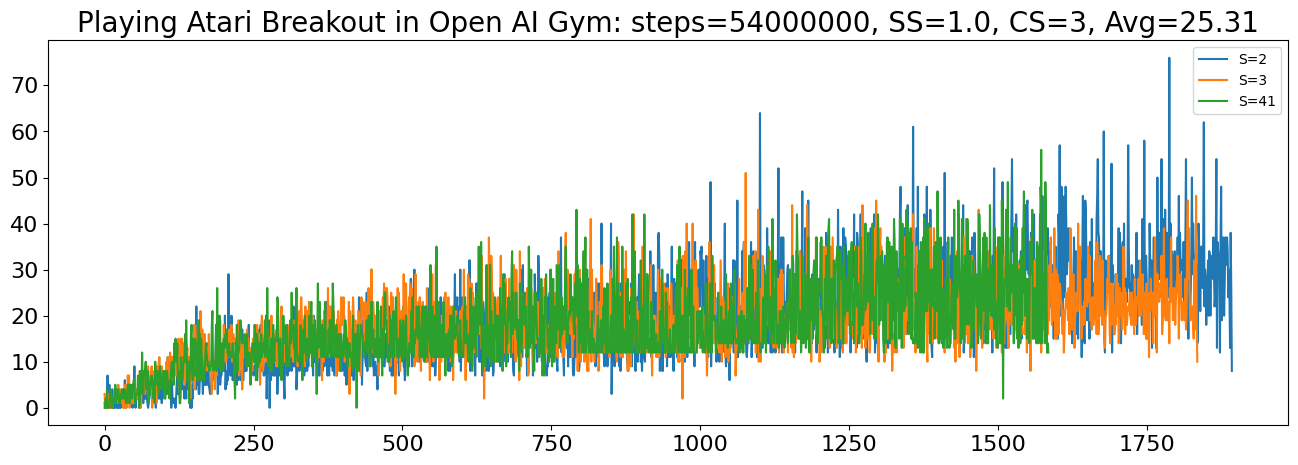

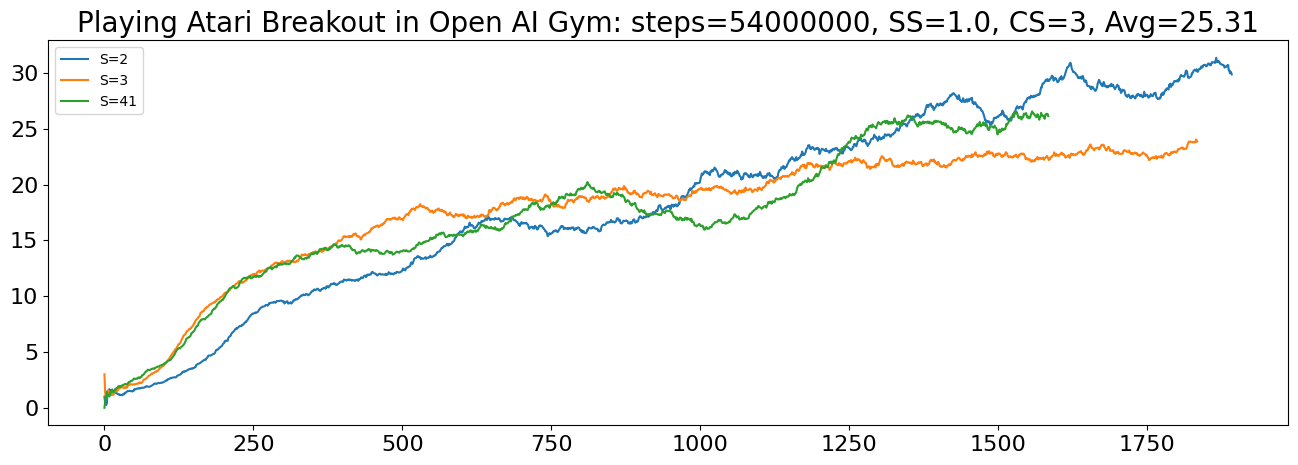

In [96]:
#sim_test3/exp5400000_s2ss10lm2sc2cs3tu0.txt:score_avg=19.2; steps_tot=5400000; steps_avg=2852.6; lives_avg=0.0; lapse_avg="0:00:00.389828"; time="0:29:04.288619"
#sim_test3/exp5400000_s3ss10lm2sc2cs3tu0.txt:score_avg=18.4; steps_tot=5400000; steps_avg=2942.8; lives_avg=0.0; lapse_avg="0:00:00.466724"; time="0:28:53.595144"
#sim_test3/exp5400000_s41ss10lm2sc2cs3tu0.txt:score_avg=17.6; steps_tot=5400000; steps_avg=3406.9; lives_avg=0.1; lapse_avg="0:00:00.569747"; time="0:25:28.520354"

s2ss10lm2sc2cs3tu0 = [1.0, 0, 0, 0, 1.0, 7.0, 1.0, 0, 5.0, 1.0, 1.0, 0, 2.0, 4.0, 0, 0, 2.0, 0, 0, 2.0, 1.0, 0, 1.0, 0, 1.0, 0, 2.0, 0, 1.0, 1.0, 1.0, 4.0, 1.0, 1.0, 6.0, 0, 4.0, 3.0, 3.0, 3.0, 1.0, 3.0, 1.0, 1.0, 1.0, 2.0, 1.0, 0, 4.0, 2.0, 9.0, 2.0, 0, 3.0, 4.0, 2.0, 3.0, 3.0, 0, 1.0, 5.0, 2.0, 2.0, 3.0, 2.0, 1.0, 3.0, 2.0, 5.0, 2.0, 7.0, 2.0, 1.0, 0, 1.0, 2.0, 3.0, 3.0, 5.0, 4.0, 4.0, 5.0, 6.0, 6.0, 6.0, 2.0, 0, 2.0, 2.0, 7.0, 4.0, 2.0, 2.0, 2.0, 4.0, 3.0, 1.0, 6.0, 3.0, 4.0, 4.0, 4.0, 3.0, 5.0, 3.0, 5.0, 11.0, 3.0, 5.0, 3.0, 4.0, 6.0, 0, 6.0, 2.0, 2.0, 1.0, 1.0, 2.0, 0, 2.0, 5.0, 9.0, 3.0, 3.0, 3.0, 3.0, 2.0, 6.0, 5.0, 11.0, 4.0, 7.0, 5.0, 2.0, 4.0, 7.0, 2.0, 9.0, 5.0, 5.0, 4.0, 6.0, 4.0, 0, 4.0, 0, 5.0, 2.0, 6.0, 9.0, 6.0, 5.0, 4.0, 22.0, 5.0, 5.0, 6.0, 3.0, 3.0, 7.0, 6.0, 7.0, 6.0, 7.0, 3.0, 9.0, 6.0, 5.0, 6.0, 5.0, 14.0, 5.0, 6.0, 14.0, 5.0, 4.0, 3.0, 4.0, 5.0, 9.0, 8.0, 9.0, 9.0, 6.0, 7.0, 10.0, 16.0, 9.0, 9.0, 3.0, 8.0, 7.0, 11.0, 5.0, 7.0, 7.0, 8.0, 13.0, 14.0, 8.0, 8.0, 20.0, 4.0, 8.0, 5.0, 8.0, 6.0, 29.0, 11.0, 10.0, 7.0, 7.0, 20.0, 10.0, 6.0, 7.0, 7.0, 6.0, 11.0, 8.0, 9.0, 5.0, 10.0, 6.0, 9.0, 8.0, 7.0, 6.0, 6.0, 8.0, 17.0, 6.0, 6.0, 12.0, 12.0, 8.0, 10.0, 8.0, 16.0, 10.0, 11.0, 18.0, 9.0, 10.0, 8.0, 8.0, 9.0, 8.0, 9.0, 7.0, 8.0, 9.0, 9.0, 16.0, 11.0, 6.0, 9.0, 9.0, 12.0, 17.0, 8.0, 18.0, 8.0, 9.0, 9.0, 9.0, 7.0, 7.0, 8.0, 10.0, 20.0, 2.0, 8.0, 8.0, 10.0, 19.0, 0, 11.0, 6.0, 9.0, 10.0, 10.0, 7.0, 11.0, 7.0, 14.0, 7.0, 15.0, 17.0, 3.0, 9.0, 9.0, 9.0, 7.0, 8.0, 8.0, 8.0, 10.0, 8.0, 12.0, 5.0, 2.0, 12.0, 10.0, 11.0, 11.0, 7.0, 10.0, 13.0, 8.0, 13.0, 11.0, 11.0, 8.0, 16.0, 9.0, 22.0, 9.0, 9.0, 13.0, 16.0, 4.0, 7.0, 11.0, 13.0, 16.0, 8.0, 12.0, 11.0, 13.0, 15.0, 13.0, 10.0, 14.0, 7.0, 9.0, 8.0, 18.0, 15.0, 8.0, 11.0, 9.0, 13.0, 16.0, 12.0, 16.0, 17.0, 15.0, 10.0, 7.0, 20.0, 10.0, 11.0, 10.0, 13.0, 9.0, 17.0, 8.0, 8.0, 7.0, 7.0, 14.0, 12.0, 17.0, 16.0, 8.0, 12.0, 11.0, 9.0, 11.0, 10.0, 10.0, 23.0, 7.0, 11.0, 8.0, 7.0, 16.0, 15.0, 19.0, 9.0, 11.0, 8.0, 10.0, 15.0, 7.0, 9.0, 9.0, 10.0, 7.0, 10.0, 16.0, 12.0, 10.0, 17.0, 8.0, 13.0, 10.0, 8.0, 9.0, 9.0, 20.0, 7.0, 9.0, 13.0, 5.0, 10.0, 15.0, 12.0, 11.0, 7.0, 14.0, 12.0, 7.0, 7.0, 14.0, 23.0, 6.0, 9.0, 15.0, 10.0, 9.0, 11.0, 14.0, 9.0, 8.0, 24.0, 10.0, 14.0, 20.0, 23.0, 5.0, 11.0, 17.0, 19.0, 14.0, 11.0, 10.0, 9.0, 25.0, 8.0, 18.0, 12.0, 12.0, 17.0, 17.0, 16.0, 30.0, 17.0, 9.0, 12.0, 7.0, 8.0, 10.0, 8.0, 7.0, 9.0, 4.0, 15.0, 11.0, 11.0, 15.0, 11.0, 11.0, 16.0, 10.0, 11.0, 10.0, 9.0, 9.0, 13.0, 16.0, 11.0, 11.0, 11.0, 15.0, 22.0, 10.0, 8.0, 15.0, 14.0, 7.0, 11.0, 7.0, 11.0, 13.0, 16.0, 8.0, 7.0, 20.0, 10.0, 13.0, 13.0, 7.0, 17.0, 10.0, 17.0, 11.0, 14.0, 19.0, 22.0, 9.0, 9.0, 6.0, 8.0, 23.0, 15.0, 17.0, 11.0, 18.0, 9.0, 18.0, 14.0, 28.0, 19.0, 9.0, 14.0, 19.0, 27.0, 30.0, 15.0, 11.0, 12.0, 19.0, 16.0, 13.0, 13.0, 10.0, 18.0, 13.0, 10.0, 11.0, 11.0, 14.0, 18.0, 17.0, 12.0, 18.0, 11.0, 10.0, 16.0, 21.0, 10.0, 12.0, 26.0, 16.0, 28.0, 19.0, 14.0, 9.0, 19.0, 9.0, 10.0, 16.0, 7.0, 11.0, 21.0, 14.0, 15.0, 18.0, 12.0, 16.0, 14.0, 24.0, 22.0, 21.0, 11.0, 12.0, 20.0, 11.0, 12.0, 18.0, 15.0, 17.0, 21.0, 13.0, 8.0, 19.0, 15.0, 8.0, 18.0, 10.0, 15.0, 21.0, 11.0, 18.0, 20.0, 29.0, 14.0, 23.0, 21.0, 24.0, 14.0, 20.0, 22.0, 10.0, 30.0, 8.0, 15.0, 11.0, 24.0, 24.0, 17.0, 19.0, 22.0, 13.0, 22.0, 13.0, 15.0, 15.0, 19.0, 32.0, 32.0, 8.0, 11.0, 12.0, 16.0, 16.0, 21.0, 13.0, 15.0, 7.0, 21.0, 27.0, 17.0, 27.0, 18.0, 25.0, 10.0, 18.0, 10.0, 19.0, 21.0, 7.0, 23.0, 19.0, 16.0, 18.0, 20.0, 23.0, 8.0, 13.0, 25.0, 31.0, 8.0, 18.0, 10.0, 17.0, 22.0, 13.0, 18.0, 7.0, 8.0, 14.0, 16.0, 17.0, 14.0, 12.0, 13.0, 19.0, 19.0, 10.0, 17.0, 9.0, 11.0, 21.0, 14.0, 12.0, 20.0, 15.0, 29.0, 20.0, 10.0, 18.0, 19.0, 13.0, 10.0, 19.0, 17.0, 15.0, 15.0, 19.0, 12.0, 20.0, 12.0, 8.0, 7.0, 30.0, 15.0, 19.0, 14.0, 17.0, 13.0, 12.0, 11.0, 11.0, 13.0, 30.0, 16.0, 23.0, 11.0, 31.0, 17.0, 13.0, 25.0, 15.0, 18.0, 19.0, 7.0, 9.0, 14.0, 9.0, 20.0, 16.0, 16.0, 15.0, 18.0, 15.0, 7.0, 19.0, 8.0, 29.0, 23.0, 13.0, 16.0, 10.0, 19.0, 33.0, 29.0, 19.0, 18.0, 17.0, 15.0, 10.0, 16.0, 8.0, 13.0, 9.0, 14.0, 10.0, 8.0, 7.0, 9.0, 9.0, 24.0, 15.0, 25.0, 11.0, 19.0, 19.0, 19.0, 14.0, 18.0, 13.0, 22.0, 15.0, 21.0, 11.0, 10.0, 8.0, 20.0, 18.0, 29.0, 17.0, 16.0, 37.0, 12.0, 18.0, 18.0, 11.0, 7.0, 22.0, 19.0, 16.0, 14.0, 13.0, 16.0, 9.0, 27.0, 11.0, 19.0, 11.0, 22.0, 16.0, 19.0, 8.0, 7.0, 8.0, 12.0, 28.0, 23.0, 11.0, 16.0, 18.0, 16.0, 8.0, 9.0, 13.0, 14.0, 13.0, 21.0, 12.0, 16.0, 26.0, 11.0, 11.0, 17.0, 18.0, 14.0, 28.0, 13.0, 28.0, 27.0, 12.0, 14.0, 14.0, 17.0, 17.0, 16.0, 16.0, 13.0, 25.0, 16.0, 9.0, 14.0, 11.0, 19.0, 27.0, 13.0, 17.0, 27.0, 12.0, 18.0, 40.0, 28.0, 15.0, 17.0, 11.0, 9.0, 12.0, 10.0, 17.0, 19.0, 9.0, 22.0, 19.0, 23.0, 13.0, 19.0, 40.0, 3.0, 13.0, 15.0, 19.0, 18.0, 9.0, 24.0, 16.0, 18.0, 30.0, 18.0, 20.0, 13.0, 9.0, 27.0, 8.0, 11.0, 14.0, 23.0, 20.0, 18.0, 19.0, 18.0, 18.0, 16.0, 16.0, 10.0, 9.0, 8.0, 11.0, 15.0, 23.0, 11.0, 27.0, 9.0, 20.0, 23.0, 15.0, 13.0, 13.0, 8.0, 18.0, 19.0, 24.0, 10.0, 22.0, 29.0, 21.0, 21.0, 10.0, 12.0, 8.0, 12.0, 27.0, 25.0, 11.0, 10.0, 21.0, 17.0, 29.0, 22.0, 22.0, 23.0, 19.0, 16.0, 34.0, 14.0, 11.0, 27.0, 12.0, 31.0, 15.0, 15.0, 12.0, 25.0, 20.0, 23.0, 17.0, 37.0, 38.0, 33.0, 8.0, 23.0, 11.0, 25.0, 8.0, 8.0, 20.0, 12.0, 16.0, 20.0, 13.0, 27.0, 9.0, 29.0, 26.0, 11.0, 22.0, 18.0, 11.0, 24.0, 35.0, 12.0, 13.0, 8.0, 28.0, 13.0, 21.0, 27.0, 19.0, 11.0, 24.0, 20.0, 29.0, 20.0, 33.0, 25.0, 32.0, 32.0, 17.0, 23.0, 19.0, 12.0, 10.0, 17.0, 25.0, 17.0, 11.0, 27.0, 20.0, 36.0, 23.0, 26.0, 13.0, 18.0, 25.0, 30.0, 22.0, 20.0, 9.0, 36.0, 20.0, 17.0, 20.0, 18.0, 20.0, 30.0, 22.0, 22.0, 34.0, 33.0, 35.0, 24.0, 15.0, 32.0, 18.0, 26.0, 21.0, 12.0, 33.0, 10.0, 28.0, 11.0, 23.0, 15.0, 16.0, 49.0, 9.0, 26.0, 29.0, 18.0, 22.0, 25.0, 27.0, 19.0, 14.0, 10.0, 12.0, 24.0, 20.0, 15.0, 10.0, 17.0, 24.0, 24.0, 17.0, 12.0, 18.0, 20.0, 25.0, 40.0, 12.0, 9.0, 18.0, 22.0, 10.0, 23.0, 13.0, 6.0, 26.0, 14.0, 16.0, 14.0, 16.0, 32.0, 12.0, 32.0, 31.0, 12.0, 20.0, 13.0, 45.0, 11.0, 18.0, 13.0, 15.0, 20.0, 22.0, 13.0, 34.0, 12.0, 33.0, 36.0, 22.0, 14.0, 29.0, 12.0, 11.0, 14.0, 20.0, 22.0, 24.0, 19.0, 28.0, 36.0, 11.0, 19.0, 15.0, 34.0, 15.0, 32.0, 24.0, 22.0, 16.0, 11.0, 34.0, 14.0, 35.0, 16.0, 64.0, 22.0, 14.0, 18.0, 13.0, 18.0, 31.0, 15.0, 27.0, 21.0, 16.0, 21.0, 39.0, 28.0, 14.0, 17.0, 28.0, 24.0, 12.0, 20.0, 33.0, 12.0, 17.0, 19.0, 15.0, 22.0, 12.0, 18.0, 18.0, 17.0, 31.0, 52.0, 20.0, 31.0, 21.0, 29.0, 37.0, 12.0, 13.0, 37.0, 25.0, 16.0, 14.0, 23.0, 18.0, 25.0, 30.0, 31.0, 23.0, 24.0, 21.0, 30.0, 20.0, 22.0, 23.0, 14.0, 16.0, 29.0, 16.0, 12.0, 31.0, 34.0, 19.0, 19.0, 16.0, 24.0, 15.0, 23.0, 34.0, 29.0, 27.0, 47.0, 19.0, 19.0, 22.0, 18.0, 39.0, 24.0, 37.0, 20.0, 24.0, 45.0, 26.0, 20.0, 12.0, 16.0, 22.0, 14.0, 29.0, 24.0, 18.0, 17.0, 20.0, 26.0, 25.0, 12.0, 28.0, 24.0, 28.0, 16.0, 16.0, 27.0, 36.0, 26.0, 25.0, 17.0, 25.0, 13.0, 26.0, 13.0, 16.0, 38.0, 19.0, 29.0, 12.0, 17.0, 18.0, 20.0, 32.0, 23.0, 22.0, 19.0, 30.0, 20.0, 18.0, 12.0, 24.0, 21.0, 17.0, 20.0, 17.0, 43.0, 27.0, 27.0, 11.0, 35.0, 13.0, 14.0, 30.0, 16.0, 39.0, 29.0, 18.0, 37.0, 35.0, 25.0, 27.0, 33.0, 18.0, 19.0, 18.0, 25.0, 12.0, 17.0, 26.0, 21.0, 34.0, 28.0, 42.0, 15.0, 29.0, 22.0, 13.0, 38.0, 36.0, 32.0, 30.0, 25.0, 27.0, 42.0, 23.0, 24.0, 22.0, 15.0, 23.0, 35.0, 31.0, 25.0, 15.0, 10.0, 28.0, 21.0, 38.0, 26.0, 21.0, 24.0, 39.0, 24.0, 32.0, 25.0, 16.0, 33.0, 42.0, 12.0, 15.0, 15.0, 16.0, 14.0, 16.0, 34.0, 37.0, 19.0, 22.0, 20.0, 33.0, 25.0, 19.0, 28.0, 14.0, 31.0, 33.0, 29.0, 17.0, 27.0, 23.0, 13.0, 19.0, 24.0, 19.0, 15.0, 24.0, 34.0, 33.0, 20.0, 19.0, 25.0, 25.0, 24.0, 33.0, 31.0, 28.0, 25.0, 30.0, 19.0, 26.0, 43.0, 48.0, 23.0, 36.0, 34.0, 17.0, 18.0, 22.0, 39.0, 28.0, 22.0, 16.0, 29.0, 44.0, 23.0, 22.0, 38.0, 24.0, 21.0, 24.0, 28.0, 24.0, 61.0, 24.0, 27.0, 30.0, 24.0, 31.0, 39.0, 25.0, 48.0, 18.0, 22.0, 30.0, 21.0, 24.0, 33.0, 26.0, 26.0, 26.0, 28.0, 42.0, 41.0, 41.0, 25.0, 48.0, 26.0, 20.0, 27.0, 39.0, 26.0, 43.0, 28.0, 13.0, 11.0, 27.0, 17.0, 22.0, 26.0, 21.0, 23.0, 28.0, 24.0, 24.0, 28.0, 25.0, 23.0, 26.0, 33.0, 24.0, 21.0, 25.0, 16.0, 35.0, 25.0, 51.0, 23.0, 27.0, 25.0, 22.0, 36.0, 23.0, 31.0, 24.0, 27.0, 33.0, 27.0, 37.0, 33.0, 22.0, 28.0, 21.0, 16.0, 28.0, 23.0, 20.0, 18.0, 16.0, 42.0, 39.0, 22.0, 22.0, 24.0, 29.0, 26.0, 24.0, 44.0, 12.0, 16.0, 29.0, 23.0, 31.0, 36.0, 22.0, 35.0, 33.0, 21.0, 34.0, 31.0, 28.0, 20.0, 37.0, 15.0, 29.0, 11.0, 38.0, 34.0, 24.0, 25.0, 22.0, 26.0, 25.0, 21.0, 20.0, 20.0, 23.0, 20.0, 15.0, 25.0, 17.0, 14.0, 26.0, 21.0, 17.0, 27.0, 28.0, 22.0, 34.0, 23.0, 33.0, 31.0, 23.0, 18.0, 26.0, 24.0, 12.0, 33.0, 31.0, 52.0, 21.0, 26.0, 25.0, 24.0, 33.0, 31.0, 21.0, 34.0, 32.0, 33.0, 24.0, 34.0, 20.0, 49.0, 20.0, 19.0, 24.0, 29.0, 13.0, 27.0, 25.0, 13.0, 15.0, 31.0, 31.0, 27.0, 16.0, 29.0, 40.0, 54.0, 34.0, 39.0, 31.0, 35.0, 32.0, 32.0, 42.0, 26.0, 26.0, 31.0, 31.0, 25.0, 32.0, 22.0, 34.0, 15.0, 30.0, 22.0, 32.0, 44.0, 40.0, 26.0, 44.0, 30.0, 44.0, 45.0, 33.0, 29.0, 35.0, 20.0, 35.0, 38.0, 25.0, 18.0, 24.0, 22.0, 42.0, 23.0, 29.0, 32.0, 20.0, 28.0, 31.0, 20.0, 27.0, 16.0, 31.0, 48.0, 44.0, 21.0, 46.0, 25.0, 26.0, 25.0, 28.0, 32.0, 39.0, 25.0, 21.0, 39.0, 27.0, 20.0, 34.0, 22.0, 36.0, 28.0, 31.0, 30.0, 27.0, 15.0, 35.0, 27.0, 35.0, 17.0, 22.0, 15.0, 15.0, 42.0, 37.0, 57.0, 29.0, 20.0, 48.0, 18.0, 20.0, 28.0, 27.0, 46.0, 24.0, 48.0, 41.0, 29.0, 32.0, 32.0, 39.0, 32.0, 33.0, 38.0, 34.0, 21.0, 14.0, 29.0, 17.0, 37.0, 26.0, 31.0, 34.0, 16.0, 23.0, 21.0, 15.0, 28.0, 27.0, 27.0, 32.0, 25.0, 11.0, 33.0, 46.0, 29.0, 15.0, 14.0, 45.0, 42.0, 30.0, 19.0, 22.0, 30.0, 34.0, 15.0, 36.0, 21.0, 17.0, 41.0, 19.0, 23.0, 27.0, 20.0, 20.0, 25.0, 25.0, 41.0, 46.0, 54.0, 38.0, 37.0, 27.0, 27.0, 34.0, 23.0, 26.0, 31.0, 19.0, 60.0, 15.0, 12.0, 32.0, 23.0, 28.0, 25.0, 31.0, 30.0, 29.0, 33.0, 31.0, 24.0, 53.0, 12.0, 31.0, 20.0, 16.0, 16.0, 26.0, 29.0, 27.0, 28.0, 24.0, 30.0, 39.0, 24.0, 38.0, 15.0, 14.0, 24.0, 35.0, 36.0, 25.0, 40.0, 24.0, 23.0, 22.0, 28.0, 23.0, 29.0, 57.0, 35.0, 26.0, 27.0, 20.0, 21.0, 31.0, 24.0, 29.0, 28.0, 21.0, 28.0, 24.0, 30.0, 38.0, 16.0, 32.0, 20.0, 30.0, 22.0, 23.0, 24.0, 24.0, 18.0, 41.0, 26.0, 20.0, 58.0, 22.0, 27.0, 33.0, 28.0, 20.0, 25.0, 15.0, 17.0, 40.0, 31.0, 32.0, 32.0, 13.0, 20.0, 30.0, 37.0, 28.0, 21.0, 32.0, 13.0, 29.0, 50.0, 30.0, 38.0, 28.0, 38.0, 28.0, 36.0, 54.0, 20.0, 39.0, 41.0, 24.0, 29.0, 43.0, 32.0, 26.0, 38.0, 32.0, 24.0, 25.0, 76.0, 24.0, 40.0, 23.0, 34.0, 25.0, 24.0, 33.0, 26.0, 34.0, 25.0, 29.0, 25.0, 29.0, 37.0, 26.0, 46.0, 27.0, 38.0, 31.0, 32.0, 30.0, 32.0, 24.0, 36.0, 23.0, 34.0, 36.0, 54.0, 27.0, 18.0, 23.0, 15.0, 25.0, 32.0, 20.0, 26.0, 35.0, 50.0, 29.0, 40.0, 33.0, 33.0, 28.0, 27.0, 30.0, 31.0, 14.0, 15.0, 40.0, 36.0, 27.0, 21.0, 31.0, 35.0, 32.0, 26.0, 37.0, 62.0, 22.0, 30.0, 28.0, 18.0, 24.0, 27.0, 32.0, 20.0, 34.0, 33.0, 20.0, 33.0, 30.0, 30.0, 28.0, 37.0, 30.0, 22.0, 24.0, 34.0, 54.0, 13.0, 36.0, 34.0, 33.0, 33.0, 12.0, 35.0, 48.0, 19.0, 36.0, 37.0, 27.0, 20.0, 27.0, 37.0, 31.0, 36.0, 37.0, 34.0, 24.0, 30.0, 24.0, 13.0, 38.0, 26.0, 8.0]
s3ss10lm2sc2cs3tu0 = [3.0, 0, 0, 2.0, 0, 3.0, 3.0, 0, 2.0, 1.0, 0, 0, 2.0, 0, 2.0, 1.0, 2.0, 4.0, 2.0, 3.0, 2.0, 2.0, 1.0, 5.0, 2.0, 4.0, 2.0, 2.0, 4.0, 1.0, 3.0, 0, 2.0, 0, 2.0, 5.0, 1.0, 0, 3.0, 7.0, 4.0, 7.0, 0, 2.0, 4.0, 2.0, 1.0, 1.0, 4.0, 2.0, 1.0, 3.0, 3.0, 4.0, 2.0, 2.0, 4.0, 4.0, 1.0, 8.0, 0, 0, 4.0, 4.0, 8.0, 7.0, 8.0, 5.0, 3.0, 5.0, 4.0, 8.0, 5.0, 9.0, 7.0, 6.0, 4.0, 5.0, 7.0, 9.0, 0, 8.0, 4.0, 7.0, 6.0, 7.0, 5.0, 1.0, 9.0, 5.0, 7.0, 10.0, 11.0, 8.0, 7.0, 7.0, 9.0, 7.0, 8.0, 6.0, 5.0, 7.0, 8.0, 8.0, 10.0, 6.0, 11.0, 9.0, 6.0, 10.0, 12.0, 8.0, 8.0, 11.0, 6.0, 11.0, 8.0, 10.0, 14.0, 7.0, 9.0, 7.0, 13.0, 14.0, 15.0, 4.0, 8.0, 7.0, 15.0, 15.0, 15.0, 11.0, 10.0, 14.0, 5.0, 8.0, 6.0, 14.0, 12.0, 13.0, 7.0, 9.0, 11.0, 6.0, 2.0, 6.0, 9.0, 9.0, 9.0, 8.0, 18.0, 4.0, 18.0, 15.0, 8.0, 11.0, 6.0, 10.0, 12.0, 9.0, 9.0, 21.0, 9.0, 7.0, 17.0, 7.0, 8.0, 11.0, 16.0, 10.0, 12.0, 8.0, 13.0, 10.0, 9.0, 16.0, 8.0, 10.0, 10.0, 10.0, 3.0, 11.0, 8.0, 10.0, 10.0, 4.0, 9.0, 13.0, 7.0, 12.0, 15.0, 10.0, 12.0, 10.0, 19.0, 11.0, 10.0, 11.0, 11.0, 9.0, 18.0, 14.0, 14.0, 10.0, 10.0, 12.0, 11.0, 11.0, 14.0, 17.0, 11.0, 15.0, 16.0, 18.0, 10.0, 12.0, 16.0, 14.0, 14.0, 15.0, 15.0, 13.0, 14.0, 16.0, 16.0, 19.0, 7.0, 13.0, 9.0, 12.0, 14.0, 4.0, 14.0, 13.0, 13.0, 11.0, 12.0, 15.0, 15.0, 17.0, 15.0, 15.0, 14.0, 11.0, 12.0, 13.0, 12.0, 10.0, 8.0, 15.0, 10.0, 15.0, 18.0, 10.0, 10.0, 15.0, 18.0, 16.0, 15.0, 11.0, 16.0, 5.0, 10.0, 16.0, 20.0, 10.0, 8.0, 10.0, 15.0, 15.0, 17.0, 10.0, 13.0, 16.0, 17.0, 14.0, 9.0, 15.0, 9.0, 11.0, 20.0, 10.0, 11.0, 17.0, 12.0, 10.0, 16.0, 12.0, 9.0, 14.0, 11.0, 9.0, 9.0, 11.0, 11.0, 14.0, 20.0, 22.0, 13.0, 10.0, 10.0, 11.0, 10.0, 13.0, 16.0, 13.0, 18.0, 12.0, 13.0, 13.0, 18.0, 14.0, 11.0, 15.0, 12.0, 16.0, 11.0, 10.0, 12.0, 19.0, 11.0, 14.0, 18.0, 25.0, 9.0, 20.0, 18.0, 21.0, 16.0, 20.0, 24.0, 20.0, 9.0, 10.0, 19.0, 12.0, 9.0, 22.0, 11.0, 11.0, 11.0, 21.0, 12.0, 23.0, 12.0, 14.0, 12.0, 13.0, 11.0, 15.0, 20.0, 17.0, 14.0, 12.0, 17.0, 13.0, 7.0, 11.0, 15.0, 20.0, 22.0, 11.0, 18.0, 11.0, 11.0, 6.0, 19.0, 17.0, 10.0, 21.0, 20.0, 12.0, 12.0, 12.0, 19.0, 26.0, 11.0, 14.0, 22.0, 12.0, 14.0, 22.0, 12.0, 13.0, 21.0, 19.0, 12.0, 17.0, 16.0, 7.0, 19.0, 18.0, 21.0, 17.0, 8.0, 16.0, 16.0, 24.0, 19.0, 18.0, 19.0, 24.0, 15.0, 10.0, 12.0, 17.0, 13.0, 14.0, 15.0, 12.0, 23.0, 3.0, 21.0, 11.0, 17.0, 11.0, 13.0, 24.0, 19.0, 14.0, 17.0, 19.0, 16.0, 7.0, 8.0, 13.0, 21.0, 20.0, 12.0, 13.0, 7.0, 24.0, 22.0, 23.0, 21.0, 19.0, 14.0, 14.0, 23.0, 14.0, 15.0, 21.0, 15.0, 26.0, 18.0, 13.0, 24.0, 16.0, 30.0, 12.0, 23.0, 23.0, 20.0, 11.0, 20.0, 12.0, 15.0, 13.0, 18.0, 20.0, 7.0, 16.0, 21.0, 17.0, 16.0, 12.0, 10.0, 24.0, 18.0, 27.0, 17.0, 26.0, 20.0, 21.0, 26.0, 23.0, 15.0, 14.0, 17.0, 15.0, 9.0, 25.0, 18.0, 16.0, 24.0, 16.0, 18.0, 18.0, 3.0, 14.0, 10.0, 16.0, 26.0, 13.0, 25.0, 18.0, 8.0, 14.0, 21.0, 20.0, 15.0, 16.0, 29.0, 18.0, 23.0, 19.0, 27.0, 18.0, 18.0, 10.0, 13.0, 24.0, 22.0, 27.0, 16.0, 26.0, 20.0, 20.0, 21.0, 19.0, 9.0, 12.0, 29.0, 15.0, 16.0, 10.0, 18.0, 23.0, 21.0, 24.0, 13.0, 8.0, 22.0, 18.0, 23.0, 12.0, 20.0, 10.0, 15.0, 14.0, 10.0, 26.0, 14.0, 12.0, 16.0, 12.0, 6.0, 18.0, 28.0, 17.0, 29.0, 12.0, 10.0, 23.0, 18.0, 14.0, 31.0, 12.0, 20.0, 20.0, 14.0, 20.0, 6.0, 11.0, 18.0, 10.0, 20.0, 16.0, 12.0, 21.0, 24.0, 15.0, 25.0, 16.0, 12.0, 12.0, 13.0, 24.0, 15.0, 20.0, 22.0, 10.0, 13.0, 10.0, 22.0, 6.0, 20.0, 12.0, 16.0, 20.0, 21.0, 12.0, 16.0, 18.0, 13.0, 18.0, 16.0, 21.0, 15.0, 19.0, 19.0, 22.0, 12.0, 30.0, 15.0, 18.0, 6.0, 22.0, 12.0, 17.0, 29.0, 10.0, 28.0, 23.0, 18.0, 20.0, 27.0, 9.0, 25.0, 21.0, 17.0, 18.0, 12.0, 16.0, 19.0, 16.0, 25.0, 18.0, 16.0, 22.0, 18.0, 20.0, 13.0, 33.0, 16.0, 16.0, 15.0, 2.0, 10.0, 16.0, 14.0, 20.0, 21.0, 18.0, 15.0, 37.0, 30.0, 10.0, 19.0, 33.0, 28.0, 18.0, 25.0, 21.0, 22.0, 10.0, 22.0, 10.0, 10.0, 23.0, 24.0, 18.0, 18.0, 24.0, 20.0, 33.0, 16.0, 20.0, 21.0, 18.0, 15.0, 12.0, 15.0, 28.0, 10.0, 16.0, 22.0, 13.0, 12.0, 28.0, 21.0, 18.0, 15.0, 19.0, 12.0, 18.0, 25.0, 31.0, 17.0, 14.0, 10.0, 30.0, 19.0, 18.0, 16.0, 15.0, 6.0, 34.0, 21.0, 9.0, 23.0, 15.0, 23.0, 13.0, 16.0, 17.0, 19.0, 13.0, 21.0, 26.0, 21.0, 7.0, 8.0, 29.0, 20.0, 15.0, 26.0, 19.0, 18.0, 10.0, 16.0, 22.0, 18.0, 15.0, 14.0, 15.0, 23.0, 16.0, 18.0, 18.0, 23.0, 20.0, 23.0, 16.0, 15.0, 25.0, 26.0, 18.0, 19.0, 28.0, 22.0, 12.0, 12.0, 17.0, 17.0, 18.0, 10.0, 16.0, 18.0, 13.0, 18.0, 13.0, 18.0, 11.0, 14.0, 25.0, 11.0, 11.0, 18.0, 25.0, 16.0, 11.0, 34.0, 15.0, 17.0, 22.0, 20.0, 22.0, 16.0, 11.0, 20.0, 11.0, 14.0, 30.0, 38.0, 23.0, 24.0, 30.0, 29.0, 18.0, 18.0, 24.0, 16.0, 18.0, 18.0, 11.0, 23.0, 15.0, 21.0, 29.0, 18.0, 30.0, 22.0, 31.0, 8.0, 24.0, 18.0, 25.0, 30.0, 10.0, 14.0, 22.0, 18.0, 15.0, 14.0, 10.0, 18.0, 17.0, 16.0, 11.0, 8.0, 9.0, 8.0, 19.0, 26.0, 30.0, 41.0, 10.0, 30.0, 19.0, 18.0, 14.0, 10.0, 14.0, 18.0, 28.0, 22.0, 19.0, 18.0, 8.0, 10.0, 23.0, 19.0, 23.0, 31.0, 18.0, 22.0, 25.0, 19.0, 12.0, 19.0, 23.0, 12.0, 17.0, 20.0, 23.0, 23.0, 11.0, 22.0, 30.0, 19.0, 26.0, 22.0, 24.0, 26.0, 15.0, 19.0, 16.0, 15.0, 11.0, 10.0, 18.0, 36.0, 33.0, 13.0, 25.0, 11.0, 22.0, 17.0, 13.0, 11.0, 27.0, 30.0, 26.0, 12.0, 34.0, 12.0, 26.0, 8.0, 20.0, 12.0, 15.0, 20.0, 9.0, 26.0, 14.0, 19.0, 15.0, 42.0, 21.0, 32.0, 14.0, 13.0, 23.0, 16.0, 21.0, 13.0, 18.0, 12.0, 12.0, 13.0, 21.0, 13.0, 35.0, 28.0, 13.0, 16.0, 24.0, 15.0, 12.0, 12.0, 19.0, 14.0, 15.0, 23.0, 22.0, 26.0, 31.0, 12.0, 7.0, 17.0, 15.0, 20.0, 18.0, 20.0, 16.0, 11.0, 14.0, 11.0, 30.0, 17.0, 11.0, 22.0, 18.0, 28.0, 17.0, 24.0, 20.0, 17.0, 27.0, 20.0, 26.0, 11.0, 15.0, 18.0, 26.0, 23.0, 15.0, 20.0, 19.0, 16.0, 27.0, 20.0, 13.0, 16.0, 18.0, 20.0, 14.0, 18.0, 25.0, 17.0, 12.0, 32.0, 10.0, 11.0, 10.0, 19.0, 24.0, 18.0, 26.0, 2.0, 33.0, 23.0, 21.0, 11.0, 34.0, 16.0, 40.0, 16.0, 25.0, 15.0, 19.0, 19.0, 18.0, 17.0, 29.0, 27.0, 40.0, 22.0, 23.0, 31.0, 12.0, 32.0, 12.0, 26.0, 26.0, 20.0, 16.0, 19.0, 13.0, 18.0, 20.0, 20.0, 22.0, 21.0, 17.0, 18.0, 20.0, 14.0, 19.0, 19.0, 7.0, 12.0, 25.0, 16.0, 36.0, 15.0, 20.0, 14.0, 23.0, 22.0, 17.0, 14.0, 31.0, 23.0, 15.0, 14.0, 16.0, 13.0, 17.0, 19.0, 13.0, 12.0, 23.0, 32.0, 21.0, 10.0, 18.0, 24.0, 14.0, 16.0, 23.0, 11.0, 19.0, 13.0, 15.0, 27.0, 10.0, 19.0, 12.0, 15.0, 13.0, 22.0, 15.0, 24.0, 21.0, 19.0, 27.0, 23.0, 7.0, 11.0, 14.0, 16.0, 18.0, 21.0, 28.0, 17.0, 18.0, 17.0, 15.0, 24.0, 25.0, 17.0, 20.0, 36.0, 14.0, 51.0, 18.0, 18.0, 23.0, 16.0, 16.0, 24.0, 25.0, 19.0, 23.0, 20.0, 22.0, 23.0, 33.0, 32.0, 22.0, 34.0, 12.0, 22.0, 20.0, 16.0, 43.0, 10.0, 26.0, 13.0, 10.0, 18.0, 14.0, 33.0, 32.0, 16.0, 22.0, 18.0, 28.0, 22.0, 30.0, 20.0, 18.0, 27.0, 20.0, 33.0, 34.0, 15.0, 15.0, 19.0, 14.0, 20.0, 13.0, 26.0, 18.0, 25.0, 25.0, 13.0, 22.0, 28.0, 16.0, 12.0, 20.0, 29.0, 15.0, 30.0, 16.0, 29.0, 19.0, 12.0, 20.0, 16.0, 17.0, 16.0, 17.0, 19.0, 12.0, 19.0, 17.0, 24.0, 18.0, 24.0, 13.0, 44.0, 12.0, 20.0, 11.0, 21.0, 21.0, 14.0, 34.0, 25.0, 23.0, 15.0, 19.0, 22.0, 34.0, 32.0, 24.0, 21.0, 27.0, 30.0, 19.0, 22.0, 29.0, 21.0, 19.0, 17.0, 44.0, 37.0, 21.0, 19.0, 18.0, 26.0, 25.0, 10.0, 27.0, 18.0, 21.0, 20.0, 22.0, 29.0, 24.0, 37.0, 16.0, 22.0, 20.0, 24.0, 20.0, 10.0, 13.0, 21.0, 12.0, 21.0, 22.0, 35.0, 16.0, 22.0, 23.0, 35.0, 18.0, 22.0, 24.0, 22.0, 18.0, 25.0, 13.0, 19.0, 35.0, 28.0, 17.0, 37.0, 30.0, 22.0, 15.0, 22.0, 22.0, 17.0, 13.0, 19.0, 15.0, 18.0, 34.0, 16.0, 15.0, 20.0, 28.0, 18.0, 12.0, 28.0, 31.0, 17.0, 14.0, 18.0, 14.0, 19.0, 26.0, 18.0, 26.0, 23.0, 21.0, 19.0, 26.0, 22.0, 27.0, 15.0, 15.0, 28.0, 22.0, 35.0, 12.0, 22.0, 27.0, 24.0, 16.0, 19.0, 35.0, 20.0, 16.0, 23.0, 13.0, 44.0, 29.0, 24.0, 16.0, 16.0, 13.0, 18.0, 21.0, 15.0, 29.0, 23.0, 20.0, 12.0, 14.0, 29.0, 19.0, 28.0, 16.0, 21.0, 24.0, 27.0, 39.0, 18.0, 45.0, 18.0, 30.0, 18.0, 10.0, 26.0, 35.0, 39.0, 19.0, 35.0, 29.0, 23.0, 17.0, 16.0, 10.0, 28.0, 12.0, 19.0, 36.0, 15.0, 25.0, 26.0, 19.0, 23.0, 35.0, 15.0, 15.0, 8.0, 16.0, 16.0, 16.0, 12.0, 24.0, 18.0, 16.0, 12.0, 28.0, 21.0, 16.0, 20.0, 16.0, 31.0, 29.0, 17.0, 26.0, 27.0, 13.0, 20.0, 37.0, 16.0, 24.0, 24.0, 19.0, 22.0, 19.0, 22.0, 21.0, 23.0, 18.0, 26.0, 15.0, 19.0, 42.0, 20.0, 17.0, 19.0, 12.0, 16.0, 35.0, 22.0, 18.0, 31.0, 28.0, 26.0, 16.0, 28.0, 13.0, 21.0, 16.0, 29.0, 12.0, 23.0, 20.0, 23.0, 24.0, 13.0, 10.0, 32.0, 22.0, 16.0, 35.0, 39.0, 26.0, 17.0, 23.0, 14.0, 26.0, 39.0, 16.0, 26.0, 29.0, 16.0, 22.0, 15.0, 33.0, 18.0, 22.0, 20.0, 22.0, 27.0, 32.0, 20.0, 21.0, 19.0, 19.0, 12.0, 19.0, 16.0, 25.0, 26.0, 27.0, 36.0, 22.0, 28.0, 24.0, 22.0, 20.0, 26.0, 19.0, 26.0, 20.0, 13.0, 25.0, 10.0, 21.0, 14.0, 34.0, 28.0, 22.0, 21.0, 11.0, 25.0, 19.0, 19.0, 21.0, 23.0, 30.0, 17.0, 37.0, 28.0, 26.0, 41.0, 16.0, 19.0, 14.0, 31.0, 25.0, 21.0, 11.0, 20.0, 28.0, 33.0, 19.0, 32.0, 24.0, 25.0, 19.0, 26.0, 8.0, 20.0, 16.0, 19.0, 43.0, 19.0, 21.0, 23.0, 18.0, 20.0, 13.0, 22.0, 22.0, 21.0, 37.0, 20.0, 18.0, 22.0, 31.0, 15.0, 34.0, 25.0, 33.0, 17.0, 33.0, 22.0, 17.0, 19.0, 19.0, 15.0, 18.0, 17.0, 35.0, 34.0, 13.0, 29.0, 21.0, 30.0, 24.0, 19.0, 19.0, 19.0, 21.0, 12.0, 22.0, 33.0, 15.0, 14.0, 19.0, 33.0, 37.0, 20.0, 19.0, 18.0, 13.0, 23.0, 31.0, 24.0, 20.0, 18.0, 18.0, 24.0, 26.0, 20.0, 23.0, 17.0, 24.0, 19.0, 16.0, 26.0, 16.0, 31.0, 24.0, 23.0, 29.0, 22.0, 16.0, 31.0, 25.0, 19.0, 36.0, 16.0, 18.0, 16.0, 19.0, 12.0, 23.0, 27.0, 16.0, 22.0, 15.0, 8.0, 17.0, 37.0, 30.0, 22.0, 24.0, 25.0, 32.0, 18.0, 23.0, 24.0, 15.0, 35.0, 23.0, 16.0, 35.0, 23.0, 17.0, 12.0, 18.0, 19.0, 26.0, 27.0, 17.0, 34.0, 21.0, 29.0, 33.0, 24.0, 16.0, 20.0, 19.0, 31.0, 25.0, 37.0, 24.0, 18.0, 29.0, 19.0, 24.0, 39.0, 22.0, 15.0, 30.0, 15.0, 29.0, 27.0, 16.0, 20.0, 27.0, 26.0, 23.0, 23.0, 20.0, 16.0, 21.0, 12.0, 16.0, 21.0, 22.0, 25.0, 22.0, 23.0, 19.0, 26.0, 16.0, 16.0, 39.0, 32.0, 22.0, 17.0, 21.0, 29.0, 20.0, 13.0, 20.0, 21.0, 25.0, 24.0, 21.0, 40.0, 25.0, 24.0, 35.0, 23.0, 20.0, 15.0, 21.0, 22.0, 18.0, 23.0, 19.0, 28.0, 27.0, 27.0, 22.0, 27.0, 35.0, 23.0, 33.0, 19.0, 21.0, 19.0, 17.0, 24.0, 18.0, 18.0, 21.0, 27.0, 32.0, 27.0, 16.0, 36.0, 25.0, 16.0, 20.0, 23.0, 33.0, 20.0, 31.0, 18.0, 32.0, 21.0, 21.0, 16.0, 13.0, 20.0, 20.0, 23.0, 28.0, 25.0, 33.0, 27.0, 16.0, 14.0, 27.0, 18.0, 24.0, 24.0, 27.0, 16.0, 17.0, 22.0, 18.0, 29.0, 29.0, 20.0, 27.0, 14.0, 16.0, 26.0, 20.0, 25.0, 21.0, 17.0, 20.0, 35.0, 21.0, 26.0, 16.0, 25.0, 18.0, 18.0, 21.0, 22.0, 21.0, 23.0, 25.0, 20.0, 18.0, 25.0, 23.0, 18.0, 23.0, 16.0, 28.0, 20.0, 18.0, 24.0, 24.0, 23.0, 28.0, 20.0, 27.0, 32.0, 20.0, 22.0, 22.0, 29.0, 26.0, 16.0, 16.0, 25.0, 25.0, 15.0, 27.0, 15.0, 25.0, 20.0, 11.0, 25.0, 21.0, 28.0, 22.0, 25.0, 22.0, 14.0, 25.0, 20.0, 37.0, 28.0, 28.0, 12.0, 29.0, 26.0, 26.0, 23.0, 27.0, 24.0, 25.0, 33.0, 16.0, 19.0, 24.0, 39.0, 20.0, 27.0, 19.0, 27.0, 28.0, 19.0, 23.0, 23.0, 14.0, 26.0, 24.0, 37.0, 23.0, 26.0, 19.0, 21.0, 26.0, 22.0, 18.0, 23.0, 27.0, 28.0, 33.0, 30.0, 15.0, 26.0, 24.0, 29.0, 24.0, 19.0, 23.0, 23.0, 23.0, 19.0, 19.0, 28.0, 17.0, 20.0, 37.0, 45.0, 28.0, 39.0, 25.0, 19.0, 19.0, 22.0, 20.0, 22.0, 18.0, 15.0, 32.0, 17.0, 21.0, 46.0, 19.0, 10.0]
s41ss10lm2sc2cs3tu0 = [0, 1.0, 2.0, 0, 4.0, 0, 1.0, 1.0, 0, 2.0, 4.0, 3.0, 2.0, 0, 2.0, 1.0, 1.0, 3.0, 5.0, 1.0, 4.0, 2.0, 3.0, 4.0, 1.0, 3.0, 1.0, 3.0, 2.0, 4.0, 2.0, 3.0, 3.0, 2.0, 4.0, 3.0, 1.0, 1.0, 3.0, 5.0, 5.0, 5.0, 1.0, 5.0, 5.0, 3.0, 2.0, 5.0, 5.0, 6.0, 5.0, 1.0, 2.0, 3.0, 3.0, 3.0, 7.0, 5.0, 0, 1.0, 8.0, 3.0, 4.0, 12.0, 5.0, 3.0, 7.0, 8.0, 8.0, 10.0, 4.0, 6.0, 8.0, 8.0, 1.0, 3.0, 3.0, 6.0, 6.0, 7.0, 5.0, 4.0, 2.0, 6.0, 1.0, 10.0, 6.0, 6.0, 5.0, 8.0, 4.0, 3.0, 6.0, 9.0, 7.0, 4.0, 5.0, 7.0, 6.0, 8.0, 2.0, 8.0, 2.0, 4.0, 6.0, 8.0, 6.0, 3.0, 3.0, 2.0, 6.0, 6.0, 9.0, 10.0, 7.0, 10.0, 5.0, 14.0, 10.0, 15.0, 13.0, 10.0, 14.0, 6.0, 8.0, 6.0, 1.0, 1.0, 11.0, 8.0, 6.0, 6.0, 9.0, 11.0, 10.0, 16.0, 10.0, 19.0, 11.0, 6.0, 10.0, 10.0, 1.0, 10.0, 8.0, 16.0, 18.0, 8.0, 6.0, 15.0, 9.0, 7.0, 15.0, 14.0, 12.0, 11.0, 6.0, 12.0, 19.0, 9.0, 16.0, 6.0, 15.0, 11.0, 10.0, 6.0, 6.0, 6.0, 8.0, 11.0, 14.0, 12.0, 11.0, 9.0, 10.0, 9.0, 8.0, 9.0, 9.0, 9.0, 18.0, 21.0, 9.0, 8.0, 10.0, 9.0, 9.0, 18.0, 8.0, 26.0, 10.0, 9.0, 9.0, 20.0, 8.0, 8.0, 8.0, 14.0, 9.0, 8.0, 15.0, 13.0, 13.0, 16.0, 14.0, 17.0, 12.0, 12.0, 11.0, 14.0, 12.0, 12.0, 11.0, 11.0, 12.0, 14.0, 12.0, 10.0, 6.0, 2.0, 14.0, 10.0, 18.0, 8.0, 12.0, 12.0, 13.0, 18.0, 19.0, 18.0, 14.0, 14.0, 14.0, 14.0, 15.0, 16.0, 11.0, 13.0, 9.0, 16.0, 9.0, 11.0, 10.0, 12.0, 9.0, 5.0, 9.0, 11.0, 14.0, 14.0, 12.0, 10.0, 18.0, 16.0, 6.0, 10.0, 16.0, 14.0, 9.0, 14.0, 10.0, 10.0, 14.0, 16.0, 11.0, 14.0, 14.0, 12.0, 14.0, 19.0, 11.0, 19.0, 12.0, 26.0, 16.0, 9.0, 12.0, 13.0, 8.0, 15.0, 8.0, 11.0, 14.0, 18.0, 12.0, 10.0, 15.0, 15.0, 15.0, 16.0, 24.0, 23.0, 13.0, 9.0, 10.0, 15.0, 10.0, 6.0, 10.0, 9.0, 20.0, 14.0, 18.0, 15.0, 14.0, 9.0, 18.0, 12.0, 12.0, 9.0, 9.0, 17.0, 19.0, 14.0, 25.0, 15.0, 17.0, 18.0, 13.0, 14.0, 10.0, 21.0, 26.0, 12.0, 11.0, 10.0, 11.0, 11.0, 10.0, 18.0, 10.0, 12.0, 6.0, 15.0, 17.0, 12.0, 20.0, 14.0, 11.0, 10.0, 15.0, 14.0, 11.0, 11.0, 20.0, 12.0, 18.0, 23.0, 9.0, 11.0, 18.0, 15.0, 11.0, 19.0, 11.0, 15.0, 3.0, 14.0, 27.0, 13.0, 18.0, 23.0, 18.0, 14.0, 11.0, 18.0, 12.0, 17.0, 11.0, 17.0, 23.0, 17.0, 11.0, 11.0, 11.0, 11.0, 17.0, 12.0, 19.0, 13.0, 19.0, 11.0, 16.0, 27.0, 23.0, 15.0, 11.0, 14.0, 14.0, 18.0, 11.0, 12.0, 11.0, 16.0, 16.0, 13.0, 8.0, 16.0, 14.0, 11.0, 11.0, 11.0, 16.0, 12.0, 19.0, 17.0, 11.0, 15.0, 9.0, 14.0, 12.0, 14.0, 11.0, 11.0, 12.0, 9.0, 8.0, 20.0, 9.0, 16.0, 10.0, 9.0, 16.0, 0, 13.0, 18.0, 14.0, 8.0, 12.0, 15.0, 18.0, 16.0, 16.0, 16.0, 14.0, 11.0, 11.0, 14.0, 13.0, 16.0, 19.0, 12.0, 15.0, 20.0, 20.0, 9.0, 9.0, 11.0, 23.0, 15.0, 13.0, 17.0, 11.0, 12.0, 11.0, 15.0, 11.0, 11.0, 23.0, 10.0, 15.0, 12.0, 11.0, 11.0, 22.0, 11.0, 7.0, 17.0, 11.0, 17.0, 25.0, 25.0, 18.0, 19.0, 14.0, 10.0, 10.0, 10.0, 10.0, 20.0, 11.0, 18.0, 19.0, 14.0, 11.0, 21.0, 11.0, 19.0, 17.0, 24.0, 17.0, 11.0, 11.0, 15.0, 11.0, 11.0, 19.0, 18.0, 14.0, 11.0, 10.0, 19.0, 18.0, 11.0, 16.0, 12.0, 20.0, 11.0, 10.0, 7.0, 11.0, 14.0, 13.0, 12.0, 13.0, 21.0, 12.0, 24.0, 13.0, 11.0, 16.0, 14.0, 17.0, 16.0, 22.0, 16.0, 15.0, 22.0, 21.0, 11.0, 11.0, 11.0, 17.0, 20.0, 22.0, 11.0, 17.0, 10.0, 22.0, 15.0, 22.0, 11.0, 19.0, 19.0, 21.0, 16.0, 12.0, 31.0, 12.0, 11.0, 22.0, 11.0, 17.0, 20.0, 11.0, 11.0, 15.0, 35.0, 21.0, 11.0, 11.0, 23.0, 17.0, 11.0, 12.0, 18.0, 16.0, 11.0, 12.0, 23.0, 15.0, 11.0, 7.0, 12.0, 16.0, 11.0, 14.0, 16.0, 17.0, 11.0, 20.0, 17.0, 20.0, 9.0, 10.0, 18.0, 22.0, 19.0, 15.0, 16.0, 18.0, 16.0, 20.0, 14.0, 12.0, 11.0, 14.0, 19.0, 13.0, 11.0, 11.0, 12.0, 11.0, 21.0, 21.0, 24.0, 14.0, 19.0, 15.0, 15.0, 11.0, 10.0, 16.0, 10.0, 26.0, 14.0, 17.0, 8.0, 14.0, 22.0, 14.0, 17.0, 13.0, 24.0, 11.0, 25.0, 16.0, 22.0, 35.0, 18.0, 18.0, 20.0, 36.0, 13.0, 22.0, 8.0, 18.0, 12.0, 12.0, 9.0, 12.0, 31.0, 11.0, 18.0, 14.0, 11.0, 16.0, 31.0, 9.0, 21.0, 10.0, 13.0, 13.0, 18.0, 10.0, 24.0, 16.0, 15.0, 20.0, 10.0, 20.0, 14.0, 10.0, 10.0, 26.0, 15.0, 16.0, 22.0, 8.0, 29.0, 18.0, 27.0, 22.0, 21.0, 9.0, 16.0, 14.0, 19.0, 24.0, 19.0, 23.0, 22.0, 11.0, 29.0, 34.0, 16.0, 25.0, 19.0, 20.0, 18.0, 17.0, 25.0, 18.0, 15.0, 19.0, 11.0, 8.0, 27.0, 23.0, 17.0, 12.0, 18.0, 24.0, 25.0, 22.0, 18.0, 19.0, 22.0, 11.0, 12.0, 11.0, 14.0, 35.0, 27.0, 13.0, 22.0, 30.0, 14.0, 22.0, 21.0, 8.0, 11.0, 25.0, 18.0, 25.0, 19.0, 15.0, 15.0, 12.0, 11.0, 11.0, 25.0, 12.0, 28.0, 19.0, 7.0, 11.0, 20.0, 7.0, 24.0, 20.0, 29.0, 21.0, 17.0, 13.0, 17.0, 10.0, 14.0, 30.0, 30.0, 16.0, 9.0, 20.0, 28.0, 10.0, 10.0, 18.0, 22.0, 14.0, 31.0, 17.0, 22.0, 24.0, 31.0, 13.0, 22.0, 15.0, 24.0, 16.0, 18.0, 22.0, 20.0, 17.0, 29.0, 35.0, 24.0, 15.0, 14.0, 19.0, 19.0, 21.0, 20.0, 29.0, 21.0, 24.0, 23.0, 24.0, 19.0, 16.0, 17.0, 27.0, 20.0, 43.0, 20.0, 31.0, 19.0, 12.0, 19.0, 28.0, 14.0, 27.0, 12.0, 19.0, 24.0, 34.0, 12.0, 25.0, 37.0, 12.0, 23.0, 30.0, 18.0, 21.0, 12.0, 17.0, 12.0, 15.0, 13.0, 21.0, 12.0, 15.0, 15.0, 12.0, 12.0, 12.0, 14.0, 13.0, 12.0, 20.0, 12.0, 17.0, 15.0, 15.0, 19.0, 12.0, 12.0, 12.0, 22.0, 14.0, 26.0, 16.0, 12.0, 12.0, 12.0, 27.0, 12.0, 12.0, 14.0, 12.0, 18.0, 20.0, 15.0, 12.0, 28.0, 22.0, 35.0, 12.0, 20.0, 13.0, 23.0, 37.0, 12.0, 27.0, 18.0, 12.0, 24.0, 12.0, 16.0, 12.0, 35.0, 12.0, 14.0, 12.0, 17.0, 12.0, 12.0, 27.0, 12.0, 28.0, 12.0, 19.0, 15.0, 12.0, 13.0, 24.0, 12.0, 42.0, 12.0, 20.0, 19.0, 34.0, 19.0, 12.0, 12.0, 19.0, 12.0, 12.0, 12.0, 12.0, 23.0, 32.0, 19.0, 12.0, 22.0, 22.0, 12.0, 42.0, 12.0, 15.0, 13.0, 13.0, 29.0, 24.0, 12.0, 12.0, 15.0, 14.0, 12.0, 23.0, 12.0, 12.0, 15.0, 19.0, 12.0, 12.0, 13.0, 16.0, 12.0, 14.0, 13.0, 13.0, 12.0, 21.0, 12.0, 12.0, 25.0, 30.0, 24.0, 14.0, 17.0, 12.0, 12.0, 25.0, 21.0, 23.0, 12.0, 12.0, 14.0, 12.0, 17.0, 14.0, 12.0, 12.0, 12.0, 14.0, 18.0, 12.0, 12.0, 12.0, 26.0, 15.0, 31.0, 13.0, 12.0, 13.0, 35.0, 21.0, 12.0, 12.0, 14.0, 20.0, 12.0, 12.0, 12.0, 30.0, 17.0, 12.0, 24.0, 12.0, 26.0, 12.0, 12.0, 12.0, 13.0, 12.0, 30.0, 12.0, 13.0, 22.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 21.0, 14.0, 15.0, 21.0, 19.0, 21.0, 13.0, 17.0, 22.0, 12.0, 15.0, 15.0, 13.0, 12.0, 27.0, 22.0, 25.0, 13.0, 12.0, 13.0, 16.0, 27.0, 12.0, 22.0, 12.0, 33.0, 19.0, 20.0, 19.0, 20.0, 19.0, 12.0, 15.0, 15.0, 16.0, 25.0, 14.0, 14.0, 18.0, 14.0, 22.0, 14.0, 16.0, 14.0, 19.0, 14.0, 14.0, 14.0, 29.0, 15.0, 16.0, 13.0, 17.0, 21.0, 14.0, 14.0, 27.0, 23.0, 14.0, 19.0, 23.0, 22.0, 30.0, 15.0, 15.0, 14.0, 15.0, 14.0, 14.0, 20.0, 14.0, 12.0, 15.0, 15.0, 21.0, 13.0, 18.0, 12.0, 20.0, 17.0, 14.0, 19.0, 18.0, 15.0, 26.0, 14.0, 14.0, 33.0, 28.0, 15.0, 31.0, 20.0, 18.0, 30.0, 14.0, 19.0, 18.0, 14.0, 14.0, 25.0, 14.0, 20.0, 32.0, 21.0, 14.0, 14.0, 12.0, 14.0, 14.0, 14.0, 23.0, 24.0, 15.0, 14.0, 29.0, 12.0, 20.0, 31.0, 22.0, 35.0, 17.0, 18.0, 24.0, 14.0, 18.0, 16.0, 41.0, 19.0, 14.0, 20.0, 19.0, 32.0, 27.0, 14.0, 14.0, 18.0, 16.0, 13.0, 21.0, 21.0, 14.0, 21.0, 14.0, 20.0, 22.0, 18.0, 13.0, 18.0, 17.0, 23.0, 22.0, 15.0, 14.0, 22.0, 22.0, 30.0, 20.0, 18.0, 14.0, 22.0, 33.0, 20.0, 22.0, 14.0, 29.0, 16.0, 21.0, 42.0, 34.0, 32.0, 15.0, 19.0, 19.0, 21.0, 12.0, 16.0, 33.0, 21.0, 14.0, 21.0, 19.0, 29.0, 13.0, 15.0, 15.0, 27.0, 37.0, 18.0, 12.0, 28.0, 23.0, 19.0, 28.0, 28.0, 15.0, 30.0, 32.0, 18.0, 26.0, 19.0, 37.0, 14.0, 14.0, 25.0, 25.0, 28.0, 25.0, 27.0, 37.0, 22.0, 20.0, 20.0, 12.0, 14.0, 28.0, 24.0, 33.0, 20.0, 15.0, 36.0, 39.0, 41.0, 18.0, 15.0, 28.0, 14.0, 23.0, 28.0, 23.0, 32.0, 19.0, 14.0, 29.0, 32.0, 33.0, 35.0, 33.0, 14.0, 15.0, 34.0, 28.0, 31.0, 31.0, 28.0, 14.0, 14.0, 35.0, 20.0, 20.0, 27.0, 22.0, 28.0, 21.0, 26.0, 34.0, 27.0, 16.0, 29.0, 34.0, 36.0, 27.0, 18.0, 25.0, 14.0, 21.0, 34.0, 31.0, 35.0, 22.0, 27.0, 22.0, 14.0, 14.0, 18.0, 37.0, 33.0, 18.0, 22.0, 18.0, 21.0, 29.0, 29.0, 40.0, 22.0, 33.0, 27.0, 23.0, 29.0, 38.0, 31.0, 16.0, 29.0, 21.0, 19.0, 40.0, 24.0, 22.0, 15.0, 24.0, 15.0, 28.0, 32.0, 27.0, 42.0, 33.0, 18.0, 25.0, 19.0, 33.0, 24.0, 34.0, 26.0, 15.0, 12.0, 31.0, 30.0, 14.0, 22.0, 32.0, 37.0, 23.0, 28.0, 36.0, 14.0, 15.0, 17.0, 35.0, 15.0, 28.0, 29.0, 41.0, 36.0, 14.0, 13.0, 34.0, 21.0, 24.0, 27.0, 27.0, 15.0, 41.0, 22.0, 24.0, 13.0, 40.0, 32.0, 33.0, 21.0, 30.0, 22.0, 28.0, 43.0, 31.0, 40.0, 33.0, 16.0, 17.0, 30.0, 39.0, 15.0, 36.0, 15.0, 14.0, 15.0, 14.0, 15.0, 25.0, 24.0, 14.0, 17.0, 13.0, 31.0, 23.0, 34.0, 12.0, 36.0, 35.0, 12.0, 21.0, 37.0, 12.0, 41.0, 37.0, 21.0, 39.0, 21.0, 21.0, 40.0, 30.0, 23.0, 30.0, 14.0, 22.0, 25.0, 30.0, 22.0, 25.0, 35.0, 15.0, 22.0, 36.0, 21.0, 28.0, 47.0, 35.0, 14.0, 23.0, 15.0, 37.0, 24.0, 14.0, 24.0, 26.0, 13.0, 25.0, 15.0, 24.0, 28.0, 17.0, 13.0, 31.0, 37.0, 21.0, 13.0, 14.0, 14.0, 23.0, 27.0, 23.0, 18.0, 17.0, 43.0, 15.0, 15.0, 25.0, 33.0, 24.0, 28.0, 45.0, 34.0, 26.0, 27.0, 14.0, 25.0, 41.0, 15.0, 31.0, 30.0, 14.0, 33.0, 18.0, 20.0, 27.0, 41.0, 39.0, 18.0, 26.0, 30.0, 33.0, 22.0, 13.0, 16.0, 28.0, 32.0, 17.0, 28.0, 27.0, 29.0, 25.0, 22.0, 29.0, 14.0, 27.0, 42.0, 38.0, 16.0, 15.0, 19.0, 29.0, 33.0, 37.0, 21.0, 38.0, 31.0, 14.0, 37.0, 14.0, 15.0, 14.0, 30.0, 21.0, 44.0, 27.0, 20.0, 31.0, 22.0, 20.0, 28.0, 17.0, 39.0, 23.0, 15.0, 23.0, 14.0, 13.0, 37.0, 22.0, 37.0, 14.0, 32.0, 14.0, 45.0, 29.0, 2.0, 22.0, 22.0, 28.0, 27.0, 43.0, 34.0, 22.0, 49.0, 25.0, 28.0, 21.0, 27.0, 37.0, 25.0, 31.0, 31.0, 30.0, 14.0, 33.0, 40.0, 28.0, 20.0, 39.0, 15.0, 26.0, 13.0, 30.0, 22.0, 14.0, 33.0, 18.0, 31.0, 39.0, 25.0, 47.0, 27.0, 20.0, 28.0, 28.0, 15.0, 24.0, 28.0, 27.0, 14.0, 36.0, 29.0, 36.0, 30.0, 43.0, 15.0, 19.0, 15.0, 26.0, 20.0, 18.0, 14.0, 36.0, 35.0, 14.0, 22.0, 21.0, 42.0, 14.0, 56.0, 14.0, 26.0, 29.0, 25.0, 27.0, 14.0, 49.0, 38.0, 24.0, 12.0, 14.0, 12.0]

sss = [s2ss10lm2sc2cs3tu0,s3ss10lm2sc2cs3tu0,s41ss10lm2sc2cs3tu0]
for s in sss:
    print(round(np.mean(s),2),round(np.mean(s[-500:]),2))
print()
print(round(np.mean([np.mean(s) for s in sss]),2),round(np.mean([np.mean(s[-500:]) for s in sss]),2))
tit = f"Playing Atari Breakout in Open AI Gym: steps={steps}, SS=1.0, CS=3, Avg={round(np.mean([np.mean(s[-500:]) for s in sss]),2)}"

df = pd.DataFrame({f'S=2': pd.Series(s2ss10lm2sc2cs3tu0),
                    f'S=3': pd.Series(s3ss10lm2sc2cs3tu0),
                    f'S=41': pd.Series(s41ss10lm2sc2cs3tu0)})
p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);plt.show()

df = pd.DataFrame({f'S=2': pd.Series(s2ss10lm2sc2cs3tu0).rolling(window=win, min_periods=1).mean(),
                    f'S=3': pd.Series(s3ss10lm2sc2cs3tu0).rolling(window=win, min_periods=1).mean(),
                    f'S=41': pd.Series(s41ss10lm2sc2cs3tu0).rolling(window=win, min_periods=1).mean()})
p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);plt.show()


## SS=1.0, 54M frames

46.75 72.19
36.23 48.98
39.54 43.77

40.84 54.98


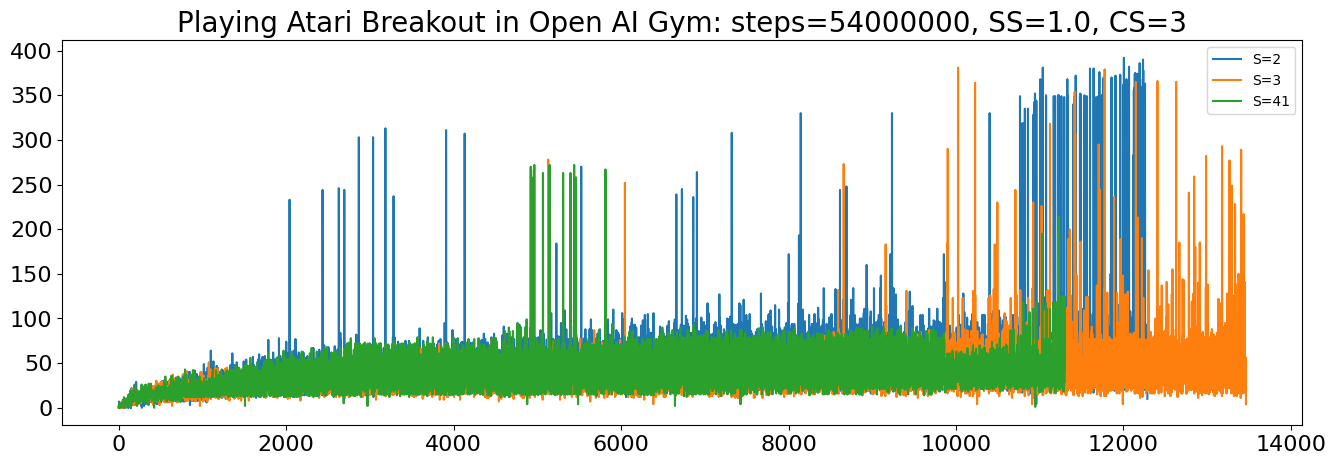

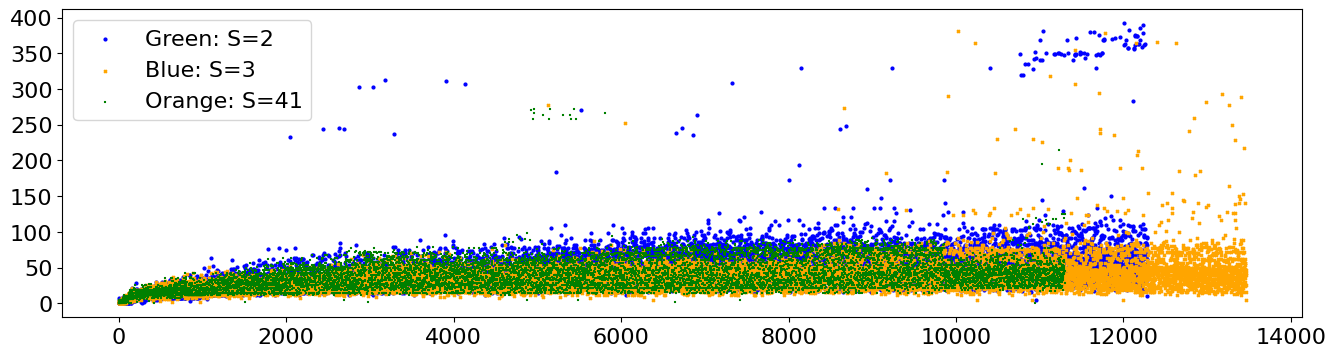

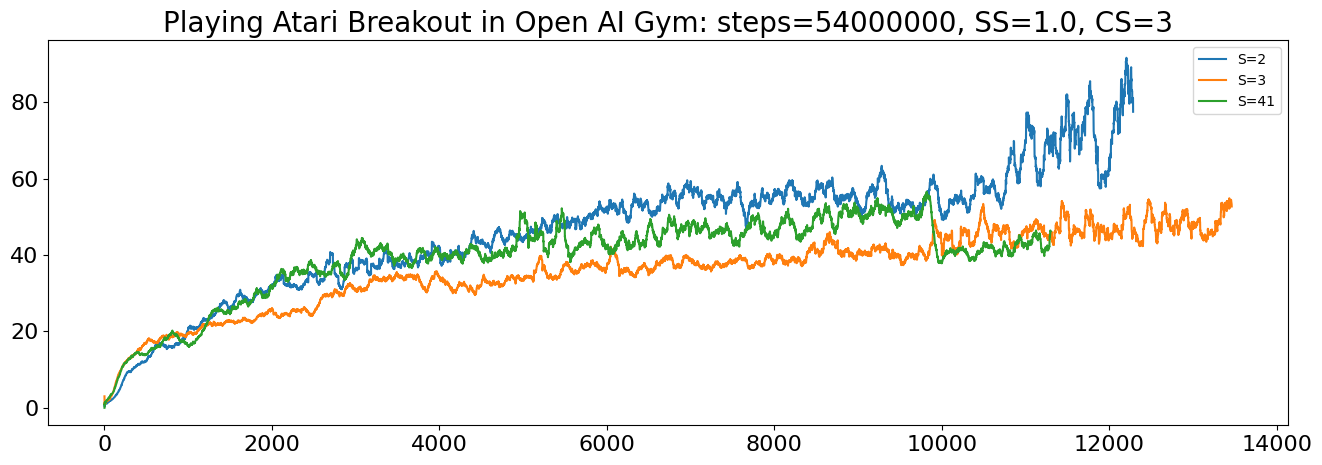

In [94]:
steps = 54000000
tit = f"Playing Atari Breakout in Open AI Gym: steps={steps}, SS=1.0, CS=3"

#python ./aigents-gym/breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=2 -mg=500000 -mt=54000000 -sm="exp(-d)" -cs=3 > sim_test3/exp54000000_s2ss10lm2sc2cs3tu0.txt
# --//-- 3
# --//-- 41

#sim_test3/exp54000000_s2ss10lm2sc2cs3tu0.txt:score_avg=46.8; steps_tot=54000000; steps_avg=4394.9; lives_avg=0.0; lapse_avg="0:00:00.611124"; time="4:15:02.810269"
#sim_test3/exp54000000_s3ss10lm2sc2cs3tu0.txt:score_avg=36.2; steps_tot=54000000; steps_avg=4010.4; lives_avg=0.0; lapse_avg="0:00:00.232075"; time="4:25:20.052576"
#sim_test3/exp54000000_s41ss10lm2sc2cs3tu0.txt:score_avg=39.5; steps_tot=54000000; steps_avg=4778.8; lives_avg=0.1; lapse_avg="0:00:01.108659"; time="4:22:17.749574"

M54_s2ss10lm2sc2cs3tu0 = [1.0, 0, 0, 0, 1.0, 7.0, 1.0, 0, 5.0, 1.0, 1.0, 0, 2.0, 4.0, 0, 0, 2.0, 0, 0, 2.0, 1.0, 0, 1.0, 0, 1.0, 0, 2.0, 0, 1.0, 1.0, 1.0, 4.0, 1.0, 1.0, 6.0, 0, 4.0, 3.0, 3.0, 3.0, 1.0, 3.0, 1.0, 1.0, 1.0, 2.0, 1.0, 0, 4.0, 2.0, 9.0, 2.0, 0, 3.0, 4.0, 2.0, 3.0, 3.0, 0, 1.0, 5.0, 2.0, 2.0, 3.0, 2.0, 1.0, 3.0, 2.0, 5.0, 2.0, 7.0, 2.0, 1.0, 0, 1.0, 2.0, 3.0, 3.0, 5.0, 4.0, 4.0, 5.0, 6.0, 6.0, 6.0, 2.0, 0, 2.0, 2.0, 7.0, 4.0, 2.0, 2.0, 2.0, 4.0, 3.0, 1.0, 6.0, 3.0, 4.0, 4.0, 4.0, 3.0, 5.0, 3.0, 5.0, 11.0, 3.0, 5.0, 3.0, 4.0, 6.0, 0, 6.0, 2.0, 2.0, 1.0, 1.0, 2.0, 0, 2.0, 5.0, 9.0, 3.0, 3.0, 3.0, 3.0, 2.0, 6.0, 5.0, 11.0, 4.0, 7.0, 5.0, 2.0, 4.0, 7.0, 2.0, 9.0, 5.0, 5.0, 4.0, 6.0, 4.0, 0, 4.0, 0, 5.0, 2.0, 6.0, 9.0, 6.0, 5.0, 4.0, 22.0, 5.0, 5.0, 6.0, 3.0, 3.0, 7.0, 6.0, 7.0, 6.0, 7.0, 3.0, 9.0, 6.0, 5.0, 6.0, 5.0, 14.0, 5.0, 6.0, 14.0, 5.0, 4.0, 3.0, 4.0, 5.0, 9.0, 8.0, 9.0, 9.0, 6.0, 7.0, 10.0, 16.0, 9.0, 9.0, 3.0, 8.0, 7.0, 11.0, 5.0, 7.0, 7.0, 8.0, 13.0, 14.0, 8.0, 8.0, 20.0, 4.0, 8.0, 5.0, 8.0, 6.0, 29.0, 11.0, 10.0, 7.0, 7.0, 20.0, 10.0, 6.0, 7.0, 7.0, 6.0, 11.0, 8.0, 9.0, 5.0, 10.0, 6.0, 9.0, 8.0, 7.0, 6.0, 6.0, 8.0, 17.0, 6.0, 6.0, 12.0, 12.0, 8.0, 10.0, 8.0, 16.0, 10.0, 11.0, 18.0, 9.0, 10.0, 8.0, 8.0, 9.0, 8.0, 9.0, 7.0, 8.0, 9.0, 9.0, 16.0, 11.0, 6.0, 9.0, 9.0, 12.0, 17.0, 8.0, 18.0, 8.0, 9.0, 9.0, 9.0, 7.0, 7.0, 8.0, 10.0, 20.0, 2.0, 8.0, 8.0, 10.0, 19.0, 0, 11.0, 6.0, 9.0, 10.0, 10.0, 7.0, 11.0, 7.0, 14.0, 7.0, 15.0, 17.0, 3.0, 9.0, 9.0, 9.0, 7.0, 8.0, 8.0, 8.0, 10.0, 8.0, 12.0, 5.0, 2.0, 12.0, 10.0, 11.0, 11.0, 7.0, 10.0, 13.0, 8.0, 13.0, 11.0, 11.0, 8.0, 16.0, 9.0, 22.0, 9.0, 9.0, 13.0, 16.0, 4.0, 7.0, 11.0, 13.0, 16.0, 8.0, 12.0, 11.0, 13.0, 15.0, 13.0, 10.0, 14.0, 7.0, 9.0, 8.0, 18.0, 15.0, 8.0, 11.0, 9.0, 13.0, 16.0, 12.0, 16.0, 17.0, 15.0, 10.0, 7.0, 20.0, 10.0, 11.0, 10.0, 13.0, 9.0, 17.0, 8.0, 8.0, 7.0, 7.0, 14.0, 12.0, 17.0, 16.0, 8.0, 12.0, 11.0, 9.0, 11.0, 10.0, 10.0, 23.0, 7.0, 11.0, 8.0, 7.0, 16.0, 15.0, 19.0, 9.0, 11.0, 8.0, 10.0, 15.0, 7.0, 9.0, 9.0, 10.0, 7.0, 10.0, 16.0, 12.0, 10.0, 17.0, 8.0, 13.0, 10.0, 8.0, 9.0, 9.0, 20.0, 7.0, 9.0, 13.0, 5.0, 10.0, 15.0, 12.0, 11.0, 7.0, 14.0, 12.0, 7.0, 7.0, 14.0, 23.0, 6.0, 9.0, 15.0, 10.0, 9.0, 11.0, 14.0, 9.0, 8.0, 24.0, 10.0, 14.0, 20.0, 23.0, 5.0, 11.0, 17.0, 19.0, 14.0, 11.0, 10.0, 9.0, 25.0, 8.0, 18.0, 12.0, 12.0, 17.0, 17.0, 16.0, 30.0, 17.0, 9.0, 12.0, 7.0, 8.0, 10.0, 8.0, 7.0, 9.0, 4.0, 15.0, 11.0, 11.0, 15.0, 11.0, 11.0, 16.0, 10.0, 11.0, 10.0, 9.0, 9.0, 13.0, 16.0, 11.0, 11.0, 11.0, 15.0, 22.0, 10.0, 8.0, 15.0, 14.0, 7.0, 11.0, 7.0, 11.0, 13.0, 16.0, 8.0, 7.0, 20.0, 10.0, 13.0, 13.0, 7.0, 17.0, 10.0, 17.0, 11.0, 14.0, 19.0, 22.0, 9.0, 9.0, 6.0, 8.0, 23.0, 15.0, 17.0, 11.0, 18.0, 9.0, 18.0, 14.0, 28.0, 19.0, 9.0, 14.0, 19.0, 27.0, 30.0, 15.0, 11.0, 12.0, 19.0, 16.0, 13.0, 13.0, 10.0, 18.0, 13.0, 10.0, 11.0, 11.0, 14.0, 18.0, 17.0, 12.0, 18.0, 11.0, 10.0, 16.0, 21.0, 10.0, 12.0, 26.0, 16.0, 28.0, 19.0, 14.0, 9.0, 19.0, 9.0, 10.0, 16.0, 7.0, 11.0, 21.0, 14.0, 15.0, 18.0, 12.0, 16.0, 14.0, 24.0, 22.0, 21.0, 11.0, 12.0, 20.0, 11.0, 12.0, 18.0, 15.0, 17.0, 21.0, 13.0, 8.0, 19.0, 15.0, 8.0, 18.0, 10.0, 15.0, 21.0, 11.0, 18.0, 20.0, 29.0, 14.0, 23.0, 21.0, 24.0, 14.0, 20.0, 22.0, 10.0, 30.0, 8.0, 15.0, 11.0, 24.0, 24.0, 17.0, 19.0, 22.0, 13.0, 22.0, 13.0, 15.0, 15.0, 19.0, 32.0, 32.0, 8.0, 11.0, 12.0, 16.0, 16.0, 21.0, 13.0, 15.0, 7.0, 21.0, 27.0, 17.0, 27.0, 18.0, 25.0, 10.0, 18.0, 10.0, 19.0, 21.0, 7.0, 23.0, 19.0, 16.0, 18.0, 20.0, 23.0, 8.0, 13.0, 25.0, 31.0, 8.0, 18.0, 10.0, 17.0, 22.0, 13.0, 18.0, 7.0, 8.0, 14.0, 16.0, 17.0, 14.0, 12.0, 13.0, 19.0, 19.0, 10.0, 17.0, 9.0, 11.0, 21.0, 14.0, 12.0, 20.0, 15.0, 29.0, 20.0, 10.0, 18.0, 19.0, 13.0, 10.0, 19.0, 17.0, 15.0, 15.0, 19.0, 12.0, 20.0, 12.0, 8.0, 7.0, 30.0, 15.0, 19.0, 14.0, 17.0, 13.0, 12.0, 11.0, 11.0, 13.0, 30.0, 16.0, 23.0, 11.0, 31.0, 17.0, 13.0, 25.0, 15.0, 18.0, 19.0, 7.0, 9.0, 14.0, 9.0, 20.0, 16.0, 16.0, 15.0, 18.0, 15.0, 7.0, 19.0, 8.0, 29.0, 23.0, 13.0, 16.0, 10.0, 19.0, 33.0, 29.0, 19.0, 18.0, 17.0, 15.0, 10.0, 16.0, 8.0, 13.0, 9.0, 14.0, 10.0, 8.0, 7.0, 9.0, 9.0, 24.0, 15.0, 25.0, 11.0, 19.0, 19.0, 19.0, 14.0, 18.0, 13.0, 22.0, 15.0, 21.0, 11.0, 10.0, 8.0, 20.0, 18.0, 29.0, 17.0, 16.0, 37.0, 12.0, 18.0, 18.0, 11.0, 7.0, 22.0, 19.0, 16.0, 14.0, 13.0, 16.0, 9.0, 27.0, 11.0, 19.0, 11.0, 22.0, 16.0, 19.0, 8.0, 7.0, 8.0, 12.0, 28.0, 23.0, 11.0, 16.0, 18.0, 16.0, 8.0, 9.0, 13.0, 14.0, 13.0, 21.0, 12.0, 16.0, 26.0, 11.0, 11.0, 17.0, 18.0, 14.0, 28.0, 13.0, 28.0, 27.0, 12.0, 14.0, 14.0, 17.0, 17.0, 16.0, 16.0, 13.0, 25.0, 16.0, 9.0, 14.0, 11.0, 19.0, 27.0, 13.0, 17.0, 27.0, 12.0, 18.0, 40.0, 28.0, 15.0, 17.0, 11.0, 9.0, 12.0, 10.0, 17.0, 19.0, 9.0, 22.0, 19.0, 23.0, 13.0, 19.0, 40.0, 3.0, 13.0, 15.0, 19.0, 18.0, 9.0, 24.0, 16.0, 18.0, 30.0, 18.0, 20.0, 13.0, 9.0, 27.0, 8.0, 11.0, 14.0, 23.0, 20.0, 18.0, 19.0, 18.0, 18.0, 16.0, 16.0, 10.0, 9.0, 8.0, 11.0, 15.0, 23.0, 11.0, 27.0, 9.0, 20.0, 23.0, 15.0, 13.0, 13.0, 8.0, 18.0, 19.0, 24.0, 10.0, 22.0, 29.0, 21.0, 21.0, 10.0, 12.0, 8.0, 12.0, 27.0, 25.0, 11.0, 10.0, 21.0, 17.0, 29.0, 22.0, 22.0, 23.0, 19.0, 16.0, 34.0, 14.0, 11.0, 27.0, 12.0, 31.0, 15.0, 15.0, 12.0, 25.0, 20.0, 23.0, 17.0, 37.0, 38.0, 33.0, 8.0, 23.0, 11.0, 25.0, 8.0, 8.0, 20.0, 12.0, 16.0, 20.0, 13.0, 27.0, 9.0, 29.0, 26.0, 11.0, 22.0, 18.0, 11.0, 24.0, 35.0, 12.0, 13.0, 8.0, 28.0, 13.0, 21.0, 27.0, 19.0, 11.0, 24.0, 20.0, 29.0, 20.0, 33.0, 25.0, 32.0, 32.0, 17.0, 23.0, 19.0, 12.0, 10.0, 17.0, 25.0, 17.0, 11.0, 27.0, 20.0, 36.0, 23.0, 26.0, 13.0, 18.0, 25.0, 30.0, 22.0, 20.0, 9.0, 36.0, 20.0, 17.0, 20.0, 18.0, 20.0, 30.0, 22.0, 22.0, 34.0, 33.0, 35.0, 24.0, 15.0, 32.0, 18.0, 26.0, 21.0, 12.0, 33.0, 10.0, 28.0, 11.0, 23.0, 15.0, 16.0, 49.0, 9.0, 26.0, 29.0, 18.0, 22.0, 25.0, 27.0, 19.0, 14.0, 10.0, 12.0, 24.0, 20.0, 15.0, 10.0, 17.0, 24.0, 24.0, 17.0, 12.0, 18.0, 20.0, 25.0, 40.0, 12.0, 9.0, 18.0, 22.0, 10.0, 23.0, 13.0, 6.0, 26.0, 14.0, 16.0, 14.0, 16.0, 32.0, 12.0, 32.0, 31.0, 12.0, 20.0, 13.0, 45.0, 11.0, 18.0, 13.0, 15.0, 20.0, 22.0, 13.0, 34.0, 12.0, 33.0, 36.0, 22.0, 14.0, 29.0, 12.0, 11.0, 14.0, 20.0, 22.0, 24.0, 19.0, 28.0, 36.0, 11.0, 19.0, 15.0, 34.0, 15.0, 32.0, 24.0, 22.0, 16.0, 11.0, 34.0, 14.0, 35.0, 16.0, 64.0, 22.0, 14.0, 18.0, 13.0, 18.0, 31.0, 15.0, 27.0, 21.0, 16.0, 21.0, 39.0, 28.0, 14.0, 17.0, 28.0, 24.0, 12.0, 20.0, 33.0, 12.0, 17.0, 19.0, 15.0, 22.0, 12.0, 18.0, 18.0, 17.0, 31.0, 52.0, 20.0, 31.0, 21.0, 29.0, 37.0, 12.0, 13.0, 37.0, 25.0, 16.0, 14.0, 23.0, 18.0, 25.0, 30.0, 31.0, 23.0, 24.0, 21.0, 30.0, 20.0, 22.0, 23.0, 14.0, 16.0, 29.0, 16.0, 12.0, 31.0, 34.0, 19.0, 19.0, 16.0, 24.0, 15.0, 23.0, 34.0, 29.0, 27.0, 47.0, 19.0, 19.0, 22.0, 18.0, 39.0, 24.0, 37.0, 20.0, 24.0, 45.0, 26.0, 20.0, 12.0, 16.0, 22.0, 14.0, 29.0, 24.0, 18.0, 17.0, 20.0, 26.0, 25.0, 12.0, 28.0, 24.0, 28.0, 16.0, 16.0, 27.0, 36.0, 26.0, 25.0, 17.0, 25.0, 13.0, 26.0, 13.0, 16.0, 38.0, 19.0, 29.0, 12.0, 17.0, 18.0, 20.0, 32.0, 23.0, 22.0, 19.0, 30.0, 20.0, 18.0, 12.0, 24.0, 21.0, 17.0, 20.0, 17.0, 43.0, 27.0, 27.0, 11.0, 35.0, 13.0, 14.0, 30.0, 16.0, 39.0, 29.0, 18.0, 37.0, 35.0, 25.0, 27.0, 33.0, 18.0, 19.0, 18.0, 25.0, 12.0, 17.0, 26.0, 21.0, 34.0, 28.0, 42.0, 15.0, 29.0, 22.0, 13.0, 38.0, 36.0, 32.0, 30.0, 25.0, 27.0, 42.0, 23.0, 24.0, 22.0, 15.0, 23.0, 35.0, 31.0, 25.0, 15.0, 10.0, 28.0, 21.0, 38.0, 26.0, 21.0, 24.0, 39.0, 24.0, 32.0, 25.0, 16.0, 33.0, 42.0, 12.0, 15.0, 15.0, 16.0, 14.0, 16.0, 34.0, 37.0, 19.0, 22.0, 20.0, 33.0, 25.0, 19.0, 28.0, 14.0, 31.0, 33.0, 29.0, 17.0, 27.0, 23.0, 13.0, 19.0, 24.0, 19.0, 15.0, 24.0, 34.0, 33.0, 20.0, 19.0, 25.0, 25.0, 24.0, 33.0, 31.0, 28.0, 25.0, 30.0, 19.0, 26.0, 43.0, 48.0, 23.0, 36.0, 34.0, 17.0, 18.0, 22.0, 39.0, 28.0, 22.0, 16.0, 29.0, 44.0, 23.0, 22.0, 38.0, 24.0, 21.0, 24.0, 28.0, 24.0, 61.0, 24.0, 27.0, 30.0, 24.0, 31.0, 39.0, 25.0, 48.0, 18.0, 22.0, 30.0, 21.0, 24.0, 33.0, 26.0, 26.0, 26.0, 28.0, 42.0, 41.0, 41.0, 25.0, 48.0, 26.0, 20.0, 27.0, 39.0, 26.0, 43.0, 28.0, 13.0, 11.0, 27.0, 17.0, 22.0, 26.0, 21.0, 23.0, 28.0, 24.0, 24.0, 28.0, 25.0, 23.0, 26.0, 33.0, 24.0, 21.0, 25.0, 16.0, 35.0, 25.0, 51.0, 23.0, 27.0, 25.0, 22.0, 36.0, 23.0, 31.0, 24.0, 27.0, 33.0, 27.0, 37.0, 33.0, 22.0, 28.0, 21.0, 16.0, 28.0, 23.0, 20.0, 18.0, 16.0, 42.0, 39.0, 22.0, 22.0, 24.0, 29.0, 26.0, 24.0, 44.0, 12.0, 16.0, 29.0, 23.0, 31.0, 36.0, 22.0, 35.0, 33.0, 21.0, 34.0, 31.0, 28.0, 20.0, 37.0, 15.0, 29.0, 11.0, 38.0, 34.0, 24.0, 25.0, 22.0, 26.0, 25.0, 21.0, 20.0, 20.0, 23.0, 20.0, 15.0, 25.0, 17.0, 14.0, 26.0, 21.0, 17.0, 27.0, 28.0, 22.0, 34.0, 23.0, 33.0, 31.0, 23.0, 18.0, 26.0, 24.0, 12.0, 33.0, 31.0, 52.0, 21.0, 26.0, 25.0, 24.0, 33.0, 31.0, 21.0, 34.0, 32.0, 33.0, 24.0, 34.0, 20.0, 49.0, 20.0, 19.0, 24.0, 29.0, 13.0, 27.0, 25.0, 13.0, 15.0, 31.0, 31.0, 27.0, 16.0, 29.0, 40.0, 54.0, 34.0, 39.0, 31.0, 35.0, 32.0, 32.0, 42.0, 26.0, 26.0, 31.0, 31.0, 25.0, 32.0, 22.0, 34.0, 15.0, 30.0, 22.0, 32.0, 44.0, 40.0, 26.0, 44.0, 30.0, 44.0, 45.0, 33.0, 29.0, 35.0, 20.0, 35.0, 38.0, 25.0, 18.0, 24.0, 22.0, 42.0, 23.0, 29.0, 32.0, 20.0, 28.0, 31.0, 20.0, 27.0, 16.0, 31.0, 48.0, 44.0, 21.0, 46.0, 25.0, 26.0, 25.0, 28.0, 32.0, 39.0, 25.0, 21.0, 39.0, 27.0, 20.0, 34.0, 22.0, 36.0, 28.0, 31.0, 30.0, 27.0, 15.0, 35.0, 27.0, 35.0, 17.0, 22.0, 15.0, 15.0, 42.0, 37.0, 57.0, 29.0, 20.0, 48.0, 18.0, 20.0, 28.0, 27.0, 46.0, 24.0, 48.0, 41.0, 29.0, 32.0, 32.0, 39.0, 32.0, 33.0, 38.0, 34.0, 21.0, 14.0, 29.0, 17.0, 37.0, 26.0, 31.0, 34.0, 16.0, 23.0, 21.0, 15.0, 28.0, 27.0, 27.0, 32.0, 25.0, 11.0, 33.0, 46.0, 29.0, 15.0, 14.0, 45.0, 42.0, 30.0, 19.0, 22.0, 30.0, 34.0, 15.0, 36.0, 21.0, 17.0, 41.0, 19.0, 23.0, 27.0, 20.0, 20.0, 25.0, 25.0, 41.0, 46.0, 54.0, 38.0, 37.0, 27.0, 27.0, 34.0, 23.0, 26.0, 31.0, 19.0, 60.0, 15.0, 12.0, 32.0, 23.0, 28.0, 25.0, 31.0, 30.0, 29.0, 33.0, 31.0, 24.0, 53.0, 12.0, 31.0, 20.0, 16.0, 16.0, 26.0, 29.0, 27.0, 28.0, 24.0, 30.0, 39.0, 24.0, 38.0, 15.0, 14.0, 24.0, 35.0, 36.0, 25.0, 40.0, 24.0, 23.0, 22.0, 28.0, 23.0, 29.0, 57.0, 35.0, 26.0, 27.0, 20.0, 21.0, 31.0, 24.0, 29.0, 28.0, 21.0, 28.0, 24.0, 30.0, 38.0, 16.0, 32.0, 20.0, 30.0, 22.0, 23.0, 24.0, 24.0, 18.0, 41.0, 26.0, 20.0, 58.0, 22.0, 27.0, 33.0, 28.0, 20.0, 25.0, 15.0, 17.0, 40.0, 31.0, 32.0, 32.0, 13.0, 20.0, 30.0, 37.0, 28.0, 21.0, 32.0, 13.0, 29.0, 50.0, 30.0, 38.0, 28.0, 38.0, 28.0, 36.0, 54.0, 20.0, 39.0, 41.0, 24.0, 29.0, 43.0, 32.0, 26.0, 38.0, 32.0, 24.0, 25.0, 76.0, 24.0, 40.0, 23.0, 34.0, 25.0, 24.0, 33.0, 26.0, 34.0, 25.0, 29.0, 25.0, 29.0, 37.0, 26.0, 46.0, 27.0, 38.0, 31.0, 32.0, 30.0, 32.0, 24.0, 36.0, 23.0, 34.0, 36.0, 54.0, 27.0, 18.0, 23.0, 15.0, 25.0, 32.0, 20.0, 26.0, 35.0, 50.0, 29.0, 40.0, 33.0, 33.0, 28.0, 27.0, 30.0, 31.0, 14.0, 15.0, 40.0, 36.0, 27.0, 21.0, 31.0, 35.0, 32.0, 26.0, 37.0, 62.0, 22.0, 30.0, 28.0, 18.0, 24.0, 27.0, 32.0, 20.0, 34.0, 33.0, 20.0, 33.0, 30.0, 30.0, 28.0, 37.0, 30.0, 22.0, 24.0, 34.0, 54.0, 13.0, 36.0, 34.0, 33.0, 33.0, 12.0, 35.0, 48.0, 19.0, 36.0, 37.0, 27.0, 20.0, 27.0, 37.0, 31.0, 36.0, 37.0, 34.0, 24.0, 30.0, 24.0, 13.0, 38.0, 26.0, 33.0, 33.0, 31.0, 18.0, 19.0, 38.0, 32.0, 38.0, 36.0, 14.0, 25.0, 30.0, 28.0, 28.0, 33.0, 23.0, 30.0, 30.0, 26.0, 41.0, 25.0, 33.0, 78.0, 32.0, 20.0, 34.0, 17.0, 54.0, 19.0, 40.0, 29.0, 16.0, 37.0, 18.0, 21.0, 34.0, 17.0, 28.0, 58.0, 34.0, 29.0, 29.0, 29.0, 47.0, 39.0, 15.0, 23.0, 28.0, 54.0, 21.0, 23.0, 24.0, 43.0, 50.0, 32.0, 20.0, 23.0, 21.0, 53.0, 28.0, 30.0, 28.0, 39.0, 31.0, 47.0, 29.0, 15.0, 38.0, 34.0, 54.0, 43.0, 47.0, 31.0, 21.0, 18.0, 45.0, 33.0, 52.0, 37.0, 40.0, 16.0, 39.0, 35.0, 37.0, 46.0, 33.0, 37.0, 20.0, 23.0, 38.0, 38.0, 35.0, 17.0, 19.0, 26.0, 41.0, 20.0, 31.0, 31.0, 30.0, 27.0, 39.0, 35.0, 21.0, 20.0, 29.0, 25.0, 27.0, 33.0, 74.0, 36.0, 23.0, 30.0, 30.0, 26.0, 25.0, 26.0, 31.0, 26.0, 30.0, 31.0, 21.0, 28.0, 36.0, 21.0, 46.0, 61.0, 42.0, 21.0, 51.0, 31.0, 42.0, 33.0, 20.0, 50.0, 33.0, 46.0, 27.0, 16.0, 26.0, 16.0, 30.0, 30.0, 18.0, 20.0, 25.0, 44.0, 19.0, 41.0, 233.0, 27.0, 44.0, 17.0, 34.0, 43.0, 28.0, 45.0, 30.0, 28.0, 59.0, 36.0, 43.0, 49.0, 32.0, 27.0, 17.0, 26.0, 34.0, 19.0, 26.0, 41.0, 27.0, 18.0, 42.0, 25.0, 26.0, 28.0, 25.0, 47.0, 46.0, 42.0, 23.0, 39.0, 29.0, 23.0, 21.0, 35.0, 34.0, 29.0, 21.0, 24.0, 24.0, 23.0, 21.0, 19.0, 38.0, 31.0, 64.0, 31.0, 42.0, 39.0, 28.0, 15.0, 25.0, 32.0, 36.0, 37.0, 39.0, 29.0, 33.0, 29.0, 33.0, 23.0, 41.0, 22.0, 61.0, 24.0, 22.0, 42.0, 77.0, 21.0, 21.0, 29.0, 40.0, 54.0, 35.0, 64.0, 23.0, 35.0, 41.0, 19.0, 28.0, 37.0, 28.0, 32.0, 19.0, 33.0, 42.0, 47.0, 34.0, 32.0, 58.0, 22.0, 16.0, 25.0, 17.0, 23.0, 45.0, 26.0, 16.0, 31.0, 32.0, 26.0, 34.0, 44.0, 28.0, 33.0, 57.0, 18.0, 62.0, 31.0, 28.0, 33.0, 34.0, 37.0, 12.0, 28.0, 26.0, 26.0, 25.0, 15.0, 39.0, 30.0, 32.0, 24.0, 41.0, 30.0, 33.0, 42.0, 30.0, 32.0, 32.0, 24.0, 17.0, 15.0, 34.0, 32.0, 29.0, 31.0, 27.0, 29.0, 60.0, 23.0, 18.0, 26.0, 34.0, 32.0, 40.0, 38.0, 24.0, 31.0, 14.0, 43.0, 42.0, 45.0, 33.0, 41.0, 18.0, 62.0, 37.0, 15.0, 40.0, 38.0, 26.0, 62.0, 17.0, 35.0, 21.0, 43.0, 26.0, 30.0, 18.0, 14.0, 47.0, 35.0, 35.0, 39.0, 37.0, 35.0, 18.0, 33.0, 36.0, 33.0, 40.0, 32.0, 37.0, 56.0, 23.0, 47.0, 22.0, 21.0, 28.0, 34.0, 17.0, 51.0, 19.0, 24.0, 23.0, 25.0, 31.0, 36.0, 14.0, 41.0, 30.0, 41.0, 34.0, 38.0, 30.0, 34.0, 41.0, 31.0, 58.0, 50.0, 38.0, 27.0, 31.0, 33.0, 24.0, 34.0, 17.0, 34.0, 29.0, 14.0, 17.0, 50.0, 34.0, 25.0, 40.0, 21.0, 49.0, 19.0, 15.0, 35.0, 26.0, 16.0, 32.0, 26.0, 28.0, 27.0, 34.0, 22.0, 24.0, 43.0, 49.0, 19.0, 24.0, 23.0, 31.0, 43.0, 31.0, 31.0, 32.0, 20.0, 25.0, 28.0, 18.0, 37.0, 29.0, 44.0, 33.0, 34.0, 41.0, 14.0, 36.0, 33.0, 31.0, 67.0, 18.0, 25.0, 20.0, 29.0, 30.0, 22.0, 37.0, 28.0, 32.0, 37.0, 21.0, 25.0, 25.0, 24.0, 44.0, 25.0, 67.0, 42.0, 32.0, 38.0, 31.0, 36.0, 42.0, 26.0, 17.0, 29.0, 38.0, 34.0, 36.0, 29.0, 52.0, 23.0, 28.0, 26.0, 27.0, 28.0, 48.0, 43.0, 40.0, 53.0, 26.0, 20.0, 26.0, 28.0, 33.0, 33.0, 26.0, 38.0, 33.0, 28.0, 27.0, 34.0, 38.0, 38.0, 56.0, 24.0, 23.0, 37.0, 34.0, 33.0, 44.0, 35.0, 24.0, 24.0, 39.0, 35.0, 48.0, 35.0, 33.0, 24.0, 24.0, 51.0, 22.0, 25.0, 16.0, 30.0, 39.0, 36.0, 27.0, 18.0, 24.0, 38.0, 32.0, 31.0, 64.0, 28.0, 65.0, 34.0, 18.0, 39.0, 36.0, 41.0, 26.0, 26.0, 37.0, 39.0, 39.0, 58.0, 25.0, 22.0, 39.0, 22.0, 33.0, 19.0, 25.0, 51.0, 31.0, 33.0, 41.0, 23.0, 40.0, 37.0, 32.0, 31.0, 33.0, 31.0, 61.0, 19.0, 36.0, 19.0, 35.0, 24.0, 14.0, 17.0, 27.0, 24.0, 244.0, 41.0, 39.0, 22.0, 39.0, 39.0, 16.0, 41.0, 40.0, 67.0, 25.0, 27.0, 31.0, 42.0, 24.0, 30.0, 32.0, 40.0, 22.0, 36.0, 70.0, 32.0, 28.0, 28.0, 31.0, 35.0, 22.0, 33.0, 40.0, 26.0, 31.0, 28.0, 39.0, 21.0, 62.0, 21.0, 15.0, 26.0, 20.0, 43.0, 27.0, 21.0, 32.0, 25.0, 25.0, 46.0, 33.0, 31.0, 18.0, 40.0, 23.0, 25.0, 28.0, 31.0, 36.0, 32.0, 32.0, 35.0, 31.0, 28.0, 34.0, 32.0, 51.0, 30.0, 53.0, 19.0, 34.0, 38.0, 32.0, 68.0, 21.0, 47.0, 66.0, 16.0, 28.0, 41.0, 32.0, 33.0, 27.0, 35.0, 39.0, 38.0, 27.0, 31.0, 27.0, 35.0, 27.0, 30.0, 31.0, 41.0, 38.0, 53.0, 38.0, 27.0, 30.0, 29.0, 28.0, 36.0, 30.0, 37.0, 26.0, 36.0, 31.0, 20.0, 32.0, 37.0, 20.0, 45.0, 39.0, 28.0, 26.0, 36.0, 36.0, 26.0, 34.0, 32.0, 25.0, 21.0, 34.0, 42.0, 32.0, 31.0, 16.0, 20.0, 33.0, 34.0, 31.0, 33.0, 27.0, 25.0, 60.0, 31.0, 24.0, 59.0, 26.0, 43.0, 52.0, 44.0, 34.0, 32.0, 24.0, 44.0, 21.0, 48.0, 23.0, 69.0, 21.0, 24.0, 27.0, 30.0, 13.0, 20.0, 16.0, 31.0, 35.0, 23.0, 42.0, 44.0, 25.0, 37.0, 27.0, 28.0, 35.0, 46.0, 56.0, 45.0, 41.0, 40.0, 37.0, 52.0, 37.0, 20.0, 27.0, 18.0, 45.0, 36.0, 32.0, 28.0, 65.0, 37.0, 29.0, 35.0, 29.0, 33.0, 19.0, 48.0, 47.0, 27.0, 33.0, 35.0, 31.0, 35.0, 66.0, 41.0, 246.0, 36.0, 30.0, 43.0, 73.0, 24.0, 23.0, 33.0, 44.0, 31.0, 67.0, 29.0, 33.0, 33.0, 39.0, 28.0, 30.0, 40.0, 84.0, 31.0, 77.0, 41.0, 29.0, 37.0, 28.0, 50.0, 23.0, 51.0, 34.0, 32.0, 39.0, 41.0, 20.0, 24.0, 24.0, 25.0, 35.0, 51.0, 36.0, 37.0, 28.0, 42.0, 22.0, 37.0, 25.0, 37.0, 25.0, 33.0, 35.0, 31.0, 33.0, 26.0, 29.0, 34.0, 24.0, 28.0, 35.0, 33.0, 37.0, 29.0, 37.0, 32.0, 32.0, 32.0, 31.0, 244.0, 43.0, 35.0, 70.0, 31.0, 34.0, 26.0, 47.0, 43.0, 23.0, 56.0, 20.0, 44.0, 28.0, 31.0, 26.0, 52.0, 33.0, 24.0, 66.0, 29.0, 22.0, 24.0, 33.0, 45.0, 33.0, 35.0, 39.0, 50.0, 39.0, 31.0, 26.0, 31.0, 39.0, 45.0, 20.0, 39.0, 16.0, 29.0, 22.0, 38.0, 26.0, 32.0, 28.0, 38.0, 38.0, 42.0, 33.0, 19.0, 20.0, 36.0, 20.0, 25.0, 25.0, 27.0, 12.0, 21.0, 31.0, 34.0, 53.0, 30.0, 41.0, 28.0, 21.0, 28.0, 30.0, 30.0, 24.0, 28.0, 24.0, 43.0, 40.0, 18.0, 36.0, 16.0, 35.0, 45.0, 24.0, 33.0, 21.0, 15.0, 39.0, 39.0, 28.0, 37.0, 32.0, 35.0, 28.0, 35.0, 31.0, 21.0, 29.0, 42.0, 20.0, 35.0, 45.0, 25.0, 35.0, 33.0, 29.0, 35.0, 40.0, 33.0, 57.0, 36.0, 49.0, 56.0, 26.0, 19.0, 39.0, 20.0, 24.0, 25.0, 38.0, 23.0, 33.0, 30.0, 38.0, 29.0, 32.0, 31.0, 16.0, 36.0, 30.0, 29.0, 25.0, 47.0, 26.0, 64.0, 20.0, 20.0, 30.0, 24.0, 55.0, 30.0, 30.0, 23.0, 28.0, 15.0, 27.0, 28.0, 41.0, 27.0, 82.0, 29.0, 41.0, 35.0, 27.0, 34.0, 25.0, 30.0, 21.0, 29.0, 44.0, 25.0, 44.0, 32.0, 40.0, 32.0, 66.0, 58.0, 59.0, 52.0, 30.0, 27.0, 20.0, 35.0, 20.0, 55.0, 17.0, 40.0, 57.0, 49.0, 45.0, 303.0, 31.0, 60.0, 28.0, 29.0, 43.0, 39.0, 24.0, 23.0, 61.0, 39.0, 25.0, 53.0, 27.0, 36.0, 31.0, 28.0, 36.0, 34.0, 37.0, 32.0, 31.0, 60.0, 27.0, 18.0, 27.0, 36.0, 41.0, 28.0, 29.0, 34.0, 36.0, 20.0, 34.0, 14.0, 21.0, 51.0, 43.0, 42.0, 27.0, 35.0, 26.0, 48.0, 32.0, 52.0, 40.0, 29.0, 25.0, 28.0, 37.0, 32.0, 16.0, 36.0, 27.0, 37.0, 30.0, 20.0, 22.0, 37.0, 53.0, 29.0, 34.0, 31.0, 19.0, 57.0, 35.0, 37.0, 31.0, 64.0, 40.0, 33.0, 26.0, 37.0, 34.0, 41.0, 70.0, 42.0, 67.0, 18.0, 40.0, 29.0, 36.0, 35.0, 65.0, 35.0, 24.0, 40.0, 23.0, 39.0, 51.0, 39.0, 52.0, 26.0, 29.0, 38.0, 30.0, 38.0, 43.0, 20.0, 70.0, 19.0, 28.0, 41.0, 40.0, 46.0, 15.0, 32.0, 38.0, 42.0, 37.0, 39.0, 23.0, 24.0, 18.0, 39.0, 59.0, 33.0, 63.0, 41.0, 29.0, 67.0, 42.0, 28.0, 47.0, 21.0, 37.0, 43.0, 39.0, 23.0, 32.0, 44.0, 31.0, 46.0, 33.0, 30.0, 31.0, 41.0, 23.0, 45.0, 28.0, 15.0, 43.0, 44.0, 15.0, 41.0, 32.0, 32.0, 46.0, 22.0, 18.0, 28.0, 29.0, 44.0, 40.0, 25.0, 40.0, 37.0, 40.0, 29.0, 37.0, 39.0, 31.0, 19.0, 37.0, 38.0, 39.0, 64.0, 29.0, 36.0, 37.0, 303.0, 39.0, 43.0, 34.0, 12.0, 49.0, 48.0, 22.0, 33.0, 26.0, 20.0, 28.0, 30.0, 51.0, 25.0, 49.0, 47.0, 55.0, 36.0, 52.0, 19.0, 31.0, 41.0, 44.0, 55.0, 49.0, 34.0, 39.0, 20.0, 31.0, 22.0, 23.0, 34.0, 32.0, 42.0, 32.0, 22.0, 41.0, 55.0, 35.0, 58.0, 47.0, 15.0, 21.0, 41.0, 28.0, 56.0, 46.0, 21.0, 38.0, 41.0, 47.0, 26.0, 42.0, 40.0, 32.0, 34.0, 39.0, 17.0, 37.0, 23.0, 19.0, 33.0, 24.0, 29.0, 60.0, 22.0, 33.0, 38.0, 32.0, 20.0, 46.0, 29.0, 38.0, 36.0, 54.0, 35.0, 33.0, 39.0, 42.0, 41.0, 55.0, 38.0, 38.0, 39.0, 39.0, 29.0, 32.0, 50.0, 35.0, 36.0, 48.0, 37.0, 16.0, 19.0, 37.0, 15.0, 32.0, 35.0, 49.0, 19.0, 61.0, 26.0, 43.0, 49.0, 17.0, 15.0, 26.0, 38.0, 41.0, 24.0, 47.0, 24.0, 21.0, 27.0, 24.0, 45.0, 30.0, 36.0, 39.0, 48.0, 59.0, 18.0, 23.0, 49.0, 24.0, 34.0, 67.0, 36.0, 49.0, 42.0, 40.0, 25.0, 34.0, 31.0, 21.0, 43.0, 14.0, 19.0, 33.0, 46.0, 54.0, 44.0, 32.0, 48.0, 32.0, 22.0, 313.0, 19.0, 36.0, 20.0, 19.0, 49.0, 26.0, 46.0, 33.0, 30.0, 39.0, 37.0, 28.0, 23.0, 34.0, 32.0, 28.0, 33.0, 24.0, 37.0, 45.0, 32.0, 35.0, 45.0, 52.0, 15.0, 36.0, 31.0, 40.0, 17.0, 27.0, 47.0, 22.0, 47.0, 35.0, 51.0, 29.0, 18.0, 38.0, 37.0, 43.0, 42.0, 30.0, 33.0, 32.0, 27.0, 47.0, 15.0, 34.0, 26.0, 34.0, 34.0, 36.0, 32.0, 23.0, 25.0, 48.0, 47.0, 42.0, 27.0, 48.0, 28.0, 27.0, 20.0, 22.0, 26.0, 36.0, 28.0, 23.0, 38.0, 43.0, 30.0, 34.0, 28.0, 36.0, 44.0, 41.0, 46.0, 47.0, 47.0, 35.0, 41.0, 41.0, 30.0, 35.0, 34.0, 35.0, 31.0, 40.0, 28.0, 79.0, 31.0, 28.0, 45.0, 15.0, 46.0, 41.0, 35.0, 237.0, 26.0, 44.0, 51.0, 47.0, 26.0, 43.0, 46.0, 26.0, 39.0, 39.0, 32.0, 79.0, 36.0, 20.0, 35.0, 30.0, 44.0, 46.0, 30.0, 16.0, 29.0, 38.0, 45.0, 66.0, 17.0, 48.0, 54.0, 36.0, 28.0, 44.0, 42.0, 41.0, 36.0, 48.0, 45.0, 27.0, 34.0, 37.0, 38.0, 48.0, 62.0, 20.0, 28.0, 38.0, 35.0, 51.0, 40.0, 51.0, 37.0, 58.0, 34.0, 50.0, 70.0, 74.0, 38.0, 34.0, 51.0, 34.0, 35.0, 33.0, 35.0, 19.0, 28.0, 34.0, 24.0, 42.0, 26.0, 36.0, 53.0, 49.0, 51.0, 32.0, 25.0, 34.0, 55.0, 28.0, 55.0, 24.0, 42.0, 32.0, 29.0, 21.0, 37.0, 43.0, 37.0, 19.0, 38.0, 37.0, 17.0, 36.0, 33.0, 66.0, 35.0, 49.0, 22.0, 45.0, 15.0, 38.0, 17.0, 35.0, 27.0, 49.0, 33.0, 41.0, 50.0, 44.0, 25.0, 70.0, 36.0, 24.0, 59.0, 66.0, 34.0, 47.0, 45.0, 42.0, 41.0, 27.0, 43.0, 55.0, 54.0, 31.0, 39.0, 36.0, 15.0, 44.0, 24.0, 42.0, 18.0, 19.0, 48.0, 41.0, 71.0, 32.0, 16.0, 71.0, 38.0, 40.0, 39.0, 30.0, 35.0, 75.0, 18.0, 38.0, 44.0, 32.0, 24.0, 21.0, 63.0, 32.0, 48.0, 29.0, 27.0, 17.0, 34.0, 32.0, 34.0, 32.0, 24.0, 41.0, 21.0, 28.0, 28.0, 23.0, 19.0, 47.0, 32.0, 33.0, 36.0, 30.0, 35.0, 41.0, 34.0, 54.0, 41.0, 20.0, 36.0, 35.0, 32.0, 40.0, 48.0, 44.0, 43.0, 75.0, 29.0, 31.0, 24.0, 35.0, 36.0, 52.0, 34.0, 47.0, 45.0, 33.0, 51.0, 45.0, 45.0, 44.0, 38.0, 42.0, 41.0, 59.0, 66.0, 22.0, 26.0, 45.0, 19.0, 41.0, 46.0, 34.0, 41.0, 34.0, 63.0, 39.0, 24.0, 28.0, 29.0, 38.0, 36.0, 30.0, 34.0, 31.0, 32.0, 45.0, 40.0, 33.0, 44.0, 49.0, 41.0, 34.0, 15.0, 20.0, 59.0, 24.0, 42.0, 70.0, 41.0, 50.0, 28.0, 39.0, 46.0, 39.0, 33.0, 30.0, 29.0, 12.0, 26.0, 30.0, 52.0, 46.0, 20.0, 23.0, 25.0, 32.0, 20.0, 32.0, 51.0, 28.0, 27.0, 48.0, 40.0, 49.0, 35.0, 43.0, 40.0, 45.0, 49.0, 38.0, 42.0, 39.0, 47.0, 23.0, 56.0, 31.0, 43.0, 36.0, 41.0, 45.0, 33.0, 33.0, 43.0, 57.0, 29.0, 67.0, 29.0, 33.0, 20.0, 20.0, 32.0, 51.0, 35.0, 27.0, 25.0, 50.0, 49.0, 37.0, 35.0, 60.0, 30.0, 35.0, 29.0, 51.0, 30.0, 55.0, 58.0, 26.0, 45.0, 36.0, 31.0, 28.0, 89.0, 47.0, 39.0, 42.0, 24.0, 34.0, 43.0, 41.0, 23.0, 53.0, 42.0, 31.0, 39.0, 33.0, 39.0, 20.0, 66.0, 19.0, 42.0, 41.0, 50.0, 27.0, 38.0, 38.0, 33.0, 22.0, 37.0, 58.0, 54.0, 21.0, 41.0, 39.0, 53.0, 33.0, 52.0, 60.0, 24.0, 58.0, 47.0, 48.0, 36.0, 32.0, 26.0, 75.0, 34.0, 36.0, 54.0, 42.0, 51.0, 61.0, 44.0, 37.0, 24.0, 40.0, 38.0, 23.0, 31.0, 39.0, 36.0, 20.0, 38.0, 30.0, 39.0, 20.0, 39.0, 22.0, 31.0, 36.0, 48.0, 59.0, 39.0, 19.0, 25.0, 21.0, 22.0, 28.0, 43.0, 41.0, 19.0, 29.0, 51.0, 32.0, 19.0, 34.0, 37.0, 39.0, 48.0, 39.0, 48.0, 37.0, 35.0, 42.0, 51.0, 31.0, 28.0, 46.0, 39.0, 21.0, 79.0, 33.0, 69.0, 36.0, 33.0, 36.0, 21.0, 46.0, 35.0, 53.0, 46.0, 35.0, 44.0, 30.0, 65.0, 38.0, 41.0, 25.0, 47.0, 36.0, 65.0, 37.0, 15.0, 28.0, 34.0, 31.0, 15.0, 49.0, 46.0, 24.0, 34.0, 41.0, 55.0, 41.0, 50.0, 33.0, 51.0, 60.0, 28.0, 53.0, 38.0, 41.0, 22.0, 30.0, 47.0, 33.0, 30.0, 27.0, 35.0, 27.0, 25.0, 56.0, 34.0, 17.0, 59.0, 37.0, 34.0, 44.0, 41.0, 24.0, 49.0, 70.0, 57.0, 47.0, 28.0, 39.0, 44.0, 15.0, 27.0, 72.0, 43.0, 26.0, 24.0, 46.0, 36.0, 19.0, 51.0, 57.0, 62.0, 31.0, 47.0, 40.0, 66.0, 55.0, 31.0, 30.0, 32.0, 30.0, 34.0, 27.0, 61.0, 47.0, 39.0, 28.0, 35.0, 47.0, 36.0, 42.0, 34.0, 40.0, 28.0, 41.0, 24.0, 35.0, 50.0, 28.0, 28.0, 28.0, 59.0, 51.0, 37.0, 56.0, 29.0, 43.0, 38.0, 71.0, 50.0, 28.0, 54.0, 31.0, 34.0, 46.0, 27.0, 40.0, 70.0, 27.0, 32.0, 43.0, 19.0, 75.0, 39.0, 29.0, 39.0, 47.0, 28.0, 54.0, 34.0, 37.0, 62.0, 46.0, 33.0, 47.0, 30.0, 50.0, 39.0, 35.0, 25.0, 25.0, 33.0, 20.0, 77.0, 60.0, 40.0, 47.0, 25.0, 56.0, 39.0, 50.0, 59.0, 30.0, 32.0, 21.0, 40.0, 40.0, 41.0, 19.0, 29.0, 56.0, 61.0, 44.0, 44.0, 48.0, 28.0, 58.0, 20.0, 57.0, 31.0, 41.0, 19.0, 55.0, 20.0, 44.0, 38.0, 28.0, 48.0, 25.0, 26.0, 22.0, 37.0, 30.0, 31.0, 35.0, 43.0, 24.0, 23.0, 31.0, 22.0, 29.0, 37.0, 66.0, 20.0, 95.0, 71.0, 42.0, 43.0, 30.0, 38.0, 78.0, 54.0, 31.0, 35.0, 37.0, 58.0, 51.0, 39.0, 40.0, 44.0, 75.0, 311.0, 65.0, 35.0, 30.0, 35.0, 32.0, 29.0, 35.0, 36.0, 40.0, 37.0, 48.0, 20.0, 51.0, 36.0, 73.0, 40.0, 34.0, 38.0, 30.0, 33.0, 31.0, 39.0, 16.0, 33.0, 40.0, 33.0, 28.0, 26.0, 22.0, 56.0, 39.0, 64.0, 45.0, 33.0, 32.0, 43.0, 42.0, 37.0, 24.0, 39.0, 23.0, 31.0, 19.0, 40.0, 42.0, 49.0, 53.0, 19.0, 24.0, 44.0, 30.0, 44.0, 18.0, 53.0, 44.0, 58.0, 31.0, 43.0, 41.0, 34.0, 32.0, 24.0, 37.0, 43.0, 36.0, 41.0, 44.0, 31.0, 24.0, 48.0, 16.0, 32.0, 38.0, 36.0, 38.0, 19.0, 87.0, 44.0, 16.0, 33.0, 82.0, 30.0, 41.0, 58.0, 44.0, 33.0, 79.0, 47.0, 48.0, 34.0, 54.0, 34.0, 36.0, 36.0, 53.0, 19.0, 18.0, 63.0, 36.0, 18.0, 26.0, 37.0, 43.0, 36.0, 29.0, 35.0, 30.0, 20.0, 36.0, 40.0, 49.0, 23.0, 24.0, 37.0, 51.0, 24.0, 32.0, 45.0, 40.0, 77.0, 21.0, 27.0, 27.0, 50.0, 39.0, 45.0, 31.0, 39.0, 22.0, 37.0, 31.0, 40.0, 63.0, 71.0, 38.0, 19.0, 73.0, 33.0, 30.0, 45.0, 33.0, 36.0, 53.0, 14.0, 51.0, 72.0, 40.0, 21.0, 32.0, 17.0, 48.0, 54.0, 39.0, 70.0, 41.0, 25.0, 30.0, 40.0, 20.0, 51.0, 58.0, 27.0, 37.0, 32.0, 18.0, 30.0, 54.0, 20.0, 44.0, 27.0, 30.0, 31.0, 54.0, 34.0, 48.0, 33.0, 40.0, 39.0, 63.0, 45.0, 20.0, 73.0, 39.0, 49.0, 40.0, 42.0, 39.0, 37.0, 19.0, 24.0, 50.0, 55.0, 74.0, 39.0, 52.0, 17.0, 26.0, 43.0, 33.0, 33.0, 20.0, 38.0, 44.0, 45.0, 37.0, 27.0, 48.0, 20.0, 19.0, 39.0, 41.0, 34.0, 39.0, 39.0, 39.0, 25.0, 22.0, 38.0, 31.0, 44.0, 37.0, 307.0, 40.0, 38.0, 35.0, 28.0, 35.0, 24.0, 36.0, 48.0, 27.0, 25.0, 20.0, 38.0, 37.0, 19.0, 55.0, 29.0, 57.0, 20.0, 20.0, 30.0, 36.0, 26.0, 46.0, 34.0, 43.0, 52.0, 38.0, 50.0, 35.0, 52.0, 63.0, 37.0, 38.0, 48.0, 41.0, 73.0, 48.0, 33.0, 40.0, 36.0, 35.0, 28.0, 29.0, 37.0, 40.0, 20.0, 34.0, 48.0, 37.0, 32.0, 63.0, 58.0, 44.0, 60.0, 41.0, 27.0, 32.0, 33.0, 38.0, 27.0, 30.0, 40.0, 34.0, 66.0, 73.0, 34.0, 29.0, 18.0, 36.0, 41.0, 42.0, 46.0, 35.0, 42.0, 36.0, 33.0, 39.0, 41.0, 40.0, 35.0, 28.0, 28.0, 34.0, 19.0, 51.0, 16.0, 53.0, 41.0, 36.0, 44.0, 59.0, 54.0, 73.0, 55.0, 61.0, 53.0, 40.0, 38.0, 70.0, 49.0, 33.0, 32.0, 59.0, 31.0, 51.0, 41.0, 32.0, 51.0, 34.0, 27.0, 32.0, 31.0, 41.0, 34.0, 51.0, 42.0, 19.0, 51.0, 17.0, 36.0, 31.0, 22.0, 40.0, 41.0, 35.0, 34.0, 45.0, 55.0, 27.0, 45.0, 37.0, 62.0, 43.0, 37.0, 29.0, 38.0, 51.0, 49.0, 44.0, 48.0, 31.0, 40.0, 27.0, 33.0, 67.0, 43.0, 19.0, 32.0, 29.0, 20.0, 25.0, 27.0, 39.0, 39.0, 37.0, 21.0, 42.0, 33.0, 27.0, 41.0, 65.0, 57.0, 49.0, 53.0, 39.0, 46.0, 45.0, 46.0, 36.0, 19.0, 49.0, 43.0, 19.0, 41.0, 22.0, 35.0, 35.0, 37.0, 63.0, 50.0, 40.0, 75.0, 37.0, 52.0, 56.0, 45.0, 54.0, 33.0, 50.0, 44.0, 38.0, 30.0, 47.0, 43.0, 53.0, 52.0, 52.0, 62.0, 56.0, 58.0, 49.0, 49.0, 37.0, 76.0, 53.0, 34.0, 59.0, 33.0, 43.0, 23.0, 33.0, 23.0, 46.0, 50.0, 23.0, 44.0, 19.0, 43.0, 63.0, 35.0, 33.0, 49.0, 44.0, 34.0, 43.0, 38.0, 51.0, 53.0, 83.0, 48.0, 46.0, 42.0, 43.0, 48.0, 46.0, 54.0, 61.0, 47.0, 43.0, 38.0, 31.0, 27.0, 53.0, 51.0, 77.0, 34.0, 12.0, 45.0, 54.0, 53.0, 55.0, 63.0, 44.0, 31.0, 68.0, 49.0, 51.0, 50.0, 27.0, 49.0, 33.0, 40.0, 32.0, 39.0, 33.0, 38.0, 73.0, 53.0, 42.0, 66.0, 33.0, 55.0, 40.0, 52.0, 47.0, 47.0, 73.0, 44.0, 39.0, 28.0, 29.0, 46.0, 48.0, 37.0, 43.0, 37.0, 26.0, 43.0, 45.0, 48.0, 39.0, 33.0, 28.0, 41.0, 44.0, 26.0, 28.0, 49.0, 33.0, 45.0, 29.0, 45.0, 29.0, 47.0, 48.0, 50.0, 37.0, 30.0, 61.0, 44.0, 47.0, 41.0, 59.0, 27.0, 49.0, 54.0, 54.0, 48.0, 46.0, 79.0, 35.0, 29.0, 38.0, 35.0, 34.0, 59.0, 68.0, 15.0, 27.0, 35.0, 46.0, 59.0, 40.0, 43.0, 36.0, 34.0, 36.0, 43.0, 46.0, 38.0, 37.0, 63.0, 52.0, 61.0, 28.0, 58.0, 37.0, 27.0, 49.0, 38.0, 83.0, 51.0, 46.0, 24.0, 44.0, 31.0, 40.0, 50.0, 54.0, 44.0, 49.0, 55.0, 43.0, 59.0, 24.0, 68.0, 40.0, 66.0, 44.0, 27.0, 55.0, 40.0, 44.0, 63.0, 44.0, 45.0, 17.0, 64.0, 63.0, 73.0, 49.0, 28.0, 40.0, 18.0, 20.0, 33.0, 30.0, 15.0, 43.0, 33.0, 54.0, 33.0, 32.0, 30.0, 65.0, 46.0, 19.0, 49.0, 31.0, 24.0, 33.0, 21.0, 34.0, 35.0, 47.0, 47.0, 31.0, 56.0, 45.0, 65.0, 48.0, 29.0, 64.0, 46.0, 38.0, 40.0, 41.0, 39.0, 22.0, 39.0, 40.0, 53.0, 56.0, 34.0, 32.0, 23.0, 44.0, 47.0, 24.0, 41.0, 50.0, 45.0, 36.0, 41.0, 53.0, 53.0, 38.0, 46.0, 32.0, 59.0, 54.0, 48.0, 48.0, 66.0, 22.0, 65.0, 52.0, 56.0, 34.0, 53.0, 81.0, 22.0, 39.0, 24.0, 15.0, 37.0, 48.0, 34.0, 40.0, 53.0, 30.0, 32.0, 57.0, 37.0, 37.0, 50.0, 91.0, 51.0, 27.0, 19.0, 36.0, 40.0, 27.0, 50.0, 32.0, 36.0, 43.0, 23.0, 44.0, 44.0, 53.0, 50.0, 42.0, 39.0, 55.0, 49.0, 55.0, 27.0, 37.0, 41.0, 43.0, 55.0, 50.0, 40.0, 36.0, 55.0, 51.0, 54.0, 53.0, 30.0, 60.0, 44.0, 45.0, 30.0, 83.0, 33.0, 77.0, 50.0, 59.0, 45.0, 43.0, 33.0, 46.0, 37.0, 55.0, 61.0, 46.0, 78.0, 58.0, 50.0, 46.0, 28.0, 41.0, 61.0, 54.0, 43.0, 32.0, 42.0, 55.0, 31.0, 59.0, 69.0, 47.0, 43.0, 55.0, 60.0, 65.0, 20.0, 65.0, 42.0, 52.0, 47.0, 29.0, 52.0, 55.0, 70.0, 40.0, 36.0, 43.0, 64.0, 65.0, 23.0, 41.0, 33.0, 79.0, 28.0, 27.0, 33.0, 71.0, 44.0, 34.0, 54.0, 19.0, 78.0, 65.0, 41.0, 37.0, 31.0, 46.0, 46.0, 37.0, 40.0, 48.0, 19.0, 51.0, 40.0, 49.0, 71.0, 39.0, 48.0, 34.0, 23.0, 25.0, 36.0, 46.0, 31.0, 33.0, 43.0, 37.0, 47.0, 77.0, 47.0, 35.0, 47.0, 48.0, 28.0, 39.0, 50.0, 36.0, 28.0, 20.0, 53.0, 28.0, 38.0, 37.0, 40.0, 19.0, 53.0, 59.0, 47.0, 32.0, 48.0, 49.0, 63.0, 46.0, 21.0, 56.0, 51.0, 39.0, 39.0, 23.0, 54.0, 42.0, 47.0, 48.0, 40.0, 55.0, 54.0, 58.0, 44.0, 21.0, 40.0, 31.0, 35.0, 53.0, 46.0, 50.0, 73.0, 29.0, 37.0, 32.0, 57.0, 36.0, 40.0, 50.0, 35.0, 60.0, 48.0, 65.0, 29.0, 31.0, 41.0, 65.0, 93.0, 46.0, 54.0, 52.0, 44.0, 52.0, 35.0, 61.0, 31.0, 53.0, 44.0, 57.0, 43.0, 49.0, 52.0, 53.0, 23.0, 36.0, 60.0, 90.0, 28.0, 48.0, 17.0, 58.0, 35.0, 26.0, 22.0, 33.0, 76.0, 37.0, 50.0, 37.0, 44.0, 45.0, 30.0, 54.0, 19.0, 57.0, 68.0, 41.0, 41.0, 24.0, 40.0, 66.0, 49.0, 47.0, 48.0, 43.0, 63.0, 45.0, 32.0, 79.0, 42.0, 56.0, 68.0, 66.0, 40.0, 61.0, 47.0, 33.0, 44.0, 49.0, 37.0, 50.0, 27.0, 45.0, 46.0, 45.0, 39.0, 23.0, 34.0, 14.0, 43.0, 59.0, 44.0, 53.0, 31.0, 55.0, 26.0, 69.0, 25.0, 47.0, 59.0, 70.0, 75.0, 38.0, 32.0, 58.0, 40.0, 20.0, 33.0, 27.0, 40.0, 49.0, 22.0, 68.0, 49.0, 59.0, 30.0, 64.0, 55.0, 50.0, 47.0, 47.0, 30.0, 55.0, 52.0, 46.0, 39.0, 41.0, 29.0, 44.0, 41.0, 65.0, 35.0, 46.0, 44.0, 78.0, 48.0, 52.0, 25.0, 48.0, 30.0, 52.0, 40.0, 32.0, 32.0, 31.0, 43.0, 23.0, 24.0, 50.0, 62.0, 71.0, 51.0, 60.0, 41.0, 52.0, 27.0, 38.0, 35.0, 45.0, 33.0, 57.0, 63.0, 50.0, 43.0, 34.0, 57.0, 49.0, 56.0, 49.0, 26.0, 46.0, 32.0, 60.0, 30.0, 23.0, 53.0, 48.0, 57.0, 52.0, 56.0, 59.0, 75.0, 63.0, 23.0, 31.0, 44.0, 58.0, 43.0, 47.0, 52.0, 47.0, 40.0, 18.0, 27.0, 64.0, 22.0, 26.0, 43.0, 46.0, 60.0, 51.0, 27.0, 24.0, 29.0, 32.0, 50.0, 52.0, 28.0, 79.0, 30.0, 43.0, 39.0, 18.0, 45.0, 54.0, 48.0, 52.0, 33.0, 68.0, 60.0, 16.0, 29.0, 36.0, 37.0, 23.0, 52.0, 48.0, 67.0, 26.0, 44.0, 24.0, 75.0, 40.0, 54.0, 62.0, 72.0, 48.0, 39.0, 47.0, 75.0, 46.0, 15.0, 19.0, 79.0, 58.0, 27.0, 30.0, 33.0, 67.0, 65.0, 61.0, 31.0, 39.0, 39.0, 38.0, 44.0, 39.0, 45.0, 37.0, 55.0, 41.0, 48.0, 61.0, 49.0, 47.0, 39.0, 58.0, 55.0, 49.0, 87.0, 48.0, 46.0, 34.0, 48.0, 28.0, 64.0, 60.0, 30.0, 42.0, 32.0, 64.0, 41.0, 50.0, 36.0, 65.0, 58.0, 17.0, 31.0, 43.0, 52.0, 54.0, 35.0, 66.0, 60.0, 39.0, 30.0, 27.0, 45.0, 58.0, 45.0, 41.0, 32.0, 49.0, 45.0, 52.0, 55.0, 83.0, 33.0, 23.0, 38.0, 48.0, 48.0, 47.0, 77.0, 40.0, 58.0, 52.0, 38.0, 56.0, 33.0, 41.0, 65.0, 50.0, 49.0, 68.0, 35.0, 25.0, 28.0, 38.0, 19.0, 53.0, 65.0, 53.0, 37.0, 46.0, 55.0, 40.0, 39.0, 52.0, 38.0, 46.0, 44.0, 61.0, 39.0, 44.0, 42.0, 76.0, 41.0, 43.0, 46.0, 29.0, 19.0, 39.0, 19.0, 73.0, 20.0, 37.0, 78.0, 16.0, 52.0, 41.0, 71.0, 30.0, 51.0, 59.0, 87.0, 52.0, 51.0, 84.0, 70.0, 33.0, 20.0, 24.0, 27.0, 30.0, 54.0, 54.0, 43.0, 45.0, 52.0, 62.0, 38.0, 22.0, 32.0, 50.0, 34.0, 52.0, 56.0, 58.0, 22.0, 43.0, 19.0, 69.0, 67.0, 27.0, 28.0, 59.0, 106.0, 27.0, 70.0, 66.0, 40.0, 46.0, 68.0, 46.0, 70.0, 44.0, 33.0, 51.0, 30.0, 47.0, 45.0, 63.0, 21.0, 42.0, 41.0, 43.0, 41.0, 50.0, 52.0, 52.0, 48.0, 77.0, 58.0, 52.0, 49.0, 29.0, 37.0, 46.0, 38.0, 54.0, 71.0, 51.0, 49.0, 61.0, 36.0, 36.0, 64.0, 36.0, 64.0, 42.0, 21.0, 57.0, 58.0, 63.0, 51.0, 18.0, 44.0, 46.0, 57.0, 38.0, 67.0, 71.0, 44.0, 39.0, 31.0, 31.0, 69.0, 184.0, 28.0, 80.0, 59.0, 49.0, 41.0, 45.0, 57.0, 52.0, 76.0, 59.0, 56.0, 18.0, 30.0, 17.0, 39.0, 37.0, 49.0, 70.0, 19.0, 30.0, 34.0, 31.0, 52.0, 50.0, 33.0, 80.0, 36.0, 30.0, 24.0, 52.0, 30.0, 25.0, 42.0, 35.0, 47.0, 63.0, 47.0, 21.0, 41.0, 30.0, 61.0, 54.0, 65.0, 66.0, 19.0, 33.0, 19.0, 38.0, 60.0, 54.0, 53.0, 56.0, 58.0, 32.0, 95.0, 32.0, 28.0, 18.0, 45.0, 22.0, 43.0, 25.0, 20.0, 54.0, 29.0, 32.0, 77.0, 30.0, 58.0, 44.0, 70.0, 58.0, 68.0, 46.0, 46.0, 32.0, 41.0, 66.0, 30.0, 47.0, 38.0, 58.0, 27.0, 49.0, 42.0, 65.0, 39.0, 52.0, 64.0, 78.0, 78.0, 68.0, 54.0, 59.0, 34.0, 32.0, 55.0, 59.0, 109.0, 41.0, 26.0, 24.0, 58.0, 61.0, 71.0, 52.0, 75.0, 84.0, 45.0, 43.0, 39.0, 63.0, 34.0, 69.0, 45.0, 52.0, 74.0, 53.0, 88.0, 73.0, 64.0, 50.0, 15.0, 64.0, 56.0, 31.0, 51.0, 47.0, 39.0, 46.0, 19.0, 52.0, 53.0, 48.0, 50.0, 31.0, 48.0, 67.0, 50.0, 66.0, 66.0, 58.0, 77.0, 46.0, 31.0, 26.0, 62.0, 23.0, 53.0, 33.0, 47.0, 26.0, 29.0, 17.0, 52.0, 69.0, 29.0, 50.0, 41.0, 42.0, 28.0, 30.0, 67.0, 42.0, 33.0, 53.0, 30.0, 70.0, 61.0, 37.0, 20.0, 72.0, 32.0, 42.0, 53.0, 92.0, 43.0, 40.0, 56.0, 54.0, 43.0, 64.0, 58.0, 64.0, 49.0, 25.0, 26.0, 70.0, 58.0, 35.0, 44.0, 26.0, 36.0, 65.0, 38.0, 30.0, 70.0, 63.0, 29.0, 53.0, 45.0, 50.0, 78.0, 59.0, 71.0, 64.0, 33.0, 17.0, 67.0, 52.0, 60.0, 35.0, 60.0, 23.0, 81.0, 43.0, 29.0, 36.0, 72.0, 45.0, 41.0, 48.0, 62.0, 60.0, 50.0, 66.0, 43.0, 66.0, 22.0, 39.0, 34.0, 42.0, 47.0, 39.0, 61.0, 27.0, 82.0, 26.0, 78.0, 27.0, 55.0, 66.0, 23.0, 50.0, 29.0, 61.0, 59.0, 39.0, 36.0, 75.0, 20.0, 63.0, 49.0, 31.0, 46.0, 72.0, 52.0, 41.0, 46.0, 27.0, 48.0, 48.0, 48.0, 52.0, 60.0, 51.0, 25.0, 65.0, 48.0, 28.0, 36.0, 52.0, 70.0, 48.0, 19.0, 49.0, 38.0, 18.0, 50.0, 45.0, 32.0, 43.0, 41.0, 54.0, 51.0, 28.0, 54.0, 58.0, 58.0, 19.0, 33.0, 51.0, 56.0, 47.0,60.0, 65.0, 270.0, 58.0, 31.0, 62.0, 25.0, 24.0, 51.0, 39.0, 40.0, 62.0, 60.0, 19.0, 32.0, 51.0, 46.0, 42.0, 53.0, 56.0, 57.0, 58.0, 23.0, 28.0, 53.0, 24.0, 45.0, 68.0, 37.0, 38.0, 27.0, 44.0, 35.0, 31.0, 77.0, 42.0, 57.0, 53.0, 78.0, 46.0, 70.0, 47.0, 20.0, 27.0, 48.0, 62.0, 34.0, 61.0, 52.0, 36.0, 76.0, 41.0, 88.0, 72.0, 54.0, 66.0, 34.0, 32.0, 54.0, 73.0, 33.0, 62.0, 65.0, 51.0, 59.0, 75.0, 30.0, 23.0, 28.0, 45.0, 43.0, 22.0, 71.0, 29.0, 33.0, 50.0, 67.0, 49.0, 55.0, 53.0, 24.0, 57.0, 29.0, 34.0, 35.0, 72.0, 31.0, 46.0, 27.0, 51.0, 42.0, 41.0, 56.0, 27.0, 50.0, 52.0, 59.0, 59.0, 22.0, 20.0, 65.0, 43.0, 88.0, 55.0, 52.0, 26.0, 39.0, 54.0, 33.0, 39.0, 61.0, 25.0, 59.0, 66.0, 66.0, 63.0, 73.0, 75.0, 99.0, 81.0, 71.0, 27.0, 36.0, 76.0, 27.0, 55.0, 21.0, 58.0, 30.0, 22.0, 59.0, 57.0, 87.0, 50.0, 21.0, 40.0, 42.0, 55.0, 31.0, 71.0, 47.0, 60.0, 45.0, 25.0, 34.0, 31.0, 44.0, 23.0, 43.0, 81.0, 38.0, 33.0, 78.0, 30.0, 25.0, 47.0, 44.0, 42.0, 40.0, 30.0, 47.0, 37.0, 46.0, 70.0, 46.0, 54.0, 38.0, 64.0, 44.0, 43.0, 32.0, 38.0, 62.0, 45.0, 34.0, 47.0, 20.0, 38.0, 58.0, 75.0, 54.0, 51.0, 78.0, 60.0, 61.0, 54.0, 66.0, 40.0, 43.0, 63.0, 33.0, 47.0, 51.0, 32.0, 23.0, 76.0, 45.0, 19.0, 83.0, 72.0, 68.0, 54.0, 27.0, 64.0, 55.0, 75.0, 54.0, 49.0, 41.0, 55.0, 33.0, 54.0, 55.0, 66.0, 45.0, 44.0, 51.0, 25.0, 52.0, 45.0, 54.0, 59.0, 58.0, 59.0, 59.0, 88.0, 64.0, 67.0, 40.0, 55.0, 41.0, 28.0, 54.0, 46.0, 74.0, 62.0, 26.0, 51.0, 39.0, 63.0, 70.0, 72.0, 34.0, 22.0, 35.0, 55.0, 66.0, 20.0, 62.0, 31.0, 42.0, 68.0, 46.0, 36.0, 24.0, 59.0, 64.0, 52.0, 32.0, 54.0, 36.0, 64.0, 50.0, 66.0, 75.0, 25.0, 41.0, 73.0, 19.0, 40.0, 53.0, 29.0, 54.0, 47.0, 26.0, 60.0, 43.0, 64.0, 50.0, 49.0, 60.0, 51.0, 52.0, 65.0, 19.0, 32.0, 39.0, 38.0, 68.0, 26.0, 66.0, 51.0, 72.0, 53.0, 54.0, 79.0, 59.0, 22.0, 64.0, 33.0, 65.0, 61.0, 40.0, 56.0, 58.0, 71.0, 45.0, 15.0, 26.0, 37.0, 78.0, 47.0, 70.0, 71.0, 77.0, 71.0, 58.0, 51.0, 66.0, 20.0, 80.0, 22.0, 99.0, 70.0, 57.0, 38.0, 54.0, 50.0, 77.0, 47.0, 64.0, 59.0, 52.0, 54.0, 59.0, 54.0, 53.0, 62.0, 25.0, 30.0, 62.0, 76.0, 48.0, 48.0, 61.0, 82.0, 42.0, 44.0, 36.0, 44.0, 53.0, 40.0, 45.0, 32.0, 53.0, 15.0, 44.0, 27.0, 36.0, 55.0, 59.0, 38.0, 29.0, 63.0, 54.0, 33.0, 24.0, 51.0, 74.0, 71.0, 60.0, 73.0, 89.0, 58.0, 73.0, 54.0, 45.0, 58.0, 68.0, 59.0, 20.0, 46.0, 40.0, 37.0, 57.0, 110.0, 88.0, 53.0, 49.0, 76.0, 58.0, 70.0, 40.0, 34.0, 37.0, 51.0, 43.0, 33.0, 52.0, 71.0, 45.0, 55.0, 30.0, 41.0, 38.0, 33.0, 36.0, 30.0, 50.0, 51.0, 55.0, 66.0, 67.0, 59.0, 45.0, 72.0, 73.0, 43.0, 58.0, 29.0, 87.0, 22.0, 59.0, 39.0, 54.0, 39.0, 86.0, 58.0, 46.0, 61.0, 65.0, 36.0, 78.0, 27.0, 63.0, 33.0, 58.0, 52.0, 71.0, 67.0, 43.0, 45.0, 48.0, 16.0, 84.0, 31.0, 82.0, 19.0, 49.0, 66.0, 19.0, 53.0, 57.0, 58.0, 40.0, 60.0, 20.0, 49.0, 38.0, 26.0, 26.0, 31.0, 73.0, 64.0, 74.0, 40.0, 60.0, 52.0, 45.0, 53.0, 68.0, 35.0, 61.0, 68.0, 74.0, 49.0, 68.0, 37.0, 49.0, 58.0, 71.0, 72.0, 78.0, 66.0, 54.0, 20.0, 40.0, 34.0, 39.0, 73.0, 38.0, 86.0, 106.0, 45.0, 31.0, 38.0, 55.0, 42.0, 81.0, 56.0, 69.0, 26.0, 75.0, 59.0, 91.0, 55.0, 54.0, 27.0, 69.0, 88.0, 99.0, 64.0, 75.0, 22.0, 34.0, 61.0, 59.0, 46.0, 67.0, 62.0, 27.0, 53.0, 61.0, 80.0, 68.0, 24.0, 53.0, 65.0, 27.0, 21.0, 26.0, 42.0, 29.0, 40.0, 19.0, 65.0, 58.0, 12.0, 51.0, 68.0, 74.0, 30.0, 54.0, 65.0, 36.0, 58.0, 50.0, 59.0, 66.0, 71.0, 64.0, 31.0, 73.0, 44.0, 53.0, 48.0, 54.0, 30.0, 46.0, 33.0, 44.0, 26.0, 30.0, 62.0, 46.0, 57.0, 38.0, 58.0, 50.0, 43.0, 78.0, 44.0, 77.0, 47.0, 70.0, 55.0, 66.0, 79.0, 63.0, 44.0, 27.0, 41.0, 21.0, 38.0, 28.0, 43.0, 91.0, 72.0, 53.0, 73.0, 55.0, 47.0, 51.0, 45.0, 56.0, 37.0, 29.0, 64.0, 46.0, 32.0, 51.0, 60.0, 16.0, 69.0, 38.0, 38.0, 96.0, 60.0, 100.0, 71.0, 71.0, 41.0, 59.0, 86.0, 65.0, 38.0, 50.0, 40.0, 72.0, 53.0, 51.0, 46.0, 57.0, 34.0, 49.0, 27.0, 55.0, 65.0, 72.0, 73.0, 32.0, 81.0, 29.0, 93.0, 82.0, 58.0, 71.0, 15.0, 71.0, 17.0, 35.0, 20.0, 93.0, 58.0, 31.0, 86.0, 87.0, 32.0, 54.0, 32.0, 70.0, 44.0, 37.0, 66.0, 77.0, 52.0, 30.0, 54.0, 81.0, 90.0, 20.0, 74.0, 53.0, 35.0, 18.0, 35.0, 59.0, 24.0, 33.0, 27.0, 56.0, 19.0, 23.0, 44.0, 35.0, 51.0, 39.0, 46.0, 47.0, 33.0, 61.0, 64.0, 33.0, 35.0, 53.0, 50.0, 42.0, 79.0, 50.0, 51.0, 33.0, 72.0, 39.0, 16.0, 68.0, 35.0, 51.0, 48.0, 42.0, 67.0, 28.0, 37.0, 32.0, 42.0, 37.0, 79.0, 61.0, 22.0, 29.0, 43.0, 77.0, 53.0, 56.0, 52.0, 57.0, 33.0, 33.0, 52.0, 17.0, 92.0, 86.0, 79.0, 29.0, 46.0, 76.0, 67.0, 37.0, 50.0, 71.0, 25.0, 35.0, 38.0, 47.0, 46.0, 57.0, 68.0, 72.0, 34.0, 98.0, 36.0, 48.0, 37.0, 55.0, 54.0, 50.0, 75.0, 39.0, 82.0, 67.0, 85.0, 77.0, 34.0, 37.0, 77.0, 87.0, 33.0, 68.0, 69.0, 46.0, 78.0, 35.0, 35.0, 104.0, 54.0, 22.0, 99.0, 71.0, 71.0, 44.0, 68.0, 67.0, 81.0, 27.0, 68.0, 28.0, 39.0, 71.0, 54.0, 49.0, 29.0, 29.0, 22.0, 46.0, 41.0, 67.0, 34.0, 80.0, 55.0, 44.0, 59.0, 54.0, 80.0, 72.0, 58.0, 50.0, 34.0, 37.0, 92.0, 105.0, 41.0, 42.0, 83.0, 52.0, 77.0, 89.0, 16.0, 40.0, 66.0, 56.0, 23.0, 22.0, 68.0, 56.0, 31.0, 21.0, 41.0, 44.0, 42.0, 60.0, 35.0, 53.0, 36.0, 53.0, 54.0, 24.0, 60.0, 70.0, 76.0, 59.0, 58.0, 32.0, 21.0, 84.0, 43.0, 37.0, 20.0, 66.0, 72.0, 84.0, 19.0, 70.0, 75.0, 43.0, 76.0, 47.0, 63.0, 58.0, 51.0, 51.0, 54.0, 60.0, 58.0, 63.0, 26.0, 58.0, 54.0, 38.0, 40.0, 80.0, 22.0, 63.0, 41.0, 43.0, 40.0, 86.0, 106.0, 67.0, 26.0, 71.0, 71.0, 47.0, 92.0, 62.0, 60.0, 75.0, 59.0, 75.0, 48.0, 61.0, 60.0, 53.0, 53.0, 32.0, 20.0, 64.0, 37.0, 68.0, 58.0, 34.0, 55.0, 32.0, 41.0, 58.0, 31.0, 31.0, 37.0, 36.0, 67.0, 32.0, 70.0, 52.0, 58.0, 31.0, 77.0, 58.0, 62.0, 38.0, 26.0, 72.0, 76.0, 55.0, 43.0, 29.0, 42.0, 60.0, 41.0, 54.0, 58.0, 61.0, 59.0, 48.0, 56.0, 36.0, 76.0, 37.0, 26.0, 71.0, 60.0, 23.0, 36.0, 59.0, 58.0, 73.0, 67.0, 45.0, 66.0, 75.0, 45.0, 43.0, 73.0, 59.0, 50.0, 60.0, 91.0, 48.0, 67.0, 64.0, 77.0, 26.0, 59.0, 78.0, 31.0, 64.0, 72.0, 58.0, 54.0, 41.0, 51.0, 29.0, 65.0, 23.0, 58.0, 41.0, 35.0, 56.0, 67.0, 48.0, 47.0, 72.0, 77.0, 72.0, 23.0, 32.0, 44.0, 51.0, 48.0, 28.0, 29.0, 68.0, 56.0, 31.0, 35.0, 25.0, 70.0, 63.0, 49.0, 35.0, 30.0, 41.0, 33.0, 62.0, 28.0, 60.0, 48.0, 51.0, 45.0, 43.0, 37.0, 34.0, 80.0, 36.0, 61.0, 39.0, 21.0, 48.0, 21.0, 71.0, 52.0, 65.0, 60.0, 53.0, 77.0, 49.0, 20.0, 67.0, 22.0, 39.0, 62.0, 20.0, 26.0, 55.0, 68.0, 59.0, 66.0, 61.0, 81.0, 54.0, 63.0, 65.0, 31.0, 58.0, 51.0, 51.0, 92.0, 62.0, 46.0, 52.0, 53.0, 71.0, 86.0, 29.0, 74.0, 56.0, 54.0, 65.0, 42.0, 59.0, 36.0, 87.0, 97.0, 29.0, 24.0, 62.0, 19.0, 52.0, 62.0, 61.0, 61.0, 77.0, 67.0, 48.0, 28.0, 59.0, 60.0, 56.0, 42.0, 20.0, 41.0, 78.0, 41.0, 81.0, 55.0, 80.0, 77.0, 62.0, 54.0, 63.0, 42.0, 19.0, 27.0, 32.0, 27.0, 34.0, 63.0, 46.0, 85.0, 73.0, 39.0, 83.0, 17.0, 30.0, 23.0, 25.0, 42.0, 45.0, 56.0, 67.0, 26.0, 57.0, 19.0, 52.0, 47.0, 50.0, 82.0, 21.0, 45.0, 76.0, 68.0, 43.0, 54.0, 34.0, 40.0, 30.0, 32.0, 85.0, 95.0, 64.0, 92.0, 79.0, 44.0, 99.0, 62.0, 60.0, 40.0, 58.0, 60.0, 77.0, 57.0, 77.0, 29.0, 58.0, 58.0, 55.0, 76.0, 56.0, 33.0, 80.0, 39.0, 239.0, 69.0, 63.0, 46.0, 46.0, 20.0, 45.0, 45.0, 56.0, 49.0, 30.0, 61.0, 58.0, 74.0, 37.0, 37.0, 73.0, 67.0, 52.0, 56.0, 64.0, 87.0, 24.0, 56.0, 75.0, 36.0, 45.0, 43.0, 18.0, 38.0, 67.0, 65.0, 50.0, 40.0, 48.0, 66.0, 36.0, 35.0, 55.0, 71.0, 59.0, 56.0, 77.0, 31.0, 49.0, 67.0, 60.0, 45.0, 44.0, 56.0, 37.0, 25.0, 61.0, 28.0, 93.0, 29.0, 76.0, 19.0, 64.0, 55.0, 50.0, 33.0, 67.0, 40.0, 71.0, 44.0, 83.0, 245.0, 31.0, 52.0, 65.0, 44.0, 48.0, 71.0, 80.0, 46.0, 39.0, 76.0, 53.0, 50.0, 71.0, 61.0, 45.0, 71.0, 83.0, 51.0, 33.0, 36.0, 66.0, 56.0, 80.0, 92.0, 61.0, 79.0, 80.0, 27.0, 36.0, 23.0, 46.0, 64.0, 20.0, 52.0, 78.0, 67.0, 58.0, 55.0, 63.0, 37.0, 38.0, 28.0, 38.0, 44.0, 59.0, 36.0, 29.0, 103.0, 59.0, 66.0, 32.0, 66.0, 67.0, 48.0, 64.0, 45.0, 43.0, 33.0, 16.0, 72.0, 60.0, 99.0, 88.0, 52.0, 33.0, 47.0, 62.0, 42.0, 94.0, 64.0, 46.0, 52.0, 37.0, 34.0, 42.0, 48.0, 63.0, 51.0, 54.0, 34.0, 66.0, 57.0, 81.0, 91.0, 20.0, 33.0, 71.0, 56.0, 48.0, 34.0, 26.0, 46.0, 52.0, 34.0, 21.0, 38.0, 58.0, 56.0, 64.0, 83.0, 27.0, 36.0, 76.0, 82.0, 30.0, 51.0, 57.0, 41.0, 49.0, 23.0, 84.0, 66.0, 68.0, 34.0, 61.0, 61.0, 65.0, 59.0, 64.0, 66.0, 65.0, 23.0, 57.0, 83.0, 32.0, 77.0, 34.0, 23.0, 45.0, 53.0, 40.0, 54.0, 72.0, 66.0, 236.0, 54.0, 72.0, 63.0, 59.0, 20.0, 89.0, 51.0, 40.0, 76.0, 34.0, 61.0, 55.0, 33.0, 95.0, 59.0, 59.0, 36.0, 48.0, 71.0, 69.0, 90.0, 26.0, 24.0, 66.0, 42.0, 32.0, 36.0, 82.0, 57.0, 72.0, 32.0, 46.0, 100.0, 75.0, 40.0, 33.0, 39.0, 31.0, 41.0, 58.0, 34.0, 72.0, 47.0, 264.0, 35.0, 47.0, 26.0, 41.0, 42.0, 53.0, 79.0, 36.0, 29.0, 47.0, 28.0, 77.0, 81.0, 65.0, 86.0, 54.0, 67.0, 45.0, 80.0, 55.0, 40.0, 55.0, 72.0, 70.0, 70.0, 45.0, 37.0, 44.0, 69.0, 63.0, 33.0, 67.0, 59.0, 59.0, 33.0, 82.0, 27.0, 59.0, 63.0, 73.0, 86.0, 62.0, 62.0, 60.0, 77.0, 27.0, 44.0, 70.0, 64.0, 30.0, 32.0, 81.0, 101.0, 84.0, 51.0, 68.0, 67.0, 48.0, 26.0, 72.0, 95.0, 56.0, 65.0, 31.0, 20.0, 72.0, 68.0, 55.0, 83.0, 55.0, 42.0, 19.0, 58.0, 37.0, 64.0, 37.0, 27.0, 89.0, 30.0, 65.0, 69.0, 45.0, 66.0, 96.0, 51.0, 67.0, 37.0, 93.0, 47.0, 76.0, 48.0, 82.0, 92.0, 65.0, 45.0, 58.0, 43.0, 32.0, 66.0, 32.0, 35.0, 51.0, 28.0, 67.0, 51.0, 36.0, 37.0, 54.0, 34.0, 32.0, 81.0, 36.0, 77.0, 63.0, 25.0, 49.0, 39.0, 36.0, 49.0, 67.0, 41.0, 71.0, 77.0, 35.0, 20.0, 67.0, 117.0, 45.0, 72.0, 51.0, 113.0, 81.0, 65.0, 65.0, 55.0, 80.0, 60.0, 99.0, 34.0, 19.0, 106.0, 54.0, 47.0, 58.0, 64.0, 55.0, 46.0, 42.0, 58.0, 60.0, 54.0, 47.0, 78.0, 73.0, 68.0, 82.0, 47.0, 80.0, 29.0, 66.0, 62.0, 65.0, 56.0, 53.0, 34.0, 17.0, 62.0, 69.0, 73.0, 38.0, 46.0, 82.0, 67.0, 49.0, 51.0, 69.0, 67.0, 57.0, 52.0, 71.0, 35.0, 52.0, 39.0, 33.0, 23.0, 57.0, 62.0, 42.0, 42.0, 58.0, 83.0, 50.0, 72.0, 26.0, 62.0, 77.0, 35.0, 70.0, 37.0, 65.0, 55.0, 49.0, 28.0, 93.0, 28.0, 44.0, 43.0, 55.0, 37.0, 21.0, 49.0, 40.0, 49.0, 71.0, 78.0, 55.0, 32.0, 45.0, 58.0, 72.0, 96.0, 31.0, 47.0, 58.0, 36.0, 32.0, 72.0, 41.0, 28.0, 22.0, 77.0, 34.0, 83.0, 67.0, 47.0, 47.0, 46.0, 37.0, 61.0, 68.0, 53.0, 36.0, 67.0, 46.0, 90.0, 17.0, 24.0, 70.0, 24.0, 54.0, 59.0, 65.0, 20.0, 85.0, 47.0, 50.0, 67.0, 39.0, 80.0, 62.0, 42.0, 54.0, 86.0, 44.0, 77.0, 83.0, 77.0, 127.0, 40.0, 42.0, 75.0, 37.0, 51.0, 101.0, 52.0, 72.0, 30.0, 84.0, 37.0, 45.0, 58.0, 77.0, 61.0, 64.0, 77.0, 37.0, 92.0, 33.0, 41.0, 83.0, 37.0, 65.0, 76.0, 68.0, 22.0, 53.0, 30.0, 79.0, 80.0, 20.0, 31.0, 59.0, 59.0, 72.0, 65.0, 59.0, 60.0, 21.0, 71.0, 25.0, 19.0, 52.0, 26.0, 33.0, 72.0, 75.0, 43.0, 73.0, 83.0, 60.0, 45.0, 59.0, 88.0, 38.0, 28.0, 43.0, 62.0, 54.0, 40.0, 33.0, 68.0, 37.0, 54.0, 40.0, 43.0, 19.0, 29.0, 56.0, 58.0, 79.0, 71.0, 83.0, 37.0, 47.0, 60.0, 31.0, 30.0, 68.0, 56.0, 37.0, 61.0, 45.0, 46.0, 43.0, 26.0, 20.0, 46.0, 53.0, 92.0, 78.0, 79.0, 80.0, 100.0, 50.0, 51.0, 70.0, 20.0, 36.0, 49.0, 62.0, 58.0, 56.0, 48.0, 98.0, 50.0, 54.0, 18.0, 41.0, 30.0, 28.0, 59.0, 60.0, 59.0, 79.0, 39.0, 70.0, 80.0, 38.0, 97.0, 93.0, 31.0, 100.0, 46.0, 28.0, 62.0, 77.0, 102.0, 72.0, 21.0, 77.0, 22.0, 49.0, 70.0, 33.0, 42.0, 59.0, 33.0, 44.0, 32.0, 59.0, 77.0, 51.0, 52.0, 66.0, 38.0, 308.0, 48.0, 35.0, 29.0, 30.0, 52.0, 54.0, 55.0, 37.0, 72.0, 49.0, 64.0, 69.0, 69.0, 30.0, 58.0, 36.0, 50.0, 86.0, 94.0, 55.0, 15.0, 24.0, 43.0, 21.0, 45.0, 52.0, 53.0, 33.0, 41.0, 53.0, 36.0, 33.0, 55.0, 20.0, 78.0, 48.0, 65.0, 20.0, 32.0, 56.0, 58.0, 43.0, 56.0, 31.0, 89.0, 76.0, 34.0, 60.0, 93.0, 71.0, 28.0, 71.0, 41.0, 61.0, 43.0, 65.0, 71.0, 36.0, 77.0, 59.0, 19.0, 69.0, 26.0, 45.0, 40.0, 63.0, 59.0, 40.0, 36.0, 60.0, 21.0, 52.0, 88.0, 94.0, 43.0, 38.0, 37.0, 50.0, 38.0, 27.0, 72.0, 26.0, 62.0, 23.0, 39.0, 80.0, 48.0, 73.0, 41.0, 61.0, 21.0, 117.0, 52.0, 62.0, 19.0, 77.0, 19.0, 42.0, 85.0, 76.0, 27.0, 69.0, 115.0, 45.0, 49.0, 48.0, 92.0, 53.0, 67.0, 33.0, 67.0, 96.0, 88.0, 88.0, 52.0, 66.0, 67.0, 25.0, 67.0, 48.0, 45.0, 52.0, 65.0, 56.0, 20.0, 30.0, 22.0, 66.0, 26.0, 62.0, 60.0, 50.0, 19.0, 29.0, 41.0, 49.0, 59.0, 68.0, 77.0, 21.0, 51.0, 121.0, 89.0, 62.0, 49.0, 68.0, 59.0, 62.0, 80.0, 37.0, 28.0, 48.0, 43.0, 46.0, 55.0, 77.0, 61.0, 23.0, 65.0, 35.0, 41.0, 38.0, 56.0, 73.0, 72.0, 38.0, 89.0, 83.0, 53.0, 44.0, 40.0, 89.0, 46.0, 104.0, 76.0, 41.0, 76.0, 83.0, 35.0, 44.0, 69.0, 51.0, 75.0, 19.0, 45.0, 44.0, 62.0, 44.0, 37.0, 54.0, 44.0, 45.0, 49.0, 46.0, 59.0, 77.0, 45.0, 59.0, 97.0, 32.0, 77.0, 82.0, 71.0, 92.0, 58.0, 25.0, 60.0, 39.0, 41.0, 73.0, 31.0, 67.0, 66.0, 105.0, 97.0, 45.0, 21.0, 65.0, 33.0, 75.0, 51.0, 52.0, 43.0, 64.0, 62.0, 83.0, 46.0, 70.0, 71.0, 47.0, 86.0, 65.0, 83.0, 46.0, 68.0, 83.0, 59.0, 74.0, 71.0, 29.0, 51.0, 59.0, 62.0, 28.0, 50.0, 23.0, 30.0, 35.0, 44.0, 77.0, 71.0, 63.0, 74.0, 45.0, 36.0, 35.0, 57.0, 43.0, 67.0, 44.0, 63.0, 50.0, 22.0, 50.0, 24.0, 44.0, 77.0, 60.0, 58.0, 79.0, 17.0, 62.0, 69.0, 14.0, 19.0, 54.0, 15.0, 42.0, 19.0, 38.0, 39.0, 76.0, 20.0, 35.0, 42.0, 26.0, 68.0, 21.0, 85.0, 24.0, 42.0, 40.0, 58.0, 41.0, 61.0, 59.0, 45.0, 77.0, 27.0, 55.0, 60.0, 88.0, 21.0, 67.0, 18.0, 44.0, 78.0, 44.0, 36.0, 62.0, 55.0, 27.0, 37.0, 51.0, 37.0, 60.0, 39.0, 81.0, 77.0, 35.0, 76.0, 51.0, 55.0, 44.0, 80.0, 60.0, 23.0, 53.0, 63.0, 29.0, 31.0, 51.0, 20.0, 33.0, 35.0, 28.0, 60.0, 37.0, 66.0, 45.0, 67.0, 25.0, 32.0, 38.0, 43.0, 64.0, 90.0, 64.0, 128.0, 83.0, 31.0, 35.0, 33.0, 63.0, 42.0, 62.0, 44.0, 94.0, 84.0, 61.0, 92.0, 59.0, 69.0, 91.0, 45.0, 19.0, 89.0, 62.0, 78.0, 21.0, 72.0, 54.0, 51.0, 85.0, 36.0, 54.0, 21.0, 42.0, 71.0, 65.0, 46.0, 40.0, 61.0, 68.0, 29.0, 46.0, 44.0, 29.0, 59.0, 71.0, 46.0, 70.0, 81.0, 34.0, 84.0, 44.0, 44.0, 23.0, 44.0, 28.0, 68.0, 42.0, 83.0, 53.0, 65.0, 41.0, 97.0, 84.0, 37.0, 19.0, 30.0, 44.0, 29.0, 30.0, 94.0, 23.0, 72.0, 54.0, 29.0, 72.0, 45.0, 58.0, 54.0, 31.0, 51.0, 44.0, 53.0, 68.0, 31.0, 45.0, 53.0, 65.0, 37.0, 71.0, 32.0, 30.0, 70.0, 67.0, 38.0, 103.0, 93.0, 105.0, 28.0, 81.0, 32.0, 54.0, 54.0, 40.0, 35.0, 47.0, 54.0, 37.0, 52.0, 37.0, 69.0, 53.0, 62.0, 62.0, 30.0, 41.0, 40.0, 28.0, 109.0, 76.0, 83.0, 46.0, 61.0, 51.0, 62.0, 77.0, 47.0, 26.0, 26.0, 39.0, 40.0, 68.0, 36.0, 76.0, 55.0, 30.0, 39.0, 91.0, 48.0, 59.0, 31.0, 56.0, 46.0, 58.0, 64.0, 57.0, 84.0, 34.0, 36.0, 27.0, 59.0, 77.0, 29.0, 59.0, 81.0, 67.0, 58.0, 73.0, 79.0, 63.0, 59.0, 57.0, 31.0, 35.0, 62.0, 70.0, 41.0, 37.0, 65.0, 77.0, 75.0, 69.0, 75.0, 115.0, 56.0, 82.0, 47.0, 54.0, 48.0, 63.0, 66.0, 39.0, 74.0, 64.0, 88.0, 78.0, 33.0, 72.0, 47.0, 57.0, 52.0, 72.0, 46.0, 66.0, 36.0, 41.0, 37.0, 40.0, 46.0, 42.0, 53.0, 55.0, 58.0, 26.0, 59.0, 29.0, 31.0, 25.0, 70.0, 44.0, 65.0, 76.0, 41.0, 47.0, 47.0, 61.0, 48.0, 22.0, 37.0, 37.0, 110.0, 69.0, 40.0, 40.0, 50.0, 36.0, 44.0, 67.0, 58.0, 66.0, 51.0, 53.0, 36.0, 89.0, 54.0, 44.0, 81.0, 38.0, 62.0, 24.0, 50.0, 59.0, 48.0, 78.0, 86.0, 83.0, 84.0, 76.0, 23.0, 43.0, 23.0, 68.0, 57.0, 69.0, 27.0, 64.0, 32.0, 47.0, 67.0, 54.0, 51.0, 64.0, 62.0, 76.0, 82.0, 48.0, 33.0, 58.0, 26.0, 77.0, 47.0, 78.0, 60.0, 28.0, 53.0, 20.0, 65.0, 47.0, 63.0, 77.0, 59.0, 59.0, 61.0, 84.0, 32.0, 71.0, 58.0, 43.0, 63.0, 90.0, 54.0, 44.0, 28.0, 51.0, 36.0, 46.0, 42.0, 41.0, 68.0, 86.0, 68.0, 57.0, 47.0, 57.0, 23.0, 25.0, 48.0, 57.0, 41.0, 95.0, 31.0, 38.0, 93.0, 45.0, 42.0, 70.0, 74.0, 56.0, 72.0, 77.0, 50.0, 52.0, 26.0, 35.0, 62.0, 61.0, 54.0, 117.0, 74.0, 76.0, 31.0, 52.0, 56.0, 55.0, 62.0, 48.0, 172.0, 68.0, 31.0, 52.0, 56.0, 21.0, 61.0, 51.0, 86.0, 51.0, 46.0, 16.0, 77.0, 75.0, 43.0, 39.0, 78.0, 36.0, 83.0, 44.0, 18.0, 76.0, 51.0, 52.0, 67.0, 48.0, 76.0, 27.0, 36.0, 57.0, 55.0, 59.0, 89.0, 76.0, 59.0, 93.0, 51.0, 54.0, 49.0, 20.0, 55.0, 94.0, 34.0, 65.0, 67.0, 80.0, 32.0, 79.0, 81.0, 70.0, 34.0, 27.0, 28.0, 37.0, 56.0, 72.0, 50.0, 32.0, 61.0, 31.0, 57.0, 33.0, 53.0, 47.0, 56.0, 37.0, 94.0, 56.0, 38.0, 64.0, 20.0, 30.0, 60.0, 36.0, 65.0, 35.0, 81.0, 80.0, 49.0, 60.0, 27.0, 73.0, 73.0, 65.0, 59.0, 30.0, 48.0, 66.0, 60.0, 81.0, 61.0, 49.0, 36.0, 25.0, 26.0, 67.0, 23.0, 77.0, 68.0, 79.0, 37.0, 44.0, 36.0, 47.0, 71.0, 36.0, 32.0, 60.0, 36.0, 45.0, 83.0, 51.0, 36.0, 77.0, 56.0, 47.0, 52.0, 117.0, 56.0, 73.0, 75.0, 75.0, 193.0, 60.0, 75.0, 60.0, 52.0, 83.0, 20.0, 76.0, 67.0, 59.0, 64.0, 46.0, 55.0, 68.0, 70.0, 41.0, 21.0, 20.0, 34.0, 67.0, 36.0, 330.0, 36.0, 97.0, 36.0, 44.0, 64.0, 31.0, 32.0, 27.0, 61.0, 73.0, 65.0, 53.0, 61.0, 63.0, 89.0, 56.0, 43.0, 55.0, 31.0, 90.0, 19.0, 43.0, 43.0, 37.0, 68.0, 110.0, 48.0, 81.0, 32.0, 64.0, 46.0, 36.0, 73.0, 56.0, 63.0, 55.0, 64.0, 26.0, 28.0, 66.0, 65.0, 82.0, 33.0, 21.0, 77.0, 73.0, 42.0, 97.0, 33.0, 50.0, 38.0, 27.0, 17.0, 55.0, 40.0, 65.0, 56.0, 84.0, 54.0, 72.0, 47.0, 61.0, 40.0, 40.0, 81.0, 41.0, 82.0, 32.0, 53.0, 60.0, 36.0, 72.0, 63.0, 51.0, 71.0, 46.0, 28.0, 72.0, 71.0, 76.0, 76.0, 64.0, 73.0, 76.0, 64.0, 27.0, 61.0, 24.0, 71.0, 76.0, 74.0, 70.0, 60.0, 38.0, 38.0, 23.0, 51.0, 36.0, 62.0, 104.0, 86.0, 90.0, 43.0, 34.0, 91.0, 65.0, 30.0, 76.0, 29.0, 23.0, 33.0, 78.0, 23.0, 19.0, 45.0, 51.0, 37.0, 37.0, 82.0, 59.0, 76.0, 29.0, 45.0, 66.0, 60.0, 66.0, 88.0, 77.0, 75.0, 85.0, 68.0, 18.0, 72.0, 94.0, 39.0, 65.0, 59.0, 62.0, 52.0, 69.0, 50.0, 43.0, 23.0, 30.0, 52.0, 92.0, 29.0, 51.0, 44.0, 36.0, 64.0, 94.0, 35.0, 36.0, 48.0, 19.0, 23.0, 60.0, 81.0, 47.0, 53.0, 68.0, 48.0, 93.0, 105.0, 19.0, 65.0, 46.0, 37.0, 39.0, 36.0, 45.0, 53.0, 31.0, 35.0, 27.0, 58.0, 79.0, 62.0, 53.0, 88.0, 27.0, 66.0, 45.0, 55.0, 63.0, 33.0, 47.0, 50.0, 34.0, 40.0, 50.0, 77.0, 65.0, 36.0, 28.0, 83.0, 95.0, 64.0, 23.0, 63.0, 43.0, 36.0, 49.0, 59.0, 106.0, 41.0, 112.0, 31.0, 57.0, 41.0, 17.0, 47.0, 37.0, 88.0, 99.0, 66.0, 19.0, 52.0, 41.0, 35.0, 77.0, 24.0, 43.0, 60.0, 48.0, 51.0, 61.0, 49.0, 70.0, 53.0, 44.0, 90.0, 80.0, 44.0, 74.0, 61.0, 41.0, 53.0, 69.0, 47.0, 37.0, 47.0, 43.0, 62.0, 38.0, 66.0, 59.0, 24.0, 73.0, 40.0, 92.0, 34.0, 53.0, 58.0, 45.0, 36.0, 56.0, 35.0, 58.0, 23.0, 65.0, 38.0, 55.0, 98.0, 40.0, 80.0, 62.0, 46.0, 56.0, 68.0, 59.0, 31.0, 100.0, 134.0, 98.0, 50.0, 37.0, 33.0, 38.0, 44.0, 23.0, 27.0, 72.0, 69.0, 34.0, 54.0, 64.0, 82.0, 37.0, 55.0, 48.0, 66.0, 20.0, 51.0, 58.0, 62.0, 40.0, 43.0, 45.0, 76.0, 41.0, 38.0, 82.0, 55.0, 46.0, 39.0, 77.0, 94.0, 62.0, 74.0, 33.0, 67.0, 37.0, 70.0, 45.0, 19.0, 83.0, 47.0, 67.0, 57.0, 61.0, 21.0, 64.0, 53.0, 46.0, 47.0, 60.0, 68.0, 58.0, 46.0, 68.0, 44.0, 77.0, 52.0, 60.0, 58.0, 97.0, 72.0, 100.0, 56.0, 101.0, 58.0, 69.0, 34.0, 38.0, 101.0, 33.0, 55.0, 73.0, 76.0, 93.0, 28.0, 67.0, 74.0, 66.0, 73.0, 85.0, 57.0, 77.0, 75.0, 23.0, 36.0, 62.0, 45.0, 77.0, 105.0, 102.0, 50.0, 62.0, 33.0, 47.0, 40.0, 52.0, 33.0, 73.0, 49.0, 21.0, 26.0, 42.0, 55.0, 46.0, 52.0, 37.0, 69.0, 78.0, 37.0, 39.0, 61.0, 39.0, 39.0, 89.0, 68.0, 28.0, 72.0, 46.0, 48.0, 68.0, 79.0, 78.0, 41.0, 52.0, 36.0, 60.0, 20.0, 26.0, 73.0, 67.0, 66.0, 110.0, 67.0, 63.0, 52.0, 46.0, 133.0, 31.0, 38.0, 23.0, 20.0, 88.0, 56.0, 20.0, 76.0, 85.0, 61.0, 39.0, 51.0, 32.0, 109.0, 37.0, 27.0, 48.0, 97.0, 29.0, 49.0, 50.0, 60.0, 27.0, 62.0, 49.0, 89.0, 29.0, 71.0, 32.0, 55.0, 74.0, 53.0, 47.0, 99.0, 30.0, 79.0, 67.0, 65.0, 81.0, 53.0, 72.0, 43.0, 61.0, 93.0, 74.0, 82.0, 47.0, 46.0, 26.0, 68.0, 37.0, 38.0, 65.0, 244.0, 68.0, 19.0, 70.0, 66.0, 39.0, 84.0, 62.0, 81.0, 36.0, 23.0, 54.0, 69.0, 42.0, 37.0, 68.0, 36.0, 26.0, 98.0, 72.0, 60.0, 77.0, 67.0, 52.0, 42.0, 58.0, 26.0, 51.0, 40.0, 54.0, 94.0, 24.0, 16.0, 90.0, 56.0, 47.0, 43.0, 81.0, 37.0, 121.0, 114.0, 38.0, 43.0, 62.0, 87.0, 37.0, 43.0, 43.0, 58.0, 73.0, 60.0, 34.0, 24.0, 86.0, 41.0, 46.0, 69.0, 52.0, 69.0, 51.0, 58.0, 90.0, 77.0, 21.0, 54.0, 57.0, 37.0, 44.0, 30.0, 58.0, 35.0, 37.0, 64.0, 40.0, 70.0, 22.0, 90.0, 248.0, 67.0, 24.0, 30.0, 26.0, 40.0, 17.0, 21.0, 64.0, 53.0, 46.0, 61.0, 58.0, 48.0, 50.0, 34.0, 54.0, 45.0, 65.0, 68.0, 23.0, 26.0, 27.0, 86.0, 79.0, 54.0, 40.0, 48.0, 63.0, 35.0, 67.0, 50.0, 49.0, 32.0, 75.0, 71.0, 50.0, 23.0, 59.0, 76.0, 89.0, 22.0, 62.0, 44.0, 21.0, 32.0, 59.0, 26.0, 104.0, 88.0, 61.0, 44.0, 70.0, 32.0, 63.0, 36.0, 121.0, 84.0, 25.0, 27.0, 30.0, 38.0, 42.0, 47.0, 38.0, 73.0, 31.0, 38.0, 74.0, 48.0, 52.0, 44.0, 72.0, 62.0, 109.0, 36.0, 43.0, 47.0, 73.0, 40.0, 93.0, 134.0, 67.0, 16.0, 69.0, 95.0, 45.0, 33.0, 27.0, 98.0, 41.0, 86.0, 62.0, 53.0, 20.0, 67.0, 26.0, 45.0, 104.0, 62.0, 38.0, 68.0, 82.0, 49.0, 51.0, 34.0, 95.0, 72.0, 81.0, 36.0, 23.0, 31.0, 34.0, 41.0, 33.0, 72.0, 45.0, 32.0, 50.0, 38.0, 61.0, 91.0, 76.0, 58.0, 56.0, 36.0, 81.0, 29.0, 59.0, 49.0, 50.0, 26.0, 30.0, 20.0, 41.0, 93.0, 80.0, 17.0, 54.0, 49.0, 67.0, 60.0, 53.0, 33.0, 43.0, 65.0, 72.0, 72.0, 61.0, 61.0, 51.0, 81.0, 34.0, 61.0, 45.0, 63.0, 94.0, 38.0, 73.0, 22.0, 36.0, 100.0, 37.0, 33.0, 31.0, 77.0, 23.0, 47.0, 84.0, 48.0, 66.0, 74.0, 45.0, 65.0, 80.0, 61.0, 36.0, 65.0, 73.0, 49.0, 70.0, 100.0, 67.0, 70.0, 30.0, 70.0, 69.0, 47.0, 75.0, 37.0, 27.0, 65.0, 44.0, 42.0, 79.0, 63.0, 20.0, 59.0, 35.0, 57.0, 48.0, 41.0, 55.0, 35.0, 68.0, 54.0, 83.0, 106.0, 49.0, 45.0, 27.0, 37.0, 66.0, 33.0, 47.0, 32.0, 111.0, 76.0, 68.0, 67.0, 65.0, 53.0, 56.0, 47.0, 79.0, 77.0, 41.0, 31.0, 21.0, 38.0, 51.0, 65.0, 77.0, 66.0, 53.0, 53.0, 40.0, 41.0, 39.0, 37.0, 74.0, 160.0, 47.0, 74.0, 74.0, 30.0, 30.0, 112.0, 76.0, 55.0, 61.0, 51.0, 29.0, 63.0, 35.0, 38.0, 45.0, 47.0, 46.0, 44.0, 51.0, 55.0, 58.0, 61.0, 36.0, 19.0, 25.0, 73.0, 70.0, 64.0, 46.0, 23.0, 64.0, 34.0, 45.0, 78.0, 55.0, 80.0, 28.0, 32.0, 27.0, 28.0, 101.0, 69.0, 38.0, 46.0, 48.0, 51.0, 51.0, 70.0, 108.0, 16.0, 83.0, 80.0, 32.0, 33.0, 19.0, 48.0, 35.0, 52.0, 35.0, 57.0, 29.0, 68.0, 56.0, 59.0, 82.0, 53.0, 23.0, 45.0, 29.0, 24.0, 59.0, 65.0, 48.0, 28.0, 36.0, 93.0, 22.0, 44.0, 50.0, 67.0, 36.0, 45.0, 72.0, 66.0, 27.0, 38.0, 53.0, 134.0, 44.0, 34.0, 83.0, 26.0, 56.0, 36.0, 47.0, 55.0, 54.0, 52.0, 42.0, 26.0, 38.0, 61.0, 76.0, 36.0, 38.0, 52.0, 29.0, 46.0, 84.0, 58.0, 27.0, 85.0, 50.0, 89.0, 37.0, 96.0, 38.0, 42.0, 44.0, 67.0, 50.0, 75.0, 27.0, 77.0, 41.0, 38.0, 47.0, 56.0, 70.0, 74.0, 42.0, 23.0, 35.0, 58.0, 33.0, 98.0, 36.0, 67.0, 41.0, 43.0, 50.0, 37.0, 58.0, 61.0, 50.0, 104.0, 58.0, 41.0, 68.0, 70.0, 76.0, 37.0, 71.0, 70.0, 50.0, 34.0, 52.0, 20.0, 47.0, 37.0, 63.0, 76.0, 134.0, 103.0, 83.0, 65.0, 42.0, 51.0, 43.0, 148.0, 18.0, 31.0, 46.0, 59.0, 100.0, 65.0, 55.0, 26.0, 59.0, 45.0, 81.0, 90.0, 52.0, 35.0, 51.0, 39.0, 64.0, 54.0, 34.0, 53.0, 69.0, 54.0, 72.0, 38.0, 50.0, 50.0, 29.0, 61.0, 67.0, 86.0, 69.0, 55.0, 52.0, 60.0, 48.0, 41.0, 69.0, 42.0, 96.0, 72.0, 69.0, 48.0, 54.0, 33.0, 67.0, 37.0, 42.0, 41.0, 46.0, 42.0, 96.0, 40.0, 42.0, 77.0, 69.0, 46.0, 27.0, 93.0, 24.0, 54.0, 91.0, 45.0, 115.0, 56.0, 79.0, 49.0, 33.0, 83.0, 44.0, 59.0, 20.0, 69.0, 38.0, 44.0, 52.0, 57.0, 61.0, 23.0, 58.0, 36.0, 67.0, 84.0, 46.0, 69.0, 48.0, 81.0, 52.0, 41.0, 50.0, 35.0, 54.0, 72.0, 23.0, 58.0, 41.0, 69.0, 102.0, 35.0, 51.0, 22.0, 37.0, 72.0, 57.0, 105.0, 80.0, 79.0, 40.0, 66.0, 51.0, 61.0, 36.0, 43.0, 90.0, 57.0, 172.0, 47.0, 61.0, 53.0, 34.0, 71.0, 47.0, 29.0, 77.0, 56.0, 60.0, 42.0, 86.0, 32.0, 108.0, 52.0, 30.0, 56.0, 330.0, 54.0, 47.0, 47.0, 32.0, 27.0, 69.0, 71.0, 73.0, 67.0, 28.0, 48.0, 72.0, 26.0, 61.0, 51.0, 18.0, 54.0, 134.0, 77.0, 51.0, 87.0, 93.0, 48.0, 69.0, 34.0, 75.0, 115.0, 40.0, 49.0, 44.0, 85.0, 60.0, 81.0, 58.0, 77.0, 45.0, 78.0, 77.0, 46.0, 37.0, 77.0, 91.0, 65.0, 68.0, 57.0, 30.0, 127.0, 28.0, 45.0, 30.0, 42.0, 23.0, 31.0, 58.0, 28.0, 67.0, 33.0, 81.0, 43.0, 92.0, 19.0, 61.0, 66.0, 35.0, 42.0, 59.0, 58.0, 22.0, 30.0, 21.0, 99.0, 72.0, 41.0, 41.0, 53.0, 69.0, 43.0, 85.0, 65.0, 84.0, 82.0, 60.0, 29.0, 44.0, 17.0, 80.0, 39.0, 70.0, 29.0, 67.0, 72.0, 73.0, 51.0, 27.0, 81.0, 68.0, 41.0, 20.0, 32.0, 52.0, 84.0, 29.0, 92.0, 44.0, 56.0, 60.0, 54.0, 52.0, 51.0, 46.0, 39.0, 72.0, 51.0, 51.0, 37.0, 49.0, 80.0, 46.0, 19.0, 54.0, 51.0, 52.0, 26.0, 46.0, 70.0, 65.0, 33.0, 18.0, 30.0, 48.0, 42.0, 74.0, 69.0, 81.0, 47.0, 33.0, 38.0, 51.0, 64.0, 31.0, 58.0, 32.0, 58.0, 53.0, 85.0, 44.0, 69.0, 67.0, 74.0, 48.0, 42.0, 59.0, 66.0, 74.0, 59.0, 56.0, 47.0, 83.0, 73.0, 45.0, 39.0, 96.0, 33.0, 68.0, 65.0, 73.0, 68.0, 80.0, 45.0, 58.0, 49.0, 22.0, 35.0, 65.0, 23.0, 40.0, 22.0, 61.0, 37.0, 34.0, 42.0, 37.0, 34.0, 69.0, 46.0, 69.0, 48.0, 50.0, 34.0, 37.0, 35.0, 59.0, 23.0, 58.0, 36.0, 43.0, 51.0, 32.0, 108.0, 45.0, 28.0, 36.0, 85.0, 42.0, 48.0, 56.0, 51.0, 71.0, 32.0, 62.0, 36.0, 130.0, 62.0, 72.0, 35.0, 70.0, 22.0, 29.0, 61.0, 44.0, 46.0, 83.0, 21.0, 75.0, 71.0, 50.0, 69.0, 19.0, 43.0, 43.0, 51.0, 60.0, 41.0, 79.0, 37.0, 29.0, 68.0, 55.0, 56.0, 53.0, 47.0, 38.0, 84.0, 114.0, 77.0, 57.0, 46.0, 24.0, 58.0, 54.0, 77.0, 71.0, 36.0, 68.0, 55.0, 36.0, 23.0, 65.0, 21.0, 41.0, 72.0, 45.0, 76.0, 46.0, 59.0, 49.0, 59.0, 27.0, 80.0, 68.0, 41.0, 41.0, 25.0, 22.0, 65.0, 37.0, 58.0, 50.0, 61.0, 49.0, 41.0, 51.0, 44.0, 52.0, 69.0, 77.0, 28.0, 90.0, 44.0, 59.0, 69.0, 40.0, 38.0, 20.0, 36.0, 77.0, 46.0, 40.0, 91.0, 40.0, 50.0, 81.0, 44.0, 36.0, 39.0, 31.0, 62.0, 59.0, 32.0, 56.0, 54.0, 34.0, 39.0, 30.0, 61.0, 85.0, 77.0, 44.0, 85.0, 37.0, 69.0, 72.0, 63.0, 37.0, 68.0, 72.0, 48.0, 41.0, 44.0, 49.0, 63.0, 64.0, 70.0, 77.0, 41.0, 43.0, 39.0, 70.0, 81.0, 104.0, 56.0, 52.0, 41.0, 60.0, 58.0, 42.0, 90.0, 49.0, 75.0, 58.0, 66.0, 78.0, 81.0, 20.0, 76.0, 37.0, 26.0, 40.0, 32.0, 53.0, 19.0, 44.0, 45.0, 68.0, 77.0, 104.0, 21.0, 41.0, 28.0, 60.0, 68.0, 50.0, 55.0, 26.0, 20.0, 40.0, 35.0, 36.0, 46.0, 38.0, 92.0, 82.0, 22.0, 33.0, 49.0, 51.0, 46.0, 52.0, 41.0, 67.0, 86.0, 74.0, 65.0, 29.0, 44.0, 33.0, 46.0, 45.0, 33.0, 67.0, 21.0, 33.0, 70.0, 67.0, 18.0, 59.0, 66.0, 75.0, 47.0, 70.0, 32.0, 36.0, 70.0, 29.0, 49.0, 42.0, 75.0, 82.0, 75.0, 86.0, 37.0, 35.0, 27.0, 59.0, 52.0, 57.0, 43.0, 57.0, 53.0, 23.0, 67.0, 52.0, 89.0, 37.0, 44.0, 38.0, 56.0, 75.0, 38.0, 47.0, 19.0, 45.0, 64.0, 111.0, 43.0, 47.0, 74.0, 34.0, 32.0, 51.0, 46.0, 29.0, 86.0, 79.0, 29.0, 47.0, 91.0, 77.0, 53.0, 52.0, 41.0, 65.0, 50.0, 53.0, 35.0, 47.0, 34.0, 65.0, 38.0, 61.0, 82.0, 77.0, 18.0, 71.0, 44.0, 24.0, 35.0, 75.0, 41.0, 64.0, 91.0, 70.0, 22.0, 51.0, 30.0, 66.0, 40.0, 57.0, 49.0, 43.0, 52.0, 54.0, 52.0, 47.0, 46.0, 81.0, 60.0, 27.0, 98.0, 73.0, 36.0, 40.0, 93.0, 46.0, 28.0, 21.0, 42.0, 97.0, 49.0, 86.0, 23.0, 43.0, 44.0, 44.0, 37.0, 65.0, 19.0, 40.0, 54.0, 53.0, 37.0, 42.0, 27.0, 63.0, 33.0, 71.0, 62.0, 44.0, 55.0, 97.0, 67.0, 64.0, 42.0, 86.0, 72.0, 48.0, 61.0, 58.0, 55.0, 37.0, 111.0, 64.0, 56.0, 45.0, 23.0, 58.0, 58.0, 32.0, 65.0, 54.0, 97.0, 67.0, 30.0, 30.0, 64.0, 57.0, 55.0, 60.0, 60.0, 36.0, 38.0, 36.0, 63.0, 77.0, 19.0, 45.0, 64.0, 78.0, 72.0, 96.0, 36.0, 76.0, 91.0, 65.0, 75.0, 46.0, 66.0, 72.0, 50.0, 47.0, 59.0, 95.0, 80.0, 72.0, 50.0, 65.0, 54.0, 74.0, 43.0, 27.0, 70.0, 81.0, 25.0, 46.0, 65.0, 56.0, 35.0, 76.0, 39.0, 62.0, 62.0, 56.0, 40.0, 48.0, 20.0, 80.0, 22.0, 47.0, 52.0, 76.0, 72.0, 123.0, 37.0, 44.0, 77.0, 40.0, 55.0, 75.0, 50.0, 172.0, 23.0, 50.0, 58.0, 37.0, 93.0, 68.0, 30.0, 141.0, 26.0, 64.0, 48.0, 92.0, 32.0, 30.0, 34.0, 45.0, 104.0, 93.0, 84.0, 50.0, 33.0, 93.0, 19.0, 55.0, 18.0, 91.0, 51.0, 23.0, 53.0, 54.0, 78.0, 55.0, 68.0, 32.0, 82.0, 42.0, 84.0, 59.0, 68.0, 64.0, 25.0, 65.0, 128.0, 67.0, 68.0, 75.0, 44.0, 61.0, 51.0, 54.0, 37.0, 49.0, 32.0, 63.0, 45.0, 88.0, 72.0, 30.0, 48.0, 56.0, 61.0, 62.0, 23.0, 66.0, 49.0, 49.0, 47.0, 53.0, 32.0, 33.0, 36.0, 92.0, 34.0, 74.0, 34.0, 60.0, 50.0, 55.0, 60.0, 46.0, 39.0, 63.0, 77.0, 63.0, 54.0, 35.0, 33.0, 45.0, 73.0, 82.0, 38.0, 40.0, 67.0, 46.0, 42.0, 83.0, 41.0, 24.0, 32.0, 30.0, 53.0, 20.0, 35.0, 77.0, 43.0, 38.0, 56.0, 22.0, 66.0, 21.0, 31.0, 27.0, 68.0, 30.0, 57.0, 41.0, 63.0, 34.0, 27.0, 52.0, 50.0, 65.0, 44.0, 84.0, 54.0, 40.0, 56.0, 45.0, 51.0, 31.0, 49.0, 21.0, 61.0, 62.0, 26.0, 46.0, 47.0, 84.0, 36.0, 65.0, 41.0, 68.0, 45.0, 50.0, 61.0, 34.0, 65.0, 73.0, 65.0, 63.0, 48.0, 90.0, 43.0, 28.0, 45.0, 65.0, 47.0, 49.0, 39.0, 51.0, 41.0, 65.0, 25.0, 25.0, 62.0, 67.0, 65.0, 59.0, 58.0, 62.0, 34.0, 35.0, 61.0, 68.0, 32.0, 74.0, 60.0, 104.0, 69.0, 77.0, 80.0, 32.0, 40.0, 75.0, 29.0, 53.0, 20.0, 39.0, 46.0, 35.0, 55.0, 23.0, 32.0, 69.0, 86.0, 57.0, 41.0, 58.0, 37.0, 46.0, 93.0, 71.0, 18.0, 36.0, 17.0, 19.0, 57.0, 43.0, 71.0, 69.0, 48.0, 50.0, 74.0, 47.0, 35.0, 43.0, 42.0, 61.0, 35.0, 66.0, 53.0, 51.0, 38.0, 61.0, 33.0, 94.0, 77.0, 69.0, 62.0, 49.0, 112.0, 128.0, 61.0, 51.0, 76.0, 49.0, 32.0, 54.0, 44.0, 30.0, 31.0, 76.0, 53.0, 107.0, 19.0, 80.0, 58.0, 82.0, 29.0, 52.0, 30.0, 65.0, 59.0, 31.0, 24.0, 65.0, 60.0, 43.0, 20.0, 60.0, 52.0, 48.0, 65.0, 69.0, 69.0, 49.0, 75.0, 59.0, 39.0, 62.0, 50.0, 22.0, 46.0, 29.0, 33.0, 65.0, 101.0, 61.0, 57.0, 61.0, 66.0, 76.0, 55.0, 41.0, 36.0, 33.0, 38.0, 91.0, 66.0, 38.0, 56.0, 48.0, 59.0, 63.0, 73.0, 72.0, 50.0, 69.0, 49.0, 69.0, 91.0, 20.0, 36.0, 65.0, 40.0, 55.0, 36.0, 64.0, 38.0, 30.0, 39.0, 35.0, 43.0, 19.0, 82.0, 54.0, 83.0, 19.0, 45.0, 78.0, 77.0, 62.0, 37.0, 97.0, 35.0, 69.0, 52.0, 58.0, 72.0, 72.0, 55.0, 65.0, 34.0, 44.0, 33.0, 58.0, 105.0, 64.0, 97.0, 27.0, 74.0, 33.0, 67.0, 72.0, 63.0, 26.0, 63.0, 34.0, 41.0, 36.0, 68.0, 33.0, 41.0, 58.0, 57.0, 80.0, 62.0, 47.0, 61.0, 38.0, 41.0, 64.0, 36.0, 90.0, 63.0, 83.0, 85.0, 61.0, 87.0, 19.0, 61.0, 50.0, 99.0, 38.0, 62.0, 83.0, 22.0, 42.0, 29.0, 62.0, 25.0, 47.0, 32.0, 57.0, 65.0, 19.0, 37.0, 49.0, 46.0, 37.0, 81.0, 26.0, 51.0, 20.0, 57.0, 47.0, 76.0, 96.0, 21.0, 89.0, 32.0, 55.0, 40.0, 34.0, 54.0, 77.0, 24.0, 81.0, 63.0, 82.0, 40.0, 52.0, 27.0, 37.0, 53.0, 20.0, 61.0, 36.0, 82.0, 55.0, 90.0, 45.0, 56.0, 65.0, 30.0, 42.0, 56.0, 46.0, 64.0, 54.0, 27.0, 83.0, 47.0, 51.0, 47.0, 36.0, 46.0, 49.0, 84.0, 30.0, 48.0, 53.0, 35.0, 64.0, 26.0, 24.0, 30.0, 50.0, 21.0, 46.0, 24.0, 78.0, 34.0, 72.0, 73.0, 91.0, 104.0, 47.0, 36.0, 54.0, 38.0, 37.0, 46.0, 82.0, 57.0, 51.0, 52.0, 104.0, 104.0, 87.0, 31.0, 34.0, 36.0, 97.0, 80.0, 67.0, 81.0, 41.0, 19.0, 93.0, 46.0, 84.0, 33.0, 47.0, 44.0, 87.0, 104.0, 30.0, 80.0, 55.0, 52.0, 77.0, 62.0, 62.0, 37.0, 66.0, 43.0, 54.0, 54.0, 65.0, 77.0, 27.0, 42.0, 41.0, 80.0, 57.0, 56.0, 79.0, 67.0, 53.0, 45.0, 25.0, 56.0, 28.0, 67.0, 53.0, 50.0, 48.0, 52.0, 75.0, 46.0, 59.0, 42.0, 21.0, 30.0, 94.0, 61.0, 36.0, 70.0, 72.0, 59.0, 39.0, 43.0, 64.0, 73.0, 66.0, 37.0, 28.0, 76.0, 86.0, 97.0, 58.0, 70.0, 39.0, 105.0, 330.0, 51.0, 54.0, 59.0, 46.0, 36.0, 54.0, 42.0, 39.0, 46.0, 46.0, 74.0, 59.0, 65.0, 56.0, 27.0, 73.0, 46.0, 61.0, 63.0, 74.0, 33.0, 58.0, 105.0, 31.0, 39.0, 34.0, 28.0, 40.0, 43.0, 69.0, 72.0, 60.0, 93.0, 33.0, 59.0, 105.0, 19.0, 98.0, 82.0, 42.0, 61.0, 61.0, 34.0, 101.0, 48.0, 48.0, 109.0, 58.0, 43.0, 75.0, 62.0, 50.0, 60.0, 58.0, 52.0, 34.0, 61.0, 82.0, 36.0, 37.0, 31.0, 66.0, 90.0, 42.0, 53.0, 58.0, 84.0, 84.0, 30.0, 104.0, 69.0, 31.0, 19.0, 43.0, 41.0, 47.0, 47.0, 49.0, 67.0, 36.0, 61.0, 59.0, 68.0, 104.0, 32.0, 37.0, 67.0, 47.0, 23.0, 67.0, 39.0, 60.0, 96.0, 49.0, 43.0, 64.0, 58.0, 73.0, 61.0, 32.0, 66.0, 37.0, 80.0, 27.0, 29.0, 97.0, 52.0, 69.0, 28.0, 27.0, 35.0, 109.0, 32.0, 43.0, 81.0, 72.0, 30.0, 48.0, 63.0, 65.0, 67.0, 65.0, 56.0, 101.0, 101.0, 47.0, 65.0, 42.0, 27.0, 28.0, 85.0, 53.0, 65.0, 46.0, 54.0, 52.0, 46.0, 66.0, 84.0, 61.0, 85.0, 78.0, 63.0, 61.0, 81.0, 22.0, 36.0, 29.0, 83.0, 34.0, 65.0, 79.0, 32.0, 37.0, 54.0, 93.0, 28.0, 98.0, 66.0, 94.0, 67.0, 31.0, 43.0, 74.0, 28.0, 40.0, 76.0, 84.0, 61.0, 35.0, 37.0, 31.0, 61.0, 103.0, 75.0, 62.0, 64.0, 67.0, 37.0, 43.0, 59.0, 104.0, 85.0, 59.0, 69.0, 23.0, 52.0, 36.0, 102.0, 35.0, 67.0, 58.0, 30.0, 35.0, 80.0, 91.0, 92.0, 35.0, 54.0, 56.0, 54.0, 68.0, 96.0, 81.0, 40.0, 87.0, 27.0, 65.0, 88.0, 28.0, 19.0, 24.0, 35.0, 92.0, 31.0, 82.0, 39.0, 87.0, 24.0, 58.0, 54.0, 27.0, 77.0, 44.0, 64.0, 32.0, 35.0, 73.0, 77.0, 45.0, 54.0, 66.0, 35.0, 28.0, 21.0, 50.0, 28.0, 59.0, 46.0, 63.0, 65.0, 67.0, 32.0, 36.0, 47.0, 41.0, 33.0, 55.0, 57.0, 75.0, 41.0, 61.0, 51.0, 19.0, 47.0, 32.0, 64.0, 49.0, 74.0, 51.0, 49.0, 72.0, 48.0, 48.0, 68.0, 104.0, 86.0, 68.0, 36.0, 101.0, 54.0, 36.0, 84.0, 58.0, 49.0, 71.0, 56.0, 55.0, 47.0, 55.0, 28.0, 83.0, 19.0, 35.0, 65.0, 32.0, 33.0, 59.0, 38.0, 104.0, 53.0, 37.0, 43.0, 91.0, 27.0, 85.0, 21.0, 40.0, 38.0, 35.0, 55.0, 88.0, 48.0, 57.0, 51.0, 41.0, 49.0, 65.0, 53.0, 60.0, 73.0, 25.0, 101.0, 44.0, 73.0, 72.0, 56.0, 55.0, 36.0, 69.0, 49.0, 33.0, 36.0, 28.0, 70.0, 90.0, 79.0, 90.0, 44.0, 84.0, 34.0, 81.0, 20.0, 42.0, 53.0, 86.0, 25.0, 46.0, 81.0, 82.0, 38.0, 89.0, 40.0, 52.0, 81.0, 32.0, 85.0, 44.0, 31.0, 91.0, 41.0, 68.0, 42.0, 87.0, 38.0, 52.0, 42.0, 25.0, 49.0, 102.0, 72.0, 48.0, 349.0, 38.0, 64.0, 83.0, 32.0, 51.0, 319.0, 36.0, 69.0, 40.0, 70.0, 96.0, 33.0, 42.0, 89.0, 51.0, 68.0, 60.0, 92.0, 42.0, 50.0, 56.0, 76.0, 35.0, 93.0, 39.0, 102.0, 17.0, 58.0, 31.0, 76.0, 54.0, 51.0, 47.0, 54.0, 56.0, 45.0, 319.0, 42.0, 61.0, 58.0, 58.0, 48.0, 35.0, 40.0, 83.0, 45.0, 52.0, 51.0, 44.0, 57.0, 43.0, 33.0, 54.0, 103.0, 105.0, 49.0, 53.0, 335.0, 43.0, 54.0, 23.0, 31.0, 33.0, 91.0, 55.0, 51.0, 68.0, 27.0, 47.0, 105.0, 27.0, 31.0, 82.0, 41.0, 31.0, 115.0, 54.0, 60.0, 82.0, 40.0, 44.0, 54.0, 39.0, 53.0, 56.0, 54.0, 96.0, 60.0, 26.0, 32.0, 69.0, 50.0, 56.0, 54.0, 335.0, 65.0, 89.0, 76.0, 33.0, 48.0, 21.0, 49.0, 83.0, 29.0, 20.0, 68.0, 46.0, 48.0, 107.0, 63.0, 59.0, 35.0, 53.0, 67.0, 32.0, 52.0, 33.0, 47.0, 58.0, 30.0, 48.0, 40.0, 96.0, 63.0, 59.0, 30.0, 38.0, 21.0, 21.0, 16.0, 36.0, 49.0, 50.0, 89.0, 73.0, 64.0, 66.0, 77.0, 83.0, 32.0, 69.0, 36.0, 57.0, 49.0, 58.0, 24.0, 42.0, 31.0, 50.0, 60.0, 79.0, 68.0, 88.0, 73.0, 48.0, 50.0, 328.0, 76.0, 61.0, 33.0, 70.0, 46.0, 47.0, 27.0, 27.0, 56.0, 82.0, 342.0, 39.0, 45.0, 105.0, 46.0, 75.0, 67.0, 33.0, 104.0, 20.0, 65.0, 352.0, 72.0, 85.0, 61.0, 62.0, 76.0, 36.0, 23.0, 58.0, 46.0, 30.0, 103.0, 20.0, 84.0, 25.0, 4.0, 344.0, 42.0, 41.0, 55.0, 54.0, 74.0, 38.0, 26.0, 79.0, 106.0, 109.0, 35.0, 83.0, 108.0, 52.0, 27.0, 60.0, 69.0, 59.0, 45.0, 52.0, 96.0, 84.0, 63.0, 36.0, 47.0, 60.0, 28.0, 81.0, 84.0, 53.0, 117.0, 61.0, 36.0, 45.0, 44.0, 73.0, 45.0, 93.0, 104.0, 68.0, 67.0, 49.0, 69.0, 48.0, 64.0, 18.0, 368.0, 87.0, 341.0, 63.0, 86.0, 31.0, 91.0, 76.0, 47.0, 25.0, 67.0, 54.0, 77.0, 45.0, 20.0, 79.0, 341.0, 25.0, 51.0, 55.0, 34.0, 65.0, 144.0, 55.0, 32.0, 35.0, 33.0, 67.0, 53.0, 41.0, 381.0, 32.0, 29.0, 72.0, 47.0, 72.0, 26.0, 66.0, 76.0, 41.0, 81.0, 84.0, 69.0, 42.0, 63.0, 46.0, 47.0, 51.0, 36.0, 74.0, 74.0, 39.0, 78.0, 62.0, 53.0, 25.0, 102.0, 31.0, 124.0, 52.0, 46.0, 70.0, 66.0, 33.0, 61.0, 70.0, 39.0, 58.0, 31.0, 350.0, 63.0, 42.0, 90.0, 69.0, 86.0, 66.0, 50.0, 53.0, 33.0, 58.0, 32.0, 69.0, 71.0, 87.0, 49.0, 64.0, 77.0, 34.0, 64.0, 46.0, 36.0, 30.0, 65.0, 111.0, 34.0, 21.0, 72.0, 44.0, 85.0, 73.0, 35.0, 85.0, 28.0, 35.0, 72.0, 38.0, 53.0, 73.0, 50.0, 56.0, 63.0, 46.0, 46.0, 34.0, 51.0, 84.0, 95.0, 49.0, 43.0, 45.0, 61.0, 29.0, 39.0, 51.0, 38.0, 80.0, 38.0, 63.0, 38.0, 76.0, 31.0, 38.0, 65.0, 37.0, 51.0, 74.0, 42.0, 39.0, 50.0, 35.0, 65.0, 63.0, 34.0, 84.0, 53.0, 34.0, 46.0, 72.0, 35.0, 69.0, 74.0, 55.0, 45.0, 63.0, 54.0, 34.0, 91.0, 109.0, 47.0, 68.0, 82.0, 349.0, 37.0, 86.0, 36.0, 36.0, 76.0, 76.0, 102.0, 59.0, 53.0, 26.0, 35.0, 33.0, 38.0, 99.0, 58.0, 349.0, 41.0, 35.0, 41.0, 53.0, 51.0, 78.0, 56.0, 35.0, 59.0, 62.0, 81.0, 42.0, 36.0, 70.0, 76.0, 21.0, 83.0, 75.0, 37.0, 55.0, 85.0, 108.0, 46.0, 104.0, 41.0, 47.0, 45.0, 37.0, 100.0, 52.0, 53.0, 35.0, 107.0, 52.0, 350.0, 90.0, 35.0, 41.0, 29.0, 59.0, 68.0, 27.0, 50.0, 42.0, 350.0, 56.0, 77.0, 97.0, 79.0, 35.0, 33.0, 60.0, 62.0, 98.0, 53.0, 52.0, 54.0, 65.0, 59.0, 36.0, 30.0, 98.0, 49.0, 25.0, 53.0, 43.0, 108.0, 80.0, 50.0, 25.0, 72.0, 54.0, 52.0, 37.0, 349.0, 99.0, 46.0, 27.0, 67.0, 48.0, 66.0, 89.0, 55.0, 37.0, 66.0, 96.0, 72.0, 57.0, 60.0, 75.0, 23.0, 44.0, 27.0, 129.0, 34.0, 33.0, 61.0, 53.0, 43.0, 65.0, 91.0, 66.0, 46.0, 45.0, 34.0, 90.0, 62.0, 70.0, 348.0, 94.0, 45.0, 76.0, 38.0, 47.0, 58.0, 90.0, 40.0, 69.0, 89.0, 65.0, 39.0, 90.0, 39.0, 58.0, 65.0, 77.0, 96.0, 50.0, 20.0, 49.0, 76.0, 32.0, 48.0, 50.0, 33.0, 96.0, 62.0, 82.0, 87.0, 59.0, 77.0, 68.0, 35.0, 83.0, 43.0, 368.0, 72.0, 74.0, 69.0, 350.0, 42.0, 67.0, 83.0, 40.0, 36.0, 77.0, 36.0, 68.0, 31.0, 61.0, 38.0, 37.0, 65.0, 31.0, 60.0, 105.0, 81.0, 54.0, 92.0, 49.0, 70.0, 42.0, 49.0, 51.0, 46.0, 24.0, 36.0, 30.0, 31.0, 69.0, 44.0, 65.0, 61.0, 38.0, 32.0, 44.0, 52.0, 68.0, 68.0, 50.0, 91.0, 45.0, 34.0, 60.0, 40.0, 37.0, 25.0, 43.0, 20.0, 50.0, 55.0, 79.0, 100.0, 64.0, 57.0, 53.0, 105.0, 67.0, 33.0, 44.0, 64.0, 66.0, 35.0, 48.0, 54.0, 57.0, 68.0, 340.0, 32.0, 68.0, 25.0, 63.0, 42.0, 82.0, 42.0, 72.0, 45.0, 42.0, 67.0, 101.0, 25.0, 349.0, 31.0, 348.0, 45.0, 85.0, 68.0, 92.0, 38.0, 348.0, 69.0, 38.0, 100.0, 78.0, 70.0, 372.0, 39.0, 99.0, 349.0, 44.0, 35.0, 45.0, 23.0, 60.0, 39.0, 36.0, 89.0, 41.0, 44.0, 68.0, 45.0, 57.0, 46.0, 40.0, 52.0, 51.0, 38.0, 39.0, 38.0, 60.0, 108.0, 26.0, 37.0, 41.0, 39.0, 96.0, 33.0, 51.0, 58.0, 60.0, 89.0, 26.0, 105.0, 94.0, 37.0, 61.0, 67.0, 46.0, 69.0, 37.0, 40.0, 30.0, 53.0, 34.0, 57.0, 40.0, 349.0, 55.0, 48.0, 19.0, 78.0, 352.0, 52.0, 350.0, 96.0, 70.0, 38.0, 24.0, 31.0, 42.0, 96.0, 94.0, 98.0, 34.0, 53.0, 57.0, 63.0, 54.0, 111.0, 58.0, 57.0, 42.0, 92.0, 33.0, 58.0, 57.0, 58.0, 102.0, 44.0, 62.0, 36.0, 59.0, 88.0, 60.0, 59.0, 31.0, 38.0, 77.0, 72.0, 56.0, 52.0, 60.0, 60.0, 33.0, 81.0, 27.0, 80.0, 58.0, 72.0, 161.0, 350.0, 80.0, 101.0, 57.0, 61.0, 51.0, 38.0, 78.0, 344.0, 81.0, 43.0, 28.0, 41.0, 55.0, 32.0, 32.0, 59.0, 86.0, 66.0, 51.0, 66.0, 23.0, 102.0, 49.0, 52.0, 42.0, 61.0, 67.0, 55.0, 349.0, 57.0, 86.0, 52.0, 76.0, 37.0, 31.0, 32.0, 59.0, 51.0, 35.0, 61.0, 27.0, 124.0, 78.0, 33.0, 105.0, 80.0, 52.0, 48.0, 37.0, 33.0, 28.0, 51.0, 84.0, 40.0, 77.0, 105.0, 74.0, 105.0, 66.0, 39.0, 65.0, 58.0, 74.0, 32.0, 55.0, 380.0, 82.0, 27.0, 105.0, 53.0, 59.0, 74.0, 66.0, 88.0, 58.0, 77.0, 55.0, 51.0, 46.0, 65.0, 52.0, 83.0, 65.0, 56.0, 55.0, 52.0, 55.0, 34.0, 88.0, 83.0, 92.0, 36.0, 72.0, 67.0, 92.0, 76.0, 23.0, 23.0, 39.0, 58.0, 68.0, 106.0, 53.0, 77.0, 42.0, 105.0, 91.0, 17.0, 380.0, 42.0, 41.0, 72.0, 42.0, 51.0, 95.0, 58.0, 65.0, 78.0, 58.0, 29.0, 41.0, 101.0, 51.0, 50.0, 27.0, 81.0, 41.0, 112.0, 105.0, 57.0, 29.0, 330.0, 56.0, 65.0, 39.0, 23.0, 38.0, 47.0, 348.0, 65.0, 99.0, 41.0, 44.0, 47.0, 40.0, 62.0, 134.0, 65.0, 101.0, 53.0, 108.0, 51.0, 65.0, 44.0, 65.0, 64.0, 55.0, 77.0, 63.0, 58.0, 26.0, 46.0, 62.0, 47.0, 349.0, 44.0, 68.0, 59.0, 35.0, 76.0, 48.0, 85.0, 23.0, 45.0, 68.0, 54.0, 19.0, 376.0, 63.0, 348.0, 79.0, 115.0, 114.0, 37.0, 46.0, 39.0, 88.0, 50.0, 52.0, 77.0, 41.0, 36.0, 39.0, 46.0, 94.0, 90.0, 34.0, 57.0, 54.0, 67.0, 109.0, 70.0, 36.0, 58.0, 34.0, 73.0, 350.0, 32.0, 55.0, 96.0, 350.0, 52.0, 39.0, 23.0, 61.0, 33.0, 59.0, 92.0, 55.0, 67.0, 50.0, 46.0, 39.0, 32.0, 42.0, 71.0, 368.0, 42.0, 370.0, 35.0, 65.0, 46.0, 70.0, 368.0, 71.0, 63.0, 40.0, 41.0, 94.0, 56.0, 53.0, 34.0, 74.0, 63.0, 58.0, 41.0, 66.0, 26.0, 43.0, 120.0, 54.0, 109.0, 36.0, 47.0, 39.0, 42.0, 44.0, 48.0, 48.0, 24.0, 37.0, 59.0, 84.0, 73.0, 65.0, 71.0, 49.0, 79.0, 54.0, 28.0, 71.0, 46.0, 70.0, 42.0, 67.0, 75.0, 44.0, 25.0, 25.0, 104.0, 57.0, 45.0, 65.0, 33.0, 43.0, 56.0, 91.0, 41.0, 43.0, 47.0, 83.0, 27.0, 54.0, 72.0, 65.0, 85.0, 43.0, 39.0, 55.0, 39.0, 70.0, 24.0, 47.0, 69.0, 54.0, 38.0, 58.0, 63.0, 91.0, 35.0, 39.0, 150.0, 122.0, 43.0, 30.0, 58.0, 36.0, 27.0, 47.0, 39.0, 32.0, 63.0, 370.0, 72.0, 30.0, 76.0, 91.0, 32.0, 43.0, 22.0, 93.0, 49.0, 35.0, 34.0, 34.0, 116.0, 59.0, 34.0, 24.0, 55.0, 49.0, 55.0, 63.0, 36.0, 59.0, 59.0, 67.0, 41.0, 63.0, 59.0, 51.0, 60.0, 37.0, 70.0, 103.0, 38.0, 26.0, 39.0, 19.0, 45.0, 65.0, 39.0, 46.0, 61.0, 60.0, 88.0, 83.0, 48.0, 46.0, 372.0, 58.0, 42.0, 65.0, 59.0, 33.0, 42.0, 20.0, 101.0, 57.0, 67.0, 28.0, 50.0, 25.0, 85.0, 58.0, 58.0, 27.0, 60.0, 77.0, 60.0, 27.0, 52.0, 31.0, 53.0, 70.0, 60.0, 92.0, 52.0, 54.0, 55.0, 81.0, 38.0, 42.0, 32.0, 90.0, 63.0, 21.0, 51.0, 78.0, 44.0, 36.0, 44.0, 60.0, 56.0, 64.0, 88.0, 58.0, 54.0, 116.0, 108.0, 77.0, 27.0, 23.0, 46.0, 55.0, 63.0, 373.0, 42.0, 34.0, 35.0, 59.0, 73.0, 89.0, 23.0, 50.0, 34.0, 48.0, 72.0, 65.0, 66.0, 55.0, 93.0, 33.0, 61.0, 36.0, 46.0, 39.0, 25.0, 88.0, 27.0, 41.0, 48.0, 72.0, 54.0, 101.0, 74.0, 111.0, 67.0, 46.0, 47.0, 67.0, 33.0, 96.0, 38.0, 54.0, 65.0, 362.0, 28.0, 50.0, 53.0, 392.0, 79.0, 65.0, 20.0, 67.0, 27.0, 53.0, 63.0, 67.0, 42.0, 48.0, 80.0, 93.0, 65.0, 33.0, 363.0, 100.0, 76.0, 33.0, 58.0, 38.0, 58.0, 95.0, 39.0, 32.0, 44.0, 60.0, 57.0, 23.0, 50.0, 368.0, 35.0, 58.0, 76.0, 57.0, 45.0, 19.0, 45.0, 77.0, 59.0, 52.0, 43.0, 34.0, 62.0, 96.0, 98.0, 62.0, 74.0, 60.0, 358.0, 43.0, 110.0, 38.0, 358.0, 42.0, 65.0, 60.0, 51.0, 52.0, 29.0, 83.0, 382.0, 62.0, 40.0, 77.0, 68.0, 31.0, 39.0, 39.0, 54.0, 57.0, 79.0, 94.0, 48.0, 33.0, 70.0, 108.0, 48.0, 49.0, 66.0, 81.0, 37.0, 57.0, 41.0, 63.0, 41.0, 45.0, 50.0, 35.0, 85.0, 63.0, 44.0, 42.0, 59.0, 37.0, 65.0, 32.0, 62.0, 51.0, 73.0, 42.0, 61.0, 90.0, 60.0, 101.0, 69.0, 51.0, 63.0, 103.0, 23.0, 46.0, 108.0, 45.0, 283.0, 107.0, 61.0, 44.0, 37.0, 38.0, 356.0, 77.0, 46.0, 79.0, 358.0, 45.0, 55.0, 68.0, 101.0, 31.0, 61.0, 374.0, 59.0, 56.0, 47.0, 362.0, 375.0, 27.0, 66.0, 51.0, 52.0, 55.0, 55.0, 75.0, 41.0, 19.0, 55.0, 34.0, 36.0, 71.0, 61.0, 46.0, 47.0, 42.0, 45.0, 29.0, 34.0, 37.0, 28.0, 374.0, 73.0, 33.0, 374.0, 60.0, 62.0, 60.0, 46.0, 41.0, 49.0, 95.0, 61.0, 363.0, 46.0, 55.0, 47.0, 34.0, 47.0, 18.0, 84.0, 29.0, 61.0, 363.0, 67.0, 35.0, 70.0, 55.0, 50.0, 44.0, 50.0, 386.0, 21.0, 31.0, 84.0, 23.0, 44.0, 368.0, 30.0, 99.0, 50.0, 108.0, 74.0, 56.0, 55.0, 25.0, 36.0, 52.0, 34.0, 65.0, 65.0, 28.0, 54.0, 31.0, 30.0, 67.0, 104.0, 359.0, 38.0, 28.0, 45.0, 69.0, 61.0, 29.0, 30.0, 17.0, 54.0, 111.0, 75.0, 21.0, 32.0, 390.0, 34.0, 51.0, 378.0, 62.0, 56.0, 46.0, 104.0, 82.0, 50.0, 362.0, 93.0, 65.0, 40.0, 94.0, 96.0, 20.0, 39.0, 46.0, 51.0, 104.0, 65.0, 84.0, 50.0, 363.0, 69.0, 43.0, 63.0, 33.0, 50.0, 35.0, 53.0, 85.0, 78.0, 64.0, 69.0, 55.0, 44.0, 28.0, 48.0, 85.0, 64.0, 49.0, 93.0, 82.0, 62.0, 35.0, 74.0, 35.0, 36.0, 33.0, 92.0, 10.0]
M54_s3ss10lm2sc2cs3tu0 = [3.0, 0, 0, 2.0, 0, 3.0, 3.0, 0, 2.0, 1.0, 0, 0, 2.0, 0, 2.0, 1.0, 2.0, 4.0, 2.0, 3.0, 2.0, 2.0, 1.0, 5.0, 2.0, 4.0, 2.0, 2.0, 4.0, 1.0, 3.0, 0, 2.0, 0, 2.0, 5.0, 1.0, 0, 3.0, 7.0, 4.0, 7.0, 0, 2.0, 4.0, 2.0, 1.0, 1.0, 4.0, 2.0, 1.0, 3.0, 3.0, 4.0, 2.0, 2.0, 4.0, 4.0, 1.0, 8.0, 0, 0, 4.0, 4.0, 8.0, 7.0, 8.0, 5.0, 3.0, 5.0, 4.0, 8.0, 5.0, 9.0, 7.0, 6.0, 4.0, 5.0, 7.0, 9.0, 0, 8.0, 4.0, 7.0, 6.0, 7.0, 5.0, 1.0, 9.0, 5.0, 7.0, 10.0, 11.0, 8.0, 7.0, 7.0, 9.0, 7.0, 8.0, 6.0, 5.0, 7.0, 8.0, 8.0, 10.0, 6.0, 11.0, 9.0, 6.0, 10.0, 12.0, 8.0, 8.0, 11.0, 6.0, 11.0, 8.0, 10.0, 14.0, 7.0, 9.0, 7.0, 13.0, 14.0, 15.0, 4.0, 8.0, 7.0, 15.0, 15.0, 15.0, 11.0, 10.0, 14.0, 5.0, 8.0, 6.0, 14.0, 12.0, 13.0, 7.0, 9.0, 11.0, 6.0, 2.0, 6.0, 9.0, 9.0, 9.0, 8.0, 18.0, 4.0, 18.0, 15.0, 8.0, 11.0, 6.0, 10.0, 12.0, 9.0, 9.0, 21.0, 9.0, 7.0, 17.0, 7.0, 8.0, 11.0, 16.0, 10.0, 12.0, 8.0, 13.0, 10.0, 9.0, 16.0, 8.0, 10.0, 10.0, 10.0, 3.0, 11.0, 8.0, 10.0, 10.0, 4.0, 9.0, 13.0, 7.0, 12.0, 15.0, 10.0, 12.0, 10.0, 19.0, 11.0, 10.0, 11.0, 11.0, 9.0, 18.0, 14.0, 14.0, 10.0, 10.0, 12.0, 11.0, 11.0, 14.0, 17.0, 11.0, 15.0, 16.0, 18.0, 10.0, 12.0, 16.0, 14.0, 14.0, 15.0, 15.0, 13.0, 14.0, 16.0, 16.0, 19.0, 7.0, 13.0, 9.0, 12.0, 14.0, 4.0, 14.0, 13.0, 13.0, 11.0, 12.0, 15.0, 15.0, 17.0, 15.0, 15.0, 14.0, 11.0, 12.0, 13.0, 12.0, 10.0, 8.0, 15.0, 10.0, 15.0, 18.0, 10.0, 10.0, 15.0, 18.0, 16.0, 15.0, 11.0, 16.0, 5.0, 10.0, 16.0, 20.0, 10.0, 8.0, 10.0, 15.0, 15.0, 17.0, 10.0, 13.0, 16.0, 17.0, 14.0, 9.0, 15.0, 9.0, 11.0, 20.0, 10.0, 11.0, 17.0, 12.0, 10.0, 16.0, 12.0, 9.0, 14.0, 11.0, 9.0, 9.0, 11.0, 11.0, 14.0, 20.0, 22.0, 13.0, 10.0, 10.0, 11.0, 10.0, 13.0, 16.0, 13.0, 18.0, 12.0, 13.0, 13.0, 18.0, 14.0, 11.0, 15.0, 12.0, 16.0, 11.0, 10.0, 12.0, 19.0, 11.0, 14.0, 18.0, 25.0, 9.0, 20.0, 18.0, 21.0, 16.0, 20.0, 24.0, 20.0, 9.0, 10.0, 19.0, 12.0, 9.0, 22.0, 11.0, 11.0, 11.0, 21.0, 12.0, 23.0, 12.0, 14.0, 12.0, 13.0, 11.0, 15.0, 20.0, 17.0, 14.0, 12.0, 17.0, 13.0, 7.0, 11.0, 15.0, 20.0, 22.0, 11.0, 18.0, 11.0, 11.0, 6.0, 19.0, 17.0, 10.0, 21.0, 20.0, 12.0, 12.0, 12.0, 19.0, 26.0, 11.0, 14.0, 22.0, 12.0, 14.0, 22.0, 12.0, 13.0, 21.0, 19.0, 12.0, 17.0, 16.0, 7.0, 19.0, 18.0, 21.0, 17.0, 8.0, 16.0, 16.0, 24.0, 19.0, 18.0, 19.0, 24.0, 15.0, 10.0, 12.0, 17.0, 13.0, 14.0, 15.0, 12.0, 23.0, 3.0, 21.0, 11.0, 17.0, 11.0, 13.0, 24.0, 19.0, 14.0, 17.0, 19.0, 16.0, 7.0, 8.0, 13.0, 21.0, 20.0, 12.0, 13.0, 7.0, 24.0, 22.0, 23.0, 21.0, 19.0, 14.0, 14.0, 23.0, 14.0, 15.0, 21.0, 15.0, 26.0, 18.0, 13.0, 24.0, 16.0, 30.0, 12.0, 23.0, 23.0, 20.0, 11.0, 20.0, 12.0, 15.0, 13.0, 18.0, 20.0, 7.0, 16.0, 21.0, 17.0, 16.0, 12.0, 10.0, 24.0, 18.0, 27.0, 17.0, 26.0, 20.0, 21.0, 26.0, 23.0, 15.0, 14.0, 17.0, 15.0, 9.0, 25.0, 18.0, 16.0, 24.0, 16.0, 18.0, 18.0, 3.0, 14.0, 10.0, 16.0, 26.0, 13.0, 25.0, 18.0, 8.0, 14.0, 21.0, 20.0, 15.0, 16.0, 29.0, 18.0, 23.0, 19.0, 27.0, 18.0, 18.0, 10.0, 13.0, 24.0, 22.0, 27.0, 16.0, 26.0, 20.0, 20.0, 21.0, 19.0, 9.0, 12.0, 29.0, 15.0, 16.0, 10.0, 18.0, 23.0, 21.0, 24.0, 13.0, 8.0, 22.0, 18.0, 23.0, 12.0, 20.0, 10.0, 15.0, 14.0, 10.0, 26.0, 14.0, 12.0, 16.0, 12.0, 6.0, 18.0, 28.0, 17.0, 29.0, 12.0, 10.0, 23.0, 18.0, 14.0, 31.0, 12.0, 20.0, 20.0, 14.0, 20.0, 6.0, 11.0, 18.0, 10.0, 20.0, 16.0, 12.0, 21.0, 24.0, 15.0, 25.0, 16.0, 12.0, 12.0, 13.0, 24.0, 15.0, 20.0, 22.0, 10.0, 13.0, 10.0, 22.0, 6.0, 20.0, 12.0, 16.0, 20.0, 21.0, 12.0, 16.0, 18.0, 13.0, 18.0, 16.0, 21.0, 15.0, 19.0, 19.0, 22.0, 12.0, 30.0, 15.0, 18.0, 6.0, 22.0, 12.0, 17.0, 29.0, 10.0, 28.0, 23.0, 18.0, 20.0, 27.0, 9.0, 25.0, 21.0, 17.0, 18.0, 12.0, 16.0, 19.0, 16.0, 25.0, 18.0, 16.0, 22.0, 18.0, 20.0, 13.0, 33.0, 16.0, 16.0, 15.0, 2.0, 10.0, 16.0, 14.0, 20.0, 21.0, 18.0, 15.0, 37.0, 30.0, 10.0, 19.0, 33.0, 28.0, 18.0, 25.0, 21.0, 22.0, 10.0, 22.0, 10.0, 10.0, 23.0, 24.0, 18.0, 18.0, 24.0, 20.0, 33.0, 16.0, 20.0, 21.0, 18.0, 15.0, 12.0, 15.0, 28.0, 10.0, 16.0, 22.0, 13.0, 12.0, 28.0, 21.0, 18.0, 15.0, 19.0, 12.0, 18.0, 25.0, 31.0, 17.0, 14.0, 10.0, 30.0, 19.0, 18.0, 16.0, 15.0, 6.0, 34.0, 21.0, 9.0, 23.0, 15.0, 23.0, 13.0, 16.0, 17.0, 19.0, 13.0, 21.0, 26.0, 21.0, 7.0, 8.0, 29.0, 20.0, 15.0, 26.0, 19.0, 18.0, 10.0, 16.0, 22.0, 18.0, 15.0, 14.0, 15.0, 23.0, 16.0, 18.0, 18.0, 23.0, 20.0, 23.0, 16.0, 15.0, 25.0, 26.0, 18.0, 19.0, 28.0, 22.0, 12.0, 12.0, 17.0, 17.0, 18.0, 10.0, 16.0, 18.0, 13.0, 18.0, 13.0, 18.0, 11.0, 14.0, 25.0, 11.0, 11.0, 18.0, 25.0, 16.0, 11.0, 34.0, 15.0, 17.0, 22.0, 20.0, 22.0, 16.0, 11.0, 20.0, 11.0, 14.0, 30.0, 38.0, 23.0, 24.0, 30.0, 29.0, 18.0, 18.0, 24.0, 16.0, 18.0, 18.0, 11.0, 23.0, 15.0, 21.0, 29.0, 18.0, 30.0, 22.0, 31.0, 8.0, 24.0, 18.0, 25.0, 30.0, 10.0, 14.0, 22.0, 18.0, 15.0, 14.0, 10.0, 18.0, 17.0, 16.0, 11.0, 8.0, 9.0, 8.0, 19.0, 26.0, 30.0, 41.0, 10.0, 30.0, 19.0, 18.0, 14.0, 10.0, 14.0, 18.0, 28.0, 22.0, 19.0, 18.0, 8.0, 10.0, 23.0, 19.0, 23.0, 31.0, 18.0, 22.0, 25.0, 19.0, 12.0, 19.0, 23.0, 12.0, 17.0, 20.0, 23.0, 23.0, 11.0, 22.0, 30.0, 19.0, 26.0, 22.0, 24.0, 26.0, 15.0, 19.0, 16.0, 15.0, 11.0, 10.0, 18.0, 36.0, 33.0, 13.0, 25.0, 11.0, 22.0, 17.0, 13.0, 11.0, 27.0, 30.0, 26.0, 12.0, 34.0, 12.0, 26.0, 8.0, 20.0, 12.0, 15.0, 20.0, 9.0, 26.0, 14.0, 19.0, 15.0, 42.0, 21.0, 32.0, 14.0, 13.0, 23.0, 16.0, 21.0, 13.0, 18.0, 12.0, 12.0, 13.0, 21.0, 13.0, 35.0, 28.0, 13.0, 16.0, 24.0, 15.0, 12.0, 12.0, 19.0, 14.0, 15.0, 23.0, 22.0, 26.0, 31.0, 12.0, 7.0, 17.0, 15.0, 20.0, 18.0, 20.0, 16.0, 11.0, 14.0, 11.0, 30.0, 17.0, 11.0, 22.0, 18.0, 28.0, 17.0, 24.0, 20.0, 17.0, 27.0, 20.0, 26.0, 11.0, 15.0, 18.0, 26.0, 23.0, 15.0, 20.0, 19.0, 16.0, 27.0, 20.0, 13.0, 16.0, 18.0, 20.0, 14.0, 18.0, 25.0, 17.0, 12.0, 32.0, 10.0, 11.0, 10.0, 19.0, 24.0, 18.0, 26.0, 2.0, 33.0, 23.0, 21.0, 11.0, 34.0, 16.0, 40.0, 16.0, 25.0, 15.0, 19.0, 19.0, 18.0, 17.0, 29.0, 27.0, 40.0, 22.0, 23.0, 31.0, 12.0, 32.0, 12.0, 26.0, 26.0, 20.0, 16.0, 19.0, 13.0, 18.0, 20.0, 20.0, 22.0, 21.0, 17.0, 18.0, 20.0, 14.0, 19.0, 19.0, 7.0, 12.0, 25.0, 16.0, 36.0, 15.0, 20.0, 14.0, 23.0, 22.0, 17.0, 14.0, 31.0, 23.0, 15.0, 14.0, 16.0, 13.0, 17.0, 19.0, 13.0, 12.0, 23.0, 32.0, 21.0, 10.0, 18.0, 24.0, 14.0, 16.0, 23.0, 11.0, 19.0, 13.0, 15.0, 27.0, 10.0, 19.0, 12.0, 15.0, 13.0, 22.0, 15.0, 24.0, 21.0, 19.0, 27.0, 23.0, 7.0, 11.0, 14.0, 16.0, 18.0, 21.0, 28.0, 17.0, 18.0, 17.0, 15.0, 24.0, 25.0, 17.0, 20.0, 36.0, 14.0, 51.0, 18.0, 18.0, 23.0, 16.0, 16.0, 24.0, 25.0, 19.0, 23.0, 20.0, 22.0, 23.0, 33.0, 32.0, 22.0, 34.0, 12.0, 22.0, 20.0, 16.0, 43.0, 10.0, 26.0, 13.0, 10.0, 18.0, 14.0, 33.0, 32.0, 16.0, 22.0, 18.0, 28.0, 22.0, 30.0, 20.0, 18.0, 27.0, 20.0, 33.0, 34.0, 15.0, 15.0, 19.0, 14.0, 20.0, 13.0, 26.0, 18.0, 25.0, 25.0, 13.0, 22.0, 28.0, 16.0, 12.0, 20.0, 29.0, 15.0, 30.0, 16.0, 29.0, 19.0, 12.0, 20.0, 16.0, 17.0, 16.0, 17.0, 19.0, 12.0, 19.0, 17.0, 24.0, 18.0, 24.0, 13.0, 44.0, 12.0, 20.0, 11.0, 21.0, 21.0, 14.0, 34.0, 25.0, 23.0, 15.0, 19.0, 22.0, 34.0, 32.0, 24.0, 21.0, 27.0, 30.0, 19.0, 22.0, 29.0, 21.0, 19.0, 17.0, 44.0, 37.0, 21.0, 19.0, 18.0, 26.0, 25.0, 10.0, 27.0, 18.0, 21.0, 20.0, 22.0, 29.0, 24.0, 37.0, 16.0, 22.0, 20.0, 24.0, 20.0, 10.0, 13.0, 21.0, 12.0, 21.0, 22.0, 35.0, 16.0, 22.0, 23.0, 35.0, 18.0, 22.0, 24.0, 22.0, 18.0, 25.0, 13.0, 19.0, 35.0, 28.0, 17.0, 37.0, 30.0, 22.0, 15.0, 22.0, 22.0, 17.0, 13.0, 19.0, 15.0, 18.0, 34.0, 16.0, 15.0, 20.0, 28.0, 18.0, 12.0, 28.0, 31.0, 17.0, 14.0, 18.0, 14.0, 19.0, 26.0, 18.0, 26.0, 23.0, 21.0, 19.0, 26.0, 22.0, 27.0, 15.0, 15.0, 28.0, 22.0, 35.0, 12.0, 22.0, 27.0, 24.0, 16.0, 19.0, 35.0, 20.0, 16.0, 23.0, 13.0, 44.0, 29.0, 24.0, 16.0, 16.0, 13.0, 18.0, 21.0, 15.0, 29.0, 23.0, 20.0, 12.0, 14.0, 29.0, 19.0, 28.0, 16.0, 21.0, 24.0, 27.0, 39.0, 18.0, 45.0, 18.0, 30.0, 18.0, 10.0, 26.0, 35.0, 39.0, 19.0, 35.0, 29.0, 23.0, 17.0, 16.0, 10.0, 28.0, 12.0, 19.0, 36.0, 15.0, 25.0, 26.0, 19.0, 23.0, 35.0, 15.0, 15.0, 8.0, 16.0, 16.0, 16.0, 12.0, 24.0, 18.0, 16.0, 12.0, 28.0, 21.0, 16.0, 20.0, 16.0, 31.0, 29.0, 17.0, 26.0, 27.0, 13.0, 20.0, 37.0, 16.0, 24.0, 24.0, 19.0, 22.0, 19.0, 22.0, 21.0, 23.0, 18.0, 26.0, 15.0, 19.0, 42.0, 20.0, 17.0, 19.0, 12.0, 16.0, 35.0, 22.0, 18.0, 31.0, 28.0, 26.0, 16.0, 28.0, 13.0, 21.0, 16.0, 29.0, 12.0, 23.0, 20.0, 23.0, 24.0, 13.0, 10.0, 32.0, 22.0, 16.0, 35.0, 39.0, 26.0, 17.0, 23.0, 14.0, 26.0, 39.0, 16.0, 26.0, 29.0, 16.0, 22.0, 15.0, 33.0, 18.0, 22.0, 20.0, 22.0, 27.0, 32.0, 20.0, 21.0, 19.0, 19.0, 12.0, 19.0, 16.0, 25.0, 26.0, 27.0, 36.0, 22.0, 28.0, 24.0, 22.0, 20.0, 26.0, 19.0, 26.0, 20.0, 13.0, 25.0, 10.0, 21.0, 14.0, 34.0, 28.0, 22.0, 21.0, 11.0, 25.0, 19.0, 19.0, 21.0, 23.0, 30.0, 17.0, 37.0, 28.0, 26.0, 41.0, 16.0, 19.0, 14.0, 31.0, 25.0, 21.0, 11.0, 20.0, 28.0, 33.0, 19.0, 32.0, 24.0, 25.0, 19.0, 26.0, 8.0, 20.0, 16.0, 19.0, 43.0, 19.0, 21.0, 23.0, 18.0, 20.0, 13.0, 22.0, 22.0, 21.0, 37.0, 20.0, 18.0, 22.0, 31.0, 15.0, 34.0, 25.0, 33.0, 17.0, 33.0, 22.0, 17.0, 19.0, 19.0, 15.0, 18.0, 17.0, 35.0, 34.0, 13.0, 29.0, 21.0, 30.0, 24.0, 19.0, 19.0, 19.0, 21.0, 12.0, 22.0, 33.0, 15.0, 14.0, 19.0, 33.0, 37.0, 20.0, 19.0, 18.0, 13.0, 23.0, 31.0, 24.0, 20.0, 18.0, 18.0, 24.0, 26.0, 20.0, 23.0, 17.0, 24.0, 19.0, 16.0, 26.0, 16.0, 31.0, 24.0, 23.0, 29.0, 22.0, 16.0, 31.0, 25.0, 19.0, 36.0, 16.0, 18.0, 16.0, 19.0, 12.0, 23.0, 27.0, 16.0, 22.0, 15.0, 8.0, 17.0, 37.0, 30.0, 22.0, 24.0, 25.0, 32.0, 18.0, 23.0, 24.0, 15.0, 35.0, 23.0, 16.0, 35.0, 23.0, 17.0, 12.0, 18.0, 19.0, 26.0, 27.0, 17.0, 34.0, 21.0, 29.0, 33.0, 24.0, 16.0, 20.0, 19.0, 31.0, 25.0, 37.0, 24.0, 18.0, 29.0, 19.0, 24.0, 39.0, 22.0, 15.0, 30.0, 15.0, 29.0, 27.0, 16.0, 20.0, 27.0, 26.0, 23.0, 23.0, 20.0, 16.0, 21.0, 12.0, 16.0, 21.0, 22.0, 25.0, 22.0, 23.0, 19.0, 26.0, 16.0, 16.0, 39.0, 32.0, 22.0, 17.0, 21.0, 29.0, 20.0, 13.0, 20.0, 21.0, 25.0, 24.0, 21.0, 40.0, 25.0, 24.0, 35.0, 23.0, 20.0, 15.0, 21.0, 22.0, 18.0, 23.0, 19.0, 28.0, 27.0, 27.0, 22.0, 27.0, 35.0, 23.0, 33.0, 19.0, 21.0, 19.0, 17.0, 24.0, 18.0, 18.0, 21.0, 27.0, 32.0, 27.0, 16.0, 36.0, 25.0, 16.0, 20.0, 23.0, 33.0, 20.0, 31.0, 18.0, 32.0, 21.0, 21.0, 16.0, 13.0, 20.0, 20.0, 23.0, 28.0, 25.0, 33.0, 27.0, 16.0, 14.0, 27.0, 18.0, 24.0, 24.0, 27.0, 16.0, 17.0, 22.0, 18.0, 29.0, 29.0, 20.0, 27.0, 14.0, 16.0, 26.0, 20.0, 25.0, 21.0, 17.0, 20.0, 35.0, 21.0, 26.0, 16.0, 25.0, 18.0, 18.0, 21.0, 22.0, 21.0, 23.0, 25.0, 20.0, 18.0, 25.0, 23.0, 18.0, 23.0, 16.0, 28.0, 20.0, 18.0, 24.0, 24.0, 23.0, 28.0, 20.0, 27.0, 32.0, 20.0, 22.0, 22.0, 29.0, 26.0, 16.0, 16.0, 25.0, 25.0, 15.0, 27.0, 15.0, 25.0, 20.0, 11.0, 25.0, 21.0, 28.0, 22.0, 25.0, 22.0, 14.0, 25.0, 20.0, 37.0, 28.0, 28.0, 12.0, 29.0, 26.0, 26.0, 23.0, 27.0, 24.0, 25.0, 33.0, 16.0, 19.0, 24.0, 39.0, 20.0, 27.0, 19.0, 27.0, 28.0, 19.0, 23.0, 23.0, 14.0, 26.0, 24.0, 37.0, 23.0, 26.0, 19.0, 21.0, 26.0, 22.0, 18.0, 23.0, 27.0, 28.0, 33.0, 30.0, 15.0, 26.0, 24.0, 29.0, 24.0, 19.0, 23.0, 23.0, 23.0, 19.0, 19.0, 28.0, 17.0, 20.0, 37.0, 45.0, 28.0, 39.0, 25.0, 19.0, 19.0, 22.0, 20.0, 22.0, 18.0, 15.0, 32.0, 17.0, 21.0, 46.0, 19.0, 34.0, 23.0, 27.0, 20.0, 26.0, 39.0, 12.0, 29.0, 15.0, 35.0, 19.0, 21.0, 15.0, 22.0, 30.0, 15.0, 22.0, 23.0, 16.0, 29.0, 22.0, 25.0, 21.0, 25.0, 35.0, 17.0, 47.0, 20.0, 12.0, 20.0, 20.0, 17.0, 23.0, 22.0, 32.0, 25.0, 13.0, 23.0, 18.0, 20.0, 37.0, 20.0, 31.0, 34.0, 33.0, 37.0, 32.0, 41.0, 16.0, 29.0, 26.0, 25.0, 26.0, 28.0, 21.0, 18.0, 33.0, 14.0, 18.0, 18.0, 16.0, 11.0, 18.0, 18.0, 18.0, 18.0, 25.0, 31.0, 23.0, 18.0, 28.0, 30.0, 24.0, 22.0, 35.0, 14.0, 25.0, 28.0, 29.0, 37.0, 27.0, 28.0, 39.0, 22.0, 39.0, 30.0, 37.0, 38.0, 18.0, 31.0, 16.0, 16.0, 30.0, 34.0, 16.0, 22.0, 29.0, 30.0, 20.0, 28.0, 21.0, 16.0, 28.0, 32.0, 20.0, 16.0, 26.0, 29.0, 21.0, 21.0, 31.0, 35.0, 23.0, 22.0, 16.0, 20.0, 26.0, 47.0, 32.0, 23.0, 30.0, 44.0, 29.0, 22.0, 32.0, 21.0, 22.0, 21.0, 25.0, 22.0, 36.0, 21.0, 24.0, 23.0, 28.0, 32.0, 21.0, 17.0, 24.0, 22.0, 32.0, 34.0, 34.0, 28.0, 14.0, 27.0, 22.0, 20.0, 24.0, 24.0, 33.0, 32.0, 27.0, 20.0, 27.0, 21.0, 28.0, 38.0, 24.0, 19.0, 29.0, 20.0, 18.0, 20.0, 21.0, 32.0, 15.0, 15.0, 24.0, 29.0, 34.0, 14.0, 18.0, 20.0, 29.0, 21.0, 17.0, 26.0, 27.0, 24.0, 18.0, 17.0, 23.0, 20.0, 16.0, 10.0, 17.0, 30.0, 33.0, 24.0, 16.0, 25.0, 41.0, 18.0, 27.0, 20.0, 15.0, 29.0, 30.0, 37.0, 20.0, 14.0, 38.0, 20.0, 25.0, 26.0, 18.0, 16.0, 24.0, 52.0, 20.0, 25.0, 11.0, 35.0, 18.0, 23.0, 22.0, 13.0, 27.0, 30.0, 30.0, 22.0, 25.0, 14.0, 28.0, 16.0, 26.0, 18.0, 20.0, 26.0, 23.0, 25.0, 20.0, 34.0, 22.0, 19.0, 37.0, 14.0, 34.0, 22.0, 18.0, 20.0, 23.0, 27.0, 21.0, 18.0, 24.0, 29.0, 34.0, 27.0, 29.0, 18.0, 19.0, 25.0, 25.0, 26.0, 36.0, 30.0, 17.0, 16.0, 24.0, 26.0, 19.0, 20.0, 37.0, 21.0, 24.0, 33.0, 21.0, 39.0, 17.0, 34.0, 12.0, 42.0, 29.0, 12.0, 37.0, 26.0, 31.0, 41.0, 30.0, 17.0, 20.0, 17.0, 18.0, 25.0, 16.0, 23.0, 14.0, 23.0, 19.0, 28.0, 32.0, 15.0, 21.0, 18.0, 34.0, 17.0, 25.0, 12.0, 34.0, 32.0, 23.0, 17.0, 37.0, 37.0, 28.0, 30.0, 22.0, 36.0, 22.0, 25.0, 32.0, 18.0, 17.0, 20.0, 18.0, 20.0, 22.0, 29.0, 24.0, 31.0, 41.0, 23.0, 19.0, 18.0, 30.0, 18.0, 13.0, 21.0, 33.0, 21.0, 29.0, 43.0, 26.0, 21.0, 14.0, 8.0, 25.0, 29.0, 14.0, 28.0, 32.0, 16.0, 22.0, 24.0, 27.0, 16.0, 27.0, 34.0, 23.0, 18.0, 29.0, 18.0, 24.0, 15.0, 17.0, 24.0, 24.0, 22.0, 23.0, 19.0, 16.0, 37.0, 30.0, 24.0, 31.0, 29.0, 46.0, 26.0, 28.0, 23.0, 22.0, 19.0, 31.0, 19.0, 20.0, 28.0, 24.0, 24.0, 20.0, 29.0, 32.0, 26.0, 33.0, 24.0, 39.0, 38.0, 30.0, 26.0, 24.0, 20.0, 19.0, 37.0, 32.0, 23.0, 35.0, 19.0, 27.0, 21.0, 23.0, 41.0, 42.0, 29.0, 37.0, 20.0, 37.0, 25.0, 18.0, 17.0, 31.0, 28.0, 35.0, 43.0, 26.0, 21.0, 16.0, 28.0, 15.0, 18.0, 31.0, 21.0, 20.0, 20.0, 23.0, 27.0, 19.0, 27.0, 22.0, 39.0, 19.0, 22.0, 19.0, 34.0, 17.0, 26.0, 24.0, 32.0, 13.0, 18.0, 28.0, 16.0, 22.0, 20.0, 24.0, 23.0, 19.0, 19.0, 18.0, 26.0, 16.0, 16.0, 20.0, 33.0, 18.0, 19.0, 51.0, 27.0, 29.0, 23.0, 36.0, 27.0, 18.0, 20.0, 16.0, 30.0, 23.0, 17.0, 23.0, 30.0, 28.0, 43.0, 30.0, 30.0, 35.0, 34.0, 14.0, 25.0, 19.0, 20.0, 17.0, 30.0, 41.0, 21.0, 27.0, 23.0, 28.0, 31.0, 26.0, 21.0, 35.0, 24.0, 21.0, 29.0, 30.0, 38.0, 21.0, 30.0, 15.0, 29.0, 36.0, 22.0, 27.0, 24.0, 35.0, 25.0, 38.0, 35.0, 25.0, 50.0, 16.0, 18.0, 13.0, 19.0, 21.0, 21.0, 19.0, 19.0, 29.0, 28.0, 49.0, 41.0, 21.0, 37.0, 20.0, 32.0, 28.0, 16.0, 16.0, 39.0, 25.0, 19.0, 22.0, 26.0, 29.0, 16.0, 26.0, 30.0, 30.0, 19.0, 32.0, 23.0, 19.0, 16.0, 19.0, 50.0, 31.0, 14.0, 24.0, 22.0, 18.0, 17.0, 23.0, 21.0, 33.0, 25.0, 31.0, 21.0, 29.0, 26.0, 11.0, 24.0, 19.0, 16.0, 24.0, 16.0, 29.0, 19.0, 40.0, 18.0, 20.0, 16.0, 28.0, 31.0, 29.0, 18.0, 19.0, 18.0, 29.0, 30.0, 42.0, 23.0, 25.0, 27.0, 18.0, 16.0, 18.0, 21.0, 19.0, 38.0, 31.0, 16.0, 25.0, 22.0, 29.0, 33.0, 33.0, 25.0, 25.0, 27.0, 16.0, 19.0, 21.0, 25.0, 28.0, 28.0, 21.0, 22.0, 18.0, 27.0, 18.0, 27.0, 21.0, 25.0, 15.0, 32.0, 30.0, 26.0, 16.0, 15.0, 43.0, 25.0, 24.0, 12.0, 18.0, 30.0, 30.0, 48.0, 18.0, 24.0, 32.0, 15.0, 22.0, 41.0, 23.0, 39.0, 23.0, 34.0, 20.0, 20.0, 18.0, 19.0, 19.0, 30.0, 14.0, 20.0, 24.0, 22.0, 14.0, 38.0, 35.0, 25.0, 18.0, 27.0, 29.0, 27.0, 23.0, 30.0, 38.0, 22.0, 26.0, 34.0, 17.0, 15.0, 26.0, 24.0, 38.0, 30.0, 24.0, 31.0, 26.0, 25.0, 19.0, 22.0, 26.0, 33.0, 37.0, 35.0, 35.0, 25.0, 31.0, 36.0, 25.0, 37.0, 19.0, 32.0, 41.0, 23.0, 21.0, 28.0, 29.0, 17.0, 18.0, 30.0, 30.0, 25.0, 35.0, 19.0, 34.0, 18.0, 35.0, 23.0, 26.0, 44.0, 22.0, 54.0, 17.0, 17.0, 31.0, 28.0, 27.0, 18.0, 28.0, 30.0, 29.0, 30.0, 16.0, 31.0, 23.0, 27.0, 16.0, 29.0, 22.0, 25.0, 35.0, 39.0, 43.0, 39.0, 36.0, 34.0, 27.0, 36.0, 30.0, 33.0, 32.0, 16.0, 47.0, 23.0, 24.0, 43.0, 28.0, 44.0, 26.0, 22.0, 20.0, 36.0, 25.0, 39.0, 17.0, 36.0, 43.0, 33.0, 19.0, 18.0, 25.0, 33.0, 47.0, 17.0, 32.0, 21.0, 25.0, 30.0, 12.0, 22.0, 38.0, 30.0, 41.0, 18.0, 39.0, 38.0, 29.0, 41.0, 26.0, 45.0, 33.0, 29.0, 37.0, 35.0, 18.0, 35.0, 25.0, 22.0, 25.0, 55.0, 47.0, 23.0, 34.0, 28.0, 29.0, 16.0, 27.0, 18.0, 27.0, 18.0, 21.0, 32.0, 39.0, 33.0, 22.0, 44.0, 22.0, 34.0, 12.0, 15.0, 42.0, 17.0, 34.0, 17.0, 38.0, 33.0, 43.0, 24.0, 22.0, 18.0, 13.0, 25.0, 21.0, 28.0, 36.0, 31.0, 44.0, 17.0, 44.0, 35.0, 26.0, 41.0, 33.0, 29.0, 29.0, 18.0, 40.0, 26.0, 43.0, 24.0, 23.0, 23.0, 37.0, 26.0, 22.0, 31.0, 17.0, 47.0, 43.0, 45.0, 26.0, 12.0, 19.0, 36.0, 29.0, 29.0, 36.0, 35.0, 34.0, 19.0, 20.0, 34.0, 40.0, 32.0, 45.0, 30.0, 26.0, 25.0, 10.0, 27.0, 38.0, 30.0, 43.0, 33.0, 44.0, 43.0, 40.0, 33.0, 24.0, 45.0, 15.0, 19.0, 26.0, 30.0, 19.0, 29.0, 22.0, 22.0, 28.0, 29.0, 17.0, 35.0, 42.0, 26.0, 18.0, 27.0, 50.0, 24.0, 36.0, 19.0, 29.0, 39.0, 18.0, 48.0, 38.0, 20.0, 32.0, 34.0, 46.0, 43.0, 35.0, 28.0, 37.0, 35.0, 23.0, 37.0, 29.0, 32.0, 38.0, 39.0, 34.0, 26.0, 32.0, 38.0, 16.0, 31.0, 23.0, 32.0, 35.0, 12.0, 46.0, 22.0, 33.0, 50.0, 19.0, 25.0, 22.0, 20.0, 16.0, 25.0, 21.0, 43.0, 32.0, 62.0, 44.0, 19.0, 18.0, 19.0, 32.0, 20.0, 14.0, 34.0, 31.0, 31.0, 38.0, 16.0, 22.0, 25.0, 27.0, 29.0, 30.0, 28.0, 39.0, 26.0, 29.0, 33.0, 18.0, 38.0, 22.0, 54.0, 19.0, 37.0, 25.0, 31.0, 29.0, 20.0, 31.0, 30.0, 13.0, 16.0, 16.0, 42.0, 26.0, 36.0, 37.0, 22.0, 49.0, 16.0, 22.0, 36.0, 37.0, 48.0, 15.0, 29.0, 22.0, 17.0, 32.0, 31.0, 39.0, 34.0, 37.0, 49.0, 23.0, 29.0, 18.0, 28.0, 24.0, 26.0, 37.0, 44.0, 15.0, 51.0, 25.0, 43.0, 27.0, 30.0, 20.0, 34.0, 51.0, 24.0, 26.0, 37.0, 22.0, 29.0, 18.0, 44.0, 25.0, 34.0, 16.0, 24.0, 44.0, 43.0, 39.0, 31.0, 37.0, 56.0, 33.0, 22.0, 24.0, 42.0, 43.0, 50.0, 24.0, 42.0, 25.0, 47.0, 52.0, 37.0, 23.0, 52.0, 16.0, 27.0, 34.0, 35.0, 35.0, 41.0, 38.0, 29.0, 26.0, 18.0, 19.0, 49.0, 32.0, 49.0, 36.0, 16.0, 33.0, 16.0, 38.0, 33.0, 27.0, 16.0, 33.0, 34.0, 42.0, 32.0, 25.0, 43.0, 47.0, 37.0, 18.0, 25.0, 38.0, 31.0, 38.0, 34.0, 12.0, 13.0, 24.0, 67.0, 17.0, 18.0, 16.0, 43.0, 18.0, 30.0, 34.0, 48.0, 49.0, 40.0, 43.0, 28.0, 52.0, 18.0, 18.0, 16.0, 48.0, 14.0, 20.0, 20.0, 34.0, 36.0, 20.0, 37.0, 29.0, 16.0, 42.0, 38.0, 20.0, 22.0, 37.0, 28.0, 43.0, 25.0, 42.0, 18.0, 37.0, 19.0, 21.0, 36.0, 21.0, 39.0, 16.0, 28.0, 33.0, 27.0, 59.0, 45.0, 51.0, 34.0, 23.0, 44.0, 19.0, 34.0, 10.0, 42.0, 35.0, 31.0, 25.0, 43.0, 29.0, 42.0, 23.0, 19.0, 43.0, 31.0, 30.0, 34.0, 45.0, 34.0, 26.0, 37.0, 30.0, 24.0, 14.0, 21.0, 16.0, 17.0, 34.0, 22.0, 40.0, 34.0, 46.0, 35.0, 53.0, 22.0, 16.0, 34.0, 32.0, 20.0, 30.0, 16.0, 43.0, 30.0, 28.0, 16.0, 23.0, 31.0, 24.0, 42.0, 25.0, 47.0, 55.0, 35.0, 18.0, 28.0, 48.0, 44.0, 42.0, 30.0, 22.0, 18.0, 42.0, 50.0, 40.0, 43.0, 46.0, 26.0, 16.0, 33.0, 14.0, 31.0, 26.0, 22.0, 32.0, 32.0, 39.0, 34.0, 36.0, 33.0, 43.0, 20.0, 16.0, 23.0, 49.0, 17.0, 32.0, 39.0, 49.0, 15.0, 16.0, 18.0, 26.0, 23.0, 32.0, 31.0, 18.0, 22.0, 37.0, 29.0, 17.0, 33.0, 57.0, 34.0, 46.0, 9.0, 34.0, 24.0, 53.0, 21.0, 22.0, 34.0, 42.0, 16.0, 31.0, 44.0, 20.0, 39.0, 34.0, 47.0, 21.0, 29.0, 25.0, 25.0, 28.0, 30.0, 22.0, 26.0, 30.0, 55.0, 47.0, 28.0, 23.0, 21.0, 17.0, 34.0, 53.0, 17.0, 36.0, 25.0, 16.0, 21.0, 37.0, 20.0, 64.0, 46.0, 18.0, 31.0, 34.0, 20.0, 39.0, 49.0, 20.0, 61.0, 15.0, 20.0, 35.0, 45.0, 37.0, 31.0, 38.0, 17.0, 48.0, 46.0, 39.0, 27.0, 28.0, 49.0, 54.0, 36.0, 37.0, 22.0, 18.0, 34.0, 53.0, 50.0, 27.0, 23.0, 29.0, 22.0, 51.0, 18.0, 32.0, 37.0, 58.0, 22.0, 40.0, 28.0, 41.0, 47.0, 45.0, 34.0, 45.0, 16.0, 26.0, 37.0, 33.0, 42.0, 44.0, 34.0, 41.0, 18.0, 25.0, 42.0, 45.0, 30.0, 40.0, 39.0, 24.0, 24.0, 37.0, 24.0, 29.0, 16.0, 31.0, 24.0, 45.0, 39.0, 36.0, 23.0, 25.0, 31.0, 13.0, 33.0, 41.0, 26.0, 28.0, 39.0, 44.0, 38.0, 22.0, 40.0, 23.0, 61.0, 26.0, 28.0, 29.0, 45.0, 38.0, 30.0, 29.0, 62.0, 44.0, 23.0, 40.0, 50.0, 37.0, 48.0, 43.0, 16.0, 40.0, 26.0, 20.0, 21.0, 60.0, 16.0, 47.0, 45.0, 37.0, 23.0, 34.0, 38.0, 50.0, 19.0, 22.0, 16.0, 18.0, 39.0, 27.0, 20.0, 63.0, 51.0, 20.0, 32.0, 30.0, 38.0, 33.0, 37.0, 16.0, 26.0, 24.0, 44.0, 60.0, 43.0, 25.0, 50.0, 38.0, 29.0, 46.0, 37.0, 49.0, 24.0, 36.0, 55.0, 16.0, 23.0, 24.0, 24.0, 27.0, 17.0, 66.0, 22.0, 21.0, 45.0, 14.0, 31.0, 40.0, 47.0, 38.0, 18.0, 16.0, 34.0, 37.0, 17.0, 37.0, 19.0, 28.0, 38.0, 18.0, 40.0, 30.0, 24.0, 15.0, 35.0, 43.0, 42.0, 38.0, 47.0, 26.0, 18.0, 66.0, 33.0, 22.0, 23.0, 23.0, 27.0, 48.0, 22.0, 27.0, 43.0, 60.0, 53.0, 40.0, 53.0, 27.0, 25.0, 48.0, 32.0, 26.0, 38.0, 29.0, 27.0, 54.0, 16.0, 54.0, 48.0, 45.0, 27.0, 32.0, 49.0, 43.0, 45.0, 22.0, 16.0, 49.0, 44.0, 23.0, 47.0, 22.0, 20.0, 24.0, 24.0, 49.0, 34.0, 33.0, 39.0, 36.0, 16.0, 37.0, 37.0, 24.0, 33.0, 17.0, 23.0, 36.0, 32.0, 30.0, 34.0, 27.0, 42.0, 55.0, 41.0, 38.0, 30.0, 26.0, 62.0, 32.0, 26.0, 24.0, 16.0, 45.0, 41.0, 47.0, 31.0, 26.0, 16.0, 37.0, 23.0, 24.0, 48.0, 17.0, 45.0, 39.0, 22.0, 50.0, 39.0, 18.0, 31.0, 20.0, 16.0, 38.0, 20.0, 36.0, 47.0, 27.0, 23.0, 52.0, 50.0, 49.0, 38.0, 49.0, 17.0, 39.0, 49.0, 36.0, 23.0, 28.0, 64.0, 19.0, 22.0, 41.0, 49.0, 36.0, 24.0, 34.0, 47.0, 39.0, 46.0, 38.0, 17.0, 23.0, 47.0, 48.0, 36.0, 31.0, 19.0, 24.0, 50.0, 16.0, 39.0, 39.0, 31.0, 45.0, 24.0, 18.0, 36.0, 18.0, 16.0, 53.0, 42.0, 16.0, 34.0, 18.0, 22.0, 45.0, 38.0, 37.0, 35.0, 48.0, 30.0, 20.0, 28.0, 37.0, 46.0, 37.0, 17.0, 45.0, 59.0, 16.0, 53.0, 40.0, 18.0, 19.0, 54.0, 54.0, 36.0, 30.0, 57.0, 31.0, 36.0, 41.0, 43.0, 17.0, 33.0, 37.0, 30.0, 50.0, 41.0, 32.0, 29.0, 38.0, 29.0, 41.0, 60.0, 35.0, 20.0, 45.0, 21.0, 42.0, 44.0, 34.0, 20.0, 26.0, 33.0, 71.0, 22.0, 41.0, 20.0, 53.0, 24.0, 41.0, 33.0, 28.0, 36.0, 25.0, 36.0, 47.0, 17.0, 13.0, 23.0, 27.0, 53.0, 23.0, 28.0, 42.0, 37.0, 34.0, 39.0, 31.0, 50.0, 45.0, 43.0, 23.0, 16.0, 47.0, 15.0, 52.0, 38.0, 12.0, 15.0, 39.0, 37.0, 16.0, 36.0, 31.0, 33.0, 46.0, 33.0, 53.0, 21.0, 25.0, 38.0, 23.0, 25.0, 30.0, 34.0, 26.0, 38.0, 18.0, 43.0, 54.0, 13.0, 45.0, 47.0, 20.0, 26.0, 19.0, 33.0, 54.0, 41.0, 22.0, 28.0, 39.0, 33.0, 36.0, 50.0, 36.0, 32.0, 37.0, 27.0, 43.0, 39.0, 25.0, 18.0, 27.0, 52.0, 19.0, 38.0, 17.0, 36.0, 45.0, 60.0, 23.0, 50.0, 33.0, 22.0, 39.0, 43.0, 54.0, 41.0, 39.0, 53.0, 32.0, 16.0, 52.0, 34.0, 33.0, 52.0, 17.0, 25.0, 22.0, 27.0, 43.0, 36.0, 20.0, 36.0, 38.0, 49.0, 45.0, 43.0, 66.0, 26.0, 22.0, 17.0, 59.0, 31.0, 52.0, 35.0, 23.0, 42.0, 53.0, 36.0, 29.0, 15.0, 49.0, 16.0, 34.0, 20.0, 21.0, 53.0, 27.0, 37.0, 45.0, 10.0, 24.0, 42.0, 27.0, 39.0, 48.0, 12.0, 49.0, 16.0, 47.0, 20.0, 23.0, 20.0, 30.0, 44.0, 23.0, 23.0, 67.0, 55.0, 28.0, 21.0, 42.0, 23.0, 39.0, 39.0, 45.0, 34.0, 15.0, 45.0, 34.0, 23.0, 33.0, 36.0, 31.0, 43.0, 18.0, 34.0, 24.0, 56.0, 32.0, 27.0, 15.0, 49.0, 44.0, 33.0, 32.0, 39.0, 16.0, 36.0, 42.0, 50.0, 24.0, 23.0, 57.0, 34.0, 39.0, 24.0, 54.0, 24.0, 16.0, 17.0, 32.0, 39.0, 45.0, 33.0, 43.0, 66.0, 43.0, 34.0, 25.0, 20.0, 39.0, 45.0, 47.0, 39.0, 14.0, 37.0, 53.0, 22.0, 30.0, 34.0, 33.0, 34.0, 49.0, 20.0, 32.0, 37.0, 50.0, 22.0, 16.0, 22.0, 34.0, 52.0, 66.0, 48.0, 24.0, 21.0, 40.0, 44.0, 33.0, 43.0, 38.0, 43.0, 30.0, 50.0, 38.0, 15.0, 42.0, 29.0, 22.0, 16.0, 34.0, 33.0, 15.0, 12.0, 30.0, 48.0, 45.0, 23.0, 34.0, 39.0, 16.0, 21.0, 45.0, 18.0, 27.0, 35.0, 45.0, 16.0, 16.0, 24.0, 20.0, 18.0, 16.0, 20.0, 39.0, 36.0, 50.0, 31.0, 23.0, 23.0, 18.0, 49.0, 33.0, 26.0, 22.0, 32.0, 33.0, 32.0, 48.0, 47.0, 18.0, 14.0, 50.0, 17.0, 16.0, 21.0, 22.0, 34.0, 25.0, 36.0, 20.0, 46.0, 44.0, 25.0, 36.0, 23.0, 32.0, 40.0, 32.0, 37.0, 30.0, 17.0, 23.0, 53.0, 18.0, 20.0, 53.0, 20.0, 38.0, 22.0, 30.0, 45.0, 53.0, 34.0, 36.0, 16.0, 50.0, 26.0, 39.0, 28.0, 35.0, 25.0, 45.0, 23.0, 72.0, 46.0, 17.0, 32.0, 30.0, 25.0, 14.0, 45.0, 51.0, 9.0, 28.0, 30.0, 32.0, 22.0, 22.0, 16.0, 17.0, 32.0, 30.0, 18.0, 39.0, 20.0, 39.0, 33.0, 34.0, 22.0, 33.0, 47.0, 36.0, 27.0, 31.0, 18.0, 45.0, 21.0, 39.0, 40.0, 53.0, 33.0, 45.0, 29.0, 26.0, 25.0, 28.0, 31.0, 50.0, 44.0, 23.0, 65.0, 34.0, 37.0, 45.0, 35.0, 22.0, 49.0, 36.0, 34.0, 29.0, 9.0, 32.0, 37.0, 45.0, 50.0, 32.0, 50.0, 31.0, 26.0, 33.0, 32.0, 47.0, 40.0, 27.0, 51.0, 50.0, 41.0, 27.0, 34.0, 32.0, 32.0, 42.0, 19.0, 33.0, 33.0, 72.0, 35.0, 64.0, 22.0, 30.0, 31.0, 24.0, 20.0, 49.0, 28.0, 35.0, 43.0, 38.0, 34.0, 46.0, 12.0, 50.0, 34.0, 33.0, 33.0, 25.0, 32.0, 23.0, 39.0, 28.0, 51.0, 12.0, 26.0, 16.0, 34.0, 34.0, 26.0, 34.0, 31.0, 69.0, 40.0, 51.0, 50.0, 24.0, 40.0, 43.0, 20.0, 17.0, 32.0, 55.0, 29.0, 35.0, 50.0, 32.0, 38.0, 16.0, 37.0, 26.0, 42.0, 36.0, 45.0, 33.0, 23.0, 23.0, 46.0, 48.0, 26.0, 53.0, 34.0, 39.0, 17.0, 22.0, 40.0, 35.0, 46.0, 16.0, 14.0, 44.0, 34.0, 24.0, 48.0, 32.0, 25.0, 31.0, 37.0, 16.0, 34.0, 37.0, 28.0, 43.0, 22.0, 16.0, 39.0, 46.0, 38.0, 33.0, 51.0, 42.0, 21.0, 23.0, 47.0, 44.0, 12.0, 25.0, 33.0, 43.0, 17.0, 42.0, 18.0, 24.0, 23.0, 53.0, 21.0, 40.0, 31.0, 24.0, 20.0, 47.0, 42.0, 34.0, 32.0, 40.0, 28.0, 34.0, 34.0, 45.0, 46.0, 48.0, 24.0, 46.0, 22.0, 20.0, 45.0, 35.0, 45.0, 25.0, 16.0, 24.0, 31.0, 35.0, 34.0, 22.0, 21.0, 60.0, 27.0, 21.0, 57.0, 33.0, 32.0, 16.0, 60.0, 41.0, 28.0, 57.0, 33.0, 34.0, 18.0, 44.0, 32.0, 20.0, 15.0, 49.0, 22.0, 21.0, 23.0, 33.0, 33.0, 22.0, 16.0, 26.0, 45.0, 30.0, 33.0, 57.0, 9.0, 31.0, 30.0, 26.0, 30.0, 64.0, 26.0, 55.0, 41.0, 30.0, 24.0, 24.0, 24.0, 34.0, 34.0, 48.0, 16.0, 41.0, 26.0, 46.0, 25.0, 29.0, 20.0, 18.0, 33.0, 34.0, 34.0, 28.0, 34.0, 20.0, 44.0, 25.0, 45.0, 34.0, 23.0, 17.0, 21.0, 22.0, 21.0, 39.0, 16.0, 38.0, 19.0, 20.0, 27.0, 39.0, 31.0, 29.0, 22.0, 38.0, 46.0, 30.0, 34.0, 55.0, 16.0, 22.0, 25.0, 34.0, 26.0, 22.0, 24.0, 16.0, 44.0, 43.0, 48.0, 20.0, 37.0, 45.0, 30.0, 16.0, 31.0, 21.0, 24.0, 29.0, 36.0, 32.0, 33.0, 26.0, 44.0, 34.0, 23.0, 21.0, 18.0, 17.0, 28.0, 45.0, 55.0, 16.0, 30.0, 23.0, 54.0, 21.0, 29.0, 34.0, 32.0, 33.0, 33.0, 25.0, 37.0, 20.0, 31.0, 35.0, 26.0, 34.0, 36.0, 45.0, 34.0, 20.0, 45.0, 44.0, 15.0, 36.0, 16.0, 16.0, 34.0, 37.0, 24.0, 34.0, 23.0, 39.0, 55.0, 18.0, 39.0, 55.0, 43.0, 34.0, 34.0, 18.0, 42.0, 42.0, 21.0, 34.0, 45.0, 32.0, 36.0, 27.0, 33.0, 34.0, 22.0, 34.0, 34.0, 35.0, 34.0, 30.0, 33.0, 45.0, 42.0, 24.0, 35.0, 23.0, 31.0, 40.0, 57.0, 34.0, 36.0, 36.0, 31.0, 34.0, 34.0, 34.0, 46.0, 42.0, 34.0, 20.0, 22.0, 36.0, 22.0, 12.0, 34.0, 37.0, 34.0, 37.0, 23.0, 15.0, 37.0, 14.0, 43.0, 35.0, 34.0, 32.0, 33.0, 16.0, 34.0, 28.0, 36.0, 32.0, 22.0, 16.0, 27.0, 15.0, 37.0, 34.0, 34.0, 26.0, 55.0, 36.0, 22.0, 35.0, 29.0, 46.0, 34.0, 34.0, 20.0, 44.0, 38.0, 18.0, 25.0, 37.0, 34.0, 23.0, 40.0, 21.0, 32.0, 33.0, 22.0, 46.0, 54.0, 50.0, 34.0, 25.0, 26.0, 18.0, 34.0, 30.0, 34.0, 20.0, 51.0, 23.0, 37.0, 44.0, 20.0, 40.0, 20.0, 25.0, 34.0, 17.0, 34.0, 37.0, 24.0, 36.0, 48.0, 37.0, 34.0, 15.0, 29.0, 37.0, 28.0, 41.0, 34.0, 21.0, 21.0, 23.0, 51.0, 34.0, 27.0, 34.0, 25.0, 34.0, 34.0, 31.0, 34.0, 20.0, 31.0, 16.0, 27.0, 26.0, 24.0, 22.0, 34.0, 16.0, 17.0, 32.0, 37.0, 20.0, 32.0, 24.0, 14.0, 25.0, 34.0, 43.0, 57.0, 34.0, 34.0, 38.0, 37.0, 34.0, 48.0, 43.0, 32.0, 34.0, 49.0, 42.0, 21.0, 40.0, 35.0, 34.0, 17.0, 12.0, 24.0, 16.0, 37.0, 48.0, 37.0, 22.0, 21.0, 23.0, 17.0, 24.0, 37.0, 27.0, 27.0, 37.0, 34.0, 29.0, 62.0, 36.0, 23.0, 32.0, 20.0, 11.0, 39.0, 20.0, 16.0, 49.0, 11.0, 33.0, 38.0, 33.0, 18.0, 29.0, 29.0, 34.0, 18.0, 52.0, 34.0, 18.0, 28.0, 22.0, 34.0, 34.0, 11.0, 16.0, 30.0, 37.0, 20.0, 20.0, 28.0, 18.0, 34.0, 38.0, 37.0, 30.0, 20.0, 34.0, 31.0, 52.0, 38.0, 48.0, 38.0, 18.0, 20.0, 35.0, 43.0, 43.0, 44.0, 37.0, 50.0, 37.0, 29.0, 34.0, 45.0, 29.0, 29.0, 14.0, 34.0, 37.0, 34.0, 30.0, 37.0, 76.0, 29.0, 20.0, 33.0, 56.0, 41.0, 26.0, 59.0, 33.0, 34.0, 21.0, 23.0, 34.0, 30.0, 25.0, 36.0, 18.0, 39.0, 16.0, 29.0, 38.0, 47.0, 23.0, 47.0, 19.0, 30.0, 32.0, 33.0, 30.0, 42.0, 35.0, 30.0, 34.0, 34.0, 30.0, 22.0, 34.0, 43.0, 31.0, 34.0, 17.0, 32.0, 16.0, 23.0, 49.0, 20.0, 34.0, 37.0, 51.0, 38.0, 56.0, 34.0, 37.0, 55.0, 45.0, 34.0, 32.0, 37.0, 38.0, 24.0, 32.0, 16.0, 34.0, 52.0, 46.0, 34.0, 34.0, 20.0, 29.0, 45.0, 37.0, 37.0, 30.0, 44.0, 54.0, 15.0, 18.0, 20.0, 36.0, 43.0, 26.0, 37.0, 15.0, 36.0, 21.0, 7.0, 21.0, 30.0, 28.0, 35.0, 39.0, 37.0, 16.0, 37.0, 24.0, 38.0, 48.0, 52.0, 34.0, 51.0, 37.0, 36.0, 21.0, 22.0, 48.0, 38.0, 21.0, 27.0, 35.0, 46.0, 15.0, 60.0, 10.0, 37.0, 31.0, 16.0, 34.0, 34.0, 20.0, 44.0, 32.0, 21.0, 29.0, 34.0, 34.0, 18.0, 12.0, 34.0, 34.0, 51.0, 38.0, 30.0, 35.0, 17.0, 48.0, 38.0, 20.0, 37.0, 22.0, 28.0, 22.0, 25.0, 37.0, 52.0, 37.0, 20.0, 38.0, 18.0, 38.0, 19.0, 34.0, 38.0, 39.0, 35.0, 51.0, 20.0, 34.0, 34.0, 82.0, 39.0, 25.0, 35.0, 29.0, 33.0, 36.0, 19.0, 16.0, 22.0, 29.0, 48.0, 53.0, 43.0, 38.0, 34.0, 22.0, 31.0, 24.0, 33.0, 49.0, 69.0, 27.0, 26.0, 34.0, 30.0, 25.0, 40.0, 19.0, 22.0, 23.0, 35.0, 48.0, 21.0, 43.0, 38.0, 30.0, 28.0, 24.0, 33.0, 37.0, 21.0, 30.0, 22.0, 43.0, 27.0, 51.0, 19.0, 24.0, 48.0, 34.0, 23.0, 35.0, 37.0, 16.0, 34.0, 18.0, 30.0, 27.0, 48.0, 36.0, 27.0, 31.0, 37.0, 27.0, 28.0, 24.0, 47.0, 34.0, 16.0, 20.0, 48.0, 37.0, 24.0, 45.0, 36.0, 18.0, 22.0, 38.0, 42.0, 13.0, 39.0, 31.0, 29.0, 48.0, 30.0, 18.0, 34.0, 62.0, 20.0, 43.0, 48.0, 16.0, 22.0, 44.0, 35.0, 15.0, 16.0, 33.0, 29.0, 35.0, 35.0, 10.0, 19.0, 38.0, 24.0, 54.0, 27.0, 38.0, 50.0, 19.0, 16.0, 46.0, 34.0, 25.0, 37.0, 34.0, 55.0, 51.0, 31.0, 42.0, 37.0, 20.0, 37.0, 34.0, 36.0, 23.0, 38.0, 25.0, 61.0, 20.0, 22.0, 19.0, 26.0, 33.0, 45.0, 16.0, 25.0, 36.0, 29.0, 33.0, 49.0, 31.0, 30.0, 47.0, 25.0, 30.0, 34.0, 20.0, 34.0, 41.0, 25.0, 46.0, 28.0, 23.0, 32.0, 39.0, 20.0, 53.0, 22.0, 40.0, 40.0, 35.0, 35.0, 46.0, 38.0, 25.0, 44.0, 53.0, 25.0, 29.0, 42.0, 29.0, 45.0, 53.0, 22.0, 28.0, 34.0, 41.0, 36.0, 39.0, 33.0, 42.0, 26.0, 16.0, 55.0, 53.0, 13.0, 19.0, 48.0, 38.0, 37.0, 53.0, 54.0, 55.0, 38.0, 41.0, 26.0, 17.0, 34.0, 21.0, 17.0, 34.0, 21.0, 26.0, 17.0, 31.0, 25.0, 46.0, 35.0, 11.0, 29.0, 52.0, 23.0, 45.0, 16.0, 44.0, 36.0, 44.0, 51.0, 16.0, 28.0, 27.0, 43.0, 29.0, 30.0, 36.0, 37.0, 11.0, 51.0, 48.0, 34.0, 34.0, 30.0, 37.0, 47.0, 34.0, 44.0, 46.0, 31.0, 28.0, 27.0, 47.0, 21.0, 43.0, 38.0, 36.0, 31.0, 49.0, 30.0, 21.0, 21.0, 26.0, 44.0, 34.0, 15.0, 56.0, 39.0, 30.0, 27.0, 24.0, 21.0, 49.0, 34.0, 39.0, 34.0, 34.0, 18.0, 38.0, 56.0, 24.0, 27.0, 20.0, 53.0, 22.0, 43.0, 22.0, 20.0, 33.0, 45.0, 55.0, 34.0, 21.0, 33.0, 20.0, 41.0, 42.0, 44.0, 42.0, 34.0, 28.0, 34.0, 37.0, 16.0, 11.0, 22.0, 24.0, 34.0, 37.0, 59.0, 55.0, 28.0, 24.0, 34.0, 36.0, 33.0, 39.0, 49.0, 22.0, 49.0, 47.0, 46.0, 14.0, 16.0, 49.0, 37.0, 30.0, 43.0, 43.0, 44.0, 38.0, 45.0, 28.0, 39.0, 27.0, 25.0, 34.0, 21.0, 51.0, 56.0, 20.0, 37.0, 20.0, 45.0, 24.0, 18.0, 43.0, 29.0, 34.0, 26.0, 24.0, 29.0, 40.0, 46.0, 37.0, 17.0, 22.0, 35.0, 48.0, 31.0, 30.0, 20.0, 34.0, 17.0, 50.0, 29.0, 30.0, 34.0, 12.0, 39.0, 49.0, 35.0, 39.0, 28.0, 24.0, 37.0, 34.0, 39.0, 16.0, 22.0, 46.0, 20.0, 41.0, 30.0, 49.0, 39.0, 22.0, 29.0, 23.0, 50.0, 50.0, 39.0, 29.0, 20.0, 27.0, 49.0, 29.0, 56.0, 25.0, 23.0, 45.0, 19.0, 16.0, 46.0, 22.0, 30.0, 46.0, 63.0, 31.0, 56.0, 35.0, 26.0, 56.0, 45.0, 34.0, 46.0, 23.0, 46.0, 34.0, 34.0, 25.0, 17.0, 27.0, 59.0, 34.0, 45.0, 22.0, 49.0, 43.0, 34.0, 51.0, 43.0, 28.0, 54.0, 28.0, 45.0, 18.0, 40.0, 20.0, 44.0, 31.0, 29.0, 19.0, 34.0, 46.0, 36.0, 28.0, 40.0, 30.0, 31.0, 28.0, 17.0, 49.0, 34.0, 30.0, 44.0, 21.0, 12.0, 34.0, 49.0, 9.0, 37.0, 34.0, 42.0, 25.0, 25.0, 25.0, 34.0, 30.0, 26.0, 29.0, 51.0, 40.0, 26.0, 20.0, 43.0, 23.0, 46.0, 40.0, 20.0, 34.0, 34.0, 46.0, 36.0, 30.0, 39.0, 28.0, 16.0, 39.0, 52.0, 34.0, 32.0, 23.0, 21.0, 22.0, 31.0, 16.0, 49.0, 34.0, 34.0, 39.0, 34.0, 31.0, 35.0, 39.0, 24.0, 45.0, 26.0, 18.0, 37.0, 34.0, 35.0, 31.0, 22.0, 34.0, 38.0, 45.0, 34.0, 53.0, 20.0, 54.0, 51.0, 16.0, 39.0, 38.0, 34.0, 278.0, 41.0, 34.0, 38.0, 18.0, 42.0, 19.0, 31.0, 44.0, 51.0, 41.0, 34.0, 34.0, 23.0, 38.0, 29.0, 30.0, 15.0, 51.0, 42.0, 37.0, 18.0, 39.0, 54.0, 43.0, 22.0, 46.0, 39.0, 47.0, 51.0, 62.0, 31.0, 50.0, 39.0, 54.0, 37.0, 16.0, 38.0, 50.0, 38.0, 22.0, 40.0, 36.0, 34.0, 45.0, 42.0, 39.0, 31.0, 28.0, 18.0, 36.0, 60.0, 35.0, 37.0, 42.0, 45.0, 28.0, 50.0, 54.0, 57.0, 74.0, 20.0, 29.0, 59.0, 16.0, 20.0, 45.0, 45.0, 39.0, 45.0, 34.0, 20.0, 45.0, 34.0, 34.0, 57.0, 25.0, 24.0, 34.0, 38.0, 28.0, 20.0, 56.0, 19.0, 34.0, 34.0, 36.0, 20.0, 44.0, 19.0, 24.0, 20.0, 36.0, 21.0, 22.0, 52.0, 16.0, 34.0, 36.0, 21.0, 37.0, 24.0, 55.0, 49.0, 64.0, 27.0, 46.0, 43.0, 34.0, 51.0, 23.0, 39.0, 52.0, 49.0, 19.0, 46.0, 33.0, 39.0, 34.0, 46.0, 25.0, 35.0, 16.0, 34.0, 16.0, 28.0, 54.0, 55.0, 66.0, 46.0, 16.0, 20.0, 25.0, 26.0, 34.0, 28.0, 38.0, 32.0, 26.0, 26.0, 35.0, 9.0, 51.0, 37.0, 24.0, 34.0, 17.0, 45.0, 30.0, 37.0, 27.0, 23.0, 17.0, 35.0, 48.0, 42.0, 27.0, 51.0, 21.0, 45.0, 34.0, 40.0, 25.0, 48.0, 58.0, 31.0, 19.0, 39.0, 34.0, 24.0, 60.0, 42.0, 17.0, 41.0, 22.0, 32.0, 31.0, 27.0, 28.0, 24.0, 58.0, 39.0, 27.0, 23.0, 39.0, 45.0, 30.0, 31.0, 44.0, 18.0, 22.0, 39.0, 39.0, 57.0, 38.0, 31.0, 21.0, 11.0, 18.0, 56.0, 37.0, 48.0, 42.0, 39.0, 35.0, 40.0, 25.0, 32.0, 31.0, 28.0, 27.0, 23.0, 49.0, 54.0, 49.0, 40.0, 47.0, 17.0, 17.0, 23.0, 39.0, 19.0, 53.0, 28.0, 27.0, 42.0, 45.0, 37.0, 23.0, 45.0, 32.0, 28.0, 42.0, 36.0, 34.0, 15.0, 42.0, 28.0, 43.0, 49.0, 37.0, 17.0, 31.0, 45.0, 26.0, 24.0, 45.0, 20.0, 17.0, 18.0, 42.0, 21.0, 27.0, 38.0, 51.0, 59.0, 53.0, 34.0, 37.0, 27.0, 46.0, 17.0, 45.0, 39.0, 34.0, 25.0, 23.0, 31.0, 39.0, 38.0, 18.0, 25.0, 29.0, 16.0, 28.0, 48.0, 34.0, 22.0, 61.0, 31.0, 51.0, 38.0, 31.0, 12.0, 56.0, 34.0, 43.0, 35.0, 34.0, 24.0, 34.0, 45.0, 45.0, 20.0, 50.0, 34.0, 23.0, 16.0, 23.0, 39.0, 45.0, 45.0, 20.0, 41.0, 65.0, 40.0, 45.0, 49.0, 28.0, 32.0, 37.0, 46.0, 34.0, 61.0, 31.0, 49.0, 38.0, 43.0, 39.0, 59.0, 33.0, 43.0, 40.0, 43.0, 50.0, 36.0, 64.0, 18.0, 37.0, 40.0, 17.0, 16.0, 34.0, 43.0, 27.0, 43.0, 46.0, 55.0, 31.0, 12.0, 62.0, 45.0, 43.0, 41.0, 46.0, 28.0, 46.0, 52.0, 16.0, 24.0, 40.0, 45.0, 49.0, 25.0, 49.0, 22.0, 54.0, 39.0, 53.0, 33.0, 39.0, 48.0, 32.0, 30.0, 36.0, 34.0, 46.0, 32.0, 20.0, 25.0, 25.0, 23.0, 44.0, 29.0, 30.0, 47.0, 39.0, 30.0, 52.0, 20.0, 54.0, 45.0, 77.0, 22.0, 30.0, 35.0, 17.0, 32.0, 35.0, 23.0, 38.0, 50.0, 31.0, 22.0, 19.0, 21.0, 49.0, 51.0, 45.0, 50.0, 44.0, 20.0, 34.0, 34.0, 35.0, 24.0, 14.0, 56.0, 35.0, 39.0, 55.0, 35.0, 20.0, 54.0, 51.0, 46.0, 23.0, 27.0, 42.0, 49.0, 45.0, 21.0, 27.0, 34.0, 42.0, 37.0, 44.0, 18.0, 39.0, 42.0, 27.0, 44.0, 34.0, 21.0, 28.0, 21.0, 34.0, 38.0, 40.0, 27.0, 22.0, 38.0, 25.0, 45.0, 35.0, 59.0, 43.0, 61.0, 20.0, 35.0, 46.0, 42.0, 46.0, 46.0, 26.0, 44.0, 42.0, 22.0, 24.0, 37.0, 18.0, 36.0, 19.0, 34.0, 28.0, 39.0, 39.0, 29.0, 13.0, 38.0, 50.0, 15.0, 38.0, 19.0, 24.0, 63.0, 22.0, 45.0, 50.0, 24.0, 46.0, 45.0, 31.0, 52.0, 39.0, 34.0, 54.0, 41.0, 45.0, 22.0, 20.0, 59.0, 16.0, 28.0, 47.0, 33.0, 36.0, 49.0, 21.0, 48.0, 40.0, 38.0, 7.0, 16.0, 34.0, 47.0, 26.0, 34.0, 45.0, 20.0, 34.0, 39.0, 17.0, 49.0, 56.0, 45.0, 34.0, 38.0, 28.0, 54.0, 72.0, 40.0, 31.0, 17.0, 28.0, 31.0, 63.0, 22.0, 45.0, 22.0, 46.0, 28.0, 19.0, 37.0, 23.0, 15.0, 34.0, 47.0, 43.0, 45.0, 54.0, 53.0, 44.0, 34.0, 35.0, 55.0, 45.0, 45.0, 28.0, 87.0, 27.0, 34.0, 34.0, 34.0, 34.0, 46.0, 50.0, 31.0, 51.0, 51.0, 34.0, 45.0, 38.0, 30.0, 49.0, 49.0, 17.0, 21.0, 22.0, 11.0, 70.0, 17.0, 51.0, 24.0, 26.0, 33.0, 39.0, 35.0, 45.0, 17.0, 34.0, 46.0, 19.0, 25.0, 28.0, 44.0, 43.0, 45.0, 36.0, 34.0, 45.0, 30.0, 30.0, 30.0, 40.0, 33.0, 34.0, 30.0, 33.0, 50.0, 35.0, 35.0, 12.0, 39.0, 63.0, 41.0, 56.0, 36.0, 30.0, 54.0, 40.0, 17.0, 39.0, 46.0, 48.0, 39.0, 41.0, 42.0, 35.0, 24.0, 38.0, 39.0, 17.0, 50.0, 37.0, 51.0, 30.0, 37.0, 59.0, 32.0, 48.0, 48.0, 19.0, 22.0, 32.0, 44.0, 29.0, 22.0, 44.0, 56.0, 35.0, 35.0, 43.0, 36.0, 46.0, 20.0, 51.0, 73.0, 20.0, 54.0, 32.0, 35.0, 43.0, 32.0, 39.0, 57.0, 54.0, 54.0, 20.0, 42.0, 47.0, 17.0, 30.0, 40.0, 45.0, 22.0, 15.0, 46.0, 44.0, 21.0, 11.0, 45.0, 68.0, 39.0, 51.0, 20.0, 37.0, 25.0, 39.0, 54.0, 22.0, 61.0, 60.0, 40.0, 51.0, 22.0, 17.0, 39.0, 40.0, 40.0, 22.0, 54.0, 35.0, 23.0, 22.0, 34.0, 52.0, 72.0, 33.0, 36.0, 18.0, 25.0, 54.0, 49.0, 16.0, 44.0, 12.0, 35.0, 70.0, 21.0, 44.0, 20.0, 48.0, 15.0, 56.0, 45.0, 23.0, 45.0, 40.0, 22.0, 33.0, 53.0, 30.0, 34.0, 34.0, 40.0, 34.0, 27.0, 23.0, 60.0, 45.0, 44.0, 22.0, 21.0, 16.0, 51.0, 39.0, 45.0, 62.0, 21.0, 48.0, 45.0, 51.0, 60.0, 20.0, 34.0, 54.0, 42.0, 16.0, 81.0, 61.0, 39.0, 39.0, 26.0, 39.0, 15.0, 21.0, 44.0, 20.0, 20.0, 18.0, 39.0, 46.0, 57.0, 17.0, 31.0, 57.0, 38.0, 31.0, 25.0, 22.0, 29.0, 22.0, 42.0, 33.0, 38.0, 32.0, 22.0, 34.0, 41.0, 38.0, 41.0, 45.0, 42.0, 28.0, 47.0, 46.0, 34.0, 37.0, 37.0, 29.0, 44.0, 25.0, 53.0, 33.0, 45.0, 44.0, 39.0, 12.0, 16.0, 30.0, 49.0, 32.0, 47.0, 54.0, 25.0, 14.0, 47.0, 20.0, 20.0, 41.0, 37.0, 23.0, 29.0, 34.0, 44.0, 34.0, 17.0, 54.0, 60.0, 30.0, 40.0, 37.0, 32.0, 54.0, 16.0, 52.0, 36.0, 48.0, 39.0, 20.0, 27.0, 36.0, 30.0, 51.0, 44.0, 41.0, 49.0, 44.0, 46.0, 34.0, 16.0, 36.0, 46.0, 22.0, 40.0, 51.0, 34.0, 34.0, 47.0, 39.0, 30.0, 37.0, 20.0, 30.0, 24.0, 34.0, 47.0, 17.0, 76.0, 52.0, 43.0, 45.0, 41.0, 60.0, 22.0, 24.0, 37.0, 45.0, 47.0, 39.0, 69.0, 27.0, 61.0, 51.0, 46.0, 42.0, 34.0, 19.0, 19.0, 53.0, 41.0, 42.0, 56.0, 15.0, 40.0, 50.0, 34.0, 61.0, 18.0, 62.0, 45.0, 39.0, 31.0, 51.0, 33.0, 38.0, 46.0, 55.0, 34.0, 47.0, 30.0, 51.0, 19.0, 32.0, 74.0, 29.0, 54.0, 63.0, 22.0, 44.0, 30.0, 33.0, 44.0, 41.0, 42.0, 252.0, 44.0, 44.0, 25.0, 32.0, 20.0, 18.0, 54.0, 30.0, 38.0, 37.0, 27.0, 51.0, 21.0, 28.0, 34.0, 48.0, 34.0, 33.0, 23.0, 17.0, 25.0, 44.0, 44.0, 19.0, 54.0, 30.0, 23.0, 20.0, 46.0, 62.0, 16.0, 40.0, 44.0, 48.0, 30.0, 56.0, 44.0, 12.0, 56.0, 39.0, 47.0, 42.0, 35.0, 37.0, 44.0, 32.0, 31.0, 40.0, 32.0, 27.0, 39.0, 26.0, 51.0, 48.0, 20.0, 30.0, 37.0, 37.0, 21.0, 35.0, 40.0, 39.0, 30.0, 49.0, 26.0, 46.0, 67.0, 34.0, 45.0, 21.0, 22.0, 34.0, 19.0, 20.0, 64.0, 29.0, 70.0, 45.0, 12.0, 36.0, 17.0, 23.0, 36.0, 22.0, 29.0, 24.0, 43.0, 18.0, 34.0, 31.0, 52.0, 22.0, 26.0, 46.0, 31.0, 50.0, 19.0, 28.0, 50.0, 17.0, 30.0, 36.0, 11.0, 45.0, 42.0, 16.0, 22.0, 36.0, 45.0, 62.0, 44.0, 44.0, 23.0, 42.0, 59.0, 30.0, 21.0, 71.0, 40.0, 44.0, 38.0, 30.0, 49.0, 45.0, 22.0, 35.0, 32.0, 37.0, 32.0, 57.0, 34.0, 21.0, 34.0, 20.0, 55.0, 14.0, 43.0, 53.0, 34.0, 32.0, 35.0, 22.0, 46.0, 38.0, 21.0, 50.0, 44.0, 40.0, 14.0, 44.0, 51.0, 43.0, 37.0, 62.0, 30.0, 51.0, 43.0, 34.0, 57.0, 51.0, 12.0, 54.0, 31.0, 52.0, 22.0, 28.0, 17.0, 43.0, 39.0, 17.0, 37.0, 35.0, 44.0, 45.0, 23.0, 27.0, 39.0, 32.0, 18.0, 44.0, 12.0, 47.0, 47.0, 33.0, 48.0, 34.0, 45.0, 36.0, 12.0, 44.0, 37.0, 44.0, 39.0, 16.0, 37.0, 39.0, 31.0, 20.0, 29.0, 42.0, 40.0, 25.0, 26.0, 17.0, 21.0, 17.0, 69.0, 41.0, 16.0, 42.0, 34.0, 23.0, 31.0, 51.0, 16.0, 46.0, 47.0, 74.0, 29.0, 34.0, 45.0, 23.0, 19.0, 39.0, 30.0, 44.0, 19.0, 24.0, 29.0, 34.0, 9.0, 27.0, 44.0, 20.0, 51.0, 38.0, 45.0, 29.0, 44.0, 56.0, 20.0, 58.0, 44.0, 21.0, 44.0, 22.0, 32.0, 38.0, 34.0, 59.0, 24.0, 39.0, 57.0, 28.0, 44.0, 38.0, 38.0, 22.0, 48.0, 32.0, 54.0, 39.0, 37.0, 49.0, 21.0, 34.0, 17.0, 20.0, 21.0, 44.0, 39.0, 37.0, 32.0, 17.0, 30.0, 23.0, 29.0, 31.0, 38.0, 47.0, 17.0, 20.0, 51.0, 54.0, 26.0, 18.0, 56.0, 24.0, 35.0, 22.0, 26.0, 56.0, 35.0, 39.0, 31.0, 47.0, 27.0, 16.0, 30.0, 33.0, 44.0, 18.0, 56.0, 45.0, 24.0, 57.0, 56.0, 49.0, 38.0, 21.0, 38.0, 46.0, 34.0, 44.0, 61.0, 30.0, 23.0, 38.0, 45.0, 48.0, 26.0, 52.0, 40.0, 26.0, 39.0, 34.0, 47.0, 16.0, 46.0, 33.0, 44.0, 54.0, 40.0, 37.0, 42.0, 38.0, 40.0, 21.0, 4.0, 50.0, 60.0, 47.0, 33.0, 32.0, 44.0, 35.0, 31.0, 54.0, 46.0, 42.0, 41.0, 31.0, 45.0, 50.0, 47.0, 41.0, 16.0, 22.0, 55.0, 23.0, 48.0, 22.0, 60.0, 14.0, 59.0, 51.0, 14.0, 31.0, 45.0, 12.0, 23.0, 17.0, 45.0, 45.0, 58.0, 29.0, 21.0, 31.0, 47.0, 21.0, 41.0, 33.0, 34.0, 43.0, 16.0, 34.0, 49.0, 44.0, 22.0, 34.0, 51.0, 57.0, 31.0, 47.0, 31.0, 50.0, 22.0, 44.0, 39.0, 16.0, 47.0, 25.0, 46.0, 45.0, 47.0, 47.0, 30.0, 46.0, 15.0, 17.0, 29.0, 39.0, 45.0, 51.0, 58.0, 28.0, 16.0, 39.0, 22.0, 23.0, 44.0, 45.0, 36.0, 22.0, 35.0, 21.0, 54.0, 30.0, 51.0, 32.0, 44.0, 47.0, 37.0, 18.0, 39.0, 16.0, 30.0, 17.0, 45.0, 20.0, 31.0, 29.0, 44.0, 24.0, 42.0, 24.0, 45.0, 23.0, 17.0, 21.0, 22.0, 35.0, 45.0, 35.0, 50.0, 47.0, 44.0, 28.0, 49.0, 34.0, 47.0, 29.0, 64.0, 12.0, 47.0, 44.0, 57.0, 24.0, 55.0, 27.0, 59.0, 42.0, 47.0, 45.0, 49.0, 20.0, 31.0, 44.0, 22.0, 44.0, 39.0, 38.0, 37.0, 12.0, 23.0, 43.0, 45.0, 48.0, 24.0, 17.0, 29.0, 17.0, 25.0, 44.0, 57.0, 30.0, 51.0, 42.0, 20.0, 47.0, 59.0, 36.0, 18.0, 45.0, 49.0, 39.0, 29.0, 45.0, 44.0, 33.0, 40.0, 46.0, 19.0, 72.0, 22.0, 21.0, 50.0, 54.0, 29.0, 32.0, 22.0, 43.0, 51.0, 33.0, 54.0, 43.0, 28.0, 33.0, 23.0, 20.0, 39.0, 46.0, 45.0, 47.0, 32.0, 42.0, 44.0, 50.0, 36.0, 54.0, 45.0, 76.0, 20.0, 37.0, 33.0, 47.0, 37.0, 23.0, 25.0, 45.0, 21.0, 44.0, 27.0, 34.0, 36.0, 25.0, 39.0, 39.0, 22.0, 34.0, 34.0, 21.0, 46.0, 35.0, 65.0, 45.0, 25.0, 44.0, 43.0, 38.0, 29.0, 45.0, 53.0, 48.0, 51.0, 28.0, 45.0, 48.0, 29.0, 34.0, 39.0, 36.0, 17.0, 27.0, 44.0, 20.0, 32.0, 21.0, 29.0, 42.0, 45.0, 50.0, 47.0, 56.0, 45.0, 38.0, 44.0, 23.0, 47.0, 51.0, 23.0, 51.0, 35.0, 27.0, 66.0, 67.0, 46.0, 44.0, 30.0, 19.0, 29.0, 39.0, 23.0, 46.0, 44.0, 50.0, 27.0, 22.0, 28.0, 61.0, 35.0, 76.0, 48.0, 47.0, 32.0, 45.0, 22.0, 52.0, 51.0, 38.0, 42.0, 24.0, 20.0, 37.0, 57.0, 34.0, 51.0, 47.0, 41.0, 44.0, 40.0, 35.0, 40.0, 20.0, 52.0, 24.0, 53.0, 43.0, 44.0, 39.0, 57.0, 43.0, 46.0, 59.0, 25.0, 20.0, 34.0, 24.0, 42.0, 50.0, 34.0, 39.0, 23.0, 42.0, 39.0, 46.0, 44.0, 46.0, 18.0, 27.0, 29.0, 46.0, 37.0, 56.0, 51.0, 43.0, 22.0, 14.0, 16.0, 60.0, 45.0, 34.0, 37.0, 38.0, 30.0, 31.0, 43.0, 50.0, 43.0, 31.0, 47.0, 46.0, 26.0, 47.0, 44.0, 78.0, 33.0, 24.0, 25.0, 47.0, 47.0, 31.0, 46.0, 60.0, 51.0, 44.0, 13.0, 13.0, 25.0, 34.0, 20.0, 51.0, 47.0, 56.0, 61.0, 34.0, 41.0, 34.0, 65.0, 46.0, 47.0, 26.0, 19.0, 44.0, 52.0, 35.0, 31.0, 17.0, 44.0, 30.0, 57.0, 32.0, 32.0, 46.0, 46.0, 31.0, 12.0, 47.0, 21.0, 50.0, 28.0, 17.0, 16.0, 21.0, 34.0, 37.0, 23.0, 29.0, 49.0, 26.0, 23.0, 17.0, 13.0, 57.0, 52.0, 28.0, 42.0, 39.0, 60.0, 22.0, 37.0, 16.0, 60.0, 51.0, 34.0, 31.0, 34.0, 24.0, 20.0, 42.0, 28.0, 34.0, 51.0, 25.0, 28.0, 45.0, 47.0, 34.0, 37.0, 32.0, 22.0, 37.0, 46.0, 55.0, 44.0, 34.0, 44.0, 47.0, 74.0, 29.0, 33.0, 40.0, 66.0, 56.0, 49.0, 24.0, 34.0, 44.0, 34.0, 51.0, 33.0, 21.0, 33.0, 31.0, 47.0, 57.0, 45.0, 44.0, 34.0, 12.0, 55.0, 47.0, 43.0, 34.0, 20.0, 37.0, 25.0, 56.0, 58.0, 34.0, 40.0, 16.0, 44.0, 39.0, 17.0, 47.0, 34.0, 34.0, 45.0, 51.0, 16.0, 25.0, 56.0, 47.0, 34.0, 46.0, 19.0, 33.0, 29.0, 29.0, 51.0, 30.0, 38.0, 27.0, 40.0, 17.0, 51.0, 37.0, 52.0, 54.0, 42.0, 34.0, 47.0, 48.0, 35.0, 44.0, 17.0, 24.0, 39.0, 41.0, 34.0, 59.0, 52.0, 49.0, 42.0, 51.0, 45.0, 46.0, 47.0, 50.0, 62.0, 29.0, 26.0, 41.0, 42.0, 22.0, 18.0, 50.0, 47.0, 42.0, 29.0, 20.0, 56.0, 49.0, 57.0, 50.0, 48.0, 56.0, 34.0, 43.0, 45.0, 34.0, 44.0, 44.0, 46.0, 44.0, 46.0, 45.0, 40.0, 57.0, 32.0, 43.0, 39.0, 27.0, 45.0, 34.0, 29.0, 16.0, 39.0, 31.0, 41.0, 49.0, 31.0, 26.0, 40.0, 61.0, 30.0, 47.0, 44.0, 25.0, 19.0, 36.0, 47.0, 31.0, 45.0, 24.0, 18.0, 31.0, 47.0, 46.0, 25.0, 35.0, 20.0, 19.0, 22.0, 39.0, 34.0, 47.0, 43.0, 21.0, 19.0, 45.0, 31.0, 41.0, 39.0, 43.0, 56.0, 51.0, 16.0, 44.0, 29.0, 56.0, 30.0, 56.0, 16.0, 43.0, 35.0, 29.0, 27.0, 50.0, 51.0, 45.0, 55.0, 39.0, 40.0, 22.0, 38.0, 38.0, 24.0, 50.0, 42.0, 40.0, 56.0, 56.0, 56.0, 38.0, 42.0, 18.0, 39.0, 20.0, 41.0, 44.0, 42.0, 47.0, 30.0, 51.0, 45.0, 47.0, 48.0, 57.0, 37.0, 50.0, 29.0, 30.0, 47.0, 14.0, 50.0, 46.0, 20.0, 46.0, 36.0, 29.0, 22.0, 38.0, 34.0, 35.0, 37.0, 43.0, 37.0, 12.0, 47.0, 45.0, 47.0, 41.0, 28.0, 47.0, 24.0, 46.0, 20.0, 47.0, 56.0, 17.0, 39.0, 22.0, 55.0, 22.0, 34.0, 50.0, 30.0, 29.0, 30.0, 31.0, 32.0, 46.0, 55.0, 32.0, 48.0, 28.0, 30.0, 42.0, 18.0, 13.0, 48.0, 33.0, 48.0, 27.0, 24.0, 44.0, 16.0, 19.0, 44.0, 30.0, 49.0, 44.0, 34.0, 16.0, 31.0, 30.0, 39.0, 46.0, 51.0, 38.0, 16.0, 49.0, 44.0, 21.0, 48.0, 51.0, 22.0, 47.0, 33.0, 44.0, 34.0, 71.0, 36.0, 21.0, 24.0, 42.0, 44.0, 16.0, 44.0, 61.0, 40.0, 39.0, 47.0, 23.0, 46.0, 56.0, 18.0, 52.0, 42.0, 34.0, 46.0, 47.0, 35.0, 43.0, 51.0, 59.0, 43.0, 29.0, 26.0, 46.0, 44.0, 46.0, 44.0, 29.0, 39.0, 41.0, 24.0, 23.0, 46.0, 20.0, 33.0, 29.0, 34.0, 29.0, 33.0, 27.0, 23.0, 12.0, 47.0, 46.0, 41.0, 20.0, 34.0, 45.0, 18.0, 26.0, 50.0, 45.0, 42.0, 45.0, 33.0, 51.0, 41.0, 22.0, 30.0, 17.0, 17.0, 35.0, 39.0, 16.0, 41.0, 47.0, 51.0, 34.0, 35.0, 35.0, 34.0, 44.0, 31.0, 43.0, 32.0, 13.0, 51.0, 44.0, 56.0, 30.0, 47.0, 25.0, 46.0, 47.0, 47.0, 14.0, 47.0, 24.0, 50.0, 35.0, 16.0, 39.0, 36.0, 29.0, 39.0, 45.0, 31.0, 49.0, 41.0, 17.0, 35.0, 44.0, 47.0, 31.0, 52.0, 39.0, 44.0, 51.0, 45.0, 21.0, 42.0, 20.0, 27.0, 42.0, 39.0, 47.0, 24.0, 37.0, 41.0, 24.0, 34.0, 40.0, 47.0, 49.0, 49.0, 59.0, 34.0, 43.0, 34.0, 45.0, 22.0, 24.0, 45.0, 30.0, 44.0, 44.0, 47.0, 34.0, 22.0, 30.0, 35.0, 57.0, 29.0, 30.0, 30.0, 41.0, 38.0, 45.0, 46.0, 34.0, 34.0, 37.0, 54.0, 22.0, 30.0, 33.0, 39.0, 31.0, 51.0, 30.0, 22.0, 51.0, 44.0, 44.0, 37.0, 43.0, 21.0, 50.0, 39.0, 44.0, 40.0, 44.0, 46.0, 56.0, 39.0, 36.0, 31.0, 44.0, 38.0, 28.0, 25.0, 45.0, 44.0, 53.0, 39.0, 34.0, 25.0, 41.0, 40.0, 21.0, 56.0, 47.0, 41.0, 12.0, 45.0, 23.0, 34.0, 19.0, 44.0, 51.0, 49.0, 45.0, 53.0, 20.0, 30.0, 34.0, 13.0, 30.0, 49.0, 46.0, 16.0, 36.0, 13.0, 54.0, 21.0, 39.0, 34.0, 44.0, 35.0, 43.0, 55.0, 25.0, 43.0, 49.0, 45.0, 30.0, 21.0, 34.0, 37.0, 32.0, 20.0, 16.0, 35.0, 56.0, 34.0, 54.0, 41.0, 26.0, 37.0, 11.0, 58.0, 17.0, 45.0, 16.0, 53.0, 24.0, 45.0, 53.0, 26.0, 46.0, 46.0, 32.0, 48.0, 34.0, 31.0, 31.0, 44.0, 51.0, 46.0, 36.0, 65.0, 31.0, 56.0, 49.0, 32.0, 38.0, 21.0, 34.0, 46.0, 11.0, 58.0, 48.0, 39.0, 39.0, 11.0, 45.0, 42.0, 54.0, 51.0, 51.0, 22.0, 49.0, 24.0, 37.0, 42.0, 56.0, 22.0, 34.0, 51.0, 60.0, 19.0, 38.0, 18.0, 45.0, 30.0, 44.0, 42.0, 42.0, 42.0, 16.0, 44.0, 31.0, 30.0, 47.0, 46.0, 38.0, 36.0, 42.0, 22.0, 20.0, 29.0, 29.0, 45.0, 36.0, 21.0, 54.0, 39.0, 52.0, 46.0, 62.0, 49.0, 34.0, 29.0, 37.0, 22.0, 52.0, 29.0, 30.0, 46.0, 57.0, 30.0, 23.0, 48.0, 34.0, 34.0, 46.0, 34.0, 39.0, 24.0, 34.0, 39.0, 17.0, 60.0, 41.0, 57.0, 35.0, 62.0, 46.0, 16.0, 46.0, 51.0, 34.0, 49.0, 25.0, 37.0, 27.0, 44.0, 25.0, 38.0, 19.0, 59.0, 39.0, 34.0, 20.0, 49.0, 33.0, 38.0, 27.0, 16.0, 36.0, 46.0, 45.0, 56.0, 28.0, 53.0, 26.0, 54.0, 37.0, 49.0, 45.0, 34.0, 43.0, 57.0, 46.0, 51.0, 45.0, 50.0, 33.0, 34.0, 39.0, 22.0, 20.0, 39.0, 34.0, 40.0, 34.0, 39.0, 24.0, 34.0, 51.0, 29.0, 38.0, 37.0, 39.0, 51.0, 18.0, 17.0, 51.0, 46.0, 42.0, 34.0, 46.0, 53.0, 50.0, 34.0, 34.0, 74.0, 25.0, 33.0, 35.0, 35.0, 34.0, 46.0, 40.0, 44.0, 17.0, 53.0, 16.0, 29.0, 57.0, 48.0, 44.0, 36.0, 44.0, 32.0, 51.0, 46.0, 47.0, 50.0, 21.0, 37.0, 37.0, 45.0, 26.0, 53.0, 56.0, 44.0, 57.0, 20.0, 36.0, 53.0, 65.0, 48.0, 34.0, 48.0, 45.0, 54.0, 22.0, 30.0, 45.0, 49.0, 11.0, 30.0, 30.0, 38.0, 46.0, 48.0, 46.0, 18.0, 41.0, 12.0, 55.0, 27.0, 66.0, 12.0, 34.0, 31.0, 45.0, 56.0, 41.0, 25.0, 46.0, 31.0, 43.0, 34.0, 34.0, 56.0, 40.0, 31.0, 24.0, 26.0, 47.0, 28.0, 22.0, 26.0, 39.0, 54.0, 44.0, 32.0, 46.0, 34.0, 44.0, 23.0, 52.0, 30.0, 31.0, 46.0, 32.0, 21.0, 51.0, 34.0, 62.0, 34.0, 44.0, 32.0, 43.0, 41.0, 44.0, 34.0, 36.0, 51.0, 38.0, 51.0, 44.0, 30.0, 30.0, 62.0, 28.0, 34.0, 34.0, 26.0, 34.0, 33.0, 33.0, 30.0, 54.0, 34.0, 34.0, 50.0, 33.0, 56.0, 48.0, 34.0, 20.0, 57.0, 54.0, 15.0, 23.0, 34.0, 37.0, 30.0, 44.0, 46.0, 24.0, 39.0, 41.0, 34.0, 21.0, 16.0, 46.0, 29.0, 25.0, 22.0, 34.0, 11.0, 37.0, 29.0, 53.0, 34.0, 50.0, 34.0, 37.0, 29.0, 49.0, 33.0, 34.0, 45.0, 19.0, 31.0, 45.0, 35.0, 20.0, 56.0, 53.0, 46.0, 34.0, 21.0, 28.0, 43.0, 57.0, 23.0, 33.0, 38.0, 47.0, 32.0, 34.0, 40.0, 39.0, 20.0, 44.0, 34.0, 45.0, 49.0, 27.0, 46.0, 44.0, 32.0, 38.0, 70.0, 20.0, 40.0, 39.0, 41.0, 38.0, 14.0, 33.0, 46.0, 39.0, 39.0, 49.0, 39.0, 34.0, 44.0, 67.0, 34.0, 18.0, 40.0, 48.0, 38.0, 37.0, 46.0, 51.0, 51.0, 30.0, 22.0, 39.0, 44.0, 51.0, 48.0, 52.0, 34.0, 59.0, 27.0, 46.0, 39.0, 56.0, 37.0, 15.0, 46.0, 56.0, 23.0, 57.0, 39.0, 34.0, 44.0, 27.0, 50.0, 24.0, 34.0, 25.0, 35.0, 34.0, 21.0, 16.0, 16.0, 16.0, 50.0, 59.0, 34.0, 57.0, 33.0, 24.0, 21.0, 46.0, 45.0, 23.0, 21.0, 39.0, 38.0, 16.0, 46.0, 34.0, 34.0, 51.0, 36.0, 44.0, 31.0, 44.0, 24.0, 21.0, 49.0, 51.0, 23.0, 46.0, 52.0, 59.0, 57.0, 26.0, 40.0, 35.0, 44.0, 22.0, 31.0, 31.0, 35.0, 22.0, 40.0, 28.0, 22.0, 27.0, 42.0, 32.0, 46.0, 29.0, 24.0, 22.0, 39.0, 26.0, 44.0, 59.0, 49.0, 56.0, 51.0, 56.0, 30.0, 39.0, 30.0, 48.0, 35.0, 19.0, 34.0, 34.0, 49.0, 46.0, 56.0, 22.0, 72.0, 34.0, 46.0, 54.0, 36.0, 54.0, 34.0, 54.0, 51.0, 30.0, 65.0, 20.0, 46.0, 39.0, 34.0, 22.0, 34.0, 43.0, 34.0, 27.0, 54.0, 56.0, 50.0, 56.0, 49.0, 36.0, 40.0, 20.0, 57.0, 43.0, 44.0, 35.0, 20.0, 46.0, 51.0, 44.0, 34.0, 44.0, 46.0, 34.0, 29.0, 45.0, 35.0, 54.0, 34.0, 46.0, 34.0, 20.0, 46.0, 57.0, 53.0, 34.0, 39.0, 47.0, 17.0, 46.0, 64.0, 30.0, 38.0, 43.0, 57.0, 34.0, 24.0, 24.0, 46.0, 38.0, 30.0, 29.0, 20.0, 16.0, 23.0, 20.0, 18.0, 42.0, 45.0, 35.0, 55.0, 51.0, 46.0, 29.0, 28.0, 69.0, 49.0, 35.0, 38.0, 55.0, 47.0, 12.0, 56.0, 56.0, 36.0, 22.0, 22.0, 22.0, 21.0, 58.0, 60.0, 40.0, 41.0, 17.0, 43.0, 26.0, 24.0, 35.0, 39.0, 45.0, 53.0, 29.0, 45.0, 30.0, 50.0, 46.0, 35.0, 20.0, 45.0, 57.0, 42.0, 16.0, 44.0, 30.0, 56.0, 22.0, 16.0, 47.0, 16.0, 34.0, 19.0, 60.0, 45.0, 16.0, 39.0, 38.0, 40.0, 46.0, 60.0, 46.0, 39.0, 57.0, 48.0, 39.0, 57.0, 45.0, 51.0, 27.0, 18.0, 51.0, 44.0, 34.0, 56.0, 16.0, 64.0, 21.0, 21.0, 51.0, 29.0, 49.0, 46.0, 25.0, 48.0, 41.0, 46.0, 53.0, 39.0, 56.0, 39.0, 58.0, 20.0, 29.0, 48.0, 71.0, 49.0, 21.0, 40.0, 60.0, 34.0, 20.0, 53.0, 53.0, 34.0, 34.0, 43.0, 46.0, 22.0, 27.0, 47.0, 42.0, 32.0, 48.0, 60.0, 44.0, 21.0, 29.0, 29.0, 56.0, 23.0, 25.0, 62.0, 34.0, 26.0, 48.0, 57.0, 55.0, 53.0, 39.0, 34.0, 13.0, 44.0, 30.0, 34.0, 21.0, 30.0, 26.0, 44.0, 50.0, 32.0, 60.0, 32.0, 16.0, 21.0, 39.0, 37.0, 48.0, 34.0, 34.0, 25.0, 48.0, 40.0, 39.0, 34.0, 40.0, 44.0, 22.0, 34.0, 45.0, 18.0, 38.0, 44.0, 20.0, 20.0, 43.0, 48.0, 57.0, 50.0, 24.0, 21.0, 20.0, 18.0, 31.0, 25.0, 52.0, 44.0, 46.0, 44.0, 57.0, 52.0, 48.0, 48.0, 41.0, 20.0, 57.0, 50.0, 39.0, 16.0, 22.0, 29.0, 58.0, 56.0, 43.0, 20.0, 34.0, 24.0, 44.0, 46.0, 69.0, 39.0, 46.0, 41.0, 44.0, 34.0, 55.0, 29.0, 35.0, 44.0, 70.0, 47.0, 35.0, 22.0, 39.0, 36.0, 15.0, 38.0, 43.0, 47.0, 24.0, 30.0, 47.0, 41.0, 56.0, 16.0, 21.0, 34.0, 41.0, 37.0, 29.0, 56.0, 57.0, 34.0, 37.0, 48.0, 48.0, 39.0, 21.0, 50.0, 44.0, 56.0, 32.0, 49.0, 19.0, 43.0, 20.0, 34.0, 43.0, 33.0, 19.0, 42.0, 50.0, 43.0, 34.0, 29.0, 30.0, 35.0, 34.0, 26.0, 46.0, 48.0, 57.0, 47.0, 27.0, 19.0, 39.0, 35.0, 32.0, 53.0, 53.0, 44.0, 36.0, 42.0, 16.0, 41.0, 30.0, 39.0, 47.0, 37.0, 34.0, 57.0, 53.0, 32.0, 46.0, 27.0, 48.0, 37.0, 54.0, 53.0, 42.0, 51.0, 29.0, 56.0, 45.0, 45.0, 22.0, 19.0, 31.0, 56.0, 46.0, 61.0, 41.0, 20.0, 32.0, 28.0, 44.0, 30.0, 20.0, 46.0, 37.0, 34.0, 23.0, 57.0, 49.0, 22.0, 62.0, 69.0, 20.0, 35.0, 17.0, 14.0, 34.0, 24.0, 44.0, 30.0, 34.0, 21.0, 30.0, 42.0, 22.0, 47.0, 34.0, 36.0, 63.0, 44.0, 47.0, 47.0, 46.0, 67.0, 31.0, 41.0, 34.0, 29.0, 77.0, 75.0, 34.0, 43.0, 45.0, 50.0, 21.0, 21.0, 51.0, 34.0, 35.0, 34.0, 35.0, 19.0, 35.0, 46.0, 15.0, 42.0, 43.0, 31.0, 49.0, 43.0, 43.0, 36.0, 25.0, 23.0, 44.0, 36.0, 16.0, 33.0, 49.0, 21.0, 22.0, 51.0, 46.0, 33.0, 15.0, 23.0, 37.0, 20.0, 20.0, 38.0, 38.0, 62.0, 40.0, 34.0, 54.0, 73.0, 40.0, 28.0, 26.0, 21.0, 44.0, 49.0, 61.0, 29.0, 40.0, 36.0, 28.0, 33.0, 34.0, 31.0, 39.0, 35.0, 46.0, 28.0, 74.0, 72.0, 24.0, 34.0, 33.0, 53.0, 28.0, 56.0, 44.0, 75.0, 19.0, 42.0, 31.0, 17.0, 37.0, 28.0, 23.0, 34.0, 36.0, 34.0, 46.0, 27.0, 31.0, 38.0, 40.0, 19.0, 51.0, 77.0, 46.0, 81.0, 37.0, 26.0, 51.0, 75.0, 18.0, 39.0, 50.0, 63.0, 77.0, 64.0, 78.0, 41.0, 24.0, 72.0, 53.0, 56.0, 65.0, 45.0, 22.0, 35.0, 51.0, 36.0, 32.0, 39.0, 24.0, 32.0, 49.0, 39.0, 26.0, 36.0, 71.0, 42.0, 30.0, 31.0, 36.0, 36.0, 34.0, 36.0, 43.0, 24.0, 31.0, 24.0, 35.0, 66.0, 34.0, 21.0, 81.0, 34.0, 22.0, 21.0, 38.0, 41.0, 29.0, 51.0, 23.0, 72.0, 51.0, 69.0, 31.0, 70.0, 49.0, 31.0, 40.0, 67.0, 42.0, 45.0, 48.0, 16.0, 47.0, 30.0, 30.0, 68.0, 16.0, 32.0, 51.0, 35.0, 30.0, 32.0, 36.0, 46.0, 65.0, 39.0, 72.0, 33.0, 19.0, 66.0, 30.0, 49.0, 36.0, 59.0, 43.0, 31.0, 42.0, 32.0, 20.0, 39.0, 54.0, 51.0, 36.0, 75.0, 30.0, 75.0, 44.0, 75.0, 47.0, 42.0, 16.0, 63.0, 57.0, 19.0, 16.0, 22.0, 54.0, 25.0, 45.0, 25.0, 19.0, 38.0, 52.0, 42.0, 34.0, 24.0, 44.0, 20.0, 60.0, 40.0, 46.0, 53.0, 30.0, 40.0, 25.0, 49.0, 47.0, 38.0, 44.0, 32.0, 25.0, 54.0, 73.0, 25.0, 34.0, 51.0, 26.0, 31.0, 37.0, 32.0, 36.0, 29.0, 46.0, 16.0, 23.0, 63.0, 34.0, 23.0, 46.0, 39.0, 35.0, 34.0, 36.0, 24.0, 46.0, 69.0, 46.0, 15.0, 43.0, 20.0, 85.0, 56.0, 53.0, 34.0, 25.0, 61.0, 19.0, 45.0, 39.0, 71.0, 53.0, 37.0, 30.0, 41.0, 29.0, 47.0, 20.0, 61.0, 32.0, 40.0, 34.0, 67.0, 28.0, 60.0, 65.0, 81.0, 35.0, 35.0, 69.0, 49.0, 29.0, 27.0, 76.0, 57.0, 22.0, 60.0, 34.0, 34.0, 40.0, 78.0, 47.0, 45.0, 43.0, 34.0, 60.0, 34.0, 51.0, 42.0, 38.0, 43.0, 38.0, 41.0, 132.0, 77.0, 38.0, 65.0, 41.0, 16.0, 39.0, 16.0, 36.0, 37.0, 88.0, 49.0, 49.0, 31.0, 23.0, 42.0, 34.0, 28.0, 44.0, 28.0, 30.0, 36.0, 31.0, 40.0, 53.0, 33.0, 38.0, 56.0, 83.0, 62.0, 37.0, 46.0, 36.0, 45.0, 24.0, 69.0, 62.0, 33.0, 38.0, 43.0, 53.0, 57.0, 73.0, 35.0, 36.0, 20.0, 29.0, 41.0, 46.0, 36.0, 37.0, 36.0, 25.0, 70.0, 17.0, 19.0, 36.0, 37.0, 28.0, 22.0, 48.0, 48.0, 22.0, 23.0, 25.0, 20.0, 46.0, 273.0, 40.0, 34.0, 85.0, 70.0, 43.0, 34.0, 38.0, 46.0, 21.0, 21.0, 39.0, 22.0, 51.0, 50.0, 30.0, 38.0, 32.0, 71.0, 29.0, 40.0, 29.0, 18.0, 54.0, 60.0, 19.0, 38.0, 44.0, 30.0, 53.0, 31.0, 42.0, 34.0, 61.0, 81.0, 70.0, 25.0, 67.0, 32.0, 62.0, 43.0, 60.0, 19.0, 39.0, 15.0, 44.0, 69.0, 44.0, 34.0, 34.0, 24.0, 79.0, 23.0, 16.0, 30.0, 41.0, 46.0, 29.0, 38.0, 53.0, 45.0, 23.0, 34.0, 34.0, 60.0, 29.0, 42.0, 32.0, 42.0, 46.0, 34.0, 25.0, 23.0, 60.0, 42.0, 67.0, 81.0, 23.0, 53.0, 16.0, 22.0, 31.0, 70.0, 22.0, 24.0, 53.0, 67.0, 35.0, 43.0, 65.0, 30.0, 35.0, 48.0, 23.0, 75.0, 38.0, 34.0, 21.0, 41.0, 60.0, 45.0, 33.0, 29.0, 41.0, 33.0, 15.0, 57.0, 34.0, 36.0, 37.0, 33.0, 38.0, 62.0, 54.0, 16.0, 34.0, 44.0, 33.0, 38.0, 23.0, 20.0, 35.0, 42.0, 23.0, 40.0, 36.0, 78.0, 71.0, 21.0, 65.0, 46.0, 48.0, 45.0, 45.0, 46.0, 43.0, 57.0, 18.0, 30.0, 51.0, 23.0, 23.0, 60.0, 39.0, 34.0, 40.0, 28.0, 31.0, 36.0, 29.0, 27.0, 69.0, 45.0, 23.0, 34.0, 47.0, 34.0, 62.0, 27.0, 50.0, 48.0, 18.0, 54.0, 61.0, 66.0, 79.0, 22.0, 46.0, 46.0, 35.0, 22.0, 34.0, 32.0, 23.0, 33.0, 33.0, 22.0, 83.0, 60.0, 35.0, 63.0, 46.0, 41.0, 75.0, 29.0, 48.0, 39.0, 49.0, 37.0, 60.0, 56.0, 53.0, 49.0, 30.0, 51.0, 34.0, 51.0, 35.0, 21.0, 34.0, 48.0, 34.0, 19.0, 22.0, 48.0, 22.0, 58.0, 45.0, 36.0, 24.0, 23.0, 42.0, 49.0, 60.0, 46.0, 67.0, 44.0, 46.0, 24.0, 41.0, 26.0, 29.0, 26.0, 20.0, 62.0, 38.0, 43.0, 29.0, 34.0, 49.0, 18.0, 34.0, 17.0, 31.0, 34.0, 22.0, 34.0, 34.0, 45.0, 39.0, 73.0, 45.0, 33.0, 34.0, 67.0, 22.0, 62.0, 37.0, 21.0, 17.0, 20.0, 35.0, 30.0, 44.0, 45.0, 34.0, 46.0, 24.0, 51.0, 71.0, 45.0, 46.0, 70.0, 41.0, 41.0, 22.0, 35.0, 54.0, 20.0, 34.0, 26.0, 45.0, 34.0, 38.0, 54.0, 38.0, 51.0, 47.0, 46.0, 46.0, 53.0, 39.0, 42.0, 54.0, 33.0, 51.0, 33.0, 34.0, 47.0, 31.0, 19.0, 78.0, 36.0, 75.0, 22.0, 49.0, 39.0, 25.0, 28.0, 39.0, 33.0, 37.0, 39.0, 46.0, 40.0, 34.0, 20.0, 65.0, 47.0, 46.0, 29.0, 26.0, 27.0, 51.0, 29.0, 21.0, 33.0, 29.0, 39.0, 39.0, 25.0, 41.0, 46.0, 21.0, 44.0, 50.0, 75.0, 38.0, 38.0, 74.0, 26.0, 47.0, 62.0, 37.0, 58.0, 19.0, 72.0, 22.0, 38.0, 37.0, 42.0, 37.0, 37.0, 71.0, 15.0, 65.0, 37.0, 20.0, 47.0, 51.0, 66.0, 17.0, 42.0, 37.0, 40.0, 75.0, 53.0, 16.0, 33.0, 32.0, 19.0, 51.0, 30.0, 24.0, 62.0, 21.0, 49.0, 21.0, 26.0, 75.0, 37.0, 46.0, 66.0, 39.0, 60.0, 37.0, 35.0, 23.0, 48.0, 16.0, 69.0, 39.0, 29.0, 30.0, 29.0, 27.0, 79.0, 48.0, 53.0, 32.0, 46.0, 20.0, 37.0, 37.0, 34.0, 29.0, 38.0, 33.0, 71.0, 51.0, 20.0, 39.0, 43.0, 28.0, 38.0, 25.0, 38.0, 73.0, 33.0, 28.0, 75.0, 34.0, 32.0, 39.0, 32.0, 31.0, 55.0, 22.0, 33.0, 50.0, 34.0, 31.0, 37.0, 46.0, 60.0, 30.0, 36.0, 27.0, 46.0, 65.0, 40.0, 34.0, 34.0, 49.0, 33.0, 49.0, 32.0, 31.0, 58.0, 44.0, 39.0, 28.0, 69.0, 48.0, 30.0, 62.0, 39.0, 47.0, 35.0, 70.0, 37.0, 13.0, 30.0, 43.0, 20.0, 48.0, 34.0, 23.0, 45.0, 40.0, 40.0, 58.0, 49.0, 30.0, 19.0, 30.0, 48.0, 69.0, 50.0, 33.0, 30.0, 27.0, 30.0, 42.0, 51.0, 38.0, 69.0, 18.0, 50.0, 34.0, 18.0, 33.0, 46.0, 55.0, 45.0, 47.0, 16.0, 62.0, 78.0, 31.0, 34.0, 37.0, 48.0, 43.0, 22.0, 64.0, 33.0, 13.0, 26.0, 24.0, 65.0, 183.0, 46.0, 23.0, 39.0, 39.0, 70.0, 32.0, 57.0, 20.0, 34.0, 46.0, 35.0, 71.0, 21.0, 55.0, 39.0, 49.0, 33.0, 61.0, 38.0, 54.0, 49.0, 39.0, 33.0, 51.0, 32.0, 56.0, 34.0, 49.0, 37.0, 37.0, 56.0, 29.0, 16.0, 34.0, 32.0, 30.0, 34.0, 29.0, 39.0, 45.0, 39.0, 30.0, 16.0, 37.0, 28.0, 74.0, 60.0, 22.0, 64.0, 39.0, 40.0, 34.0, 19.0, 67.0, 28.0, 27.0, 46.0, 27.0, 60.0, 61.0, 46.0, 20.0, 38.0, 34.0, 37.0, 30.0, 64.0, 40.0, 49.0, 22.0, 61.0, 70.0, 20.0, 22.0, 34.0, 63.0, 37.0, 42.0, 24.0, 30.0, 75.0, 37.0, 22.0, 57.0, 52.0, 46.0, 44.0, 38.0, 46.0, 29.0, 46.0, 47.0, 50.0, 65.0, 34.0, 46.0, 46.0, 23.0, 37.0, 50.0, 49.0, 23.0, 27.0, 46.0, 20.0, 63.0, 78.0, 40.0, 34.0, 49.0, 65.0, 76.0, 61.0, 39.0, 34.0, 65.0, 42.0, 25.0, 62.0, 55.0, 39.0, 43.0, 34.0, 37.0, 39.0, 24.0, 42.0, 77.0, 47.0, 12.0, 17.0, 39.0, 16.0, 30.0, 37.0, 17.0, 22.0, 37.0, 40.0, 63.0, 54.0, 30.0, 68.0, 26.0, 36.0, 50.0, 16.0, 77.0, 30.0, 34.0, 23.0, 19.0, 51.0, 32.0, 49.0, 39.0, 69.0, 50.0, 37.0, 20.0, 29.0, 71.0, 79.0, 58.0, 65.0, 34.0, 81.0, 49.0, 27.0, 35.0, 37.0, 19.0, 41.0, 33.0, 16.0, 14.0, 34.0, 22.0, 37.0, 39.0, 22.0, 52.0, 22.0, 34.0, 38.0, 41.0, 69.0, 42.0, 34.0, 46.0, 44.0, 37.0, 51.0, 34.0, 21.0, 38.0, 75.0, 27.0, 63.0, 62.0, 37.0, 22.0, 23.0, 32.0, 42.0, 39.0, 26.0, 43.0, 36.0, 42.0, 22.0, 54.0, 43.0, 14.0, 39.0, 48.0, 25.0, 23.0, 63.0, 34.0, 37.0, 49.0, 60.0, 32.0, 34.0, 46.0, 45.0, 44.0, 40.0, 30.0, 44.0, 44.0, 31.0, 25.0, 35.0, 79.0, 35.0, 35.0, 35.0, 22.0, 13.0, 51.0, 22.0, 16.0, 65.0, 41.0, 45.0, 131.0, 50.0, 85.0, 60.0, 27.0, 44.0, 20.0, 75.0, 20.0, 42.0, 44.0, 42.0, 31.0, 34.0, 31.0, 34.0, 45.0, 29.0, 16.0, 46.0, 41.0, 31.0, 34.0, 34.0, 20.0, 42.0, 43.0, 33.0, 53.0, 60.0, 45.0, 39.0, 29.0, 34.0, 72.0, 19.0, 34.0, 27.0, 39.0, 40.0, 20.0, 58.0, 35.0, 30.0, 31.0, 78.0, 25.0, 31.0, 45.0, 36.0, 24.0, 34.0, 44.0, 50.0, 34.0, 44.0, 60.0, 20.0, 39.0, 33.0, 34.0, 71.0, 23.0, 25.0, 56.0, 44.0, 31.0, 23.0, 68.0, 38.0, 20.0, 39.0, 20.0, 34.0, 46.0, 61.0, 39.0, 34.0, 72.0, 21.0, 24.0, 34.0, 25.0, 40.0, 45.0, 42.0, 21.0, 24.0, 34.0, 19.0, 61.0, 34.0, 20.0, 79.0, 48.0, 36.0, 15.0, 44.0, 38.0, 34.0, 31.0, 78.0, 19.0, 23.0, 34.0, 42.0, 34.0, 23.0, 38.0, 38.0, 22.0, 43.0, 20.0, 41.0, 50.0, 34.0, 38.0, 39.0, 31.0, 36.0, 49.0, 38.0, 32.0, 48.0, 20.0, 37.0, 34.0, 71.0, 39.0, 25.0, 43.0, 24.0, 32.0, 32.0, 51.0, 45.0, 82.0, 11.0, 38.0, 30.0, 45.0, 46.0, 27.0, 75.0, 20.0, 34.0, 36.0, 65.0, 34.0, 30.0, 20.0, 54.0, 30.0, 72.0, 22.0, 45.0, 49.0, 54.0, 51.0, 34.0, 65.0, 49.0, 61.0, 24.0, 37.0, 42.0, 51.0, 34.0, 46.0, 85.0, 22.0, 32.0, 24.0, 48.0, 43.0, 30.0, 75.0, 34.0, 30.0, 44.0, 60.0, 35.0, 21.0, 22.0, 22.0, 20.0, 37.0, 44.0, 60.0, 34.0, 46.0, 75.0, 36.0, 59.0, 38.0, 66.0, 49.0, 34.0, 38.0, 26.0, 39.0, 32.0, 18.0, 15.0, 40.0, 57.0, 29.0, 18.0, 44.0, 50.0, 40.0, 21.0, 35.0, 44.0, 30.0, 23.0, 37.0, 34.0, 42.0, 26.0, 23.0, 15.0, 29.0, 39.0, 46.0, 37.0, 43.0, 51.0, 24.0, 30.0, 76.0, 55.0, 41.0, 24.0, 38.0, 51.0, 41.0, 54.0, 33.0, 40.0, 71.0, 44.0, 41.0, 37.0, 31.0, 37.0, 34.0, 30.0, 42.0, 30.0, 51.0, 65.0, 20.0, 34.0, 21.0, 38.0, 13.0, 34.0, 37.0, 37.0, 75.0, 78.0, 34.0, 21.0, 68.0, 50.0, 38.0, 24.0, 49.0, 33.0, 34.0, 87.0, 35.0, 67.0, 57.0, 31.0, 23.0, 37.0, 42.0, 18.0, 19.0, 81.0, 75.0, 22.0, 43.0, 34.0, 34.0, 18.0, 48.0, 20.0, 14.0, 64.0, 42.0, 42.0, 34.0, 46.0, 31.0, 34.0, 75.0, 73.0, 34.0, 62.0, 22.0, 34.0, 55.0, 39.0, 27.0, 45.0, 29.0, 34.0, 28.0, 48.0, 25.0, 54.0, 64.0, 49.0, 48.0, 57.0, 39.0, 29.0, 72.0, 42.0, 38.0, 33.0, 34.0, 61.0, 30.0, 85.0, 46.0, 18.0, 39.0, 25.0, 40.0, 39.0, 23.0, 54.0, 30.0, 34.0, 75.0, 62.0, 45.0, 37.0, 55.0, 27.0, 21.0, 39.0, 37.0, 18.0, 16.0, 17.0, 32.0, 44.0, 34.0, 34.0, 61.0, 34.0, 39.0, 34.0, 39.0, 38.0, 28.0, 65.0, 19.0, 55.0, 35.0, 43.0, 34.0, 44.0, 37.0, 51.0, 25.0, 49.0, 39.0, 44.0, 27.0, 58.0, 22.0, 38.0, 37.0, 23.0, 39.0, 38.0, 58.0, 37.0, 35.0, 29.0, 41.0, 20.0, 38.0, 34.0, 29.0, 23.0, 38.0, 50.0, 21.0, 40.0, 19.0, 22.0, 38.0, 72.0, 43.0, 30.0, 46.0, 19.0, 19.0, 52.0, 33.0, 49.0, 38.0, 22.0, 44.0, 61.0, 38.0, 30.0, 78.0, 58.0, 34.0, 66.0, 71.0, 47.0, 49.0, 43.0, 39.0, 61.0, 34.0, 44.0, 43.0, 47.0, 77.0, 69.0, 75.0, 39.0, 25.0, 42.0, 79.0, 34.0, 22.0, 37.0, 46.0, 50.0, 23.0, 48.0, 34.0, 51.0, 37.0, 46.0, 52.0, 70.0, 50.0, 48.0, 51.0, 25.0, 70.0, 46.0, 75.0, 38.0, 46.0, 52.0, 53.0, 34.0, 36.0, 38.0, 49.0, 34.0, 61.0, 75.0, 37.0, 33.0, 34.0, 19.0, 21.0, 25.0, 83.0, 34.0, 47.0, 34.0, 34.0, 41.0, 29.0, 38.0, 47.0, 22.0, 52.0, 86.0, 38.0, 184.0, 50.0, 60.0, 37.0, 47.0, 39.0, 16.0, 23.0, 85.0, 290.0, 34.0, 27.0, 29.0, 38.0, 36.0, 56.0, 27.0, 60.0, 42.0, 38.0, 71.0, 29.0, 40.0, 37.0, 42.0, 43.0, 33.0, 19.0, 21.0, 49.0, 37.0, 32.0, 75.0, 22.0, 37.0, 52.0, 27.0, 30.0, 39.0, 53.0, 40.0, 74.0, 51.0, 29.0, 38.0, 34.0, 28.0, 24.0, 35.0, 30.0, 34.0, 77.0, 40.0, 34.0, 52.0, 47.0, 32.0, 35.0, 19.0, 32.0, 34.0, 56.0, 38.0, 27.0, 39.0, 25.0, 45.0, 40.0, 69.0, 123.0, 70.0, 27.0, 38.0, 38.0, 22.0, 31.0, 29.0, 39.0, 37.0, 75.0, 24.0, 40.0, 18.0, 46.0, 39.0, 41.0, 52.0, 44.0, 72.0, 30.0, 38.0, 84.0, 52.0, 37.0, 22.0, 27.0, 44.0, 39.0, 23.0, 25.0, 39.0, 29.0, 39.0, 36.0, 46.0, 42.0, 23.0, 22.0, 34.0, 23.0, 60.0, 34.0, 73.0, 25.0, 58.0, 29.0, 44.0, 52.0, 44.0, 25.0, 38.0, 19.0, 40.0, 39.0, 23.0, 13.0, 20.0, 38.0, 22.0, 32.0, 48.0, 38.0, 381.0, 44.0, 39.0, 91.0, 50.0, 81.0, 48.0, 70.0, 38.0, 35.0, 54.0, 33.0, 72.0, 50.0, 35.0, 29.0, 30.0, 42.0, 75.0, 66.0, 78.0, 49.0, 20.0, 34.0, 32.0, 55.0, 48.0, 21.0, 30.0, 44.0, 38.0, 30.0, 54.0, 12.0, 39.0, 40.0, 17.0, 64.0, 37.0, 40.0, 31.0, 54.0, 25.0, 24.0, 26.0, 70.0, 30.0, 34.0, 21.0, 38.0, 54.0, 23.0, 54.0, 34.0, 66.0, 123.0, 32.0, 45.0, 23.0, 35.0, 35.0, 32.0, 38.0, 65.0, 89.0, 34.0, 57.0, 41.0, 36.0, 43.0, 19.0, 38.0, 44.0, 29.0, 21.0, 34.0, 33.0, 23.0, 39.0, 48.0, 35.0, 40.0, 20.0, 57.0, 43.0, 24.0, 42.0, 16.0, 34.0, 22.0, 67.0, 42.0, 75.0, 34.0, 30.0, 76.0, 82.0, 19.0, 34.0, 18.0, 49.0, 34.0, 25.0, 16.0, 48.0, 62.0, 25.0, 60.0, 45.0, 70.0, 29.0, 75.0, 87.0, 44.0, 55.0, 24.0, 70.0, 56.0, 39.0, 43.0, 17.0, 21.0, 46.0, 33.0, 70.0, 31.0, 40.0, 53.0, 20.0, 34.0, 34.0, 34.0, 20.0, 44.0, 70.0, 31.0, 21.0, 38.0, 51.0, 13.0, 34.0, 32.0, 16.0, 24.0, 58.0, 47.0, 78.0, 45.0, 32.0, 41.0, 26.0, 34.0, 34.0, 26.0, 45.0, 30.0, 35.0, 35.0, 38.0, 86.0, 78.0, 42.0, 61.0, 24.0, 54.0, 30.0, 36.0, 36.0, 25.0, 69.0, 75.0, 45.0, 54.0, 44.0, 46.0, 53.0, 51.0, 13.0, 39.0, 26.0, 61.0, 28.0, 131.0, 15.0, 58.0, 23.0, 41.0, 21.0, 73.0, 59.0, 32.0, 30.0, 60.0, 24.0, 30.0, 50.0, 44.0, 77.0, 53.0, 42.0, 25.0, 27.0, 78.0, 364.0, 34.0, 126.0, 22.0, 40.0, 46.0, 45.0, 24.0, 38.0, 38.0, 38.0, 72.0, 38.0, 34.0, 66.0, 22.0, 33.0, 65.0, 44.0, 19.0, 23.0, 16.0, 31.0, 39.0, 4.0, 34.0, 59.0, 86.0, 28.0, 51.0, 38.0, 42.0, 20.0, 77.0, 34.0, 23.0, 22.0, 70.0, 25.0, 77.0, 19.0, 70.0, 36.0, 34.0, 41.0, 46.0, 34.0, 25.0, 19.0, 18.0, 13.0, 63.0, 60.0, 36.0, 67.0, 34.0, 75.0, 43.0, 21.0, 65.0, 24.0, 34.0, 31.0, 51.0, 43.0, 47.0, 38.0, 23.0, 51.0, 34.0, 32.0, 26.0, 40.0, 34.0, 46.0, 24.0, 71.0, 53.0, 78.0, 46.0, 75.0, 82.0, 45.0, 30.0, 51.0, 38.0, 40.0, 29.0, 79.0, 38.0, 50.0, 32.0, 34.0, 82.0, 32.0, 40.0, 63.0, 28.0, 39.0, 64.0, 56.0, 61.0, 56.0, 27.0, 45.0, 34.0, 43.0, 57.0, 34.0, 34.0, 20.0, 24.0, 69.0, 26.0, 49.0, 37.0, 23.0, 45.0, 52.0, 30.0, 46.0, 35.0, 33.0, 65.0, 22.0, 35.0, 62.0, 43.0, 43.0, 23.0, 34.0, 46.0, 27.0, 77.0, 46.0, 34.0, 22.0, 49.0, 34.0, 21.0, 42.0, 51.0, 42.0, 67.0, 25.0, 23.0, 51.0, 42.0, 28.0, 75.0, 33.0, 51.0, 34.0, 34.0, 51.0, 30.0, 30.0, 42.0, 36.0, 60.0, 44.0, 25.0, 123.0, 47.0, 47.0, 16.0, 69.0, 34.0, 34.0, 75.0, 61.0, 56.0, 63.0, 22.0, 51.0, 46.0, 46.0, 77.0, 87.0, 51.0, 69.0, 42.0, 126.0, 19.0, 62.0, 76.0, 48.0, 42.0, 56.0, 42.0, 36.0, 48.0, 22.0, 71.0, 21.0, 47.0, 69.0, 39.0, 25.0, 19.0, 54.0, 51.0, 42.0, 79.0, 54.0, 92.0, 44.0, 34.0, 42.0, 45.0, 67.0, 52.0, 44.0, 56.0, 98.0, 49.0, 46.0, 46.0, 60.0, 35.0, 34.0, 34.0, 21.0, 133.0, 19.0, 73.0, 25.0, 75.0, 73.0, 51.0, 70.0, 27.0, 34.0, 34.0, 28.0, 183.0, 50.0, 48.0, 42.0, 46.0, 75.0, 49.0, 38.0, 64.0, 70.0, 38.0, 39.0, 37.0, 52.0, 47.0, 29.0, 71.0, 21.0, 56.0, 75.0, 20.0, 68.0, 74.0, 26.0, 31.0, 31.0, 49.0, 42.0, 43.0, 34.0, 43.0, 230.0, 46.0, 37.0, 34.0, 16.0, 36.0, 52.0, 42.0, 20.0, 27.0, 36.0, 28.0, 73.0, 22.0, 22.0, 47.0, 38.0, 46.0, 34.0, 41.0, 83.0, 45.0, 52.0, 13.0, 23.0, 17.0, 46.0, 30.0, 20.0, 25.0, 62.0, 24.0, 54.0, 52.0, 42.0, 54.0, 45.0, 44.0, 49.0, 72.0, 24.0, 44.0, 42.0, 34.0, 51.0, 63.0, 31.0, 77.0, 25.0, 43.0, 34.0, 50.0, 34.0, 65.0, 42.0, 44.0, 33.0, 38.0, 73.0, 46.0, 27.0, 86.0, 23.0, 35.0, 43.0, 51.0, 38.0, 23.0, 46.0, 57.0, 27.0, 24.0, 88.0, 30.0, 29.0, 35.0, 51.0, 75.0, 60.0, 28.0, 50.0, 36.0, 40.0, 50.0, 46.0, 46.0, 51.0, 42.0, 106.0, 75.0, 34.0, 41.0, 42.0, 42.0, 34.0, 42.0, 43.0, 21.0, 72.0, 48.0, 43.0, 50.0, 67.0, 60.0, 49.0, 30.0, 98.0, 49.0, 30.0, 27.0, 34.0, 70.0, 70.0, 76.0, 95.0, 65.0, 34.0, 51.0, 30.0, 24.0, 63.0, 45.0, 79.0, 37.0, 72.0, 43.0, 92.0, 35.0, 34.0, 28.0, 29.0, 65.0, 46.0, 46.0, 50.0, 27.0, 52.0, 64.0, 40.0, 44.0, 33.0, 15.0, 21.0, 21.0, 23.0, 26.0, 72.0, 92.0, 46.0, 35.0, 34.0, 32.0, 47.0, 27.0, 23.0, 23.0, 32.0, 65.0, 38.0, 74.0, 123.0, 40.0, 65.0, 44.0, 61.0, 27.0, 51.0, 36.0, 49.0, 32.0, 24.0, 46.0, 46.0, 26.0, 30.0, 11.0, 76.0, 33.0, 67.0, 43.0, 24.0, 39.0, 60.0, 60.0, 34.0, 34.0, 20.0, 33.0, 34.0, 22.0, 67.0, 35.0, 17.0, 46.0, 75.0, 28.0, 48.0, 47.0, 32.0, 49.0, 46.0, 34.0, 37.0, 60.0, 34.0, 62.0, 60.0, 65.0, 63.0, 39.0, 48.0, 30.0, 39.0, 41.0, 46.0, 46.0, 244.0, 21.0, 58.0, 39.0, 42.0, 66.0, 75.0, 36.0, 66.0, 43.0, 44.0, 58.0, 28.0, 34.0, 49.0, 74.0, 28.0, 62.0, 126.0, 49.0, 48.0, 42.0, 44.0, 60.0, 29.0, 60.0, 24.0, 24.0, 44.0, 43.0, 65.0, 17.0, 48.0, 44.0, 30.0, 24.0, 42.0, 70.0, 50.0, 22.0, 30.0, 38.0, 47.0, 23.0, 51.0, 21.0, 19.0, 43.0, 61.0, 49.0, 36.0, 59.0, 42.0, 67.0, 76.0, 40.0, 58.0, 17.0, 28.0, 132.0, 30.0, 44.0, 19.0, 42.0, 40.0, 60.0, 67.0, 32.0, 20.0, 30.0, 48.0, 46.0, 42.0, 22.0, 46.0, 61.0, 57.0, 33.0, 28.0, 56.0, 28.0, 30.0, 47.0, 27.0, 27.0, 47.0, 51.0, 28.0, 35.0, 76.0, 26.0, 41.0, 20.0, 56.0, 29.0, 53.0, 45.0, 28.0, 23.0, 54.0, 46.0, 27.0, 39.0, 42.0, 35.0, 39.0, 34.0, 30.0, 38.0, 72.0, 42.0, 74.0, 13.0, 46.0, 39.0, 34.0, 71.0, 34.0, 27.0, 42.0, 65.0, 51.0, 49.0, 34.0, 48.0, 22.0, 52.0, 49.0, 36.0, 45.0, 53.0, 46.0, 22.0, 38.0, 60.0, 25.0, 96.0, 76.0, 30.0, 48.0, 46.0, 49.0, 19.0, 22.0, 47.0, 37.0, 35.0, 20.0, 37.0, 31.0, 42.0, 75.0, 123.0, 27.0, 42.0, 73.0, 22.0, 43.0, 14.0, 27.0, 99.0, 22.0, 44.0, 35.0, 23.0, 37.0, 24.0, 30.0, 44.0, 31.0, 49.0, 30.0, 56.0, 47.0, 75.0, 49.0, 25.0, 37.0, 52.0, 46.0, 47.0, 51.0, 30.0, 35.0, 30.0, 38.0, 39.0, 51.0, 27.0, 38.0, 22.0, 42.0, 30.0, 25.0, 79.0, 35.0, 34.0, 44.0, 73.0, 46.0, 4.0, 34.0, 24.0, 32.0, 43.0, 134.0, 56.0, 42.0, 27.0, 65.0, 41.0, 52.0, 230.0, 47.0, 27.0, 35.0, 42.0, 46.0, 56.0, 43.0, 21.0, 11.0, 69.0, 39.0, 39.0, 27.0, 72.0, 42.0, 34.0, 38.0, 34.0, 22.0, 49.0, 75.0, 55.0, 43.0, 25.0, 64.0, 77., 39.0, 51.0, 49.0, 44.0, 51.0, 37.0, 71.0, 20.0, 77.0, 65.0, 30.0, 51.0, 71.0, 41.0, 49.0, 16.0, 60.0, 42.0, 76.0, 48.0, 23.0, 32.0, 40.0, 42.0, 44.0, 72.0, 20.0, 34.0, 43.0, 62.0, 15.0, 64.0, 66.0, 37.0, 26.0, 75.0, 70.0, 30.0, 20.0, 31.0, 47.0, 36.0, 44.0, 47.0, 64.0, 47.0, 56.0, 31.0, 33.0, 21.0, 66.0, 34.0, 40.0, 47.0, 22.0, 34.0, 47.0, 62.0, 30.0, 32.0, 55.0, 91.0, 49.0, 34.0, 22.0, 35.0, 31.0, 54.0, 57.0, 42.0, 31.0, 57.0, 39.0, 30.0, 226.0, 43.0, 51.0, 25.0, 68.0, 34.0, 35.0, 18.0, 37.0, 48.0, 49.0, 47.0, 54.0, 14.0, 61.0, 47.0, 37.0, 24.0, 65.0, 47.0, 15.0, 100.0, 53.0, 25.0, 51.0, 42.0, 74.0, 40.0, 62.0, 82.0, 55.0, 56.0, 108.0, 64.0, 32.0, 41.0, 47.0, 24.0, 43.0, 34.0, 27.0, 58.0, 47.0, 25.0, 37.0, 41.0, 47.0, 45.0, 74.0, 64.0, 70.0, 31.0, 24.0, 49.0, 16.0, 20.0, 34.0, 51.0, 47.0, 56.0, 51.0, 48.0, 78.0, 43.0, 59.0, 60.0, 35.0, 51.0, 57.0, 18.0, 32.0, 132.0, 21.0, 41.0, 69.0, 23.0, 43.0, 85.0, 28.0, 46.0, 33.0, 43.0, 64.0, 49.0, 66.0, 39.0, 45.0, 51.0, 34.0, 52.0, 23.0, 65.0, 27.0, 47.0, 32.0, 21.0, 34.0, 75.0, 23.0, 52.0, 318.0, 47.0, 31.0, 38.0, 37.0, 41.0, 25.0, 46.0, 48.0, 33.0, 47.0, 44.0, 16.0, 29.0, 47.0, 30.0, 75.0, 44.0, 32.0, 41.0, 39.0, 48.0, 34.0, 64.0, 20.0, 43.0, 43.0, 50.0, 33.0, 43.0, 49.0, 28.0, 61.0, 76.0, 34.0, 51.0, 45.0, 25.0, 60.0, 43.0, 26.0, 44.0, 85.0, 47.0, 73.0, 34.0, 16.0, 57.0, 46.0, 32.0, 53.0, 60.0, 25.0, 51.0, 24.0, 65.0, 67.0, 49.0, 39.0, 27.0, 40.0, 51.0, 19.0, 78.0, 51.0, 66.0, 31.0, 51.0, 20.0, 16.0, 73.0, 38.0, 23.0, 35.0, 47.0, 56.0, 63.0, 34.0, 24.0, 32.0, 64.0, 19.0, 63.0, 76.0, 45.0, 34.0, 50.0, 24.0, 19.0, 65.0, 23.0, 25.0, 37.0, 38.0, 44.0, 62.0, 189.0, 44.0, 65.0, 63.0, 49.0, 19.0, 34.0, 74.0, 40.0, 34.0, 70.0, 34.0, 28.0, 39.0, 52.0, 34.0, 54.0, 34.0, 35.0, 47.0, 62.0, 34.0, 47.0, 46.0, 21.0, 25.0, 47.0, 27.0, 44.0, 25.0, 35.0, 57.0, 65.0, 20.0, 30.0, 35.0, 56.0, 51.0, 33.0, 46.0, 49.0, 15.0, 40.0, 66.0, 60.0, 22.0, 49.0, 44.0, 37.0, 47.0, 29.0, 32.0, 34.0, 50.0, 37.0, 52.0, 58.0, 55.0, 40.0, 63.0, 77.0, 65.0, 39.0, 22.0, 80.0, 72.0, 33.0, 22.0, 20.0, 34.0, 44.0, 36.0, 38.0, 49.0, 34.0, 88.0, 80.0, 23.0, 27.0, 51.0, 34.0, 68.0, 24.0, 91.0, 51.0, 41.0, 37.0, 26.0, 64.0, 46.0, 15.0, 34.0, 36.0, 34.0, 112.0, 27.0, 21.0, 47.0, 74.0, 14.0, 22.0, 60.0, 50.0, 34.0, 31.0, 56.0, 46.0, 22.0, 46.0, 21.0, 19.0, 27.0, 34.0, 56.0, 47.0, 47.0, 22.0, 82.0, 29.0, 40.0, 20.0, 60.0, 189.0, 41.0, 23.0, 31.0, 42.0, 60.0, 23.0, 50.0, 186.0, 52.0, 30.0, 35.0, 30.0, 40.0, 36.0, 60.0, 56.0, 27.0, 45.0, 200.0, 41.0, 71.0, 56.0, 51.0, 47.0, 44.0, 22.0, 40.0, 29.0, 51.0, 21.0, 47.0, 38.0, 126.0, 46.0, 23.0, 20.0, 19.0, 35.0, 97.0, 34.0, 42.0, 60.0, 37.0, 57.0, 36.0, 20.0, 39.0, 38.0, 21.0, 42.0, 35.0, 39.0, 38.0, 58.0, 38.0, 46.0, 39.0, 35.0, 64.0, 25.0, 47.0, 34.0, 14.0, 27.0, 32.0, 65.0, 50.0, 76.0, 34.0, 44.0, 37.0, 42.0, 47.0, 57.0, 53.0, 40.0, 354.0, 46.0, 71.0, 30.0, 32.0, 44.0, 307.0, 48.0, 42.0, 39.0, 51.0, 34.0, 47.0, 43.0, 79.0, 41.0, 75.0, 79.0, 56.0, 39.0, 33.0, 21.0, 23.0, 70.0, 148.0, 25.0, 51.0, 43.0, 46.0, 16.0, 47.0, 72.0, 39.0, 71.0, 70.0, 41.0, 36.0, 29.0, 37.0, 48.0, 36.0, 33.0, 63.0, 32.0, 19.0, 47.0, 13.0, 23.0, 52.0, 50.0, 15.0, 52.0, 32.0, 38.0, 44.0, 49.0, 49.0, 16.0, 47.0, 24.0, 22.0, 84.0, 45.0, 27.0, 27.0, 40.0, 64.0, 35.0, 51.0, 33.0, 186.0, 67.0, 21.0, 61.0, 30.0, 41.0, 30.0, 47.0, 27.0, 51.0, 51.0, 20.0, 38.0, 41.0, 38.0, 37.0, 47.0, 32.0, 42.0, 30.0, 42.0, 35.0, 47.0, 34.0, 57.0, 13.0, 22.0, 49.0, 42.0, 47.0, 51.0, 35.0, 47.0, 34.0, 47.0, 52.0, 42.0, 85.0, 46.0, 37.0, 43.0, 38.0, 109.0, 34.0, 24.0, 34.0, 56.0, 30.0, 34.0, 34.0, 24.0, 42.0, 46.0, 49.0, 17.0, 67.0, 88.0, 49.0, 42.0, 56.0, 36.0, 72.0, 42.0, 35.0, 65.0, 75.0, 60.0, 46.0, 124.0, 44.0, 51.0, 47.0, 47.0, 65.0, 33.0, 22.0, 48.0, 42.0, 38.0, 47.0, 41.0, 34.0, 22.0, 35.0, 114.0, 41.0, 124.0, 16.0, 30.0, 87.0, 79.0, 34.0, 42.0, 35.0, 44.0, 39.0, 43.0, 51.0, 34.0, 44.0, 25.0, 41.0, 31.0, 42.0, 30.0, 39.0, 29.0, 53.0, 53.0, 57.0, 42.0, 52.0, 77.0, 30.0, 42.0, 30.0, 40.0, 76.0, 72.0, 22.0, 16.0, 44.0, 24.0, 21.0, 29.0, 33.0, 47.0, 23.0, 19.0, 46.0, 85.0, 43.0, 43.0, 38.0, 91.0, 47.0, 46.0, 34.0, 19.0, 41.0, 68.0, 83.0, 45.0, 39.0, 39.0, 43.0, 33.0, 47.0, 35.0, 55.0, 26.0, 34.0, 33.0, 62.0, 31.0, 47.0, 67.0, 39.0, 39.0, 44.0, 72.0, 22.0, 42.0, 39.0, 34.0, 55.0, 77.0, 40.0, 67.0, 63.0, 72.0, 47.0, 24.0, 56.0, 44.0, 46.0, 47.0, 47.0, 42.0, 72.0, 27.0, 34.0, 46.0, 46.0, 38.0, 41.0, 34.0, 47.0, 39.0, 72.0, 77.0, 38.0, 60.0, 42.0, 39.0, 137.0, 28.0, 32.0, 32.0, 15.0, 43.0, 35.0, 67.0, 39.0, 20.0, 22.0, 26.0, 42.0, 29.0, 65.0, 29.0, 72.0, 25.0, 43.0, 32.0, 39.0, 47.0, 295.0, 76.0, 30.0, 44.0, 72.0, 37.0, 22.0, 43.0, 27.0, 19.0, 239.0, 67.0, 44.0, 32.0, 56.0, 244.0, 41.0, 51.0, 65.0, 14.0, 40.0, 55.0, 18.0, 23.0, 23.0, 24.0, 13.0, 43.0, 82.0, 47.0, 25.0, 56.0, 43.0, 39.0, 35.0, 20.0, 47.0, 24.0, 46.0, 35.0, 39.0, 49.0, 20.0, 34.0, 34.0, 31.0, 76.0, 19.0, 37.0, 47.0, 44.0, 44.0, 25.0, 34.0, 47.0, 72.0, 29.0, 50.0, 20.0, 27.0, 32.0, 76.0, 29.0, 24.0, 72.0, 46.0, 50.0, 13.0, 34.0, 133.0, 27.0, 379.0, 47.0, 40.0, 20.0, 39.0, 37.0, 24.0, 57.0, 34.0, 46.0, 39.0, 35.0, 24.0, 23.0, 20.0, 34.0, 13.0, 36.0, 42.0, 84.0, 43.0, 47.0, 72.0, 24.0, 29.0, 35.0, 25.0, 34.0, 47.0, 22.0, 81.0, 64.0, 129.0, 16.0, 16.0, 54.0, 30.0, 47.0, 19.0, 34.0, 73.0, 48.0, 51.0, 37.0, 20.0, 55.0, 50.0, 29.0, 46.0, 60.0, 29.0, 25.0, 76.0, 47.0, 25.0, 34.0, 46.0, 79.0, 39.0, 19.0, 47.0, 44.0, 64.0, 47.0, 47.0, 34.0, 72.0, 76.0, 72.0, 47.0, 77.0, 46.0, 42.0, 52.0, 41.0, 44.0, 30.0, 71.0, 71.0, 19.0, 43.0, 56.0, 34.0, 20.0, 24.0, 47.0, 76.0, 35.0, 63.0, 61.0, 43.0, 22.0, 51.0, 35.0, 30.0, 30.0, 20.0, 34.0, 30.0, 46.0, 30.0, 34.0, 25.0, 31.0, 63.0, 48.0, 34.0, 67.0, 41.0, 52.0, 51.0, 54.0, 236.0, 45.0, 37.0, 71.0, 49.0, 34.0, 28.0, 71.0, 37.0, 31.0, 25.0, 44.0, 41.0, 77.0, 72.0, 37.0, 43.0, 66.0, 20.0, 47.0, 47.0, 20.0, 51.0, 34.0, 53.0, 26.0, 24.0, 33.0, 36.0, 38.0, 52.0, 21.0, 16.0, 80.0, 47.0, 38.0, 129.0, 74.0, 36.0, 27.0, 22.0, 63.0, 42.0, 26.0, 37.0, 96.0, 62.0, 28.0, 74.0, 42.0, 24.0, 20.0, 46.0, 35.0, 30.0, 34.0, 35.0, 45.0, 47.0, 49.0, 53.0, 29.0, 20.0, 47.0, 16.0, 26.0, 27.0, 22.0, 32.0, 34.0, 76.0, 25.0, 33.0, 44.0, 60.0, 47.0, 36.0, 189.0, 76.0, 34.0, 42.0, 30.0, 21.0, 20.0, 30.0, 71.0, 66.0, 30.0, 25.0, 82.0, 22.0, 47.0, 76.0, 35.0, 71.0, 63.0, 47.0, 19.0, 24.0, 40.0, 42.0, 68.0, 20.0, 42.0, 39.0, 4.0, 148.0, 32.0, 32.0, 67.0, 49.0, 34.0, 43.0, 28.0, 30.0, 70.0, 77.0, 47.0, 28.0, 28.0, 47.0, 67.0, 46.0, 37.0, 51.0, 37.0, 23.0, 45.0, 67.0, 26.0, 33.0, 39.0, 47.0, 35.0, 61.0, 39.0, 127.0, 29.0, 26.0, 43.0, 34.0, 57.0, 22.0, 43.0, 40.0, 34.0, 44.0, 18.0, 100.0, 53.0, 72.0, 61.0, 36.0, 80.0, 34.0, 22.0, 76.0, 24.0, 45.0, 77.0, 34.0, 34.0, 19.0, 44.0, 130.0, 34.0, 99.0, 30.0, 43.0, 26.0, 39.0, 45.0, 72.0, 32.0, 39.0, 43.0, 44.0, 43.0, 30.0, 67.0, 40.0, 46.0, 25.0, 32.0, 50.0, 40.0, 51.0, 51.0, 22.0, 76.0, 46.0, 76.0, 37.0, 52.0, 44.0, 44.0, 47.0, 83.0, 38.0, 59.0, 44.0, 52.0, 21.0, 47.0, 38.0, 53.0, 19.0, 23.0, 34.0, 49.0, 47.0, 21.0, 80.0, 32.0, 77.0, 60.0, 40.0, 44.0, 38.0, 27.0, 24.0, 39.0, 51.0, 32.0, 32.0, 30.0, 24.0, 37.0, 46.0, 47.0, 27.0, 61.0, 60.0, 34.0, 32.0, 84.0, 46.0, 47.0, 50.0, 82.0, 51.0, 38.0, 47.0, 22.0, 33.0, 46.0, 25.0, 16.0, 47.0, 34.0, 72.0, 64.0, 46.0, 32.0, 62.0, 16.0, 18.0, 52.0, 23.0, 58.0, 24.0, 365.0, 47.0, 33.0, 89.0, 46.0, 24.0, 47.0, 46.0, 17.0, 60.0, 34.0, 46.0, 21.0, 85.0, 47.0, 84.0, 43.0, 80.0, 49.0, 208.0, 82.0, 35.0, 46.0, 82.0, 31.0, 213.0, 34.0, 72.0, 49.0, 16.0, 24.0, 46.0, 24.0, 24.0, 25.0, 49.0, 22.0, 47.0, 27.0, 34.0, 33.0, 30.0, 56.0, 38.0, 34.0, 20.0, 43.0, 77.0, 66.0, 11.0, 34.0, 49.0, 74.0, 66.0, 41.0, 46.0, 64.0, 55.0, 72.0, 16.0, 45.0, 74.0, 34.0, 38.0, 31.0, 49.0, 42.0, 39.0, 50.0, 32.0, 32.0, 42.0, 190.0, 47.0, 16.0, 30.0, 42.0, 30.0, 62.0, 12.0, 49.0, 34.0, 35.0, 34.0, 16.0, 82.0, 47.0, 51.0, 27.0, 123.0, 24.0, 63.0, 51.0, 51.0, 42.0, 42.0, 72.0, 47.0, 40.0, 72.0, 39.0, 56.0, 52.0, 44.0, 35.0, 34.0, 53.0, 22.0, 76.0, 27.0, 38.0, 34.0, 49.0, 50.0, 42.0, 46.0, 47.0, 37.0, 38.0, 49.0, 29.0, 32.0, 16.0, 47.0, 54.0, 43.0, 19.0, 74.0, 45.0, 45.0, 41.0, 34.0, 19.0, 77.0, 47.0, 35.0, 60.0, 47.0, 33.0, 51.0, 19.0, 26.0, 68.0, 47.0, 49.0, 46.0, 27.0, 58.0, 37.0, 52.0, 154.0, 22.0, 72.0, 38.0, 42.0, 42.0, 22.0, 20.0, 39.0, 72.0, 57.0, 47.0, 38.0, 56.0, 20.0, 24.0, 42.0, 34.0, 47.0, 20.0, 34.0, 46.0, 16.0, 16.0, 39.0, 50.0, 58.0, 85.0, 29.0, 72.0, 19.0, 46.0, 58.0, 47.0, 34.0, 47.0, 51.0, 48.0, 24.0, 42.0, 46.0, 16.0, 78.0, 42.0, 31.0, 25.0, 64.0, 58.0, 34.0, 67.0, 29.0, 53.0, 29.0, 23.0, 46.0, 40.0, 34.0, 16.0, 51.0, 23.0, 20.0, 32.0, 35.0, 80.0, 26.0, 43.0, 42.0, 17.0, 43.0, 52.0, 23.0, 51.0, 16.0, 67.0, 44.0, 48.0, 55.0, 22.0, 34.0, 72.0, 34.0, 43.0, 77.0, 47.0, 100.0, 51.0, 23.0, 43.0, 47.0, 43.0, 45.0, 23.0, 51.0, 21.0, 47.0, 60.0, 56.0, 56.0, 47.0, 44.0, 42.0, 46.0, 39.0, 40.0, 77.0, 47.0, 49.0, 366.0, 59.0, 76.0, 67.0, 43.0, 51.0, 51.0, 22.0, 64.0, 65.0, 24.0, 42.0, 42.0, 37.0, 109.0, 16.0, 72.0, 75.0, 29.0, 47.0, 78.0, 28.0, 34.0, 62.0, 34.0, 46.0, 76.0, 32.0, 40.0, 22.0, 48.0, 79.0, 47.0, 23.0, 72.0, 58.0, 39.0, 114.0, 40.0, 51.0, 76.0, 60.0, 47.0, 39.0, 62.0, 82.0, 49.0, 17.0, 72.0, 46.0, 46.0, 43.0, 137.0, 77.0, 72.0, 46.0, 44.0, 50.0, 37.0, 39.0, 30.0, 58.0, 49.0, 82.0, 27.0, 46.0, 46.0, 26.0, 84.0, 28.0, 27.0, 27.0, 62.0, 35.0, 56.0, 47.0, 42.0, 32.0, 67.0, 34.0, 25.0, 49.0, 41.0, 30.0, 86.0, 26.0, 28.0, 29.0, 13.0, 42.0, 46.0, 33.0, 26.0, 49.0, 22.0, 28.0, 34.0, 79.0, 87.0, 55.0, 40.0, 49.0, 27.0, 40.0, 101.0, 49.0, 51.0, 49.0, 27.0, 44.0, 45.0, 141.0, 72.0, 82.0, 46.0, 19.0, 38.0, 42.0, 47.0, 49.0, 43.0, 43.0, 39.0, 30.0, 77.0, 27.0, 34.0, 16.0, 30.0, 116.0, 72.0, 34.0, 25.0, 47.0, 28.0, 34.0, 34.0, 46.0, 27.0, 51.0, 34.0, 40.0, 47.0, 34.0, 51.0, 60.0, 47.0, 16.0, 16.0, 72.0, 34.0, 23.0, 40.0, 49.0, 23.0, 21.0, 13.0, 21.0, 30.0, 30.0, 80.0, 24.0, 23.0, 64.0, 62.0, 45.0, 23.0, 52.0, 34.0, 75.0, 17.0, 40.0, 127.0, 47.0, 68.0, 72.0, 134.0, 24.0, 47.0, 34.0, 155.0, 23.0, 62.0, 36.0, 38.0, 47.0, 39.0, 47.0, 32.0, 88.0, 38.0, 46.0, 50.0, 80.0, 46.0, 72.0, 42.0, 43.0, 61.0, 32.0, 51.0, 53.0, 34.0, 21.0, 28.0, 62.0, 33.0, 71.0, 43.0, 46.0, 35.0, 77.0, 58.0, 20.0, 33.0, 32.0, 29.0, 72.0, 62.0, 70.0, 68.0, 40.0, 62.0, 67.0, 365.0, 24.0, 49.0, 76.0, 52.0, 64.0, 22.0, 46.0, 55.0, 35.0, 47.0, 43.0, 58.0, 49.0, 37.0, 46.0, 12.0, 42.0, 47.0, 72.0, 36.0, 27.0, 67.0, 51.0, 17.0, 38.0, 20.0, 48.0, 57.0, 19.0, 72.0, 22.0, 24.0, 26.0, 38.0, 27.0, 47.0, 100.0, 185.0, 19.0, 48.0, 46.0, 47.0, 25.0, 39.0, 49.0, 19.0, 42.0, 47.0, 32.0, 47.0, 31.0, 67.0, 52.0, 49.0, 35.0, 27.0, 24.0, 17.0, 20.0, 34.0, 53.0, 16.0, 34.0, 50.0, 55.0, 72.0, 51.0, 43.0, 57.0, 44.0, 34.0, 39.0, 39.0, 16.0, 34.0, 19.0, 144.0, 50.0, 42.0, 82.0, 56.0, 27.0, 43.0, 77.0, 51.0, 34.0, 48.0, 77.0, 39.0, 77.0, 39.0, 46.0, 143.0, 33.0, 48.0, 76.0, 28.0, 39.0, 62.0, 49.0, 76.0, 27.0, 44.0, 29.0, 36.0, 67.0, 42.0, 62.0, 35.0, 32.0, 43.0, 76.0, 39.0, 52.0, 36.0, 39.0, 41.0, 51.0, 16.0, 29.0, 76.0, 47.0, 46.0, 57.0, 36.0, 46.0, 16.0, 77.0, 27.0, 71.0, 19.0, 50.0, 46.0, 44.0, 27.0, 26.0, 51.0, 34.0, 37.0, 27.0, 43.0, 32.0, 47.0, 28.0, 19.0, 27.0, 78.0, 42.0, 25.0, 49.0, 66.0, 241.0, 67.0, 72.0, 35.0, 24.0, 38.0, 64.0, 28.0, 72.0, 27.0, 33.0, 47.0, 22.0, 29.0, 58.0, 35.0, 38.0, 88.0, 43.0, 59.0, 20.0, 46.0, 47.0, 47.0, 42.0, 62.0, 46.0, 46.0, 29.0, 32.0, 41.0, 36.0, 36.0, 27.0, 43.0, 119.0, 47.0, 20.0, 23.0, 34.0, 27.0, 50.0, 40.0, 42.0, 38.0, 76.0, 27.0, 76.0, 71.0, 21.0, 74.0, 48.0, 49.0, 38.0, 49.0, 128.0, 38.0, 73.0, 29.0, 56.0, 23.0, 62.0, 47.0, 259.0, 16.0, 66.0, 38.0, 55.0, 42.0, 26.0, 34.0, 42.0, 22.0, 51.0, 47.0, 34.0, 180.0, 39.0, 34.0, 47.0, 30.0, 31.0, 45.0, 28.0, 65.0, 39.0, 24.0, 71.0, 82.0, 33.0, 18.0, 79.0, 24.0, 51.0, 82.0, 70.0, 82.0, 34.0, 51.0, 33.0, 92.0, 53.0, 27.0, 28.0, 38.0, 50.0, 41.0, 43.0, 26.0, 140.0, 62.0, 11.0, 39.0, 69.0, 71.0, 33.0, 36.0, 112.0, 39.0, 34.0, 76.0, 34.0, 16.0, 34.0, 34.0, 37.0, 41.0, 26.0, 34.0, 55.0, 185.0, 17.0, 46.0, 34.0, 49.0, 47.0, 39.0, 17.0, 34.0, 27.0, 83.0, 33.0, 40.0, 74.0, 40.0, 22.0, 76.0, 49.0, 67.0, 79.0, 43.0, 34.0, 51.0, 29.0, 24.0, 53.0, 59.0, 48.0, 14.0, 35.0, 18.0, 31.0, 62.0, 17.0, 22.0, 44.0, 85.0, 46.0, 46.0, 30.0, 48.0, 20.0, 51.0, 59.0, 58.0, 62.0, 38.0, 45.0, 24.0, 51.0, 31.0, 50.0, 35.0, 79.0, 45.0, 39.0, 34.0, 21.0, 46.0, 42.0, 35.0, 44.0, 34.0, 42.0, 42.0, 23.0, 38.0, 34.0, 16.0, 30.0, 42.0, 36.0, 84.0, 135.0, 41.0, 282.0, 61.0, 42.0, 49.0, 82.0, 42.0, 48.0, 24.0, 72.0, 42.0, 79.0, 24.0, 25.0, 19.0, 31.0, 48.0, 44.0, 34.0, 16.0, 138.0, 73.0, 76.0, 23.0, 32.0, 64.0, 27.0, 47.0, 42.0, 76.0, 47.0, 40.0, 59.0, 50.0, 52.0, 15.0, 76.0, 56.0, 28.0, 37.0, 34.0, 66.0, 79.0, 47.0, 25.0, 23.0, 17.0, 61.0, 46.0, 29.0, 42.0, 64.0, 35.0, 76.0, 19.0, 47.0, 26.0, 46.0, 34.0, 44.0, 47.0, 27.0, 61.0, 62.0, 20.0, 44.0, 76.0, 33.0, 85.0, 67.0, 39.0, 88.0, 46.0, 47.0, 67.0, 27.0, 30.0, 31.0, 43.0, 52.0, 30.0, 51.0, 39.0, 26.0, 45.0, 32.0, 49.0, 70.0, 17.0, 32.0, 43.0, 44.0, 34.0, 31.0, 82.0, 14.0, 34.0, 67.0, 34.0, 77.0, 42.0, 61.0, 58.0, 53.0, 23.0, 34.0, 13.0, 25.0, 42.0, 80.0, 34.0, 42.0, 29.0, 24.0, 58.0, 23.0, 39.0, 48.0, 47.0, 46.0, 67.0, 57.0, 34.0, 28.0, 72.0, 16.0, 27.0, 70.0, 42.0, 55.0, 17.0, 76.0, 16.0, 84.0, 45.0, 26.0, 39.0, 47.0, 46.0, 51.0, 41.0, 58.0, 21.0, 85.0, 43.0, 62.0, 28.0, 36.0, 24.0, 32.0, 122.0, 39.0, 42.0, 77.0, 29.0, 49.0, 39.0, 34.0, 55.0, 34.0, 30.0, 19.0, 72.0, 37.0, 51.0, 47.0, 27.0, 43.0, 39.0, 19.0, 76.0, 31.0, 62.0, 43.0, 30.0, 67.0, 117.0, 18.0, 31.0, 34.0, 72.0, 19.0, 20.0, 46.0, 52.0, 62.0, 46.0, 16.0, 43.0, 31.0, 45.0, 13.0, 293.0, 43.0, 27.0, 38.0, 44.0, 35.0, 27.0, 16.0, 31.0, 91.0, 27.0, 40.0, 28.0, 45.0, 35.0, 30.0, 61.0, 43.0, 22.0, 25.0, 59.0, 40.0, 49.0, 52.0, 41.0, 31.0, 51.0, 46.0, 34.0, 29.0, 46.0, 39.0, 67.0, 66.0, 43.0, 23.0, 43.0, 95.0, 46.0, 45.0, 60.0, 38.0, 72.0, 28.0, 43.0, 30.0, 77.0, 45.0, 51.0, 34.0, 58.0, 49.0, 19.0, 16.0, 34.0, 29.0, 20.0, 48.0, 51.0, 30.0, 35.0, 128.0, 48.0, 49.0, 39.0, 35.0, 46.0, 22.0, 47.0, 62.0, 39.0, 34.0, 32.0, 34.0, 40.0, 25.0, 59.0, 38.0, 35.0, 72.0, 40.0, 79.0, 27.0, 34.0, 164.0, 55.0, 35.0, 24.0, 22.0, 277.0, 79.0, 47.0, 30.0, 34.0, 51.0, 64.0, 27.0, 25.0, 47.0, 36.0, 35.0, 35.0, 45.0, 72.0, 38.0, 38.0, 30.0, 27.0, 38.0, 51.0, 42.0, 32.0, 29.0, 16.0, 24.0, 62.0, 249.0, 27.0, 39.0, 38.0, 27.0, 19.0, 59.0, 38.0, 31.0, 126.0, 43.0, 49.0, 42.0, 24.0, 51.0, 62.0, 25.0, 79.0, 73.0, 45.0, 50.0, 34.0, 20.0, 90.0, 62.0, 20.0, 13.0, 37.0, 62.0, 42.0, 84.0, 29.0, 34.0, 24.0, 49.0, 25.0, 42.0, 116.0, 21.0, 228.0, 49.0, 47.0, 76.0, 139.0, 127.0, 31.0, 72.0, 72.0, 24.0, 49.0, 20.0, 50.0, 34.0, 106.0, 48.0, 52.0, 24.0, 30.0, 13.0, 30.0, 39.0, 14.0, 34.0, 74.0, 62.0, 46.0, 44.0, 36.0, 55.0, 72.0, 62.0, 44.0, 52.0, 16.0, 41.0, 68.0, 40.0, 65.0, 27.0, 68.0, 23.0, 150.0, 141.0, 32.0, 34.0, 29.0, 62.0, 47.0, 20.0, 47.0, 72.0, 38.0, 28.0, 146.0, 34.0, 55.0, 21.0, 20.0, 31.0, 30.0, 83.0, 43.0, 53.0, 16.0, 38.0, 84.0, 89.0, 11.0, 40.0, 22.0, 46.0, 34.0, 289.0, 39.0, 22.0, 60.0, 49.0, 47.0, 35.0, 23.0, 20.0, 27.0, 58.0, 62.0, 39.0, 78.0, 37.0, 72.0, 62.0, 29.0, 34.0, 40.0, 77.0, 16.0, 40.0, 22.0, 88.0, 57.0, 70.0, 50.0, 153.0, 217.0, 30.0, 51.0, 44.0, 59.0, 42.0, 41.0, 40.0, 45.0, 38.0, 72.0, 43.0, 141.0, 35.0, 24.0, 62.0, 53.0, 47.0, 42.0, 56.0, 30.0, 48.0, 57.0, 46.0, 16.0, 26.0, 39.0, 42.0, 47.0, 4.0]
M54_s41ss10lm2sc2cs3tu0 = [0, 1.0, 2.0, 0, 4.0, 0, 1.0, 1.0, 0, 2.0, 4.0, 3.0, 2.0, 0, 2.0, 1.0, 1.0, 3.0, 5.0, 1.0, 4.0, 2.0, 3.0, 4.0, 1.0, 3.0, 1.0, 3.0, 2.0, 4.0, 2.0, 3.0, 3.0, 2.0, 4.0, 3.0, 1.0, 1.0, 3.0, 5.0, 5.0, 5.0, 1.0, 5.0, 5.0, 3.0, 2.0, 5.0, 5.0, 6.0, 5.0, 1.0, 2.0, 3.0, 3.0, 3.0, 7.0, 5.0, 0, 1.0, 8.0, 3.0, 4.0, 12.0, 5.0, 3.0, 7.0, 8.0, 8.0, 10.0, 4.0, 6.0, 8.0, 8.0, 1.0, 3.0, 3.0, 6.0, 6.0, 7.0, 5.0, 4.0, 2.0, 6.0, 1.0, 10.0, 6.0, 6.0, 5.0, 8.0, 4.0, 3.0, 6.0, 9.0, 7.0, 4.0, 5.0, 7.0, 6.0, 8.0, 2.0, 8.0, 2.0, 4.0, 6.0, 8.0, 6.0, 3.0, 3.0, 2.0, 6.0, 6.0, 9.0, 10.0, 7.0, 10.0, 5.0, 14.0, 10.0, 15.0, 13.0, 10.0, 14.0, 6.0, 8.0, 6.0, 1.0, 1.0, 11.0, 8.0, 6.0, 6.0, 9.0, 11.0, 10.0, 16.0, 10.0, 19.0, 11.0, 6.0, 10.0, 10.0, 1.0, 10.0, 8.0, 16.0, 18.0, 8.0, 6.0, 15.0, 9.0, 7.0, 15.0, 14.0, 12.0, 11.0, 6.0, 12.0, 19.0, 9.0, 16.0, 6.0, 15.0, 11.0, 10.0, 6.0, 6.0, 6.0, 8.0, 11.0, 14.0, 12.0, 11.0, 9.0, 10.0, 9.0, 8.0, 9.0, 9.0, 9.0, 18.0, 21.0, 9.0, 8.0, 10.0, 9.0, 9.0, 18.0, 8.0, 26.0, 10.0, 9.0, 9.0, 20.0, 8.0, 8.0, 8.0, 14.0, 9.0, 8.0, 15.0, 13.0, 13.0, 16.0, 14.0, 17.0, 12.0, 12.0, 11.0, 14.0, 12.0, 12.0, 11.0, 11.0, 12.0, 14.0, 12.0, 10.0, 6.0, 2.0, 14.0, 10.0, 18.0, 8.0, 12.0, 12.0, 13.0, 18.0, 19.0, 18.0, 14.0, 14.0, 14.0, 14.0, 15.0, 16.0, 11.0, 13.0, 9.0, 16.0, 9.0, 11.0, 10.0, 12.0, 9.0, 5.0, 9.0, 11.0, 14.0, 14.0, 12.0, 10.0, 18.0, 16.0, 6.0, 10.0, 16.0, 14.0, 9.0, 14.0, 10.0, 10.0, 14.0, 16.0, 11.0, 14.0, 14.0, 12.0, 14.0, 19.0, 11.0, 19.0, 12.0, 26.0, 16.0, 9.0, 12.0, 13.0, 8.0, 15.0, 8.0, 11.0, 14.0, 18.0, 12.0, 10.0, 15.0, 15.0, 15.0, 16.0, 24.0, 23.0, 13.0, 9.0, 10.0, 15.0, 10.0, 6.0, 10.0, 9.0, 20.0, 14.0, 18.0, 15.0, 14.0, 9.0, 18.0, 12.0, 12.0, 9.0, 9.0, 17.0, 19.0, 14.0, 25.0, 15.0, 17.0, 18.0, 13.0, 14.0, 10.0, 21.0, 26.0, 12.0, 11.0, 10.0, 11.0, 11.0, 10.0, 18.0, 10.0, 12.0, 6.0, 15.0, 17.0, 12.0, 20.0, 14.0, 11.0, 10.0, 15.0, 14.0, 11.0, 11.0, 20.0, 12.0, 18.0, 23.0, 9.0, 11.0, 18.0, 15.0, 11.0, 19.0, 11.0, 15.0, 3.0, 14.0, 27.0, 13.0, 18.0, 23.0, 18.0, 14.0, 11.0, 18.0, 12.0, 17.0, 11.0, 17.0, 23.0, 17.0, 11.0, 11.0, 11.0, 11.0, 17.0, 12.0, 19.0, 13.0, 19.0, 11.0, 16.0, 27.0, 23.0, 15.0, 11.0, 14.0, 14.0, 18.0, 11.0, 12.0, 11.0, 16.0, 16.0, 13.0, 8.0, 16.0, 14.0, 11.0, 11.0, 11.0, 16.0, 12.0, 19.0, 17.0, 11.0, 15.0, 9.0, 14.0, 12.0, 14.0, 11.0, 11.0, 12.0, 9.0, 8.0, 20.0, 9.0, 16.0, 10.0, 9.0, 16.0, 0, 13.0, 18.0, 14.0, 8.0, 12.0, 15.0, 18.0, 16.0, 16.0, 16.0, 14.0, 11.0, 11.0, 14.0, 13.0, 16.0, 19.0, 12.0, 15.0, 20.0, 20.0, 9.0, 9.0, 11.0, 23.0, 15.0, 13.0, 17.0, 11.0, 12.0, 11.0, 15.0, 11.0, 11.0, 23.0, 10.0, 15.0, 12.0, 11.0, 11.0, 22.0, 11.0, 7.0, 17.0, 11.0, 17.0, 25.0, 25.0, 18.0, 19.0, 14.0, 10.0, 10.0, 10.0, 10.0, 20.0, 11.0, 18.0, 19.0, 14.0, 11.0, 21.0, 11.0, 19.0, 17.0, 24.0, 17.0, 11.0, 11.0, 15.0, 11.0, 11.0, 19.0, 18.0, 14.0, 11.0, 10.0, 19.0, 18.0, 11.0, 16.0, 12.0, 20.0, 11.0, 10.0, 7.0, 11.0, 14.0, 13.0, 12.0, 13.0, 21.0, 12.0, 24.0, 13.0, 11.0, 16.0, 14.0, 17.0, 16.0, 22.0, 16.0, 15.0, 22.0, 21.0, 11.0, 11.0, 11.0, 17.0, 20.0, 22.0, 11.0, 17.0, 10.0, 22.0, 15.0, 22.0, 11.0, 19.0, 19.0, 21.0, 16.0, 12.0, 31.0, 12.0, 11.0, 22.0, 11.0, 17.0, 20.0, 11.0, 11.0, 15.0, 35.0, 21.0, 11.0, 11.0, 23.0, 17.0, 11.0, 12.0, 18.0, 16.0, 11.0, 12.0, 23.0, 15.0, 11.0, 7.0, 12.0, 16.0, 11.0, 14.0, 16.0, 17.0, 11.0, 20.0, 17.0, 20.0, 9.0, 10.0, 18.0, 22.0, 19.0, 15.0, 16.0, 18.0, 16.0, 20.0, 14.0, 12.0, 11.0, 14.0, 19.0, 13.0, 11.0, 11.0, 12.0, 11.0, 21.0, 21.0, 24.0, 14.0, 19.0, 15.0, 15.0, 11.0, 10.0, 16.0, 10.0, 26.0, 14.0, 17.0, 8.0, 14.0, 22.0, 14.0, 17.0, 13.0, 24.0, 11.0, 25.0, 16.0, 22.0, 35.0, 18.0, 18.0, 20.0, 36.0, 13.0, 22.0, 8.0, 18.0, 12.0, 12.0, 9.0, 12.0, 31.0, 11.0, 18.0, 14.0, 11.0, 16.0, 31.0, 9.0, 21.0, 10.0, 13.0, 13.0, 18.0, 10.0, 24.0, 16.0, 15.0, 20.0, 10.0, 20.0, 14.0, 10.0, 10.0, 26.0, 15.0, 16.0, 22.0, 8.0, 29.0, 18.0, 27.0, 22.0, 21.0, 9.0, 16.0, 14.0, 19.0, 24.0, 19.0, 23.0, 22.0, 11.0, 29.0, 34.0, 16.0, 25.0, 19.0, 20.0, 18.0, 17.0, 25.0, 18.0, 15.0, 19.0, 11.0, 8.0, 27.0, 23.0, 17.0, 12.0, 18.0, 24.0, 25.0, 22.0, 18.0, 19.0, 22.0, 11.0, 12.0, 11.0, 14.0, 35.0, 27.0, 13.0, 22.0, 30.0, 14.0, 22.0, 21.0, 8.0, 11.0, 25.0, 18.0, 25.0, 19.0, 15.0, 15.0, 12.0, 11.0, 11.0, 25.0, 12.0, 28.0, 19.0, 7.0, 11.0, 20.0, 7.0, 24.0, 20.0, 29.0, 21.0, 17.0, 13.0, 17.0, 10.0, 14.0, 30.0, 30.0, 16.0, 9.0, 20.0, 28.0, 10.0, 10.0, 18.0, 22.0, 14.0, 31.0, 17.0, 22.0, 24.0, 31.0, 13.0, 22.0, 15.0, 24.0, 16.0, 18.0, 22.0, 20.0, 17.0, 29.0, 35.0, 24.0, 15.0, 14.0, 19.0, 19.0, 21.0, 20.0, 29.0, 21.0, 24.0, 23.0, 24.0, 19.0, 16.0, 17.0, 27.0, 20.0, 43.0, 20.0, 31.0, 19.0, 12.0, 19.0, 28.0, 14.0, 27.0, 12.0, 19.0, 24.0, 34.0, 12.0, 25.0, 37.0, 12.0, 23.0, 30.0, 18.0, 21.0, 12.0, 17.0, 12.0, 15.0, 13.0, 21.0, 12.0, 15.0, 15.0, 12.0, 12.0, 12.0, 14.0, 13.0, 12.0, 20.0, 12.0, 17.0, 15.0, 15.0, 19.0, 12.0, 12.0, 12.0, 22.0, 14.0, 26.0, 16.0, 12.0, 12.0, 12.0, 27.0, 12.0, 12.0, 14.0, 12.0, 18.0, 20.0, 15.0, 12.0, 28.0, 22.0, 35.0, 12.0, 20.0, 13.0, 23.0, 37.0, 12.0, 27.0, 18.0, 12.0, 24.0, 12.0, 16.0, 12.0, 35.0, 12.0, 14.0, 12.0, 17.0, 12.0, 12.0, 27.0, 12.0, 28.0, 12.0, 19.0, 15.0, 12.0, 13.0, 24.0, 12.0, 42.0, 12.0, 20.0, 19.0, 34.0, 19.0, 12.0, 12.0, 19.0, 12.0, 12.0, 12.0, 12.0, 23.0, 32.0, 19.0, 12.0, 22.0, 22.0, 12.0, 42.0, 12.0, 15.0, 13.0, 13.0, 29.0, 24.0, 12.0, 12.0, 15.0, 14.0, 12.0, 23.0, 12.0, 12.0, 15.0, 19.0, 12.0, 12.0, 13.0, 16.0, 12.0, 14.0, 13.0, 13.0, 12.0, 21.0, 12.0, 12.0, 25.0, 30.0, 24.0, 14.0, 17.0, 12.0, 12.0, 25.0, 21.0, 23.0, 12.0, 12.0, 14.0, 12.0, 17.0, 14.0, 12.0, 12.0, 12.0, 14.0, 18.0, 12.0, 12.0, 12.0, 26.0, 15.0, 31.0, 13.0, 12.0, 13.0, 35.0, 21.0, 12.0, 12.0, 14.0, 20.0, 12.0, 12.0, 12.0, 30.0, 17.0, 12.0, 24.0, 12.0, 26.0, 12.0, 12.0, 12.0, 13.0, 12.0, 30.0, 12.0, 13.0, 22.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 21.0, 14.0, 15.0, 21.0, 19.0, 21.0, 13.0, 17.0, 22.0, 12.0, 15.0, 15.0, 13.0, 12.0, 27.0, 22.0, 25.0, 13.0, 12.0, 13.0, 16.0, 27.0, 12.0, 22.0, 12.0, 33.0, 19.0, 20.0, 19.0, 20.0, 19.0, 12.0, 15.0, 15.0, 16.0, 25.0, 14.0, 14.0, 18.0, 14.0, 22.0, 14.0, 16.0, 14.0, 19.0, 14.0, 14.0, 14.0, 29.0, 15.0, 16.0, 13.0, 17.0, 21.0, 14.0, 14.0, 27.0, 23.0, 14.0, 19.0, 23.0, 22.0, 30.0, 15.0, 15.0, 14.0, 15.0, 14.0, 14.0, 20.0, 14.0, 12.0, 15.0, 15.0, 21.0, 13.0, 18.0, 12.0, 20.0, 17.0, 14.0, 19.0, 18.0, 15.0, 26.0, 14.0, 14.0, 33.0, 28.0, 15.0, 31.0, 20.0, 18.0, 30.0, 14.0, 19.0, 18.0, 14.0, 14.0, 25.0, 14.0, 20.0, 32.0, 21.0, 14.0, 14.0, 12.0, 14.0, 14.0, 14.0, 23.0, 24.0, 15.0, 14.0, 29.0, 12.0, 20.0, 31.0, 22.0, 35.0, 17.0, 18.0, 24.0, 14.0, 18.0, 16.0, 41.0, 19.0, 14.0, 20.0, 19.0, 32.0, 27.0, 14.0, 14.0, 18.0, 16.0, 13.0, 21.0, 21.0, 14.0, 21.0, 14.0, 20.0, 22.0, 18.0, 13.0, 18.0, 17.0, 23.0, 22.0, 15.0, 14.0, 22.0, 22.0, 30.0, 20.0, 18.0, 14.0, 22.0, 33.0, 20.0, 22.0, 14.0, 29.0, 16.0, 21.0, 42.0, 34.0, 32.0, 15.0, 19.0, 19.0, 21.0, 12.0, 16.0, 33.0, 21.0, 14.0, 21.0, 19.0, 29.0, 13.0, 15.0, 15.0, 27.0, 37.0, 18.0, 12.0, 28.0, 23.0, 19.0, 28.0, 28.0, 15.0, 30.0, 32.0, 18.0, 26.0, 19.0, 37.0, 14.0, 14.0, 25.0, 25.0, 28.0, 25.0, 27.0, 37.0, 22.0, 20.0, 20.0, 12.0, 14.0, 28.0, 24.0, 33.0, 20.0, 15.0, 36.0, 39.0, 41.0, 18.0, 15.0, 28.0, 14.0, 23.0, 28.0, 23.0, 32.0, 19.0, 14.0, 29.0, 32.0, 33.0, 35.0, 33.0, 14.0, 15.0, 34.0, 28.0, 31.0, 31.0, 28.0, 14.0, 14.0, 35.0, 20.0, 20.0, 27.0, 22.0, 28.0, 21.0, 26.0, 34.0, 27.0, 16.0, 29.0, 34.0, 36.0, 27.0, 18.0, 25.0, 14.0, 21.0, 34.0, 31.0, 35.0, 22.0, 27.0, 22.0, 14.0, 14.0, 18.0, 37.0, 33.0, 18.0, 22.0, 18.0, 21.0, 29.0, 29.0, 40.0, 22.0, 33.0, 27.0, 23.0, 29.0, 38.0, 31.0, 16.0, 29.0, 21.0, 19.0, 40.0, 24.0, 22.0, 15.0, 24.0, 15.0, 28.0, 32.0, 27.0, 42.0, 33.0, 18.0, 25.0, 19.0, 33.0, 24.0, 34.0, 26.0, 15.0, 12.0, 31.0, 30.0, 14.0, 22.0, 32.0, 37.0, 23.0, 28.0, 36.0, 14.0, 15.0, 17.0, 35.0, 15.0, 28.0, 29.0, 41.0, 36.0, 14.0, 13.0, 34.0, 21.0, 24.0, 27.0, 27.0, 15.0, 41.0, 22.0, 24.0, 13.0, 40.0, 32.0, 33.0, 21.0, 30.0, 22.0, 28.0, 43.0, 31.0, 40.0, 33.0, 16.0, 17.0, 30.0, 39.0, 15.0, 36.0, 15.0, 14.0, 15.0, 14.0, 15.0, 25.0, 24.0, 14.0, 17.0, 13.0, 31.0, 23.0, 34.0, 12.0, 36.0, 35.0, 12.0, 21.0, 37.0, 12.0, 41.0, 37.0, 21.0, 39.0, 21.0, 21.0, 40.0, 30.0, 23.0, 30.0, 14.0, 22.0, 25.0, 30.0, 22.0, 25.0, 35.0, 15.0, 22.0, 36.0, 21.0, 28.0, 47.0, 35.0, 14.0, 23.0, 15.0, 37.0, 24.0, 14.0, 24.0, 26.0, 13.0, 25.0, 15.0, 24.0, 28.0, 17.0, 13.0, 31.0, 37.0, 21.0, 13.0, 14.0, 14.0, 23.0, 27.0, 23.0, 18.0, 17.0, 43.0, 15.0, 15.0, 25.0, 33.0, 24.0, 28.0, 45.0, 34.0, 26.0, 27.0, 14.0, 25.0, 41.0, 15.0, 31.0, 30.0, 14.0, 33.0, 18.0, 20.0, 27.0, 41.0, 39.0, 18.0, 26.0, 30.0, 33.0, 22.0, 13.0, 16.0, 28.0, 32.0, 17.0, 28.0, 27.0, 29.0, 25.0, 22.0, 29.0, 14.0, 27.0, 42.0, 38.0, 16.0, 15.0, 19.0, 29.0, 33.0, 37.0, 21.0, 38.0, 31.0, 14.0, 37.0, 14.0, 15.0, 14.0, 30.0, 21.0, 44.0, 27.0, 20.0, 31.0, 22.0, 20.0, 28.0, 17.0, 39.0, 23.0, 15.0, 23.0, 14.0, 13.0, 37.0, 22.0, 37.0, 14.0, 32.0, 14.0, 45.0, 29.0, 2.0, 22.0, 22.0, 28.0, 27.0, 43.0, 34.0, 22.0, 49.0, 25.0, 28.0, 21.0, 27.0, 37.0, 25.0, 31.0, 31.0, 30.0, 14.0, 33.0, 40.0, 28.0, 20.0, 39.0, 15.0, 26.0, 13.0, 30.0, 22.0, 14.0, 33.0, 18.0, 31.0, 39.0, 25.0, 47.0, 27.0, 20.0, 28.0, 28.0, 15.0, 24.0, 28.0, 27.0, 14.0, 36.0, 29.0, 36.0, 30.0, 43.0, 15.0, 19.0, 15.0, 26.0, 20.0, 18.0, 14.0, 36.0, 35.0, 14.0, 22.0, 21.0, 42.0, 14.0, 56.0, 14.0, 26.0, 29.0, 25.0, 27.0, 14.0, 49.0, 38.0, 24.0, 12.0, 14.0, 25.0, 30.0, 22.0, 36.0, 31.0, 14.0, 27.0, 28.0, 22.0, 37.0, 34.0, 46.0, 28.0, 35.0, 45.0, 22.0, 26.0, 22.0, 43.0, 37.0, 35.0, 36.0, 33.0, 31.0, 15.0, 25.0, 31.0, 14.0, 35.0, 28.0, 28.0, 38.0, 19.0, 36.0, 15.0, 13.0, 31.0, 24.0, 27.0, 32.0, 25.0, 37.0, 24.0, 13.0, 36.0, 16.0, 46.0, 36.0, 29.0, 25.0, 38.0, 40.0, 36.0, 16.0, 45.0, 22.0, 15.0, 14.0, 28.0, 22.0, 41.0, 36.0, 21.0, 26.0, 27.0, 18.0, 18.0, 15.0, 51.0, 22.0, 25.0, 30.0, 33.0, 40.0, 25.0, 22.0, 18.0, 27.0, 35.0, 28.0, 13.0, 22.0, 14.0, 41.0, 37.0, 38.0, 31.0, 27.0, 41.0, 34.0, 33.0, 14.0, 29.0, 22.0, 41.0, 15.0, 24.0, 21.0, 30.0, 33.0, 14.0, 14.0, 18.0, 31.0, 15.0, 32.0, 22.0, 41.0, 42.0, 25.0, 14.0, 34.0, 12.0, 15.0, 41.0, 31.0, 25.0, 14.0, 42.0, 26.0, 41.0, 24.0, 20.0, 14.0, 18.0, 18.0, 25.0, 16.0, 26.0, 21.0, 21.0, 34.0, 27.0, 14.0, 29.0, 37.0, 31.0, 20.0, 36.0, 41.0, 37.0, 46.0, 23.0, 36.0, 27.0, 28.0, 28.0, 44.0, 39.0, 38.0, 12.0, 52.0, 15.0, 15.0, 25.0, 25.0, 22.0, 30.0, 30.0, 41.0, 49.0, 18.0, 46.0, 39.0, 15.0, 29.0, 22.0, 22.0, 28.0, 25.0, 53.0, 23.0, 39.0, 29.0, 13.0, 31.0, 35.0, 31.0, 34.0, 25.0, 19.0, 32.0, 23.0, 36.0, 47.0, 21.0, 26.0, 40.0, 37.0, 34.0, 32.0, 35.0, 52.0, 27.0, 29.0, 35.0, 29.0, 26.0, 20.0, 51.0, 62.0, 32.0, 25.0, 38.0, 29.0, 26.0, 35.0, 28.0, 37.0, 46.0, 16.0, 29.0, 15.0, 36.0, 25.0, 29.0, 22.0, 29.0, 37.0, 27.0, 41.0, 21.0, 26.0, 38.0, 13.0, 39.0, 25.0, 22.0, 28.0, 53.0, 22.0, 25.0, 37.0, 52.0, 29.0, 21.0, 21.0, 41.0, 32.0, 20.0, 32.0, 29.0, 32.0, 22.0, 17.0, 22.0, 14.0, 15.0, 21.0, 33.0, 22.0, 32.0, 29.0, 36.0, 52.0, 31.0, 42.0, 36.0, 26.0, 40.0, 27.0, 41.0, 29.0, 25.0, 22.0, 35.0, 17.0, 33.0, 18.0, 39.0, 47.0, 26.0, 14.0, 22.0, 12.0, 46.0, 25.0, 26.0, 29.0, 45.0, 31.0, 19.0, 18.0, 25.0, 29.0, 36.0, 34.0, 21.0, 42.0, 22.0, 36.0, 23.0, 35.0, 31.0, 14.0, 15.0, 14.0, 29.0, 38.0, 33.0, 13.0, 25.0, 18.0, 56.0, 41.0, 14.0, 34.0, 35.0, 34.0, 32.0, 29.0, 36.0, 36.0, 38.0, 14.0, 13.0, 34.0, 20.0, 32.0, 43.0, 41.0, 57.0, 15.0, 49.0, 23.0, 47.0, 15.0, 14.0, 19.0, 25.0, 39.0, 31.0, 23.0, 22.0, 28.0, 44.0, 14.0, 22.0, 22.0, 41.0, 33.0, 33.0, 14.0, 33.0, 17.0, 36.0, 36.0, 34.0, 36.0, 13.0, 50.0, 34.0, 45.0, 23.0, 37.0, 18.0, 43.0, 26.0, 16.0, 24.0, 23.0, 21.0, 40.0, 31.0, 23.0, 41.0, 42.0, 20.0, 26.0, 34.0, 42.0, 31.0, 18.0, 42.0, 24.0, 26.0, 36.0, 33.0, 38.0, 32.0, 14.0, 37.0, 27.0, 55.0, 64.0, 33.0, 52.0, 55.0, 21.0, 34.0, 43.0, 12.0, 45.0, 41.0, 42.0, 25.0, 43.0, 12.0, 51.0, 58.0, 32.0, 13.0, 44.0, 34.0, 47.0, 17.0, 29.0, 14.0, 23.0, 26.0, 18.0, 29.0, 49.0, 41.0, 12.0, 14.0, 29.0, 23.0, 38.0, 30.0, 34.0, 33.0, 18.0, 47.0, 34.0, 55.0, 46.0, 14.0, 24.0, 36.0, 20.0, 41.0, 29.0, 23.0, 29.0, 55.0, 49.0, 44.0, 14.0, 50.0, 29.0, 14.0, 20.0, 33.0, 14.0, 32.0, 13.0, 45.0, 31.0, 43.0, 33.0, 44.0, 47.0, 38.0, 14.0, 47.0, 49.0, 46.0, 30.0, 18.0, 39.0, 15.0, 23.0, 27.0, 33.0, 39.0, 34.0, 26.0, 55.0, 33.0, 42.0, 13.0, 63.0, 46.0, 35.0, 33.0, 51.0, 43.0, 57.0, 38.0, 57.0, 55.0, 46.0, 14.0, 55.0, 20.0, 38.0, 24.0, 38.0, 48.0, 41.0, 14.0, 46.0, 42.0, 12.0, 34.0, 43.0, 40.0, 43.0, 55.0, 34.0, 49.0, 37.0, 22.0, 46.0, 22.0, 41.0, 57.0, 44.0, 12.0, 40.0, 31.0, 40.0, 14.0, 29.0, 30.0, 42.0, 45.0, 46.0, 36.0, 35.0, 34.0, 45.0, 45.0, 47.0, 42.0, 47.0, 30.0, 55.0, 14.0, 26.0, 14.0, 49.0, 19.0, 25.0, 28.0, 31.0, 30.0, 29.0, 34.0, 34.0, 25.0, 12.0, 50.0, 37.0, 17.0, 49.0, 31.0, 36.0, 54.0, 46.0, 38.0, 34.0, 13.0, 29.0, 13.0, 22.0, 14.0, 49.0, 42.0, 39.0, 31.0, 14.0, 29.0, 16.0, 20.0, 51.0, 14.0, 42.0, 47.0, 42.0, 50.0, 25.0, 30.0, 29.0, 13.0, 47.0, 51.0, 19.0, 14.0, 14.0, 32.0, 14.0, 36.0, 29.0, 50.0, 26.0, 54.0, 43.0, 50.0, 14.0, 42.0, 26.0, 39.0, 31.0, 60.0, 27.0, 15.0, 23.0, 54.0, 26.0, 35.0, 30.0, 63.0, 23.0, 47.0, 24.0, 27.0, 32.0, 39.0, 44.0, 41.0, 34.0, 27.0, 43.0, 46.0, 51.0, 47.0, 46.0, 18.0, 27.0, 29.0, 56.0, 54.0, 24.0, 56.0, 50.0, 52.0, 40.0, 51.0, 23.0, 33.0, 47.0, 43.0, 38.0, 51.0, 36.0, 47.0, 42.0, 36.0, 34.0, 17.0, 50.0, 30.0, 30.0, 39.0, 24.0, 31.0, 26.0, 39.0, 29.0, 45.0, 26.0, 15.0, 15.0, 26.0, 54.0, 27.0, 46.0, 29.0, 23.0, 49.0, 30.0, 32.0, 42.0, 39.0, 18.0, 32.0, 26.0, 21.0, 24.0, 23.0, 36.0, 53.0, 46.0, 37.0, 43.0, 50.0, 48.0, 50.0, 25.0, 49.0, 27.0, 43.0, 48.0, 13.0, 46.0, 48.0, 43.0, 20.0, 27.0, 14.0, 48.0, 33.0, 14.0, 25.0, 50.0, 42.0, 35.0, 61.0, 34.0, 41.0, 50.0, 51.0, 33.0, 30.0, 14.0, 50.0, 14.0, 46.0, 43.0, 41.0, 46.0, 47.0, 39.0, 33.0, 33.0, 26.0, 47.0, 23.0, 67.0, 14.0, 30.0, 50.0, 26.0, 54.0, 14.0, 23.0, 42.0, 31.0, 48.0, 47.0, 51.0, 30.0, 48.0, 45.0, 40.0, 14.0, 26.0, 26.0, 38.0, 42.0, 12.0, 31.0, 14.0, 13.0, 14.0, 38.0, 47.0, 53.0, 35.0, 26.0, 31.0, 46.0, 49.0, 31.0, 20.0, 26.0, 23.0, 33.0, 39.0, 42.0, 30.0, 40.0, 34.0, 51.0, 35.0, 18.0, 42.0, 28.0, 44.0, 38.0, 43.0, 35.0, 48.0, 25.0, 27.0, 26.0, 48.0, 14.0, 45.0, 63.0, 15.0, 13.0, 47.0, 38.0, 46.0, 26.0, 47.0, 47.0, 48.0, 30.0, 49.0, 47.0, 50.0, 13.0, 14.0, 50.0, 49.0, 26.0, 48.0, 25.0, 15.0, 53.0, 16.0, 42.0, 55.0, 48.0, 52.0, 14.0, 36.0, 33.0, 21.0, 38.0, 54.0, 48.0, 18.0, 42.0, 35.0, 39.0, 37.0, 44.0, 29.0, 32.0, 29.0, 57.0, 27.0, 49.0, 29.0, 53.0, 52.0, 30.0, 28.0, 28.0, 48.0, 29.0, 29.0, 52.0, 46.0, 48.0, 63.0, 18.0, 49.0, 29.0, 23.0, 51.0, 50.0, 62.0, 42.0, 47.0, 29.0, 36.0, 50.0, 47.0, 33.0, 27.0, 36.0, 63.0, 53.0, 38.0, 15.0, 31.0, 35.0, 51.0, 39.0, 25.0, 44.0, 35.0, 27.0, 45.0, 22.0, 25.0, 32.0, 18.0, 52.0, 38.0, 67.0, 51.0, 56.0, 32.0, 23.0, 33.0, 49.0, 43.0, 14.0, 33.0, 35.0, 14.0, 22.0, 43.0, 57.0, 47.0, 25.0, 36.0, 14.0, 14.0, 29.0, 24.0, 22.0, 39.0, 45.0, 30.0, 28.0, 18.0, 68.0, 45.0, 46.0, 18.0, 23.0, 31.0, 44.0, 46.0, 49.0, 25.0, 38.0, 46.0, 38.0, 26.0, 34.0, 51.0, 31.0, 43.0, 43.0, 40.0, 31.0, 22.0, 42.0, 34.0, 23.0, 47.0, 20.0, 35.0, 33.0, 33.0, 51.0, 27.0, 27.0, 39.0, 29.0, 21.0, 43.0, 46.0, 50.0, 54.0, 48.0, 38.0, 32.0, 23.0, 26.0, 34.0, 49.0, 26.0, 27.0, 39.0, 62.0, 27.0, 36.0, 33.0, 51.0, 23.0, 23.0, 36.0, 27.0, 29.0, 18.0, 25.0, 50.0, 45.0, 44.0, 14.0, 46.0, 22.0, 61.0, 49.0, 43.0, 47.0, 47.0, 43.0, 27.0, 30.0, 31.0, 28.0, 39.0, 24.0, 12.0, 40.0, 19.0, 14.0, 29.0, 29.0, 32.0, 29.0, 26.0, 43.0, 58.0, 24.0, 48.0, 63.0, 37.0, 21.0, 23.0, 42.0, 18.0, 30.0, 55.0, 38.0, 33.0, 50.0, 22.0, 48.0, 14.0, 42.0, 47.0, 46.0, 45.0, 38.0, 48.0, 21.0, 29.0, 23.0, 18.0, 50.0, 63.0, 22.0, 26.0, 43.0, 15.0, 35.0, 43.0, 46.0, 26.0, 41.0, 47.0, 34.0, 46.0, 30.0, 29.0, 28.0, 37.0, 36.0, 23.0, 20.0, 31.0, 40.0, 39.0, 21.0, 50.0, 58.0, 21.0, 33.0, 47.0, 15.0, 23.0, 50.0, 14.0, 25.0, 35.0, 35.0, 25.0, 25.0, 46.0, 67.0, 20.0, 14.0, 26.0, 39.0, 51.0, 49.0, 28.0, 46.0, 18.0, 42.0, 55.0, 53.0, 38.0, 27.0, 57.0, 41.0, 33.0, 34.0, 38.0, 28.0, 33.0, 31.0, 20.0, 45.0, 35.0, 41.0, 24.0, 14.0, 29.0, 32.0, 32.0, 51.0, 51.0, 49.0, 24.0, 15.0, 46.0, 30.0, 41.0, 43.0, 50.0, 5.0, 50.0, 18.0, 41.0, 67.0, 50.0, 33.0, 14.0, 49.0, 26.0, 33.0, 58.0, 14.0, 51.0, 48.0, 18.0, 28.0, 22.0, 37.0, 26.0, 48.0, 42.0, 38.0, 27.0, 68.0, 53.0, 51.0, 35.0, 62.0, 60.0, 32.0, 30.0, 55.0, 14.0, 38.0, 59.0, 52.0, 43.0, 44.0, 26.0, 23.0, 72.0, 42.0, 19.0, 23.0, 26.0, 42.0, 20.0, 44.0, 49.0, 15.0, 40.0, 21.0, 59.0, 61.0, 33.0, 36.0, 46.0, 15.0, 35.0, 24.0, 73.0, 40.0, 20.0, 36.0, 58.0, 44.0, 25.0, 16.0, 61.0, 58.0, 31.0, 32.0, 23.0, 22.0, 49.0, 28.0, 13.0, 61.0, 38.0, 39.0, 39.0, 30.0, 22.0, 20.0, 78.0, 25.0, 29.0, 60.0, 42.0, 24.0, 41.0, 44.0, 14.0, 55.0, 35.0, 30.0, 44.0, 23.0, 53.0, 40.0, 41.0, 49.0, 23.0, 21.0, 23.0, 25.0, 31.0, 39.0, 30.0, 41.0, 17.0, 14.0, 28.0, 48.0, 54.0, 22.0, 20.0, 35.0, 59.0, 23.0, 65.0, 19.0, 27.0, 19.0, 34.0, 27.0, 17.0, 18.0, 20.0, 15.0, 56.0, 31.0, 14.0, 54.0, 35.0, 24.0, 72.0, 13.0, 20.0, 43.0, 50.0, 25.0, 54.0, 39.0, 29.0, 31.0, 51.0, 24.0, 15.0, 23.0, 32.0, 24.0, 73.0, 18.0, 61.0, 40.0, 38.0, 23.0, 31.0, 30.0, 38.0, 33.0, 14.0, 28.0, 55.0, 32.0, 53.0, 46.0, 39.0, 20.0, 28.0, 18.0, 45.0, 27.0, 46.0, 31.0, 18.0, 29.0, 20.0, 34.0, 21.0, 16.0, 71.0, 51.0, 40.0, 42.0, 18.0, 33.0, 34.0, 67.0, 23.0, 40.0, 22.0, 72.0, 14.0, 20.0, 45.0, 23.0, 71.0, 57.0, 44.0, 40.0, 38.0, 33.0, 20.0, 67.0, 12.0, 26.0, 46.0, 23.0, 67.0, 42.0, 28.0, 28.0, 29.0, 24.0, 31.0, 54.0, 39.0, 51.0, 20.0, 27.0, 29.0, 42.0, 25.0, 20.0, 50.0, 51.0, 70.0, 47.0, 71.0, 47.0, 25.0, 30.0, 26.0, 50.0, 44.0, 47.0, 67.0, 46.0, 22.0, 42.0, 31.0, 53.0, 72.0, 20.0, 60.0, 67.0, 18.0, 45.0, 71.0, 63.0, 73.0, 50.0, 38.0, 31.0, 38.0, 33.0, 50.0, 39.0, 20.0, 55.0, 59.0, 58.0, 23.0, 56.0, 60.0, 54.0, 53.0, 26.0, 22.0, 47.0, 66.0, 13.0, 15.0, 14.0, 58.0, 19.0, 22.0, 60.0, 23.0, 62.0, 14.0, 18.0, 2.0, 72.0, 17.0, 17.0, 66.0, 30.0, 31.0, 66.0, 31.0, 66.0, 22.0, 60.0, 34.0, 44.0, 53.0, 59.0, 50.0, 62.0, 23.0, 45.0, 72.0, 43.0, 45.0, 35.0, 47.0, 33.0, 29.0, 55.0, 26.0, 72.0, 34.0, 62.0, 51.0, 23.0, 49.0, 33.0, 23.0, 65.0, 69.0, 71.0, 67.0, 44.0, 60.0, 35.0, 50.0, 33.0, 58.0, 40.0, 35.0, 30.0, 20.0, 66.0, 28.0, 26.0, 61.0, 37.0, 27.0, 67.0, 18.0, 15.0, 58.0, 68.0, 57.0, 33.0, 64.0, 22.0, 39.0, 25.0, 54.0, 27.0, 13.0, 33.0, 63.0, 47.0, 53.0, 50.0, 58.0, 56.0, 55.0, 18.0, 58.0, 52.0, 72.0, 78.0, 23.0, 51.0, 58.0, 27.0, 18.0, 49.0, 32.0, 29.0, 27.0, 36.0, 39.0, 58.0, 72.0, 23.0, 37.0, 26.0, 29.0, 44.0, 48.0, 72.0, 28.0, 46.0, 24.0, 26.0, 51.0, 70.0, 58.0, 39.0, 50.0, 22.0, 62.0, 58.0, 28.0, 23.0, 26.0, 56.0, 49.0, 33.0, 33.0, 48.0, 65.0, 30.0, 43.0, 50.0, 23.0, 48.0, 65.0, 27.0, 23.0, 27.0, 40.0, 54.0, 44.0, 31.0, 72.0, 43.0, 39.0, 15.0, 58.0, 49.0, 42.0, 21.0, 27.0, 50.0, 49.0, 24.0, 30.0, 19.0, 24.0, 72.0, 18.0, 60.0, 67.0, 22.0, 72.0, 26.0, 27.0, 51.0, 61.0, 22.0, 33.0, 22.0, 32.0, 31.0, 15.0, 35.0, 45.0, 60.0, 40.0, 34.0, 59.0, 38.0, 54.0, 54.0, 20.0, 60.0, 56.0, 50.0, 45.0, 15.0, 39.0, 52.0, 47.0, 25.0, 41.0, 43.0, 27.0, 24.0, 58.0, 50.0, 15.0, 33.0, 42.0, 47.0, 26.0, 53.0, 25.0, 62.0, 14.0, 58.0, 43.0, 36.0, 23.0, 37.0, 27.0, 57.0, 15.0, 21.0, 56.0, 46.0, 71.0, 33.0, 44.0, 29.0, 50.0, 51.0, 36.0, 57.0, 49.0, 48.0, 15.0, 23.0, 62.0, 45.0, 65.0, 26.0, 23.0, 40.0, 57.0, 66.0, 48.0, 28.0, 28.0, 64.0, 36.0, 57.0, 25.0, 26.0, 37.0, 35.0, 60.0, 49.0, 71.0, 26.0, 70.0, 39.0, 55.0, 22.0, 54.0, 37.0, 38.0, 33.0, 65.0, 66.0, 32.0, 60.0, 41.0, 12.0, 43.0, 15.0, 33.0, 35.0, 65.0, 40.0, 20.0, 36.0, 33.0, 22.0, 61.0, 49.0, 50.0, 45.0, 53.0, 18.0, 58.0, 47.0, 55.0, 58.0, 24.0, 65.0, 54.0, 27.0, 62.0, 20.0, 56.0, 54.0, 33.0, 21.0, 65.0, 29.0, 26.0, 23.0, 32.0, 29.0, 22.0, 72.0, 23.0, 37.0, 62.0, 20.0, 42.0, 50.0, 27.0, 26.0, 26.0, 57.0, 66.0, 65.0, 40.0, 30.0, 66.0, 18.0, 53.0, 65.0, 36.0, 75.0, 37.0, 52.0, 23.0, 60.0, 42.0, 70.0, 24.0, 60.0, 24.0, 50.0, 32.0, 20.0, 51.0, 46.0, 39.0, 37.0, 20.0, 22.0, 50.0, 28.0, 57.0, 69.0, 56.0, 28.0, 26.0, 38.0, 42.0, 42.0, 37.0, 70.0, 28.0, 23.0, 14.0, 36.0, 24.0, 58.0, 42.0, 64.0, 36.0, 42.0, 33.0, 48.0, 52.0, 31.0, 24.0, 39.0, 49.0, 34.0, 40.0, 42.0, 64.0, 33.0, 26.0, 34.0, 56.0, 21.0, 35.0, 60.0, 65.0, 52.0, 58.0, 47.0, 43.0, 62.0, 29.0, 71.0, 56.0, 48.0, 52.0, 13.0, 32.0, 39.0, 32.0, 31.0, 47.0, 69.0, 60.0, 18.0, 23.0, 26.0, 37.0, 46.0, 26.0, 62.0, 28.0, 24.0, 72.0, 58.0, 65.0, 26.0, 29.0, 21.0, 23.0, 43.0, 32.0, 32.0, 23.0, 65.0, 25.0, 35.0, 29.0, 15.0, 72.0, 16.0, 37.0, 44.0, 22.0, 57.0, 26.0, 66.0, 44.0, 23.0, 54.0, 35.0, 29.0, 63.0, 18.0, 15.0, 45.0, 71.0, 62.0, 37.0, 47.0, 29.0, 15.0, 42.0, 49.0, 43.0, 35.0, 25.0, 35.0, 24.0, 38.0, 30.0, 30.0, 66.0, 65.0, 23.0, 44.0, 17.0, 20.0, 28.0, 44.0, 23.0, 35.0, 33.0, 53.0, 39.0, 15.0, 18.0, 27.0, 66.0, 50.0, 18.0, 32.0, 26.0, 42.0, 59.0, 22.0, 38.0, 30.0, 25.0, 58.0, 40.0, 27.0, 47.0, 43.0, 31.0, 37.0, 65.0, 71.0, 48.0, 46.0, 56.0, 20.0, 42.0, 36.0, 12.0, 26.0, 71.0, 55.0, 69.0, 73.0, 15.0, 28.0, 31.0, 47.0, 60.0, 40.0, 29.0, 51.0, 40.0, 15.0, 53.0, 23.0, 36.0, 49.0, 25.0, 33.0, 37.0, 38.0, 36.0, 52.0, 29.0, 47.0, 38.0, 23.0, 44.0, 24.0, 63.0, 65.0, 60.0, 30.0, 32.0, 45.0, 26.0, 25.0, 24.0, 71.0, 32.0, 15.0, 55.0, 65.0, 31.0, 19.0, 60.0, 16.0, 21.0, 43.0, 20.0, 25.0, 43.0, 49.0, 57.0, 50.0, 60.0, 58.0, 39.0, 18.0, 47.0, 15.0, 43.0, 19.0, 72.0, 30.0, 44.0, 72.0, 26.0, 25.0, 54.0, 15.0, 40.0, 23.0, 71.0, 31.0, 18.0, 31.0, 15.0, 60.0, 18.0, 51.0, 48.0, 52.0, 44.0, 18.0, 60.0, 36.0, 24.0, 35.0, 62.0, 34.0, 57.0, 52.0, 50.0, 29.0, 59.0, 79.0, 27.0, 14.0, 21.0, 19.0, 50.0, 62.0, 18.0, 25.0, 70.0, 32.0, 36.0, 20.0, 41.0, 48.0, 32.0, 55.0, 23.0, 68.0, 47.0, 21.0, 53.0, 20.0, 15.0, 26.0, 58.0, 33.0, 39.0, 22.0, 48.0, 29.0, 15.0, 32.0, 48.0, 48.0, 33.0, 35.0, 58.0, 26.0, 26.0, 45.0, 23.0, 43.0, 29.0, 60.0, 21.0, 55.0, 51.0, 24.0, 29.0, 31.0, 42.0, 31.0, 28.0, 17.0, 27.0, 25.0, 24.0, 60.0, 23.0, 27.0, 24.0, 32.0, 33.0, 24.0, 30.0, 54.0, 68.0, 20.0, 20.0, 55.0, 15.0, 65.0, 28.0, 71.0, 28.0, 45.0, 18.0, 35.0, 20.0, 42.0, 48.0, 28.0, 61.0, 27.0, 41.0, 57.0, 44.0, 15.0, 60.0, 30.0, 19.0, 34.0, 49.0, 53.0, 31.0, 52.0, 46.0, 68.0, 15.0, 47.0, 30.0, 55.0, 23.0, 22.0, 53.0, 23.0, 37.0, 47.0, 40.0, 36.0, 61.0, 37.0, 44.0, 71.0, 69.0, 52.0, 13.0, 29.0, 44.0, 47.0, 75.0, 25.0, 19.0, 29.0, 61.0, 29.0, 23.0, 46.0, 45.0, 51.0, 26.0, 23.0, 50.0, 18.0, 24.0, 51.0, 60.0, 47.0, 50.0, 49.0, 47.0, 18.0, 54.0, 30.0, 39.0, 43.0, 23.0, 46.0, 44.0, 38.0, 27.0, 72.0, 23.0, 43.0, 58.0, 24.0, 44.0, 62.0, 67.0, 27.0, 43.0, 65.0, 24.0, 32.0, 32.0, 35.0, 69.0, 36.0, 43.0, 31.0, 61.0, 38.0, 71.0, 38.0, 15.0, 32.0, 62.0, 43.0, 57.0, 15.0, 20.0, 46.0, 25.0, 79.0, 32.0, 25.0, 65.0, 46.0, 47.0, 23.0, 35.0, 34.0, 65.0, 37.0, 69.0, 34.0, 64.0, 38.0, 23.0, 21.0, 32.0, 32.0, 33.0, 52.0, 25.0, 65.0, 22.0, 44.0, 55.0, 47.0, 23.0, 37.0, 35.0, 41.0, 48.0, 28.0, 32.0, 30.0, 55.0, 67.0, 43.0, 48.0, 65.0, 30.0, 15.0, 38.0, 26.0, 39.0, 61.0, 26.0, 33.0, 48.0, 57.0, 38.0, 61.0, 33.0, 37.0, 15.0, 16.0, 61.0, 41.0, 28.0, 41.0, 55.0, 40.0, 28.0, 43.0, 30.0, 32.0, 51.0, 29.0, 26.0, 60.0, 56.0, 30.0, 31.0, 34.0, 28.0, 55.0, 16.0, 61.0, 24.0, 36.0, 47.0, 27.0, 26.0, 33.0, 27.0, 25.0, 23.0, 53.0, 21.0, 57.0, 18.0, 44.0, 15.0, 15.0, 39.0, 26.0, 26.0, 37.0, 14.0, 46.0, 69.0, 52.0, 48.0, 35.0, 65.0, 65.0, 45.0, 25.0, 25.0, 53.0, 28.0, 25.0, 24.0, 47.0, 52.0, 35.0, 55.0, 33.0, 51.0, 66.0, 41.0, 33.0, 64.0, 59.0, 26.0, 32.0, 41.0, 34.0, 15.0, 66.0, 35.0, 51.0, 56.0, 45.0, 42.0, 29.0, 49.0, 25.0, 53.0, 37.0, 44.0, 23.0, 37.0, 55.0, 60.0, 43.0, 60.0, 66.0, 16.0, 35.0, 30.0, 20.0, 14.0, 71.0, 28.0, 27.0, 65.0, 39.0, 44.0, 35.0, 33.0, 44.0, 27.0, 49.0, 35.0, 64.0, 60.0, 65.0, 69.0, 57.0, 37.0, 19.0, 51.0, 26.0, 43.0, 22.0, 72.0, 56.0, 27.0, 58.0, 24.0, 55.0, 26.0, 26.0, 26.0, 38.0, 43.0, 23.0, 47.0, 26.0, 62.0, 60.0, 15.0, 21.0, 26.0, 66.0, 54.0, 30.0, 35.0, 53.0, 47.0, 35.0, 29.0, 49.0, 47.0, 14.0, 43.0, 41.0, 20.0, 37.0, 47.0, 23.0, 29.0, 41.0, 47.0, 37.0, 57.0, 53.0, 51.0, 39.0, 53.0, 65.0, 53.0, 48.0, 57.0, 15.0, 67.0, 23.0, 45.0, 64.0, 28.0, 16.0, 20.0, 23.0, 26.0, 16.0, 15.0, 41.0, 38.0, 39.0, 25.0, 57.0, 79.0, 56.0, 52.0, 15.0, 23.0, 15.0, 38.0, 56.0, 24.0, 48.0, 34.0, 25.0, 44.0, 47.0, 36.0, 48.0, 27.0, 43.0, 23.0, 71.0, 47.0, 32.0, 21.0, 32.0, 47.0, 52.0, 53.0, 58.0, 51.0, 23.0, 61.0, 17.0, 29.0, 15.0, 31.0, 44.0, 44.0, 41.0, 35.0, 46.0, 60.0, 37.0, 53.0, 44.0, 30.0, 50.0, 54.0, 31.0, 57.0, 15.0, 44.0, 63.0, 56.0, 29.0, 23.0, 33.0, 78.0, 66.0, 17.0, 41.0, 28.0, 34.0, 54.0, 51.0, 46.0, 59.0, 14.0, 28.0, 29.0, 23.0, 45.0, 63.0, 26.0, 41.0, 53.0, 59.0, 44.0, 27.0, 60.0, 25.0, 57.0, 65.0, 24.0, 55.0, 35.0, 37.0, 28.0, 41.0, 48.0, 24.0, 29.0, 50.0, 18.0, 27.0, 15.0, 21.0, 29.0, 44.0, 37.0, 29.0, 25.0, 44.0, 29.0, 31.0, 19.0, 29.0, 44.0, 54.0, 38.0, 47.0, 60.0, 19.0, 30.0, 35.0, 15.0, 70.0, 18.0, 56.0, 38.0, 54.0, 25.0, 48.0, 56.0, 56.0, 53.0, 16.0, 25.0, 49.0, 34.0, 44.0, 17.0, 47.0, 37.0, 35.0, 51.0, 50.0, 27.0, 36.0, 67.0, 58.0, 21.0, 45.0, 23.0, 47.0, 31.0, 65.0, 41.0, 34.0, 37.0, 26.0, 60.0, 44.0, 47.0, 60.0, 56.0, 61.0, 33.0, 27.0, 58.0, 45.0, 38.0, 73.0, 26.0, 50.0, 32.0, 35.0, 69.0, 34.0, 42.0, 53.0, 65.0, 48.0, 30.0, 43.0, 15.0, 33.0, 60.0, 46.0, 60.0, 26.0, 48.0, 47.0, 28.0, 40.0, 77.0, 23.0, 53.0, 48.0, 20.0, 20.0, 29.0, 59.0, 37.0, 24.0, 25.0, 48.0, 30.0, 15.0, 24.0, 38.0, 27.0, 39.0, 42.0, 42.0, 69.0, 26.0, 43.0, 39.0, 23.0, 20.0, 26.0, 29.0, 49.0, 60.0, 16.0, 47.0, 30.0, 37.0, 60.0, 55.0, 39.0, 24.0, 21.0, 26.0, 32.0, 25.0, 21.0, 19.0, 22.0, 33.0, 45.0, 71.0, 43.0, 57.0, 38.0, 29.0, 34.0, 18.0, 30.0, 29.0, 39.0, 23.0, 38.0, 53.0, 50.0, 34.0, 39.0, 65.0, 28.0, 51.0, 42.0, 60.0, 77.0, 56.0, 45.0, 35.0, 65.0, 20.0, 20.0, 28.0, 42.0, 15.0, 47.0, 44.0, 56.0, 29.0, 39.0, 23.0, 29.0, 22.0, 58.0, 49.0, 40.0, 38.0, 29.0, 64.0, 34.0, 37.0, 33.0, 60.0, 56.0, 36.0, 23.0, 22.0, 52.0, 57.0, 37.0, 63.0, 49.0, 57.0, 27.0, 57.0, 16.0, 40.0, 55.0, 21.0, 29.0, 34.0, 58.0, 39.0, 42.0, 33.0, 52.0, 44.0, 78.0, 56.0, 56.0, 45.0, 45.0, 54.0, 33.0, 49.0, 32.0, 36.0, 49.0, 33.0, 23.0, 48.0, 71.0, 24.0, 54.0, 57.0, 15.0, 16.0, 29.0, 28.0, 50.0, 54.0, 43.0, 35.0, 28.0, 59.0, 38.0, 23.0, 56.0, 27.0, 25.0, 22.0, 37.0, 44.0, 34.0, 25.0, 32.0, 47.0, 34.0, 32.0, 60.0, 52.0, 52.0, 55.0, 19.0, 15.0, 66.0, 58.0, 35.0, 48.0, 53.0, 32.0, 37.0, 15.0, 51.0, 53.0, 23.0, 57.0, 69.0, 46.0, 71.0, 60.0, 43.0, 60.0, 33.0, 26.0, 60.0, 57.0, 33.0, 28.0, 59.0, 57.0, 68.0, 31.0, 24.0, 69.0, 46.0, 28.0, 43.0, 55.0, 23.0, 25.0, 22.0, 36.0, 43.0, 51.0, 38.0, 28.0, 49.0, 49.0, 56.0, 45.0, 51.0, 37.0, 56.0, 37.0, 19.0, 22.0, 49.0, 60.0, 66.0, 22.0, 57.0, 62.0, 57.0, 23.0, 50.0, 14.0, 61.0, 25.0, 30.0, 61.0, 32.0, 60.0, 27.0, 52.0, 30.0, 45.0, 15.0, 59.0, 33.0, 31.0, 56.0, 20.0, 15.0, 42.0, 51.0, 26.0, 16.0, 64.0, 36.0, 70.0, 32.0, 17.0, 44.0, 44.0, 35.0, 33.0, 28.0, 51.0, 28.0, 41.0, 47.0, 41.0, 30.0, 13.0, 21.0, 32.0, 68.0, 68.0, 42.0, 47.0, 45.0, 59.0, 22.0, 18.0, 36.0, 30.0, 78.0, 20.0, 54.0, 57.0, 38.0, 23.0, 67.0, 47.0, 41.0, 26.0, 35.0, 44.0, 42.0, 31.0, 39.0, 38.0, 27.0, 33.0, 37.0, 78.0, 43.0, 36.0, 38.0, 71.0, 33.0, 19.0, 39.0, 20.0, 22.0, 37.0, 27.0, 41.0, 63.0, 34.0, 23.0, 29.0, 26.0, 28.0, 53.0, 22.0, 42.0, 22.0, 54.0, 29.0, 46.0, 50.0, 78.0, 24.0, 38.0, 18.0, 43.0, 42.0, 32.0, 39.0, 38.0, 34.0, 25.0, 25.0, 74.0, 16.0, 57.0, 60.0, 32.0, 26.0, 42.0, 15.0, 65.0, 26.0, 29.0, 38.0, 21.0, 22.0, 15.0, 40.0, 58.0, 26.0, 61.0, 58.0, 59.0, 49.0, 45.0, 60.0, 44.0, 39.0, 42.0, 53.0, 44.0, 47.0, 49.0, 47.0, 53.0, 53.0, 35.0, 30.0, 23.0, 42.0, 30.0, 23.0, 53.0, 34.0, 33.0, 45.0, 20.0, 12.0, 54.0, 29.0, 26.0, 28.0, 50.0, 33.0, 45.0, 60.0, 54.0, 53.0, 20.0, 28.0, 53.0, 25.0, 23.0, 54.0, 26.0, 41.0, 23.0, 37.0, 40.0, 27.0, 64.0, 46.0, 38.0, 34.0, 50.0, 29.0, 15.0, 74.0, 33.0, 21.0, 71.0, 34.0, 31.0, 28.0, 15.0, 26.0, 22.0, 36.0, 15.0, 61.0, 72.0, 36.0, 28.0, 56.0, 47.0, 12.0, 60.0, 23.0, 26.0, 86.0, 27.0, 29.0, 57.0, 28.0, 15.0, 33.0, 53.0, 60.0, 50.0, 31.0, 41.0, 70.0, 62.0, 61.0, 32.0, 60.0, 50.0, 26.0, 29.0, 36.0, 47.0, 27.0, 63.0, 26.0, 41.0, 14.0, 32.0, 37.0, 47.0, 52.0, 29.0, 67.0, 51.0, 60.0, 55.0, 59.0, 16.0, 55.0, 38.0, 22.0, 30.0, 25.0, 34.0, 14.0, 47.0, 39.0, 90.0, 12.0, 38.0, 30.0, 29.0, 38.0, 86.0, 71.0, 16.0, 12.0, 22.0, 35.0, 60.0, 32.0, 29.0, 47.0, 45.0, 26.0, 21.0, 48.0, 30.0, 43.0, 37.0, 18.0, 43.0, 54.0, 57.0, 26.0, 25.0, 29.0, 65.0, 32.0, 52.0, 50.0, 27.0, 50.0, 49.0, 44.0, 71.0, 19.0, 44.0, 26.0, 23.0, 33.0, 53.0, 28.0, 50.0, 20.0, 86.0, 34.0, 68.0, 28.0, 47.0, 34.0, 44.0, 49.0, 44.0, 16.0, 56.0, 45.0, 52.0, 44.0, 44.0, 49.0, 34.0, 44.0, 42.0, 37.0, 30.0, 27.0, 34.0, 15.0, 52.0, 21.0, 60.0, 18.0, 47.0, 46.0, 22.0, 42.0, 57.0, 28.0, 67.0, 60.0, 59.0, 28.0, 52.0, 33.0, 60.0, 15.0, 44.0, 24.0, 35.0, 42.0, 20.0, 48.0, 25.0, 31.0, 50.0, 26.0, 25.0, 23.0, 26.0, 95.0, 57.0, 32.0, 52.0, 50.0, 52.0, 29.0, 30.0, 26.0, 55.0, 58.0, 56.0, 40.0, 42.0, 78.0, 61.0, 16.0, 45.0, 22.0, 41.0, 51.0, 64.0, 37.0, 36.0, 33.0, 58.0, 57.0, 29.0, 26.0, 37.0, 27.0, 33.0, 60.0, 39.0, 90.0, 23.0, 17.0, 60.0, 51.0, 38.0, 33.0, 31.0, 46.0, 60.0, 26.0, 29.0, 52.0, 21.0, 48.0, 43.0, 15.0, 18.0, 15.0, 41.0, 56.0, 15.0, 64.0, 15.0, 21.0, 48.0, 46.0, 62.0, 29.0, 26.0, 40.0, 44.0, 44.0, 54.0, 60.0, 31.0, 32.0, 20.0, 15.0, 15.0, 17.0, 47.0, 44.0, 34.0, 58.0, 42.0, 29.0, 71.0, 43.0, 57.0, 47.0, 15.0, 15.0, 62.0, 66.0, 16.0, 90.0, 27.0, 57.0, 63.0, 50.0, 50.0, 37.0, 30.0, 44.0, 53.0, 23.0, 49.0, 21.0, 57.0, 72.0, 31.0, 60.0, 61.0, 62.0, 99.0, 42.0, 46.0, 62.0, 58.0, 58.0, 32.0, 4.0, 53.0, 47.0, 47.0, 56.0, 28.0, 14.0, 57.0, 47.0, 29.0, 33.0, 19.0, 58.0, 41.0, 39.0, 26.0, 51.0, 15.0, 60.0, 14.0, 39.0, 53.0, 37.0, 30.0, 28.0, 41.0, 67.0, 40.0, 33.0, 20.0, 45.0, 63.0, 39.0, 60.0, 89.0, 34.0, 15.0, 33.0, 32.0, 38.0, 15.0, 48.0, 270.0, 49.0, 56.0, 35.0, 50.0, 20.0, 50.0, 25.0, 19.0, 28.0, 19.0, 69.0, 60.0, 53.0, 57.0, 40.0, 24.0, 30.0, 56.0, 47.0, 39.0, 19.0, 40.0, 38.0, 53.0, 26.0, 42.0, 55.0, 24.0, 57.0, 258.0, 22.0, 59.0, 58.0, 14.0, 45.0, 65.0, 42.0, 267.0, 38.0, 46.0, 60.0, 57.0, 272.0, 22.0, 29.0, 59.0, 45.0, 57.0, 36.0, 62.0, 59.0, 51.0, 49.0, 54.0, 15.0, 23.0, 54.0, 56.0, 28.0, 43.0, 15.0, 23.0, 17.0, 49.0, 63.0, 39.0, 26.0, 62.0, 27.0, 39.0, 63.0, 20.0, 67.0, 49.0, 22.0, 76.0, 30.0, 17.0, 26.0, 36.0, 66.0, 34.0, 15.0, 23.0, 59.0, 49.0, 14.0, 61.0, 54.0, 45.0, 59.0, 21.0, 57.0, 64.0, 22.0, 71.0, 60.0, 32.0, 36.0, 26.0, 64.0, 19.0, 21.0, 69.0, 47.0, 61.0, 16.0, 41.0, 28.0, 39.0, 50.0, 43.0, 65.0, 23.0, 57.0, 43.0, 56.0, 15.0, 25.0, 47.0, 18.0, 20.0, 39.0, 37.0, 56.0, 59.0, 24.0, 30.0, 43.0, 48.0, 83.0, 60.0, 61.0, 16.0, 61.0, 39.0, 62.0, 45.0, 28.0, 71.0, 26.0, 21.0, 33.0, 44.0, 60.0, 263.0, 34.0, 25.0, 68.0, 64.0, 38.0, 57.0, 50.0, 39.0, 50.0, 40.0, 31.0, 18.0, 23.0, 54.0, 54.0, 69.0, 41.0, 21.0, 16.0, 31.0, 39.0, 43.0, 43.0, 26.0, 28.0, 66.0, 33.0, 52.0, 59.0, 15.0, 62.0, 53.0, 26.0, 25.0, 40.0, 27.0, 64.0, 18.0, 36.0, 42.0, 45.0, 21.0, 54.0, 36.0, 47.0, 34.0, 64.0, 28.0, 57.0, 54.0, 37.0, 61.0, 55.0, 29.0, 48.0, 49.0, 36.0, 29.0, 49.0, 42.0, 26.0, 50.0, 66.0, 27.0, 40.0, 25.0, 43.0, 41.0, 40.0, 47.0, 25.0, 36.0, 45.0, 34.0, 258.0, 19.0, 40.0, 42.0, 272.0, 32.0, 44.0, 36.0, 25.0, 49.0, 61.0, 26.0, 24.0, 56.0, 70.0, 46.0, 65.0, 22.0, 19.0, 45.0, 16.0, 32.0, 47.0, 42.0, 25.0, 33.0, 50.0, 15.0, 23.0, 19.0, 56.0, 47.0, 62.0, 60.0, 64.0, 55.0, 25.0, 61.0, 47.0, 37.0, 29.0, 20.0, 49.0, 51.0, 33.0, 36.0, 56.0, 36.0, 32.0, 29.0, 51.0, 52.0, 58.0, 36.0, 76.0, 53.0, 19.0, 26.0, 62.0, 54.0, 15.0, 40.0, 55.0, 51.0, 60.0, 39.0, 34.0, 60.0, 26.0, 50.0, 25.0, 76.0, 14.0, 39.0, 39.0, 17.0, 53.0, 61.0, 33.0, 26.0, 62.0, 40.0, 34.0, 48.0, 50.0, 28.0, 65.0, 38.0, 48.0, 69.0, 47.0, 33.0, 37.0, 15.0, 48.0, 22.0, 15.0, 39.0, 54.0, 33.0, 47.0, 29.0, 40.0, 39.0, 19.0, 42.0, 18.0, 45.0, 28.0, 76.0, 50.0, 61.0, 40.0, 33.0, 78.0, 63.0, 21.0, 30.0, 16.0, 32.0, 61.0, 43.0, 21.0, 23.0, 23.0, 34.0, 38.0, 47.0, 23.0, 44.0, 47.0, 40.0, 55.0, 16.0, 62.0, 37.0, 57.0, 38.0, 65.0, 14.0, 15.0, 22.0, 31.0, 48.0, 38.0, 15.0, 37.0, 46.0, 39.0, 53.0, 21.0, 67.0, 20.0, 38.0, 34.0, 25.0, 40.0, 73.0, 47.0, 59.0, 52.0, 61.0, 42.0, 44.0, 54.0, 54.0, 263.0, 61.0, 42.0, 16.0, 47.0, 50.0, 72.0, 36.0, 15.0, 51.0, 26.0, 54.0, 48.0, 55.0, 68.0, 19.0, 33.0, 57.0, 54.0, 32.0, 73.0, 15.0, 56.0, 60.0, 58.0, 42.0, 19.0, 30.0, 15.0, 53.0, 40.0, 63.0, 35.0, 41.0, 19.0, 53.0, 46.0, 20.0, 55.0, 25.0, 57.0, 36.0, 23.0, 26.0, 28.0, 28.0, 29.0, 55.0, 19.0, 28.0, 53.0, 15.0, 42.0, 65.0, 48.0, 46.0, 56.0, 60.0, 38.0, 65.0, 31.0, 41.0, 50.0, 26.0, 44.0, 38.0, 29.0, 47.0, 39.0, 65.0, 35.0, 15.0, 22.0, 46.0, 50.0, 70.0, 32.0, 58.0, 59.0, 41.0, 62.0, 30.0, 42.0, 71.0, 22.0, 16.0, 49.0, 24.0, 263.0, 40.0, 15.0, 258.0, 40.0, 72.0, 48.0, 48.0, 49.0, 52.0, 30.0, 27.0, 68.0, 58.0, 46.0, 26.0, 36.0, 61.0, 63.0, 29.0, 32.0, 47.0, 58.0, 60.0, 57.0, 29.0, 28.0, 29.0, 43.0, 31.0, 36.0, 61.0, 43.0, 44.0, 58.0, 50.0, 45.0, 49.0, 59.0, 15.0, 24.0, 46.0, 53.0, 71.0, 272.0, 25.0, 32.0, 58.0, 28.0, 33.0, 33.0, 59.0, 54.0, 27.0, 65.0, 64.0, 58.0, 37.0, 21.0, 32.0, 54.0, 44.0, 26.0, 36.0, 45.0, 47.0, 258.0, 24.0, 27.0, 33.0, 41.0, 31.0, 33.0, 16.0, 60.0, 15.0, 41.0, 42.0, 25.0, 28.0, 33.0, 31.0, 42.0, 49.0, 47.0, 20.0, 17.0, 35.0, 24.0, 52.0, 4.0, 31.0, 30.0, 62.0, 27.0, 24.0, 40.0, 36.0, 60.0, 15.0, 60.0, 29.0, 24.0, 37.0, 50.0, 26.0, 44.0, 46.0, 15.0, 57.0, 22.0, 29.0, 44.0, 30.0, 33.0, 57.0, 24.0, 42.0, 15.0, 48.0, 16.0, 51.0, 27.0, 19.0, 33.0, 65.0, 23.0, 62.0, 33.0, 28.0, 41.0, 36.0, 34.0, 66.0, 21.0, 57.0, 25.0, 53.0, 47.0, 23.0, 50.0, 71.0, 22.0, 45.0, 43.0, 43.0, 57.0, 38.0, 56.0, 40.0, 42.0, 36.0, 70.0, 53.0, 50.0, 33.0, 50.0, 43.0, 54.0, 50.0, 44.0, 27.0, 34.0, 22.0, 62.0, 43.0, 47.0, 43.0, 37.0, 30.0, 39.0, 34.0, 38.0, 22.0, 38.0, 71.0, 59.0, 29.0, 48.0, 44.0, 22.0, 60.0, 73.0, 42.0, 32.0, 28.0, 29.0, 21.0, 28.0, 62.0, 45.0, 42.0, 52.0, 17.0, 48.0, 28.0, 33.0, 33.0, 23.0, 43.0, 23.0, 33.0, 48.0, 57.0, 70.0, 39.0, 45.0, 53.0, 51.0, 20.0, 25.0, 23.0, 40.0, 21.0, 15.0, 43.0, 58.0, 32.0, 78.0, 68.0, 45.0, 43.0, 74.0, 15.0, 42.0, 22.0, 15.0, 53.0, 57.0, 50.0, 46.0, 51.0, 22.0, 26.0, 30.0, 43.0, 21.0, 46.0, 56.0, 71.0, 25.0, 46.0, 62.0, 40.0, 41.0, 21.0, 64.0, 28.0, 71.0, 54.0, 65.0, 29.0, 21.0, 65.0, 63.0, 15.0, 66.0, 65.0, 55.0, 31.0, 42.0, 58.0, 64.0, 26.0, 70.0, 37.0, 30.0, 39.0, 28.0, 64.0, 70.0, 31.0, 66.0, 43.0, 22.0, 15.0, 33.0, 28.0, 71.0, 45.0, 29.0, 66.0, 40.0, 33.0, 62.0, 54.0, 15.0, 67.0, 68.0, 24.0, 23.0, 28.0, 15.0, 44.0, 48.0, 35.0, 65.0, 25.0, 50.0, 22.0, 60.0, 55.0, 56.0, 60.0, 53.0, 26.0, 26.0, 68.0, 27.0, 25.0, 13.0, 78.0, 15.0, 22.0, 15.0, 19.0, 26.0, 56.0, 60.0, 68.0, 36.0, 77.0, 60.0, 51.0, 23.0, 60.0, 37.0, 45.0, 21.0, 65.0, 60.0, 64.0, 63.0, 22.0, 29.0, 26.0, 43.0, 54.0, 65.0, 87.0, 23.0, 26.0, 76.0, 51.0, 50.0, 21.0, 36.0, 25.0, 63.0, 29.0, 37.0, 19.0, 35.0, 41.0, 58.0, 52.0, 45.0, 34.0, 68.0, 67.0, 57.0, 20.0, 57.0, 48.0, 22.0, 47.0, 16.0, 59.0, 55.0, 62.0, 34.0, 28.0, 34.0, 32.0, 23.0, 54.0, 21.0, 36.0, 69.0, 38.0, 22.0, 65.0, 63.0, 25.0, 70.0, 56.0, 55.0, 24.0, 53.0, 38.0, 48.0, 17.0, 33.0, 15.0, 25.0, 37.0, 64.0, 34.0, 24.0, 26.0, 26.0, 57.0, 68.0, 19.0, 39.0, 73.0, 34.0, 53.0, 69.0, 42.0, 36.0, 53.0, 33.0, 52.0, 59.0, 24.0, 21.0, 45.0, 267.0, 39.0, 46.0, 61.0, 69.0, 34.0, 47.0, 23.0, 36.0, 66.0, 47.0, 25.0, 62.0, 62.0, 58.0, 22.0, 44.0, 69.0, 62.0, 71.0, 53.0, 77.0, 40.0, 40.0, 53.0, 28.0, 34.0, 26.0, 69.0, 69.0, 20.0, 32.0, 67.0, 59.0, 71.0, 21.0, 37.0, 35.0, 43.0, 45.0, 62.0, 15.0, 20.0, 22.0, 62.0, 39.0, 25.0, 41.0, 35.0, 55.0, 56.0, 40.0, 20.0, 21.0, 64.0, 51.0, 45.0, 46.0, 50.0, 36.0, 69.0, 69.0, 34.0, 81.0, 73.0, 48.0, 49.0, 49.0, 36.0, 47.0, 59.0, 28.0, 33.0, 34.0, 18.0, 23.0, 22.0, 60.0, 15.0, 33.0, 51.0, 52.0, 94.0, 68.0, 20.0, 25.0, 69.0, 22.0, 68.0, 40.0, 30.0, 33.0, 29.0, 28.0, 48.0, 34.0, 60.0, 25.0, 36.0, 47.0, 40.0, 63.0, 61.0, 47.0, 45.0, 35.0, 64.0, 47.0, 51.0, 70.0, 19.0, 34.0, 69.0, 36.0, 35.0, 69.0, 48.0, 36.0, 69.0, 45.0, 38.0, 60.0, 27.0, 36.0, 25.0, 45.0, 23.0, 42.0, 42.0, 19.0, 21.0, 74.0, 37.0, 17.0, 31.0, 46.0, 36.0, 35.0, 46.0, 26.0, 21.0, 29.0, 49.0, 70.0, 65.0, 70.0, 49.0, 38.0, 63.0, 29.0, 33.0, 28.0, 22.0, 70.0, 26.0, 16.0, 42.0, 21.0, 71.0, 28.0, 17.0, 46.0, 69.0, 27.0, 55.0, 67.0, 42.0, 61.0, 21.0, 26.0, 24.0, 36.0, 40.0, 43.0, 44.0, 38.0, 66.0, 21.0, 38.0, 37.0, 15.0, 71.0, 35.0, 57.0, 38.0, 28.0, 69.0, 52.0, 36.0, 47.0, 42.0, 45.0, 63.0, 37.0, 60.0, 26.0, 27.0, 33.0, 64.0, 65.0, 16.0, 16.0, 39.0, 22.0, 22.0, 35.0, 56.0, 19.0, 32.0, 26.0, 61.0, 69.0, 23.0, 24.0, 28.0, 52.0, 49.0, 61.0, 27.0, 51.0, 37.0, 64.0, 75.0, 34.0, 80.0, 39.0, 67.0, 61.0, 43.0, 49.0, 16.0, 26.0, 23.0, 32.0, 17.0, 33.0, 22.0, 15.0, 17.0, 46.0, 24.0, 46.0, 62.0, 33.0, 70.0, 61.0, 43.0, 23.0, 32.0, 23.0, 61.0, 41.0, 30.0, 70.0, 62.0, 34.0, 46.0, 34.0, 29.0, 37.0, 26.0, 22.0, 34.0, 46.0, 72.0, 16.0, 48.0, 47.0, 15.0, 76.0, 22.0, 79.0, 29.0, 64.0, 27.0, 59.0, 17.0, 43.0, 69.0, 57.0, 58.0, 33.0, 69.0, 64.0, 85.0, 15.0, 21.0, 48.0, 66.0, 26.0, 48.0, 25.0, 27.0, 29.0, 35.0, 44.0, 70.0, 44.0, 65.0, 16.0, 39.0, 61.0, 60.0, 62.0, 47.0, 36.0, 24.0, 16.0, 22.0, 69.0, 36.0, 43.0, 44.0, 48.0, 68.0, 79.0, 56.0, 16.0, 64.0, 71.0, 29.0, 47.0, 38.0, 22.0, 62.0, 87.0, 30.0, 22.0, 67.0, 15.0, 48.0, 50.0, 34.0, 54.0, 74.0, 28.0, 42.0, 28.0, 69.0, 42.0, 45.0, 28.0, 41.0, 21.0, 60.0, 27.0, 43.0, 21.0, 42.0, 45.0, 23.0, 41.0, 72.0, 40.0, 77.0, 65.0, 52.0, 38.0, 33.0, 70.0, 66.0, 62.0, 74.0, 49.0, 23.0, 60.0, 41.0, 36.0, 33.0, 47.0, 43.0, 30.0, 70.0, 75.0, 21.0, 32.0, 79.0, 24.0, 21.0, 28.0, 72.0, 24.0, 70.0, 26.0, 39.0, 38.0, 45.0, 27.0, 71.0, 55.0, 26.0, 62.0, 19.0, 16.0, 26.0, 45.0, 44.0, 18.0, 45.0, 16.0, 32.0, 43.0, 44.0, 38.0, 16.0, 55.0, 59.0, 28.0, 62.0, 22.0, 58.0, 15.0, 66.0, 69.0, 33.0, 22.0, 35.0, 52.0, 15.0, 22.0, 66.0, 28.0, 15.0, 29.0, 32.0, 31.0, 28.0, 70.0, 25.0, 36.0, 70.0, 15.0, 65.0, 22.0, 16.0, 64.0, 70.0, 44.0, 33.0, 42.0, 42.0, 77.0, 77.0, 65.0, 70.0, 21.0, 56.0, 64.0, 69.0, 15.0, 15.0, 47.0, 30.0, 75.0, 29.0, 29.0, 51.0, 46.0, 44.0, 67.0, 48.0, 20.0, 22.0, 66.0, 50.0, 14.0, 67.0, 68.0, 26.0, 46.0, 35.0, 22.0, 70.0, 43.0, 68.0, 32.0, 44.0, 33.0, 70.0, 42.0, 74.0, 38.0, 33.0, 29.0, 43.0, 28.0, 49.0, 66.0, 28.0, 67.0, 22.0, 28.0, 23.0, 21.0, 49.0, 77.0, 21.0, 68.0, 62.0, 60.0, 26.0, 14.0, 47.0, 40.0, 38.0, 32.0, 25.0, 38.0, 22.0, 49.0, 23.0, 74.0, 22.0, 39.0, 34.0, 77.0, 30.0, 63.0, 16.0, 57.0, 74.0, 22.0, 33.0, 67.0, 76.0, 38.0, 22.0, 74.0, 56.0, 71.0, 75.0, 39.0, 50.0, 56.0, 58.0, 32.0, 46.0, 58.0, 66.0, 55.0, 77.0, 14.0, 52.0, 36.0, 66.0, 22.0, 15.0, 56.0, 62.0, 60.0, 19.0, 56.0, 43.0, 22.0, 29.0, 21.0, 22.0, 19.0, 55.0, 45.0, 60.0, 18.0, 21.0, 43.0, 22.0, 46.0, 22.0, 43.0, 39.0, 43.0, 29.0, 23.0, 60.0, 66.0, 20.0, 34.0, 14.0, 19.0, 33.0, 23.0, 29.0, 40.0, 45.0, 78.0, 74.0, 28.0, 66.0, 33.0, 70.0, 57.0, 28.0, 26.0, 28.0, 70.0, 23.0, 28.0, 75.0, 30.0, 48.0, 66.0, 68.0, 38.0, 22.0, 21.0, 42.0, 18.0, 51.0, 36.0, 46.0, 36.0, 24.0, 66.0, 59.0, 60.0, 28.0, 54.0, 30.0, 74.0, 70.0, 70.0, 33.0, 56.0, 21.0, 76.0, 31.0, 29.0, 43.0, 37.0, 60.0, 71.0, 46.0, 22.0, 37.0, 64.0, 66.0, 22.0, 37.0, 45.0, 25.0, 70.0, 80.0, 17.0, 36.0, 74.0, 44.0, 27.0, 22.0, 75.0, 33.0, 62.0, 70.0, 30.0, 38.0, 30.0, 77.0, 46.0, 68.0, 49.0, 67.0, 22.0, 69.0, 76.0, 82.0, 24.0, 37.0, 33.0, 60.0, 33.0, 49.0, 70.0, 49.0, 66.0, 55.0, 43.0, 29.0, 37.0, 58.0, 36.0, 64.0, 90.0, 24.0, 40.0, 42.0, 40.0, 86.0, 34.0, 48.0, 78.0, 68.0, 21.0, 68.0, 49.0, 22.0, 42.0, 54.0, 60.0, 83.0, 30.0, 73.0, 32.0, 33.0, 74.0, 39.0, 68.0, 51.0, 66.0, 16.0, 41.0, 27.0, 19.0, 52.0, 40.0, 49.0, 19.0, 76.0, 45.0, 26.0, 26.0, 49.0, 71.0, 49.0, 36.0, 24.0, 23.0, 43.0, 78.0, 43.0, 20.0, 49.0, 28.0, 29.0, 26.0, 34.0, 22.0, 16.0, 21.0, 68.0, 41.0, 29.0, 51.0, 49.0, 42.0, 34.0, 37.0, 28.0, 25.0, 45.0, 22.0, 47.0, 23.0, 22.0, 39.0, 84.0, 60.0, 23.0, 23.0, 49.0, 27.0, 83.0, 82.0, 49.0, 67.0, 21.0, 68.0, 28.0, 77.0, 60.0, 23.0, 27.0, 70.0, 36.0, 22.0, 25.0, 74.0, 71.0, 15.0, 78.0, 28.0, 65.0, 68.0, 64.0, 40.0, 24.0, 20.0, 34.0, 17.0, 60.0, 33.0, 23.0, 33.0, 27.0, 82.0, 44.0, 71.0, 44.0, 54.0, 36.0, 47.0, 71.0, 31.0, 24.0, 87.0, 38.0, 26.0, 44.0, 44.0, 47.0, 77.0, 60.0, 65.0, 28.0, 16.0, 60.0, 24.0, 32.0, 33.0, 18.0, 30.0, 22.0, 72.0, 37.0, 19.0, 58.0, 41.0, 46.0, 50.0, 64.0, 30.0, 22.0, 79.0, 2.0, 66.0, 42.0, 55.0, 37.0, 71.0, 68.0, 34.0, 77.0, 50.0, 20.0, 40.0, 15.0, 75.0, 14.0, 77.0, 70.0, 35.0, 57.0, 66.0, 78.0, 66.0, 85.0, 60.0, 68.0, 28.0, 34.0, 27.0, 69.0, 21.0, 68.0, 77.0, 65.0, 18.0, 28.0, 68.0, 52.0, 30.0, 66.0, 28.0, 29.0, 37.0, 21.0, 75.0, 16.0, 67.0, 74.0, 18.0, 16.0, 74.0, 29.0, 44.0, 60.0, 39.0, 66.0, 29.0, 35.0, 33.0, 26.0, 23.0, 22.0, 66.0, 89.0, 52.0, 33.0, 39.0, 81.0, 50.0, 39.0, 75.0, 45.0, 23.0, 64.0, 66.0, 39.0, 67.0, 49.0, 29.0, 53.0, 70.0, 71.0, 46.0, 66.0, 80.0, 66.0, 74.0, 36.0, 47.0, 26.0, 65.0, 60.0, 78.0, 56.0, 31.0, 34.0, 38.0, 76.0, 43.0, 76.0, 46.0, 73.0, 38.0, 38.0, 45.0, 40.0, 28.0, 34.0, 29.0, 13.0, 47.0, 26.0, 62.0, 68.0, 56.0, 55.0, 66.0, 28.0, 30.0, 27.0, 46.0, 49.0, 53.0, 78.0, 25.0, 57.0, 46.0, 40.0, 29.0, 72.0, 22.0, 45.0, 74.0, 66.0, 74.0, 33.0, 39.0, 22.0, 79.0, 58.0, 33.0, 18.0, 77.0, 34.0, 13.0, 40.0, 19.0, 72.0, 50.0, 43.0, 75.0, 29.0, 87.0, 39.0, 69.0, 53.0, 38.0, 52.0, 81.0, 64.0, 38.0, 39.0, 21.0, 27.0, 70.0, 22.0, 67.0, 82.0, 34.0, 15.0, 25.0, 48.0, 33.0, 15.0, 35.0, 66.0, 38.0, 17.0, 46.0, 77.0, 57.0, 78.0, 28.0, 22.0, 53.0, 42.0, 44.0, 31.0, 22.0, 75.0, 22.0, 74.0, 26.0, 67.0, 32.0, 27.0, 19.0, 74.0, 42.0, 22.0, 44.0, 15.0, 22.0, 55.0, 26.0, 15.0, 79.0, 29.0, 38.0, 36.0, 35.0, 76.0, 38.0, 80.0, 20.0, 74.0, 69.0, 74.0, 31.0, 80.0, 64.0, 93.0, 46.0, 22.0, 20.0, 60.0, 44.0, 15.0, 69.0, 74.0, 71.0, 38.0, 29.0, 74.0, 72.0, 80.0, 30.0, 85.0, 77.0, 18.0, 66.0, 22.0, 47.0, 87.0, 42.0, 30.0, 75.0, 46.0, 38.0, 15.0, 78.0, 23.0, 54.0, 26.0, 49.0, 29.0, 42.0, 64.0, 75.0, 74.0, 23.0, 16.0, 47.0, 60.0, 22.0, 31.0, 40.0, 53.0, 33.0, 39.0, 56.0, 45.0, 44.0, 72.0, 48.0, 71.0, 29.0, 31.0, 71.0, 37.0, 37.0, 81.0, 32.0, 18.0, 41.0, 31.0, 46.0, 49.0, 22.0, 22.0, 50.0, 74.0, 65.0, 26.0, 15.0, 46.0, 74.0, 75.0, 66.0, 23.0, 43.0, 74.0, 39.0, 36.0, 36.0, 43.0, 15.0, 31.0, 51.0, 22.0, 43.0, 80.0, 52.0, 80.0, 60.0, 56.0, 52.0, 60.0, 46.0, 72.0, 51.0, 67.0, 54.0, 48.0, 27.0, 55.0, 68.0, 78.0, 44.0, 50.0, 36.0, 60.0, 47.0, 38.0, 42.0, 17.0, 22.0, 28.0, 39.0, 22.0, 29.0, 22.0, 35.0, 15.0, 26.0, 81.0, 74.0, 81.0, 72.0, 60.0, 48.0, 65.0, 35.0, 82.0, 22.0, 79.0, 49.0, 26.0, 26.0, 32.0, 36.0, 58.0, 71.0, 71.0, 15.0, 62.0, 75.0, 50.0, 62.0, 72.0, 43.0, 47.0, 55.0, 87.0, 48.0, 18.0, 50.0, 60.0, 41.0, 67.0, 74.0, 36.0, 78.0, 35.0, 32.0, 54.0, 22.0, 74.0, 28.0, 22.0, 16.0, 71.0, 16.0, 44.0, 85.0, 60.0, 74.0, 37.0, 23.0, 33.0, 15.0, 57.0, 60.0, 32.0, 22.0, 64.0, 72.0, 24.0, 26.0, 15.0, 63.0, 30.0, 26.0, 40.0, 65.0, 47.0, 68.0, 52.0, 22.0, 52.0, 51.0, 25.0, 35.0, 49.0, 31.0, 47.0, 26.0, 43.0, 49.0, 74.0, 29.0, 44.0, 32.0, 35.0, 39.0, 49.0, 51.0, 68.0, 41.0, 47.0, 38.0, 79.0, 71.0, 78.0, 19.0, 33.0, 39.0, 70.0, 69.0, 23.0, 41.0, 74.0, 22.0, 52.0, 19.0, 43.0, 56.0, 34.0, 39.0, 78.0, 29.0, 32.0, 60.0, 66.0, 48.0, 47.0, 65.0, 21.0, 36.0, 52.0, 64.0, 52.0, 76.0, 31.0, 62.0, 59.0, 22.0, 74.0, 74.0, 74.0, 74.0, 33.0, 39.0, 66.0, 72.0, 26.0, 38.0, 66.0, 22.0, 52.0, 78.0, 54.0, 15.0, 77.0, 57.0, 38.0, 24.0, 23.0, 73.0, 41.0, 40.0, 62.0, 43.0, 51.0, 36.0, 46.0, 39.0, 23.0, 47.0, 21.0, 68.0, 35.0, 31.0, 27.0, 55.0, 69.0, 62.0, 71.0, 46.0, 55.0, 87.0, 65.0, 22.0, 36.0, 18.0, 78.0, 22.0, 36.0, 29.0, 49.0, 79.0, 82.0, 46.0, 78.0, 66.0, 16.0, 40.0, 41.0, 41.0, 17.0, 17.0, 26.0, 16.0, 78.0, 81.0, 33.0, 62.0, 26.0, 74.0, 13.0, 34.0, 66.0, 30.0, 72.0, 55.0, 33.0, 22.0, 37.0, 19.0, 26.0, 50.0, 65.0, 57.0, 24.0, 60.0, 60.0, 22.0, 37.0, 49.0, 54.0, 22.0, 75.0, 39.0, 36.0, 21.0, 62.0, 33.0, 47.0, 23.0, 52.0, 33.0, 29.0, 44.0, 20.0, 55.0, 36.0, 60.0, 16.0, 62.0, 60.0, 72.0, 69.0, 22.0, 79.0, 24.0, 20.0, 45.0, 21.0, 50.0, 70.0, 32.0, 47.0, 68.0, 69.0, 40.0, 37.0, 24.0, 57.0, 28.0, 84.0, 26.0, 75.0, 73.0, 21.0, 52.0, 64.0, 52.0, 78.0, 49.0, 32.0, 87.0, 44.0, 30.0, 29.0, 21.0, 50.0, 77.0, 47.0, 15.0, 82.0, 72.0, 35.0, 79.0, 17.0, 51.0, 29.0, 26.0, 43.0, 17.0, 38.0, 51.0, 66.0, 60.0, 51.0, 18.0, 28.0, 51.0, 48.0, 66.0, 60.0, 31.0, 41.0, 48.0, 67.0, 69.0, 36.0, 23.0, 64.0, 67.0, 22.0, 36.0, 66.0, 32.0, 64.0, 51.0, 22.0, 48.0, 67.0, 27.0, 24.0, 23.0, 87.0, 27.0, 62.0, 35.0, 17.0, 53.0, 15.0, 30.0, 74.0, 15.0, 50.0, 53.0, 63.0, 57.0, 27.0, 28.0, 67.0, 33.0, 39.0, 26.0, 36.0, 68.0, 74.0, 68.0, 37.0, 40.0, 22.0, 74.0, 53.0, 56.0, 16.0, 68.0, 62.0, 75.0, 78.0, 41.0, 71.0, 28.0, 36.0, 26.0, 53.0, 34.0, 57.0, 59.0, 28.0, 67.0, 81.0, 83.0, 16.0, 62.0, 60.0, 62.0, 50.0, 25.0, 46.0, 45.0, 29.0, 39.0, 30.0, 39.0, 22.0, 27.0, 78.0, 23.0, 78.0, 22.0, 50.0, 23.0, 68.0, 71.0, 75.0, 22.0, 33.0, 70.0, 24.0, 29.0, 31.0, 52.0, 58.0, 78.0, 26.0, 26.0, 25.0, 33.0, 50.0, 62.0, 64.0, 54.0, 46.0, 49.0, 22.0, 30.0, 78.0, 41.0, 60.0, 70.0, 29.0, 77.0, 38.0, 23.0, 34.0, 74.0, 22.0, 22.0, 36.0, 78.0, 87.0, 44.0, 77.0, 66.0, 43.0, 48.0, 4.0, 25.0, 60.0, 70.0, 38.0, 26.0, 78.0, 18.0, 78.0, 87.0, 21.0, 20.0, 24.0, 22.0, 18.0, 37.0, 87.0, 38.0, 78.0, 76.0, 26.0, 70.0, 73.0, 35.0, 13.0, 23.0, 55.0, 62.0, 42.0, 43.0, 32.0, 38.0, 72.0, 17.0, 71.0, 32.0, 24.0, 40.0, 44.0, 34.0, 31.0, 36.0, 68.0, 28.0, 78.0, 15.0, 21.0, 28.0, 39.0, 47.0, 66.0, 25.0, 44.0, 68.0, 70.0, 49.0, 84.0, 25.0, 43.0, 22.0, 21.0, 43.0, 22.0, 26.0, 22.0, 32.0, 32.0, 44.0, 15.0, 23.0, 22.0, 15.0, 38.0, 57.0, 24.0, 75.0, 29.0, 28.0, 38.0, 27.0, 74.0, 41.0, 36.0, 30.0, 78.0, 76.0, 53.0, 29.0, 45.0, 70.0, 30.0, 66.0, 41.0, 39.0, 68.0, 22.0, 54.0, 26.0, 63.0, 53.0, 33.0, 71.0, 34.0, 78.0, 70.0, 49.0, 21.0, 52.0, 76.0, 54.0, 70.0, 24.0, 37.0, 26.0, 79.0, 22.0, 78.0, 36.0, 30.0, 16.0, 48.0, 40.0, 32.0, 26.0, 23.0, 73.0, 32.0, 27.0, 38.0, 54.0, 55.0, 33.0, 43.0, 21.0, 77.0, 73.0, 57.0, 41.0, 50.0, 36.0, 21.0, 50.0, 77.0, 31.0, 65.0, 20.0, 26.0, 35.0, 30.0, 51.0, 63.0, 51.0, 23.0, 27.0, 35.0, 40.0, 22.0, 81.0, 75.0, 57.0, 26.0, 72.0, 49.0, 18.0, 21.0, 35.0, 74.0, 66.0, 33.0, 54.0, 32.0, 21.0, 18.0, 75.0, 39.0, 40.0, 38.0, 60.0, 23.0, 79.0, 40.0, 22.0, 71.0, 40.0, 53.0, 72.0, 22.0, 22.0, 41.0, 74.0, 78.0, 75.0, 21.0, 29.0, 36.0, 77.0, 15.0, 38.0, 41.0, 40.0, 15.0, 63.0, 78.0, 43.0, 77.0, 58.0, 28.0, 73.0, 77.0, 27.0, 49.0, 66.0, 70.0, 27.0, 29.0, 27.0, 89.0, 42.0, 25.0, 83.0, 41.0, 60.0, 33.0, 74.0, 40.0, 37.0, 48.0, 43.0, 23.0, 48.0, 48.0, 57.0, 53.0, 26.0, 68.0, 30.0, 37.0, 33.0, 74.0, 60.0, 69.0, 34.0, 54.0, 80.0, 57.0, 21.0, 29.0, 37.0, 62.0, 60.0, 26.0, 25.0, 22.0, 71.0, 74.0, 29.0, 52.0, 15.0, 74.0, 23.0, 60.0, 74.0, 22.0, 52.0, 35.0, 20.0, 74.0, 89.0, 26.0, 84.0, 58.0, 47.0, 52.0, 25.0, 30.0, 22.0, 60.0, 21.0, 35.0, 34.0, 37.0, 42.0, 25.0, 67.0, 47.0, 84.0, 48.0, 28.0, 67.0, 68.0, 23.0, 66.0, 72.0, 57.0, 76.0, 72.0, 74.0, 43.0, 67.0, 69.0, 79.0, 52.0, 25.0, 33.0, 33.0, 73.0, 37.0, 74.0, 68.0, 41.0, 73.0, 51.0, 78.0, 78.0, 17.0, 67.0, 43.0, 83.0, 58.0, 31.0, 57.0, 28.0, 39.0, 15.0, 62.0, 33.0, 39.0, 38.0, 80.0, 43.0, 22.0, 33.0, 84.0, 32.0, 48.0, 19.0, 34.0, 14.0, 31.0, 23.0, 26.0, 49.0, 75.0, 78.0, 71.0, 62.0, 45.0, 60.0, 74.0, 47.0, 71.0, 25.0, 31.0, 24.0, 50.0, 35.0, 49.0, 52.0, 85.0, 77.0, 24.0, 22.0, 82.0, 44.0, 49.0, 43.0, 64.0, 73.0, 50.0, 73.0, 24.0, 37.0, 61.0, 19.0, 22.0, 74.0, 42.0, 68.0, 49.0, 34.0, 72.0, 66.0, 15.0, 45.0, 25.0, 39.0, 57.0, 63.0, 35.0, 29.0, 71.0, 32.0, 75.0, 74.0, 53.0, 33.0, 65.0, 33.0, 39.0, 31.0, 59.0, 22.0, 71.0, 42.0, 67.0, 42.0, 38.0, 23.0, 30.0, 24.0, 43.0, 79.0, 22.0, 22.0, 72.0, 27.0, 48.0, 29.0, 45.0, 32.0, 26.0, 19.0, 22.0, 53.0, 68.0, 79.0, 66.0, 16.0, 71.0, 50.0, 38.0, 74.0, 32.0, 43.0, 77.0, 54.0, 74.0, 19.0, 50.0, 74.0, 74.0, 29.0, 34.0, 56.0, 20.0, 69.0, 30.0, 26.0, 26.0, 21.0, 32.0, 76.0, 34.0, 66.0, 73.0, 22.0, 83.0, 30.0, 23.0, 33.0, 29.0, 20.0, 64.0, 16.0, 33.0, 73.0, 74.0, 33.0, 21.0, 62.0, 32.0, 40.0, 30.0, 75.0, 28.0, 72.0, 58.0, 52.0, 43.0, 52.0, 44.0, 21.0, 15.0, 32.0, 31.0, 66.0, 74.0, 50.0, 40.0, 47.0, 65.0, 18.0, 33.0, 23.0, 81.0, 28.0, 65.0, 22.0, 46.0, 21.0, 74.0, 37.0, 21.0, 78.0, 59.0, 73.0, 69.0, 22.0, 28.0, 32.0, 28.0, 87.0, 48.0, 67.0, 52.0, 48.0, 21.0, 26.0, 34.0, 68.0, 72.0, 26.0, 22.0, 53.0, 33.0, 24.0, 27.0, 22.0, 86.0, 22.0, 58.0, 58.0, 33.0, 69.0, 29.0, 47.0, 28.0, 23.0, 33.0, 55.0, 71.0, 31.0, 43.0, 59.0, 40.0, 71.0, 44.0, 22.0, 29.0, 68.0, 71.0, 67.0, 31.0, 59.0, 33.0, 43.0, 48.0, 39.0, 67.0, 25.0, 32.0, 24.0, 26.0, 30.0, 36.0, 52.0, 66.0, 55.0, 80.0, 39.0, 85.0, 26.0, 67.0, 67.0, 60.0, 16.0, 49.0, 42.0, 74.0, 22.0, 62.0, 73.0, 30.0, 22.0, 74.0, 32.0, 38.0, 22.0, 54.0, 32.0, 60.0, 16.0, 32.0, 60.0, 40.0, 85.0, 29.0, 71.0, 31.0, 53.0, 35.0, 78.0, 62.0, 28.0, 26.0, 16.0, 39.0, 60.0, 22.0, 29.0, 71.0, 42.0, 43.0, 32.0, 59.0, 28.0, 44.0, 53.0, 74.0, 28.0, 74.0, 74.0, 37.0, 76.0, 68.0, 65.0, 36.0, 21.0, 84.0, 35.0, 45.0, 75.0, 19.0, 60.0, 50.0, 33.0, 36.0, 45.0, 67.0, 35.0, 74.0, 66.0, 71.0, 69.0, 66.0, 34.0, 53.0, 26.0, 32.0, 33.0, 89.0, 70.0, 74.0, 73.0, 30.0, 66.0, 49.0, 78.0, 71.0, 50.0, 53.0, 53.0, 22.0, 32.0, 16.0, 38.0, 52.0, 43.0, 29.0, 44.0, 57.0, 68.0, 56.0, 26.0, 70.0, 28.0, 29.0, 60.0, 26.0, 81.0, 66.0, 39.0, 39.0, 36.0, 60.0, 69.0, 35.0, 68.0, 18.0, 39.0, 72.0, 49.0, 49.0, 59.0, 33.0, 38.0, 34.0, 66.0, 18.0, 45.0, 33.0, 22.0, 77.0, 74.0, 46.0, 45.0, 48.0, 57.0, 73.0, 73.0, 48.0, 32.0, 78.0, 74.0, 78.0, 41.0, 28.0, 42.0, 74.0, 59.0, 33.0, 28.0, 74.0, 57.0, 70.0, 26.0, 28.0, 34.0, 38.0, 78.0, 55.0, 83.0, 74.0, 30.0, 46.0, 74.0, 83.0, 78.0, 74.0, 58.0, 33.0, 20.0, 52.0, 19.0, 75.0, 22.0, 62.0, 21.0, 22.0, 29.0, 30.0, 74.0, 76.0, 25.0, 60.0, 54.0, 27.0, 28.0, 40.0, 32.0, 21.0, 26.0, 31.0, 74.0, 59.0, 23.0, 74.0, 67.0, 24.0, 24.0, 59.0, 53.0, 40.0, 26.0, 49.0, 33.0, 40.0, 62.0, 53.0, 60.0, 22.0, 59.0, 76.0, 55.0, 42.0, 66.0, 67.0, 75.0, 64.0, 23.0, 70.0, 38.0, 30.0, 31.0, 36.0, 22.0, 23.0, 66.0, 28.0, 28.0, 22.0, 21.0, 57.0, 70.0, 22.0, 67.0, 85.0, 70.0, 33.0, 57.0, 78.0, 34.0, 57.0, 25.0, 21.0, 47.0, 26.0, 45.0, 82.0, 42.0, 47.0, 59.0, 49.0, 30.0, 14.0, 64.0, 42.0, 28.0, 35.0, 41.0, 31.0, 72.0, 35.0, 52.0, 42.0, 35.0, 36.0, 21.0, 76.0, 22.0, 28.0, 22.0, 76.0, 78.0, 22.0, 16.0, 78.0, 43.0, 24.0, 73.0, 27.0, 22.0, 47.0, 43.0, 40.0, 41.0, 78.0, 23.0, 22.0, 66.0, 43.0, 22.0, 23.0, 59.0, 23.0, 22.0, 27.0, 60.0, 76.0, 74.0, 81.0, 75.0, 41.0, 46.0, 21.0, 39.0, 30.0, 50.0, 34.0, 57.0, 48.0, 16.0, 41.0, 68.0, 37.0, 61.0, 21.0, 36.0, 63.0, 43.0, 64.0, 41.0, 28.0, 32.0, 53.0, 46.0, 32.0, 49.0, 43.0, 74.0, 62.0, 76.0, 40.0, 22.0, 78.0, 24.0, 75.0, 35.0, 31.0, 68.0, 47.0, 56.0, 30.0, 70.0, 52.0, 22.0, 74.0, 47.0, 84.0, 71.0, 50.0, 17.0, 40.0, 36.0, 39.0, 62.0, 70.0, 29.0, 39.0, 82.0, 53.0, 70.0, 36.0, 37.0, 30.0, 43.0, 19.0, 22.0, 22.0, 34.0, 65.0, 30.0, 22.0, 33.0, 80.0, 73.0, 82.0, 58.0, 41.0, 54.0, 41.0, 21.0, 82.0, 28.0, 67.0, 80.0, 30.0, 63.0, 33.0, 36.0, 47.0, 24.0, 31.0, 35.0, 29.0, 64.0, 63.0, 31.0, 74.0, 24.0, 62.0, 22.0, 22.0, 69.0, 42.0, 22.0, 53.0, 37.0, 23.0, 83.0, 42.0, 54.0, 36.0, 68.0, 15.0, 55.0, 38.0, 26.0, 48.0, 45.0, 37.0, 43.0, 33.0, 31.0, 70.0, 38.0, 63.0, 40.0, 70.0, 71.0, 74.0, 36.0, 63.0, 51.0, 15.0, 26.0, 43.0, 22.0, 70.0, 45.0, 73.0, 58.0, 75.0, 32.0, 74.0, 51.0, 39.0, 75.0, 51.0, 74.0, 57.0, 42.0, 23.0, 66.0, 31.0, 74.0, 40.0, 82.0, 35.0, 78.0, 62.0, 16.0, 61.0, 81.0, 75.0, 68.0, 60.0, 72.0, 76.0, 52.0, 27.0, 15.0, 30.0, 71.0, 69.0, 32.0, 74.0, 45.0, 33.0, 59.0, 49.0, 72.0, 68.0, 87.0, 81.0, 35.0, 56.0, 33.0, 16.0, 76.0, 19.0, 26.0, 77.0, 49.0, 85.0, 34.0, 30.0, 64.0, 46.0, 69.0, 50.0, 32.0, 49.0, 22.0, 78.0, 27.0, 21.0, 28.0, 22.0, 34.0, 37.0, 49.0, 80.0, 83.0, 28.0, 67.0, 22.0, 45.0, 31.0, 74.0, 43.0, 69.0, 60.0, 75.0, 21.0, 30.0, 40.0, 72.0, 74.0, 80.0, 73.0, 58.0, 30.0, 22.0, 78.0, 19.0, 59.0, 37.0, 25.0, 40.0, 77.0, 28.0, 33.0, 37.0, 42.0, 24.0, 70.0, 34.0, 78.0, 60.0, 45.0, 52.0, 57.0, 53.0, 15.0, 22.0, 23.0, 26.0, 33.0, 74.0, 74.0, 44.0, 79.0, 79.0, 25.0, 33.0, 32.0, 54.0, 55.0, 74.0, 35.0, 22.0, 66.0, 62.0, 26.0, 67.0, 47.0, 72.0, 78.0, 62.0, 16.0, 84.0, 83.0, 74.0, 67.0, 78.0, 62.0, 27.0, 79.0, 84.0, 70.0, 38.0, 78.0, 37.0, 76.0, 73.0, 58.0, 67.0, 79.0, 34.0, 47.0, 82.0, 77.0, 25.0, 32.0, 64.0, 26.0, 51.0, 36.0, 62.0, 73.0, 69.0, 61.0, 48.0, 26.0, 36.0, 79.0, 70.0, 69.0, 75.0, 57.0, 29.0, 21.0, 32.0, 23.0, 48.0, 24.0, 31.0, 80.0, 22.0, 26.0, 76.0, 78.0, 60.0, 37.0, 22.0, 67.0, 65.0, 22.0, 63.0, 83.0, 25.0, 39.0, 21.0, 50.0, 54.0, 39.0, 30.0, 42.0, 64.0, 47.0, 25.0, 35.0, 57.0, 71.0, 68.0, 31.0, 48.0, 40.0, 36.0, 22.0, 37.0, 19.0, 44.0, 23.0, 78.0, 18.0, 22.0, 29.0, 15.0, 22.0, 51.0, 68.0, 41.0, 43.0, 58.0, 48.0, 48.0, 75.0, 59.0, 41.0, 77.0, 47.0, 74.0, 22.0, 76.0, 83.0, 66.0, 26.0, 16.0, 32.0, 25.0, 54.0, 23.0, 54.0, 72.0, 74.0, 79.0, 39.0, 72.0, 28.0, 37.0, 80.0, 63.0, 73.0, 52.0, 52.0, 29.0, 80.0, 15.0, 29.0, 56.0, 18.0, 66.0, 26.0, 40.0, 73.0, 32.0, 29.0, 34.0, 64.0, 48.0, 27.0, 22.0, 74.0, 50.0, 41.0, 57.0, 46.0, 69.0, 22.0, 16.0, 16.0, 32.0, 72.0, 78.0, 79.0, 30.0, 74.0, 57.0, 74.0, 29.0, 87.0, 22.0, 28.0, 38.0, 86.0, 58.0, 60.0, 37.0, 48.0, 51.0, 21.0, 43.0, 77.0, 28.0, 33.0, 43.0, 43.0, 85.0, 44.0, 30.0, 22.0, 59.0, 69.0, 57.0, 73.0, 26.0, 78.0, 58.0, 63.0, 70.0, 80.0, 63.0, 74.0, 49.0, 71.0, 71.0, 28.0, 26.0, 49.0, 74.0, 77.0, 68.0, 37.0, 56.0, 57.0, 72.0, 25.0, 36.0, 76.0, 21.0, 53.0, 46.0, 73.0, 22.0, 85.0, 34.0, 48.0, 70.0, 21.0, 57.0, 35.0, 76.0, 39.0, 32.0, 60.0, 43.0, 36.0, 78.0, 43.0, 89.0, 15.0, 70.0, 18.0, 78.0, 17.0, 83.0, 35.0, 85.0, 78.0, 88.0, 25.0, 65.0, 34.0, 89.0, 58.0, 42.0, 37.0, 67.0, 26.0, 52.0, 23.0, 75.0, 68.0, 71.0, 39.0, 44.0, 32.0, 31.0, 78.0, 48.0, 71.0, 17.0, 43.0, 89.0, 28.0, 87.0, 29.0, 32.0, 15.0, 65.0, 70.0, 22.0, 69.0, 60.0, 42.0, 25.0, 15.0, 69.0, 49.0, 37.0, 38.0, 69.0, 63.0, 87.0, 78.0, 77.0, 40.0, 33.0, 80.0, 53.0, 85.0, 63.0, 34.0, 40.0, 32.0, 29.0, 47.0, 66.0, 89.0, 22.0, 82.0, 24.0, 31.0, 22.0, 14.0, 22.0, 37.0, 40.0, 42.0, 67.0, 30.0, 49.0, 38.0, 68.0, 35.0, 73.0, 27.0, 78.0, 75.0, 31.0, 68.0, 46.0, 21.0, 42.0, 67.0, 78.0, 39.0, 22.0, 65.0, 69.0, 86.0, 75.0, 72.0, 22.0, 85.0, 24.0, 23.0, 41.0, 78.0, 36.0, 60.0, 70.0, 33.0, 38.0, 54.0, 78.0, 63.0, 44.0, 78.0, 64.0, 18.0, 23.0, 71.0, 48.0, 73.0, 81.0, 47.0, 78.0, 34.0, 33.0, 41.0, 25.0, 58.0, 40.0, 86.0, 74.0, 80.0, 87.0, 81.0, 43.0, 28.0, 63.0, 74.0, 29.0, 65.0, 78.0, 52.0, 36.0, 64.0, 74.0, 73.0, 23.0, 43.0, 70.0, 74.0, 40.0, 49.0, 34.0, 44.0, 32.0, 25.0, 21.0, 33.0, 54.0, 64.0, 62.0, 21.0, 77.0, 31.0, 51.0, 31.0, 33.0, 77.0, 25.0, 74.0, 33.0, 72.0, 68.0, 45.0, 25.0, 42.0, 27.0, 40.0, 72.0, 27.0, 23.0, 76.0, 30.0, 33.0, 37.0, 70.0, 78.0, 34.0, 91.0, 21.0, 63.0, 41.0, 28.0, 62.0, 21.0, 27.0, 74.0, 45.0, 60.0, 29.0, 57.0, 21.0, 78.0, 52.0, 64.0, 27.0, 39.0, 43.0, 68.0, 28.0, 57.0, 22.0, 49.0, 69.0, 41.0, 70.0, 39.0, 60.0, 38.0, 23.0, 70.0, 22.0, 36.0, 83.0, 41.0, 41.0, 49.0, 83.0, 81.0, 55.0, 31.0, 85.0, 42.0, 37.0, 82.0, 78.0, 43.0, 56.0, 36.0, 42.0, 48.0, 66.0, 58.0, 33.0, 15.0, 85.0, 30.0, 89.0, 68.0, 34.0, 63.0, 76.0, 44.0, 48.0, 78.0, 22.0, 74.0, 60.0, 54.0, 48.0, 44.0, 41.0, 68.0, 35.0, 41.0, 60.0, 37.0, 48.0, 66.0, 48.0, 42.0, 39.0, 45.0, 69.0, 27.0, 29.0, 39.0, 74.0, 54.0, 22.0, 70.0, 81.0, 26.0, 35.0, 49.0, 21.0, 74.0, 26.0, 29.0, 74.0, 44.0, 29.0, 43.0, 57.0, 43.0, 36.0, 30.0, 69.0, 21.0, 37.0, 61.0, 82.0, 31.0, 83.0, 30.0, 54.0, 76.0, 50.0, 39.0, 76.0, 39.0, 71.0, 44.0, 75.0, 43.0, 21.0, 39.0, 44.0, 74.0, 24.0, 33.0, 54.0, 42.0, 87.0, 74.0, 89.0, 40.0, 36.0, 24.0, 78.0, 63.0, 35.0, 75.0, 74.0, 68.0, 82.0, 83.0, 68.0, 78.0, 21.0, 84.0, 70.0, 40.0, 75.0, 65.0, 24.0, 39.0, 81.0, 36.0, 76.0, 40.0, 39.0, 30.0, 39.0, 75.0, 25.0, 34.0, 39.0, 42.0, 66.0, 32.0, 35.0, 78.0, 18.0, 23.0, 45.0, 62.0, 70.0, 38.0, 63.0, 63.0, 76.0, 75.0, 50.0, 47.0, 67.0, 58.0, 34.0, 78.0, 26.0, 62.0, 63.0, 40.0, 34.0, 57.0, 17.0, 76.0, 26.0, 63.0, 85.0, 61.0, 76.0, 61.0, 68.0, 51.0, 52.0, 78.0, 56.0, 47.0, 35.0, 43.0, 36.0, 63.0, 45.0, 85.0, 28.0, 38.0, 33.0, 26.0, 36.0, 80.0, 74.0, 75.0, 35.0, 74.0, 70.0, 85.0, 74.0, 89.0, 35.0, 22.0, 21.0, 57.0, 28.0, 39.0, 57.0, 30.0, 23.0, 49.0, 53.0, 35.0, 72.0, 80.0, 74.0, 56.0, 70.0, 39.0, 38.0, 54.0, 26.0, 50.0, 71.0, 32.0, 77.0, 25.0, 21.0, 42.0, 39.0, 77.0, 23.0, 67.0, 21.0, 29.0, 74.0, 49.0, 60.0, 62.0, 38.0, 44.0, 80.0, 19.0, 75.0, 70.0, 75.0, 73.0, 62.0, 69.0, 41.0, 37.0, 52.0, 74.0, 44.0, 69.0, 63.0, 25.0, 39.0, 29.0, 49.0, 80.0, 72.0, 41.0, 26.0, 69.0, 66.0, 29.0, 23.0, 74.0, 86.0, 43.0, 54.0, 77.0, 46.0, 78.0, 30.0, 32.0, 86.0, 35.0, 87.0, 17.0, 70.0, 69.0, 34.0, 77.0, 23.0, 46.0, 26.0, 77.0, 33.0, 67.0, 30.0, 45.0, 80.0, 36.0, 80.0, 36.0, 49.0, 15.0, 31.0, 46.0, 37.0, 68.0, 44.0, 75.0, 37.0, 90.0, 29.0, 24.0, 57.0, 66.0, 76.0, 40.0, 78.0, 58.0, 68.0, 24.0, 51.0, 23.0, 78.0, 67.0, 40.0, 72.0, 34.0, 22.0, 32.0, 57.0, 82.0, 68.0, 43.0, 83.0, 42.0, 45.0, 56.0, 42.0, 54.0, 74.0, 54.0, 73.0, 44.0, 37.0, 26.0, 48.0, 46.0, 63.0, 26.0, 34.0, 65.0, 47.0, 73.0, 49.0, 59.0, 70.0, 72.0, 54.0, 42.0, 20.0, 29.0, 70.0, 24.0, 83.0, 45.0, 37.0, 37.0, 82.0, 73.0, 26.0, 54.0, 42.0, 26.0, 77.0, 29.0, 65.0, 49.0, 43.0, 79.0, 40.0, 26.0, 40.0, 70.0, 39.0, 33.0, 70.0, 23.0, 47.0, 39.0, 51.0, 27.0, 21.0, 51.0, 59.0, 39.0, 53.0, 49.0, 18.0, 33.0, 44.0, 42.0, 15.0, 63.0, 49.0, 35.0, 59.0, 42.0, 29.0, 55.0, 28.0, 46.0, 55.0, 32.0, 74.0, 40.0, 37.0, 79.0, 51.0, 64.0, 66.0, 25.0, 78.0, 23.0, 29.0, 66.0, 27.0, 46.0, 58.0, 38.0, 45.0, 65.0, 48.0, 60.0, 58.0, 42.0, 28.0, 49.0, 39.0, 68.0, 38.0, 26.0, 77.0, 66.0, 48.0, 69.0, 77.0, 78.0, 60.0, 32.0, 70.0, 25.0, 53.0, 89.0, 48.0, 68.0, 31.0, 67.0, 34.0, 51.0, 74.0, 25.0, 32.0, 20.0, 30.0, 75.0, 44.0, 73.0, 41.0, 39.0, 44.0, 39.0, 26.0, 64.0, 74.0, 36.0, 54.0, 55.0, 81.0, 55.0, 56.0, 34.0, 35.0, 46.0, 45.0, 30.0, 75.0, 78.0, 85.0, 36.0, 56.0, 24.0, 42.0, 56.0, 15.0, 80.0, 39.0, 67.0, 25.0, 33.0, 66.0, 71.0, 67.0, 40.0, 48.0, 73.0, 21.0, 27.0, 25.0, 51.0, 79.0, 49.0, 40.0, 77.0, 30.0, 25.0, 52.0, 78.0, 32.0, 33.0, 37.0, 60.0, 73.0, 69.0, 43.0, 48.0, 43.0, 63.0, 25.0, 23.0, 36.0, 23.0, 54.0, 55.0, 29.0, 32.0, 43.0, 74.0, 74.0, 68.0, 59.0, 85.0, 44.0, 69.0, 33.0, 78.0, 73.0, 76.0, 67.0, 57.0, 26.0, 36.0, 70.0, 24.0, 29.0, 45.0, 29.0, 80.0, 35.0, 69.0, 51.0, 26.0, 67.0, 75.0, 44.0, 35.0, 70.0, 71.0, 29.0, 80.0, 69.0, 40.0, 51.0, 49.0, 78.0, 74.0, 57.0, 29.0, 53.0, 21.0, 67.0, 61.0, 45.0, 21.0, 38.0, 77.0, 32.0, 76.0, 51.0, 60.0, 47.0, 33.0, 14.0, 51.0, 69.0, 76.0, 66.0, 39.0, 55.0, 46.0, 33.0, 33.0, 43.0, 37.0, 43.0, 55.0, 74.0, 67.0, 33.0, 21.0, 42.0, 65.0, 63.0, 34.0, 46.0, 51.0, 24.0, 39.0, 74.0, 78.0, 39.0, 74.0, 86.0, 57.0, 29.0, 85.0, 34.0, 44.0, 37.0, 68.0, 40.0, 38.0, 83.0, 60.0, 31.0, 74.0, 54.0, 68.0, 31.0, 26.0, 63.0, 43.0, 21.0, 74.0, 26.0, 36.0, 65.0, 42.0, 35.0, 48.0, 34.0, 46.0, 59.0, 15.0, 33.0, 16.0, 48.0, 40.0, 48.0, 72.0, 38.0, 71.0, 67.0, 50.0, 40.0, 42.0, 41.0, 50.0, 72.0, 58.0, 52.0, 44.0, 50.0, 71.0, 86.0, 43.0, 49.0, 70.0, 67.0, 88.0, 58.0, 15.0, 27.0, 41.0, 21.0, 65.0, 78.0, 44.0, 28.0, 49.0, 30.0, 37.0, 40.0, 35.0, 70.0, 75.0, 40.0, 83.0, 24.0, 86.0, 75.0, 35.0, 66.0, 61.0, 40.0, 41.0, 21.0, 88.0, 38.0, 70.0, 60.0, 48.0, 41.0, 53.0, 46.0, 59.0, 85.0, 59.0, 62.0, 78.0, 33.0, 56.0, 18.0, 45.0, 20.0, 38.0, 49.0, 67.0, 85.0, 38.0, 46.0, 78.0, 44.0, 81.0, 85.0, 66.0, 24.0, 76.0, 60.0, 37.0, 70.0, 76.0, 78.0, 33.0, 50.0, 21.0, 74.0, 78.0, 78.0, 36.0, 78.0, 28.0, 78.0, 78.0, 70.0, 74.0, 28.0, 54.0, 43.0, 68.0, 70.0, 78.0, 70.0, 46.0, 48.0, 57.0, 33.0, 50.0, 76.0, 36.0, 62.0, 76.0, 76.0, 76.0, 32.0, 53.0, 18.0, 34.0, 74.0, 71.0, 26.0, 21.0, 74.0, 64.0, 53.0, 78.0, 77.0, 45.0, 65.0, 54.0, 49.0, 55.0, 70.0, 48.0, 43.0, 30.0, 73.0, 46.0, 39.0, 78.0, 49.0, 28.0, 68.0, 61.0, 29.0, 21.0, 74.0, 43.0, 46.0, 42.0, 26.0, 51.0, 66.0, 47.0, 43.0, 78.0, 47.0, 81.0, 47.0, 63.0, 38.0, 31.0, 57.0, 48.0, 57.0, 47.0, 53.0, 26.0, 83.0, 41.0, 78.0, 33.0, 77.0, 58.0, 39.0, 33.0, 33.0, 41.0, 54.0, 37.0, 49.0, 37.0, 44.0, 24.0, 22.0, 35.0, 17.0, 49.0, 42.0, 33.0, 41.0, 47.0, 24.0, 30.0, 39.0, 51.0, 29.0, 21.0, 55.0, 25.0, 37.0, 42.0, 45.0, 21.0, 39.0, 39.0, 54.0, 40.0, 41.0, 31.0, 31.0, 51.0, 38.0, 61.0, 26.0, 25.0, 35.0, 41.0, 21.0, 44.0, 44.0, 45.0, 43.0, 38.0, 44.0, 40.0, 21.0, 41.0, 37.0, 24.0, 32.0, 24.0, 53.0, 31.0, 30.0, 43.0, 49.0, 61.0, 54.0, 40.0, 35.0, 32.0, 32.0, 29.0, 33.0, 31.0, 53.0, 29.0, 33.0, 34.0, 49.0, 31.0, 31.0, 25.0, 48.0, 28.0, 50.0, 47.0, 24.0, 51.0, 21.0, 49.0, 55.0, 43.0, 59.0, 57.0, 34.0, 24.0, 28.0, 53.0, 23.0, 64.0, 39.0, 23.0, 44.0, 45.0, 44.0, 42.0, 44.0, 47.0, 24.0, 41.0, 31.0, 31.0, 21.0, 39.0, 31.0, 43.0, 30.0, 37.0, 25.0, 48.0, 54.0, 37.0, 39.0, 27.0, 33.0, 39.0, 44.0, 44.0, 45.0, 37.0, 38.0, 33.0, 50.0, 26.0, 21.0, 40.0, 33.0, 36.0, 33.0, 39.0, 54.0, 31.0, 34.0, 33.0, 28.0, 43.0, 63.0, 42.0, 52.0, 47.0, 45.0, 53.0, 57.0, 39.0, 37.0, 45.0, 44.0, 39.0, 57.0, 42.0, 40.0, 33.0, 42.0, 51.0, 44.0, 42.0, 35.0, 29.0, 51.0, 39.0, 41.0, 40.0, 35.0, 56.0, 42.0, 30.0, 34.0, 30.0, 44.0, 37.0, 53.0, 39.0, 61.0, 36.0, 47.0, 40.0, 60.0, 42.0, 43.0, 53.0, 28.0, 42.0, 25.0, 54.0, 53.0, 47.0, 55.0, 48.0, 63.0, 44.0, 45.0, 53.0, 29.0, 21.0, 24.0, 29.0, 44.0, 32.0, 31.0, 48.0, 30.0, 18.0, 44.0, 26.0, 37.0, 49.0, 31.0, 24.0, 61.0, 54.0, 41.0, 25.0, 28.0, 30.0, 36.0, 40.0, 42.0, 46.0, 46.0, 52.0, 32.0, 52.0, 34.0, 47.0, 21.0, 42.0, 41.0, 35.0, 34.0, 57.0, 40.0, 60.0, 51.0, 46.0, 30.0, 53.0, 21.0, 32.0, 54.0, 33.0, 19.0, 41.0, 55.0, 48.0, 42.0, 55.0, 42.0, 32.0, 34.0, 48.0, 56.0, 27.0, 55.0, 46.0, 38.0, 21.0, 53.0, 41.0, 42.0, 60.0, 34.0, 44.0, 48.0, 25.0, 39.0, 34.0, 30.0, 64.0, 67.0, 25.0, 24.0, 54.0, 36.0, 47.0, 41.0, 46.0, 24.0, 18.0, 58.0, 24.0, 49.0, 33.0, 21.0, 39.0, 46.0, 54.0, 47.0, 49.0, 48.0, 30.0, 57.0, 40.0, 58.0, 41.0, 31.0, 42.0, 43.0, 33.0, 39.0, 31.0, 21.0, 47.0, 28.0, 35.0, 54.0, 51.0, 46.0, 53.0, 31.0, 23.0, 48.0, 35.0, 45.0, 49.0, 46.0, 46.0, 48.0, 21.0, 21.0, 45.0, 58.0, 36.0, 63.0, 55.0, 50.0, 49.0, 30.0, 42.0, 59.0, 31.0, 41.0, 30.0, 25.0, 34.0, 70.0, 35.0, 30.0, 53.0, 47.0, 37.0, 62.0, 46.0, 49.0, 58.0, 24.0, 24.0, 31.0, 48.0, 45.0, 32.0, 39.0, 58.0, 53.0, 35.0, 51.0, 40.0, 30.0, 40.0, 53.0, 40.0, 46.0, 53.0, 29.0, 45.0, 36.0, 52.0, 31.0, 43.0, 37.0, 36.0, 66.0, 30.0, 51.0, 20.0, 45.0, 59.0, 24.0, 46.0, 43.0, 33.0, 41.0, 46.0, 59.0, 26.0, 31.0, 43.0, 40.0, 43.0, 36.0, 40.0, 38.0, 21.0, 36.0, 41.0, 26.0, 41.0, 58.0, 32.0, 24.0, 38.0, 27.0, 36.0, 44.0, 42.0, 42.0, 44.0, 28.0, 43.0, 38.0, 49.0, 51.0, 28.0, 24.0, 30.0, 70.0, 48.0, 55.0, 40.0, 52.0, 56.0, 42.0, 30.0, 37.0, 30.0, 41.0, 24.0, 34.0, 26.0, 38.0, 21.0, 59.0, 29.0, 39.0, 52.0, 45.0, 65.0, 33.0, 21.0, 33.0, 37.0, 35.0, 49.0, 25.0, 50.0, 21.0, 44.0, 38.0, 41.0, 24.0, 47.0, 21.0, 45.0, 24.0, 37.0, 24.0, 31.0, 40.0, 33.0, 43.0, 40.0, 29.0, 42.0, 21.0, 67.0, 42.0, 32.0, 34.0, 35.0, 46.0, 53.0, 40.0, 44.0, 68.0, 55.0, 41.0, 46.0, 53.0, 36.0, 31.0, 46.0, 25.0, 40.0, 30.0, 40.0, 49.0, 62.0, 30.0, 26.0, 41.0, 41.0, 57.0, 41.0, 31.0, 50.0, 30.0, 33.0, 50.0, 36.0, 32.0, 21.0, 25.0, 24.0, 30.0, 39.0, 61.0, 46.0, 60.0, 37.0, 35.0, 25.0, 51.0, 25.0, 51.0, 52.0, 46.0, 23.0, 44.0, 21.0, 53.0, 25.0, 42.0, 44.0, 29.0, 24.0, 40.0, 49.0, 53.0, 29.0, 41.0, 37.0, 50.0, 25.0, 46.0, 27.0, 60.0, 41.0, 51.0, 58.0, 44.0, 41.0, 21.0, 60.0, 40.0, 25.0, 63.0, 66.0, 62.0, 28.0, 41.0, 38.0, 48.0, 27.0, 48.0, 64.0, 43.0, 31.0, 24.0, 34.0, 26.0, 43.0, 38.0, 74.0, 32.0, 29.0, 60.0, 34.0, 48.0, 32.0, 33.0, 45.0, 24.0, 21.0, 46.0, 59.0, 67.0, 41.0, 45.0, 28.0, 40.0, 62.0, 44.0, 40.0, 28.0, 21.0, 51.0, 49.0, 24.0, 46.0, 57.0, 33.0, 49.0, 46.0, 43.0, 48.0, 65.0, 40.0, 24.0, 39.0, 52.0, 27.0, 40.0, 47.0, 40.0, 43.0, 31.0, 23.0, 24.0, 43.0, 61.0, 56.0, 33.0, 32.0, 26.0, 30.0, 46.0, 58.0, 34.0, 29.0, 40.0, 57.0, 68.0, 71.0, 28.0, 51.0, 65.0, 50.0, 33.0, 40.0, 46.0, 49.0, 64.0, 58.0, 66.0, 40.0, 26.0, 53.0, 61.0, 53.0, 52.0, 26.0, 30.0, 36.0, 42.0, 23.0, 40.0, 55.0, 55.0, 24.0, 36.0, 48.0, 35.0, 44.0, 33.0, 24.0, 78.0, 34.0, 54.0, 46.0, 48.0, 41.0, 25.0, 18.0, 66.0, 66.0, 34.0, 40.0, 41.0, 34.0, 34.0, 51.0, 31.0, 46.0, 44.0, 36.0, 44.0, 52.0, 25.0, 25.0, 24.0, 24.0, 48.0, 25.0, 58.0, 41.0, 54.0, 35.0, 39.0, 43.0, 24.0, 51.0, 62.0, 36.0, 19.0, 42.0, 57.0, 67.0, 21.0, 35.0, 21.0, 44.0, 24.0, 41.0, 52.0, 56.0, 68.0, 24.0, 31.0, 43.0, 35.0, 34.0, 36.0, 43.0, 36.0, 58.0, 45.0, 63.0, 45.0, 30.0, 45.0, 41.0, 44.0, 48.0, 54.0, 37.0, 42.0, 43.0, 50.0, 55.0, 67.0, 71.0, 42.0, 37.0, 56.0, 41.0, 45.0, 26.0, 36.0, 46.0, 68.0, 31.0, 31.0, 30.0, 69.0, 38.0, 31.0, 29.0, 45.0, 30.0, 45.0, 41.0, 25.0, 32.0, 21.0, 46.0, 37.0, 35.0, 35.0, 43.0, 24.0, 36.0, 47.0, 31.0, 24.0, 37.0, 41.0, 32.0, 60.0, 27.0, 22.0, 30.0, 26.0, 25.0, 41.0, 24.0, 30.0, 32.0, 50.0, 25.0, 43.0, 44.0, 51.0, 48.0, 87.0, 32.0, 22.0, 50.0, 43.0, 49.0, 39.0, 39.0, 36.0, 67.0, 34.0, 32.0, 38.0, 33.0, 54.0, 41.0, 67.0, 40.0, 31.0, 38.0, 48.0, 64.0, 39.0, 42.0, 33.0, 24.0, 24.0, 32.0, 47.0, 43.0, 50.0, 44.0, 54.0, 36.0, 52.0, 30.0, 88.0, 65.0, 31.0, 26.0, 70.0, 31.0, 43.0, 66.0, 62.0, 52.0, 25.0, 38.0, 28.0, 48.0, 52.0, 41.0, 45.0, 30.0, 24.0, 36.0, 28.0, 50.0, 46.0, 21.0, 34.0, 24.0, 24.0, 21.0, 43.0, 44.0, 41.0, 52.0, 49.0, 34.0, 55.0, 48.0, 50.0, 45.0, 39.0, 62.0, 35.0, 58.0, 38.0, 58.0, 71.0, 45.0, 41.0, 31.0, 41.0, 54.0, 39.0, 46.0, 24.0, 57.0, 81.0, 57.0, 21.0, 32.0, 37.0, 60.0, 45.0, 49.0, 40.0, 29.0, 28.0, 50.0, 39.0, 43.0, 24.0, 41.0, 49.0, 24.0, 24.0, 51.0, 36.0, 26.0, 39.0, 35.0, 41.0, 61.0, 40.0, 25.0, 39.0, 37.0, 41.0, 52.0, 81.0, 27.0, 38.0, 32.0, 33.0, 35.0, 32.0, 23.0, 24.0, 34.0, 31.0, 77.0, 53.0, 23.0, 33.0, 41.0, 24.0, 34.0, 43.0, 43.0, 29.0, 45.0, 35.0, 25.0, 30.0, 21.0, 37.0, 30.0, 48.0, 46.0, 30.0, 118.0, 43.0, 41.0, 36.0, 34.0, 21.0, 41.0, 41.0, 41.0, 25.0, 53.0, 21.0, 48.0, 45.0, 30.0, 24.0, 24.0, 29.0, 48.0, 40.0, 43.0, 33.0, 41.0, 40.0, 31.0, 41.0, 85.0, 43.0, 46.0, 37.0, 26.0, 65.0, 43.0, 55.0, 92.0, 37.0, 24.0, 48.0, 48.0, 24.0, 32.0, 67.0, 45.0, 41.0, 47.0, 53.0, 21.0, 37.0, 44.0, 46.0, 92.0, 49.0, 45.0, 59.0, 50.0, 44.0, 48.0, 32.0, 64.0, 48.0, 53.0, 45.0, 21.0, 46.0, 36.0, 30.0, 40.0, 27.0, 24.0, 36.0, 53.0, 105.0, 49.0, 107.0, 44.0, 63.0, 24.0, 48.0, 39.0, 26.0, 28.0, 45.0, 33.0, 42.0, 46.0, 23.0, 38.0, 25.0, 36.0, 59.0, 41.0, 50.0, 24.0, 34.0, 40.0, 37.0, 50.0, 36.0, 46.0, 69.0, 41.0, 26.0, 61.0, 46.0, 32.0, 40.0, 49.0, 31.0, 31.0, 43.0, 41.0, 52.0, 36.0, 38.0, 46.0, 66.0, 30.0, 60.0, 111.0, 43.0, 24.0, 42.0, 46.0, 32.0, 54.0, 40.0, 48.0, 24.0, 48.0, 45.0, 50.0, 21.0, 40.0, 53.0, 60.0, 44.0, 61.0, 21.0, 26.0, 44.0, 44.0, 52.0, 61.0, 1.0, 46.0, 71.0, 27.0, 36.0, 30.0, 37.0, 24.0, 37.0, 42.0, 36.0, 33.0, 24.0, 25.0, 119.0, 32.0, 40.0, 49.0, 48.0, 25.0, 34.0, 59.0, 56.0, 27.0, 27.0, 31.0, 45.0, 37.0, 55.0, 65.0, 36.0, 29.0, 64.0, 35.0, 55.0, 37.0, 38.0, 48.0, 44.0, 33.0, 49.0, 40.0, 46.0, 55.0, 43.0, 41.0, 41.0, 33.0, 43.0, 59.0, 48.0, 17.0, 45.0, 38.0, 44.0, 40.0, 24.0, 57.0, 41.0, 45.0, 45.0, 37.0, 27.0, 25.0, 39.0, 42.0, 42.0, 59.0, 53.0, 57.0, 48.0, 31.0, 57.0, 31.0, 32.0, 29.0, 30.0, 58.0, 30.0, 36.0, 34.0, 114.0, 28.0, 32.0, 195.0, 36.0, 27.0, 18.0, 44.0, 48.0, 30.0, 31.0, 30.0, 45.0, 21.0, 30.0, 70.0, 43.0, 46.0, 49.0, 67.0, 30.0, 35.0, 26.0, 27.0, 55.0, 22.0, 66.0, 32.0, 31.0, 44.0, 41.0, 31.0, 77.0, 45.0, 48.0, 36.0, 29.0, 44.0, 30.0, 63.0, 35.0, 23.0, 24.0, 47.0, 45.0, 55.0, 117.0, 36.0, 35.0, 40.0, 47.0, 32.0, 48.0, 36.0, 111.0, 41.0, 57.0, 47.0, 111.0, 36.0, 55.0, 34.0, 47.0, 48.0, 63.0, 59.0, 53.0, 42.0, 24.0, 77.0, 31.0, 37.0, 36.0, 55.0, 55.0, 41.0, 31.0, 35.0, 33.0, 46.0, 32.0, 46.0, 33.0, 43.0, 26.0, 31.0, 77.0, 28.0, 30.0, 54.0, 29.0, 35.0, 60.0, 64.0, 17.0, 111.0, 47.0, 57.0, 50.0, 28.0, 38.0, 45.0, 49.0, 47.0, 46.0, 24.0, 72.0, 17.0, 24.0, 21.0, 24.0, 24.0, 33.0, 58.0, 39.0, 37.0, 47.0, 31.0, 34.0, 46.0, 27.0, 33.0, 24.0, 55.0, 72.0, 39.0, 48.0, 52.0, 49.0, 70.0, 41.0, 24.0, 46.0, 40.0, 37.0, 48.0, 118.0, 34.0, 40.0, 59.0, 45.0, 30.0, 42.0, 33.0, 26.0, 27.0, 49.0, 42.0, 24.0, 38.0, 30.0, 36.0, 51.0, 24.0, 44.0, 34.0, 36.0, 47.0, 30.0, 32.0, 17.0, 35.0, 24.0, 21.0, 53.0, 28.0, 51.0, 28.0, 30.0, 53.0, 30.0, 46.0, 118.0, 34.0, 24.0, 32.0, 30.0, 34.0, 39.0, 46.0, 39.0, 44.0, 42.0, 50.0, 39.0, 30.0, 24.0, 48.0, 34.0, 34.0, 37.0, 47.0, 48.0, 26.0, 62.0, 24.0, 32.0, 31.0, 214.0, 29.0, 21.0, 24.0, 42.0, 55.0, 41.0, 34.0, 64.0, 44.0, 59.0, 60.0, 25.0, 24.0, 34.0, 38.0, 21.0, 33.0, 43.0, 49.0, 58.0, 46.0, 24.0, 22.0, 30.0, 34.0, 39.0, 65.0, 37.0, 40.0, 50.0, 48.0, 55.0, 55.0, 46.0, 41.0, 125.0, 30.0, 34.0, 39.0, 24.0, 53.0, 52.0, 23.0, 31.0, 33.0, 47.0, 39.0, 43.0, 48.0, 38.0, 59.0, 37.0, 32.0, 36.0, 50.0, 54.0, 49.0, 18.0, 44.0, 43.0, 120.0, 125.0, 61.0, 52.0, 50.0, 41.0, 42.0, 59.0, 46.0, 58.0, 125.0, 45.0, 29.0]

sss = [M54_s2ss10lm2sc2cs3tu0,M54_s3ss10lm2sc2cs3tu0,M54_s41ss10lm2sc2cs3tu0]
for s in sss:
    print(round(np.mean(s),2),round(np.mean(s[-500:]),2))
print()
print(round(np.mean([np.mean(s) for s in sss]),2),round(np.mean([np.mean(s[-500:]) for s in sss]),2))

df = pd.DataFrame({f'S=2': pd.Series(M54_s2ss10lm2sc2cs3tu0),
                    f'S=3': pd.Series(M54_s3ss10lm2sc2cs3tu0),
                    f'S=41': pd.Series(M54_s41ss10lm2sc2cs3tu0)})
p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);plt.show()

plt.rcParams["figure.figsize"] = (16, 4)
dottsize = 4
plt.scatter(np.arange(len(M54_s2ss10lm2sc2cs3tu0)),M54_s2ss10lm2sc2cs3tu0, label='Green: S=2', color='blue', marker='o', s=dottsize)
plt.scatter(np.arange(len(M54_s3ss10lm2sc2cs3tu0)),M54_s3ss10lm2sc2cs3tu0, label='Blue: S=3', color='orange', marker='x', s=dottsize)
plt.scatter(np.arange(len(M54_s41ss10lm2sc2cs3tu0)),M54_s41ss10lm2sc2cs3tu0, label='Orange: S=41', color='green', marker='+', s=dottsize)
plt.xticks(fontsize=16);plt.yticks(fontsize=16);plt.legend(fontsize=16)
plt.show()

df = pd.DataFrame({f'S=2': pd.Series(M54_s2ss10lm2sc2cs3tu0).rolling(window=win, min_periods=1).mean(),
                    f'S=3': pd.Series(M54_s3ss10lm2sc2cs3tu0).rolling(window=win, min_periods=1).mean(),
                    f'S=41': pd.Series(M54_s41ss10lm2sc2cs3tu0).rolling(window=win, min_periods=1).mean()})
p = df.plot(figsize=size,fontsize=16);p=plt.title(tit, fontsize=20);plt.show()




In [88]:
#python ./aigents-gym/breakout_eval2.py -cs=2 -ss=1.0 -tu=0 -s=2 -mg=500000 -mt=54000000 -sm="exp(-d)" > sim_test3/exp54000000_s2ss10lm2sc2cs2tu0.txt
# --//-- -s=3
# --//-- -s=41


## Explore constant curiosity
### -cc=0 is the best, so constant curiosity is not helping